# Donor Behavioral Clustering — production refactor

This notebook fits the behavioral archetypes, scores lower-history repeat donors against the **frozen** fit, and then deliberately uses different populations for different questions.

### Population contract

| Purpose | Population |
|---|---|
| **Define cluster geometry** | Donors with `MIN_GIFTS_FIELD >= MIN_GIFTS` (currently 4+) who pass the repeat-evidence gate |
| **Estimate persona prevalence / audience size** | Persona-eligible repeat donors: 4+ fit donors plus 2–3 gift donors, all of whom pass the repeat-evidence gate |
| **Describe personas / calculate JTBD + ZIP demographic profiles** | Donors whose `persona_status == "assigned"` |
| **Persona-level activation** | `persona_status == "assigned"`; tentative donors retain a best-fit cluster but are not treated as established persona members |
| **Aggregate business sizing** | All persona-eligible donors; assigned + tentative. Insufficient-repeat-evidence donors remain outside cluster-level sizing |

### Current persona-status policy

- **Insufficient repeat evidence:** all current project gifts on one calendar day and no observed evidence of earlier project giving → do not score. Applied at **every** gift count, because one cart fans out to one payment row per project: 12 gifts in a single checkout is one giving occasion. Scope is controlled by `REPEAT_EVIDENCE_RULE`.
- **4+ gifts:** assigned to the nearest cluster.
- **3 gifts:** assigned when `margin_ratio >= cluster fit P10` and `distance <= cluster fit P95`; otherwise tentative.
- **2 gifts:** assigned when `margin_ratio >= cluster fit P25` and `distance <= cluster fit P90`; otherwise tentative.

`insufficient_repeat_evidence` is an evidence-sufficiency state, not a confidence band. These donors have not been compared with persona centroids. `ASSIGNMENT_CONFIDENCE` therefore contains only donors who were actually scored.

`ASSIGNMENT_CONFIDENCE` contains only assignment geometry / measurement diagnostics. `persona_status` is a transparent arithmetic rule derived from those fields plus gift count; there is no separate qualitative confidence label.

The clustering geometry itself remains intentionally simple: standardize raw components, orient signs, average components equally within each behavioral unit, standardize units, apply explicit unit weights in squared-distance geometry, and run plain K-means.


## 1 — Imports


In [1]:
from __future__ import annotations

from html import escape
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 190)

print(f"pandas={pd.__version__} | numpy={np.__version__}")


pandas=2.3.2 | numpy=1.26.4


## 2 — Run parameters

These are the settings most likely to change between runs. Cluster names live here so downstream cells cannot silently drift to a different mapping.

**Important:** the semantic names are manual aliases for the current selected solution. If you materially change the fit population, features, unit weights, or K, inspect the resulting profiles before reusing the names.


In [2]:
# -----------------------------------------------------------------------------
# Data / population
# -----------------------------------------------------------------------------
DATA_DIR = Path("/Users/matt.fritz/Desktop/Behavioral Personas/Constructed Data")
FEATURES_PATH = DATA_DIR / "clustering_features_20260901_w24m_optfix.csv"
DEMO_IF_FEATURE_FILE_MISSING = True

MIN_GIFTS = 4
MIN_GIFTS_FIELD = "n_gifts_green_24m"   # swap to n_gifts_24m for all project gifts
TOTAL_GIFTS_FIELD = "n_gifts_24m"
SCORE_MIN_GIFTS = 2
EXCLUDE_TEACHERS = False
SCORE_ALL_REPEAT = True

# Repeat-evidence eligibility
# If every observed project gift occurred on one calendar day and there is no
# evidence of earlier project giving, we do not yet have demonstrated repeat
# behavior to support persona typing.
# These donors are NOT centroid-scored. They remain a separate lifecycle state.
#
# Applied at EVERY gift count: one cart fans out to one payment row per project,
# so 12 gifts in a single checkout is one giving occasion, not twelve. Set to
# "low_history_only" to reproduce the previous 2-3 gift behavior exactly.
REPEAT_EVIDENCE_RULE = "any_gift_count"   # low_history_only | any_gift_count | single_day_only
INSUFFICIENT_REPEAT_EVIDENCE_GIFT_COUNTS = {2, 3}   # used only by low_history_only

REPEAT_EVIDENCE_FIELDS = [
    "n_project_gift_days_24m",                  # distinct calendar days with project gifts
    "project_gift_span_days_24m",               # diagnostic only; not used by same-day rule
    "n_observed_project_gifts_before_window",   # project gifts observed before current 24m window
    "entry_donation_n",                         # catches older gifts truncated from the extract
]

# -----------------------------------------------------------------------------
# K-means
# -----------------------------------------------------------------------------
K_VALUES = [6,8,10]
SELECTED_K = 8
RANDOM_STATE = 20260825
N_INIT = 20
SILHOUETTE_SAMPLE_N = 5_000
STABILITY_RUNS = 10
STABILITY_SAMPLE_FRAC = 0.80

# Active optional units and their relative influence in squared-distance space.
ACTIVE_OPTIONAL_UNITS = ["trigger", "jtbd_local_stewardship", "platform_support", "choice_breadth", "jtbd_values_equity",]
UNIT_WEIGHTS = {
    "jtbd_local_stewardship": 0.50,
    "choice_breadth": 0.50,
    "platform_support": 0.25,
    "jtbd_values_equity": 0.25,
}

# Manual names for the current canonical C1-C8 solution.
CLUSTER_LABELS = {
    1: "Routine Classroom Explorers",
    2: "Steady Local Classroom Regulars",
    3: "Independent Classroom Closers",
    4: "Match-Activated Classroom Insiders",
    5: "Category-Focused Classroom Specialists",
    6: "Long-Distance Classroom Loyalists",
    7: "Burst-Mode Portfolio Closers",
    8: "Campaign-Activated High-Impact Explorers",
}

# -----------------------------------------------------------------------------
# Assignment / persona-status policy
# -----------------------------------------------------------------------------
# Thresholds are learned separately within each fit cluster.
# 4+ donors are always assigned because they define the fit population.
PERSONA_STATUS_RULES = {
    3: {"min_margin_quantile": 0.10, "max_distance_quantile": 0.95},
    2: {"min_margin_quantile": 0.25, "max_distance_quantile": 0.90},
}

# -----------------------------------------------------------------------------
# Coverage / profile display
# -----------------------------------------------------------------------------
PROJECT_COST_COVERAGE_FIELD = "coverage_project_cost_24m"
PROJECT_COST_COVERAGE_FLOOR = 0.50
PROFILE_TOP_N = 20
PROFILE_MIN_COVERAGE = 0.50

# -----------------------------------------------------------------------------
# JTBD interpretation
# -----------------------------------------------------------------------------
JTBD_TOP_N = 3
JTBD_MIN_JOB_COVERAGE = 0.55
JTBD_STANDOUT_MIN_INDEX = 1.25
JTBD_STANDOUT_MIN_EVIDENCE_Z = 0.20
JTBD_SHOW_TOP_PER_CLUSTER = 5

# -----------------------------------------------------------------------------
# Executive reporting
# -----------------------------------------------------------------------------
EXEC_INDEX_OVER = 1.20
EXEC_INDEX_UNDER = 0.80
EXEC_CATEGORY_MIN_OVERALL_SHARE = 0.02
EXEC_CATEGORY_MIN_COVERAGE = 0.75
EXEC_JOB_PAIR_MIN_OVERALL_SHARE = 0.015
EXEC_TOP_CATEGORY_N = 4
EXEC_BOTTOM_CATEGORY_N = 2
EXEC_TOP_JOB_PAIR_N = 3

# -----------------------------------------------------------------------------
# Business context
# -----------------------------------------------------------------------------
LARGE_DONOR_THRESHOLD = 10_000
TARGET_OPTIONAL_RATE = 0.15

if MIN_GIFTS != 4:
    raise ValueError(
        "The current persona-status policy is explicitly designed for a 4+ fit gate. "
        "Update PERSONA_STATUS_RULES before changing MIN_GIFTS."
    )
if REPEAT_EVIDENCE_RULE not in {"low_history_only", "any_gift_count", "single_day_only"}:
    raise ValueError(f"Unknown REPEAT_EVIDENCE_RULE: {REPEAT_EVIDENCE_RULE!r}")
if SELECTED_K not in K_VALUES:
    raise ValueError("SELECTED_K must be present in K_VALUES.")
if set(CLUSTER_LABELS) != set(range(1, SELECTED_K + 1)):
    raise ValueError("CLUSTER_LABELS must define exactly one name for every selected cluster.")


## 3 — Analytical definitions

This section contains feature specifications rather than run-time tuning. Within a clustering unit, component weights are intentionally equal; the `+1/-1` values below only orient direction.


In [3]:
CORE_UNITS = {
    "relationship_loyalty": {
        "share_gifts_repeat_teacher_24m": +1,
        "entropy_school_norm_24m": -1,
    },
    "giving_rhythm": {
        "entropy_gift_month_norm_24m": +1,
        "gifts_per_active_month_24m": -1,
    },
    "giving_approach": {
        "modal_amount_share_24m": +1,
        "share_gifts_round_amount_24m": +1,
        "median_gift_to_project_cost_ratio_24m": -1,
        "share_gifts_closed_project_24m": -1,
        "share_gifts_first_money_in_24m": +1,
    },
}

OPTIONAL_UNIT_LIBRARY = {
    "campaign_responsiveness": {
        "share_gifts_with_match_24m": +1,
        "share_gifts_big_event_24m": +1,
    },
    "choice_breadth": {
        "top_category_share_count_24m": -1,
    },
    "seasonality": {
        "top_month_share_24m": +1,
        "share_gifts_q4_24m": +1,
    },
    "trigger": {
        "share_gifts_with_match_24m": +1,
        "share_gifts_big_event_24m": +1,
    },
    "funding_depth": {
        "share_gifts_over_half_project_cost_24m": +1,
        "share_gifts_full_project_cost_24m": +1,
    },
    "jtbd_decision_deliberation": {
        "share_gifts_with_prior_search_24m": +1,
        "project_page_pre_gift_mean_24m": +1,
        "days_first_session_to_gift_median_24m": +1,
        "share_gifts_same_day_first_session_24m": -1,
    },
    "jtbd_giving_leverage": {
        "share_gifts_with_match_24m": +1,
        "mean_match_excess_24m": +1,
    },
    "jtbd_sustained_monthly": {
        "is_monthly_donor_current": +1,
        "monthly_longest_streak_months": +1,
    },
    "jtbd_tax_efficiency": {"share_gifts_daf_24m": +1},
    "jtbd_active_participation": {
        "sharing_events_24m": +1,
        "sharing_active_months_24m": +1,
    },
    "jtbd_local_stewardship": {
        "share_gifts_within_15mi_24m": +1,
        #"median_distance_mi_24m": -1,
    },
    "jtbd_recognition_avoidance": {"share_gifts_anonymous_24m": +1},
    "jtbd_values_equity": {
        "share_gifts_to_low_income_schools_24m": +1,
        "share_gifts_to_historically_underrepresented_race_schools_24m": +1,
    },
    "site_engagement": {
        "days_with_site_activity_24m": +1,
        "search_visits_day_total_24m": +1,
    },
    "platform_support": {
        "avg_optional_donation_rate_24m": +1,
        "share_gifts_with_optional_donation_24m": +1,
    },
}

LOG1P_FIELDS = {
    "gifts_per_active_month_24m",
    "median_gift_to_project_cost_ratio_24m",
    "project_page_pre_gift_mean_24m",
    "days_first_session_to_gift_median_24m",
    "mean_match_excess_24m",
    "sharing_events_24m",
    "monthly_longest_streak_months",
    "days_with_site_activity_24m",
    "search_visits_day_total_24m",
}

PROJECT_COST_FIELDS = {
    "median_gift_to_project_cost_ratio_24m",
    "share_gifts_over_half_project_cost_24m",
    "share_gifts_full_project_cost_24m",
}

PROFILE_FIELDS = [
    "n_gifts_24m", "n_gifts_green_24m", "gift_amount_24m", "median_gift_amount_24m",
    "lifetime_amount", "lifetime_gift_count", "is_major_gift_donor",
    "n_active_months_24m", "days_since_last_gift", "tenure_days",
    "is_new_donor_24m", "is_reactivated_24m", "is_continuing_donor_24m",
    "is_monthly_donor_current", "monthly_active_months_24m",
    "monthly_longest_streak_months", "share_amount_monthly_24m",
    "share_gifts_year_end_final_week_24m", "share_gifts_giving_tuesday_window_24m",
    "share_gifts_back_to_school_24m", "share_gifts_summer_24m", "share_gifts_q4_24m",
    "top_month_share_24m", "share_gifts_with_match_24m", "mean_match_excess_24m",
    "share_gifts_big_event_24m", "share_gifts_classroom_essentials_24m",
    "entropy_category_norm_24m", "n_unique_categories_24m", "top_category_share_count_24m",
    "n_unique_schools_24m", "share_gifts_repeat_school_24m",
    "median_project_total_cost_24m", "share_gifts_over_half_project_cost_24m",
    "share_gifts_full_project_cost_24m", "median_distance_mi_24m",
    "share_gifts_within_15mi_24m", "share_gifts_to_low_income_schools_24m",
    "share_gifts_to_historically_underrepresented_race_schools_24m",
    "share_gifts_to_underserved_rural_schools_24m", "is_teacher", "is_teacher_referred",
    "share_gifts_to_self_24m",
    "is_marketing_subscribed", "email_open_rate_24m", "email_click_rate_24m",
    "days_with_site_activity_24m", "n_site_visits_24m", "search_visits_day_total_24m",
    "sharing_events_24m", "sharing_active_months_24m", "share_gifts_daf_24m",
    "share_gifts_anonymous_24m", "share_gifts_green_24m",
    "avg_optional_donation_rate_24m", "share_gifts_with_optional_donation_24m",
 ]

# Channel / acquisition context. These fields are loaded for post-fit profiling only;
# they never enter K-means geometry unless explicitly added to ACTIVE_OPTIONAL_UNITS.
CHANNEL_ENTRY_FIELD = "entry_channel"
CHANNEL_SHARE_PREFIX = "share_gifts_channel_"
CHANNEL_PROFILE_STATIC_FIELDS = [
    CHANNEL_ENTRY_FIELD,
    "n_unique_channels_24m",
    "entropy_channel_norm_24m",
    "share_gifts_channel_oth_24m",
    "share_gifts_channel_directlink_24m",
    "share_gifts_channel_email_24m",
    "share_gifts_channel_facebook_24m",
    "share_gifts_channel_nextdoor_24m",
    "share_gifts_channel_sharetray_24m",
    "share_gifts_channel_other_24m",
    "share_gifts_channel_unknown_24m",
]

# ZIP-level neighborhood context. These fields are loaded for post-fit profiling only;
# they never enter K-means geometry or JTBD scoring.
ZIP_DEMOGRAPHIC_KEY = "donor_zip5"
ZIP_DEMOGRAPHIC_SPECS = {
    "zip_pct_households_with_children": {
        "label": "Households with children", "summary": "mean", "kind": "percent"
    },
    "zip_pct_in_labor_force": {
        "label": "Population in labor force", "summary": "mean", "kind": "percent"
    },
    "zip_unemployment_rate": {
        "label": "Unemployment rate", "summary": "mean", "kind": "percent"
    },
    "zip_pct_single_parent": {
        "label": "Single-parent measure", "summary": "mean", "kind": "percent"
    },
    "zip_pct_minority": {
        "label": "Minority population", "summary": "mean", "kind": "percent"
    },
    "zip_avg_household_size": {
        "label": "Average household size", "summary": "mean", "kind": "number"
    },
    "zip_median_age": {
        "label": "Median age in ZIP", "summary": "mean", "kind": "age"
    },
    "zip_median_home_value": {
        "label": "Median home value", "summary": "median", "kind": "currency"
    },
    "zip_log_total_population": {
        "label": "ZIP population", "summary": "median", "kind": "log_population"
    },
}
ZIP_DEMOGRAPHIC_FIELDS = [ZIP_DEMOGRAPHIC_KEY, *ZIP_DEMOGRAPHIC_SPECS]

# Eight stable signals used to check whether the confidence-gated profile base
# changes the persona fingerprint relative to fit-only and all-repeat bases.
PROFILE_COMPARISON_SPECS = [
    ("Repeat-teacher gift share", "share_gifts_repeat_teacher_24m", "mean"),
    ("Giving-month entropy", "entropy_gift_month_norm_24m", "mean"),
    ("Gifts per active month", "gifts_per_active_month_24m", "median"),
    ("Modal-amount gift share", "modal_amount_share_24m", "mean"),
    ("Median gift / project-cost ratio", "median_gift_to_project_cost_ratio_24m", "median"),
    ("Gifts within 15 miles", "share_gifts_within_15mi_24m", "mean"),
    ("Top-category gift share", "top_category_share_count_24m", "mean"),
    ("Matched-gift share", "share_gifts_with_match_24m", "mean"),
]


In [4]:
JTBD_JOB_SPECS = {

    # ------------------------------------------------------------------------
    # FUNCTIONAL
    # ------------------------------------------------------------------------

    "Concrete impact": {
        "definition": "Produce a tangible, understandable result",
        "rankable": True,
        "min_components": 2,
        "features": {
            # Consequential funding movement: cover a meaningful share,
            # start the funding, or finish the project.
            "median_gift_to_project_cost_ratio_24m": +0.75,
            "share_gifts_closed_project_24m": +1.00,
            "share_gifts_first_money_in_24m": +0.50,

            # Tangible item/list giving; useful but product-opportunity dependent.
            "share_gifts_classroom_essentials_24m": +0.50,
        },
    },

    "Directed choice": {
        "definition": "Understand the specific project or destination my gift will support",
        "rankable": True,
        "min_components": 3,
        "features": {
            # Page/search behavior remains useful but cannot define the Job alone:
            # teachers may revisit their own projects for stewardship reasons.
            "share_gifts_with_prior_search_24m": +0.75,
            "project_page_pre_gift_mean_24m": +0.50,

            # Direct decision-timing evidence provides an independent counterweight.
            "days_first_session_to_gift_median_24m": +1.00,
            "share_gifts_same_day_first_session_24m": -1.00,
        },
    },

    "Giving leverage": {
        "definition": "Make my contribution accomplish more by unlocking additional funds",
        "rankable": True,
        "min_components": 2,
        "features": {
            "share_gifts_with_match_24m": +1.00,
            "mean_match_excess_24m": +1.00,
        },
    },

    "Tax efficiency": {
        "definition": "Leverage charitable tax deductions for my financial benefit",

        # Useful directional evidence, but not strong enough to compete
        # against better-observed Jobs for a donor's Top-3 slots.
        "rankable": False,
        "min_components": 2,
        "features": {
            "share_gifts_daf_24m": +2.00,
            "share_gifts_year_end_final_week_24m": +1.00,
            "share_gifts_q4_24m": +0.50,
        },
    },

    "Sustained giving": {
        "definition": "Make generosity a dependable practice",
        "rankable": True,
        "min_components": 3,
        "features": {
            # Recent consistency.
            "n_active_months_24m": +1.00,
            "entropy_gift_month_norm_24m": +1.00,

            # Persistence across windows.
            "is_continuing_donor_24m": +1.00,

            # Length of overall giving relationship.
            "tenure_days_any_giving": +0.75,

            # Only one explicitly monthly-specific measure.
            "monthly_longest_streak_months": +0.50,
        },
    },

    "Confidence and risk reduction": {
        "definition": "Avoid an unsafe, ineffective, or regrettable giving decision",
        "rankable": True,
        "min_components": 2,
        "features": {
            # Repeated school support as an observed trust/persistence signal.
            "share_gifts_repeat_school_24m": +1.00,

            # Research / deliberation.
            "share_gifts_with_prior_search_24m": +0.75,
            "teacher_page_pre_gift_mean_24m": +0.50,
        },
    },

    # ------------------------------------------------------------------------
    # SOCIAL
    # ------------------------------------------------------------------------

    "Relational support": {
        "definition": "Show up for someone I care about",
        "rankable": True,
        "min_components": 2,
        "features": {
            "share_gifts_repeat_teacher_24m": +1.00,
            "top_teacher_share_count_24m": +1.00,
            "gifts_per_teacher_24m": +0.75,

            # Relationship-origin context, weaker than observed repeated support.
            "is_teacher_referred": +0.50,
        },
    },

    "Local stewardship": {
        "definition": "Strengthen the community where I live",
        "rankable": True,
        "min_components": 2,
        "features": {
            "share_gifts_within_15mi_24m": +1.00,
            "median_distance_mi_24m": -1.00,
        },
    },

    "Collective participation": {
        "definition": "Join others I trust in supporting something together",

        # Evidence-only for now. Campaign behavior captures joining a shared
        # giving moment; sharing behavior captures helping mobilize others.
        "rankable": False,
        "min_components": 2,
        "features": {
            "sharing_active_months_24m": +1.00,
            "share_gifts_channel_sharetray_24m": +1.00,
            "campaign_visit_share_24m": +0.75,
            "share_gifts_big_event_24m": +0.75,
            "share_gifts_channel_facebook_24m": +0.50,
            "share_gifts_channel_nextdoor_24m": +0.50,
        },
    },

    # ------------------------------------------------------------------------
    # EMOTIONAL / CROSS-CUTTING
    # ------------------------------------------------------------------------

    "Urgent action": {
        "definition": "Act when a need becomes urgent and emotionally real",
        "rankable": True,
        "min_components": 2,
        "features": {
            # Direct project urgency.
            "days_gift_to_expiration_median_24m": -1.00,
            "share_gifts_expiring_soon_24m": +1.00,

            # Supporting late-cycle evidence.
            "share_gifts_late_cycle_24m": +0.50,

            # Separate manifestation: speed of action after encountering need.
            "share_gifts_same_day_first_session_24m": +0.50,
            "days_first_session_to_gift_median_24m": -0.50,
        },
    },

    "Values obligation": {
        "definition": "Feel true to my personal values by giving",
        "rankable": True,
        "min_components": 2,
        "features": {
            # Specifically equity-oriented behavioral expressions of Values.
            "share_gifts_to_low_income_schools_24m": +1.00,
            "share_gifts_to_historically_underrepresented_race_schools_24m": +1.00,
            "share_gifts_to_underserved_rural_schools_24m": +1.00,
        },
    },

    # Behavior-native hypotheses: score for validation, but do not let them
    # consume Top-3 slots until their differentiation is established.
    "Spread support broadly": {
        "definition": None,
        "rankable": False,
        "min_components": 2,
        "features": {
            "entropy_school_norm_24m": +1.00,
            "share_gifts_repeat_teacher_24m": -1.00,
            "entropy_category_norm_24m": +0.50,
        },
    },

    "Keep supporting what I care about": {
        "definition": None,
        "rankable": False,
        "min_components": 2,
        "features": {
            "top_category_share_count_24m": +1.00,
            "entropy_category_norm_24m": -1.00,
        },
    },
}

# Stable code keys above preserve the Marketing taxonomy. These are the working
# behavior-based names and definitions used in analyst/business-facing outputs.
JTBD_DISPLAY_NAMES = {
    "Concrete impact": "Make my contribution count",
    "Directed choice": "Choose exactly where my gift goes",
    "Giving leverage": "Stretch my gift further",
    "Tax efficiency": "Give in a tax-smart way",
    "Sustained giving": "Make giving part of my life",
    "Confidence and risk reduction": "Feel confident about where I give",
    "Relational support": "Keep showing up for a teacher I care about",
    "Local stewardship": "Help classrooms close to home",
    "Collective participation": "Give as part of something bigger",
    "Urgent action": "Step in before time runs out",
    "Values obligation": "Direct support where need is greatest",
    "Spread support broadly": "Spread my support broadly",
    "Keep supporting what I care about": "Keep supporting what I care about",
}

JTBD_BEHAVIORAL_DEFINITIONS = {
    "Concrete impact":
        "I want my gift to materially change what is possible, so I can feel that my contribution truly counted—whether it helped get something started, covered a meaningful share of the need, or got it over the finish line.",
    "Directed choice":
        "I want to understand my options well enough to choose the specific classroom or project that feels right for my gift.",
    "Giving leverage":
        "I want my donation to unlock more resources than it could on its own, so the same amount of money can accomplish more for classrooms.",
    "Tax efficiency":
        "I want to structure or time my giving so I can support classrooms while also making good use of available tax advantages.",
    "Sustained giving":
        "I want generosity to be something I keep doing over time, rather than something I do only once or when a single prompt appears.",
    "Confidence and risk reduction":
        "I want enough reassurance that my gift is going somewhere trustworthy and worthwhile, so I can give without worrying that I will regret the choice.",
    "Relational support":
        "I want to keep supporting a teacher I feel connected to, so I can continue helping someone whose work matters to me.",
    "Local stewardship":
        "I want my giving to help schools near where I live, so my generosity strengthens the community around me.",
    "Collective participation":
        "I want my giving to connect with other people acting toward the same goal, so my contribution feels part of a shared effort rather than an isolated act.",
    "Urgent action":
        "I want to act when a classroom need is running out of time, so I can help prevent a worthwhile project from missing its chance to be funded.",
    "Values obligation":
        "I want to aim my giving toward classrooms I believe face greater resource constraints, so my support reflects my sense of fairness and responsibility.",
    "Spread support broadly":
        "I want my giving to reach different people, places, and kinds of need, so my generosity is not concentrated on only one relationship or cause.",
    "Keep supporting what I care about":
        "I want to keep finding ways to give to the kinds of needs I care about most, so I can stay connected to a cause or type of impact that matters to me.",
}

JTBD_CLOSEST_MARKETING_JOBS = {job: job for job in JTBD_JOB_SPECS}
JTBD_CLOSEST_MARKETING_JOBS.update({
    "Spread support broadly": "Directed choice",
    "Keep supporting what I care about": "Values obligation (primary); Directed choice (secondary)",
})

JTBD_NOT_RANKED = {

    "Impact witness":
        "No clean post-gift sequence showing that the donor actually follows "
        "the work or consumes evidence of progress.",

    "Active participation":
        "Current first-party data do not directly observe taking part in the "
        "work beyond giving money. Sharing is treated as Collective "
        "Participation instead.",

    "Acknowledged contribution":
        "Anonymous giving is a narrow inverse proxy, but is not enough to "
        "support a multi-signal behavioral score for desire for recognition.",

    "Faith obligation":
        "No defensible behavioral signal in the current first-party feature build.",
}

JTBD_NOT_RANKED_DISPLAY = {
    "Impact witness": "See what my gift made possible",
    "Active participation": "Contribute more than money",
    "Acknowledged contribution": "Know my contribution was seen",
    "Faith obligation": "Live out my faith through giving",
}

EXEC_REQUESTED_FIELDS = {
    # Value / economics
    "gift_amount_24m", "gift_amount_12m", "gift_amount_prev24m", "gift_amount_prev12m",
    "grand_amount_24m", "grand_amount_12m", "monthly_amount_24m", "monthly_amount_12m",
    "mean_gift_amount_24m", "mean_gift_amount_12m",
    "median_gift_amount_24m", "median_gift_amount_12m",
    "max_gift_amount_24m", "max_gift_amount_12m",
    "lifetime_amount", "lifetime_gift_count", "lifetime_max_gift_amount",
    "is_major_gift_donor",

    # Lifecycle / cadence
    "n_gifts_24m", "n_gifts_12m", "n_gifts_prev24m", "n_gifts_prev12m",
    "n_active_months_24m", "n_active_months_12m",
    "days_since_last_gift", "tenure_days", "tenure_days_any_giving",
    "is_new_donor_24m", "is_new_donor_12m",
    "is_reactivated_24m", "is_reactivated_12m",
    "is_continuing_donor_24m", "is_continuing_donor_12m",
    "is_monthly_donor_current",
    "monthly_active_months_24m", "monthly_active_months_12m",
    "monthly_longest_streak_months",
    "monthly_median_payment_amount_24m", "monthly_median_payment_amount_12m",
    "share_amount_monthly_24m", "share_amount_monthly_12m",
    "n_recurring_donation_ids", "months_since_first_monthly_join",

    # Site / product / decision journey
    "has_site_data_24m", "has_site_data_12m", "site_unit_is_session",
    "days_with_site_activity_24m", "days_with_site_activity_12m",
    "n_site_visits_24m", "n_site_visits_12m",
    "site_rows_24m", "site_rows_12m",
    "site_visits_per_active_day_24m", "site_visits_per_active_day_12m",
    "share_project_page_visits_24m", "share_project_page_visits_12m",
    "project_page_visits_day_total_24m", "project_page_visits_day_total_12m",
    "share_teacher_page_visits_24m", "share_teacher_page_visits_12m",
    "teacher_page_visits_day_total_24m", "teacher_page_visits_day_total_12m",
    "share_search_visits_24m", "share_search_visits_12m",
    "search_visits_day_total_24m", "search_visits_day_total_12m",
    "page_visits_per_active_day_24m", "page_visits_per_active_day_12m",
    "cart_visits_24m", "cart_visits_12m",
    "campaign_visit_share_24m", "campaign_visit_share_12m",
    "days_since_last_cart_visit",
    "project_page_pre_gift_mean_24m", "project_page_pre_gift_mean_12m",
    "teacher_page_pre_gift_mean_24m", "teacher_page_pre_gift_mean_12m",
    "search_pre_gift_mean_24m", "search_pre_gift_mean_12m",
    "cart_pre_gift_mean_24m", "cart_pre_gift_mean_12m",
    "site_days_pre_gift_mean_24m", "site_days_pre_gift_mean_12m",
    "share_gifts_with_prior_search_24m", "share_gifts_with_prior_search_12m",
    "share_gifts_same_day_first_session_24m", "share_gifts_same_day_first_session_12m",
    "days_first_session_to_gift_median_24m", "days_first_session_to_gift_median_12m",
    "decision_speed_measurable_24m", "decision_speed_measurable_12m",

    # Optional tip / platform support
    "avg_optional_donation_rate_24m", "avg_optional_donation_rate_12m",
    "share_gifts_with_optional_donation_24m", "share_gifts_with_optional_donation_12m",

    # Choice / need / category / geography
    "n_unique_categories_24m", "n_unique_categories_12m",
    "entropy_category_norm_24m", "entropy_category_norm_12m",
    "top_category_share_count_24m", "top_category_share_count_12m",
    "share_gifts_classroom_essentials_24m", "share_gifts_classroom_essentials_12m",
    "share_amount_classroom_essentials_24m", "share_amount_classroom_essentials_12m",
    "share_gifts_to_low_income_schools_24m", "share_gifts_to_low_income_schools_12m",
    "share_gifts_to_historically_underrepresented_race_schools_24m",
    "share_gifts_to_historically_underrepresented_race_schools_12m",
    "share_gifts_to_underserved_rural_schools_24m", "share_gifts_to_underserved_rural_schools_12m",
    "share_gifts_with_match_24m", "share_gifts_with_match_12m",
    "mean_match_excess_24m", "mean_match_excess_12m",
    "share_amount_with_match_24m", "share_amount_with_match_12m",
    "share_gifts_over_half_project_cost_24m", "share_gifts_over_half_project_cost_12m",
    "share_gifts_full_project_cost_24m", "share_gifts_full_project_cost_12m",
    "median_gift_to_project_cost_ratio_24m", "median_gift_to_project_cost_ratio_12m",
    "median_distance_mi_24m", "median_distance_mi_12m",
    "share_gifts_within_15mi_24m", "share_gifts_within_15mi_12m",
    "share_gifts_same_state_24m", "share_gifts_same_state_12m",

    # Context useful to CMO / CTO
    "is_teacher", "is_teacher_referred", "is_marketing_subscribed",
    "email_open_rate_24m", "email_open_rate_12m",
    "email_click_rate_24m", "email_click_rate_12m",
}

BUSINESS_REQUEST_FIELDS = {
    "grand_amount_24m", "grand_amount_12m", "gift_amount_24m", "gift_amount_12m",
    "share_gifts_daf_24m", "share_gifts_daf_12m",
    "avg_optional_donation_rate_24m", "avg_optional_donation_rate_12m",
    "green_revenue_24m", "green_revenue_12m", "gift_amount_green_24m", "gift_amount_green_12m",
    "green_amount_24m", "green_amount_12m", "share_amount_green_optin_24m",
    "share_amount_green_optin_12m", "share_amount_green_24m", "share_amount_green_12m",
}


## 4 — Shared helpers

The fit and scoring paths intentionally call the **same transformation functions**. This removes the largest regression risk in the earlier notebook: parallel preprocessing logic that could drift over time.


In [5]:
def flatten_unit_features(units):
    return [feature for spec in units.values() for feature in spec]


def active_units(optional_units=None):
    optional_units = ACTIVE_OPTIONAL_UNITS if optional_units is None else list(optional_units)
    units = {name: dict(spec) for name, spec in CORE_UNITS.items()}

    for name in optional_units:
        if name not in OPTIONAL_UNIT_LIBRARY:
            raise ValueError(f"Unknown optional unit: {name}")
        units[name] = dict(OPTIONAL_UNIT_LIBRARY[name])

    feature_owner = {}
    duplicates = {}
    for unit, spec in units.items():
        for feature in spec:
            if feature in feature_owner:
                duplicates.setdefault(feature, [feature_owner[feature]]).append(unit)
            else:
                feature_owner[feature] = unit

    if duplicates:
        detail = "; ".join(f"{f}: {owners}" for f, owners in duplicates.items())
        raise ValueError(f"Active units reuse a raw feature: {detail}")
    return units


def all_library_features():
    fields = set(flatten_unit_features(CORE_UNITS))
    for spec in OPTIONAL_UNIT_LIBRARY.values():
        fields.update(spec)
    return sorted(fields)


def all_jtbd_features():
    return sorted({f for spec in JTBD_JOB_SPECS.values() for f in spec["features"]})


def dynamic_feature_requested(column):
    c = column.lower()
    return (
        column.startswith("share_count_category_")
        or column.startswith(CHANNEL_SHARE_PREFIX)
        or column.startswith("share_amount_category_")
        or "session_duration" in c
        or ("duration" in c and ("session" in c or "visit" in c))
        or ("unique" in c and "project" in c and ("session" in c or "visit" in c))
        or "ltv" in c
        or "retention" in c
        or "retained" in c
        or "next_gift" in c
        or ("optional" in c and ("amount" in c or "dollar" in c))
    )


def requested_static_fields(units):
    controls = {
        "donor_id", "cluster_eligible", MIN_GIFTS_FIELD, TOTAL_GIFTS_FIELD,
        "is_teacher", PROJECT_COST_COVERAGE_FIELD,
        *REPEAT_EVIDENCE_FIELDS,
    }
    return sorted(
        controls
        | set(flatten_unit_features(units))
        | set(all_library_features())
        | set(PROFILE_FIELDS)
        | set(CHANNEL_PROFILE_STATIC_FIELDS)
        | set(ZIP_DEMOGRAPHIC_FIELDS)
        | set(all_jtbd_features())
        | set(EXEC_REQUESTED_FIELDS)
        | set(BUSINESS_REQUEST_FIELDS)
    )

def insufficient_repeat_evidence_mask(df):
    """
    Identify lower-history donors who have multiple transactions but only one
    observed giving occasion.

    A donor is held out from persona scoring when:
      1. their Green gift count is in scope for REPEAT_EVIDENCE_RULE;
      2. every current-window project gift occurred on one calendar day;
      3. no project gifts are observed before the current window; and
      4. entry_donation_n gives no evidence of older gifts outside the extract.

    REPEAT_EVIDENCE_RULE selects the scope of 1 and whether 3-4 apply:
      low_history_only -> 1 restricted to INSUFFICIENT_REPEAT_EVIDENCE_GIFT_COUNTS
      any_gift_count   -> 1 dropped; 2-4 applied at every gift count
      single_day_only  -> 1, 3, 4 dropped; the day count alone decides

    This is an eligibility rule, not a clustering feature or confidence score.
    """

    required = {
        MIN_GIFTS_FIELD,
        "n_project_gift_days_24m",
        "n_observed_project_gifts_before_window",
        "entry_donation_n",
    }

    missing = sorted(required - set(df.columns))
    if missing:
        raise KeyError(
            "Repeat-evidence gate cannot run; missing fields:\n  - "
            + "\n  - ".join(missing)
        )

    green_gifts = pd.to_numeric(
        df[MIN_GIFTS_FIELD],
        errors="coerce",
    )

    project_gift_days = pd.to_numeric(
        df["n_project_gift_days_24m"],
        errors="coerce",
    )

    prior_project_gifts = pd.to_numeric(
        df["n_observed_project_gifts_before_window"],
        errors="coerce",
    )

    entry_donation_n = pd.to_numeric(
        df["entry_donation_n"],
        errors="coerce",
    )

    if REPEAT_EVIDENCE_RULE == "low_history_only":
        low_history = green_gifts.isin(
            INSUFFICIENT_REPEAT_EVIDENCE_GIFT_COUNTS
        )
    else:
        # notna() keeps donors with an unreadable gift count out of the gate,
        # matching isin()'s behavior on NaN.
        low_history = green_gifts.notna()

    # One distinct project-gift date means that multiple transactions still
    # represent only one observed giving occasion.
    single_giving_day = project_gift_days.eq(1)

    # No project gifts are visible before the current analysis window.
    no_observed_prior_history = prior_project_gifts.fillna(0).eq(0)

    # entry_donation_n > 1 proves that older project gifts existed even if the
    # extract cannot see them. Missing values provide no contradictory evidence,
    # matching the rule used in the validated sensitivity analysis.
    no_known_preextract_history = (
        entry_donation_n.isna()
        | entry_donation_n.le(1)
    )

    if REPEAT_EVIDENCE_RULE == "single_day_only":
        return low_history & single_giving_day

    return (
        low_history
        & single_giving_day
        & no_observed_prior_history
        & no_known_preextract_history
    )

def first_available(df, *names):
    return next((name for name in names if name in df.columns), None)


def aggregate_numeric(series, method):
    x = pd.to_numeric(series, errors="coerce").dropna()
    if x.empty:
        return np.nan
    if method == "mean":
        return float(x.mean())
    if method == "median":
        return float(x.median())
    if method == "sum":
        return float(x.sum())
    raise ValueError(f"Unknown aggregation: {method}")


def safe_ratio_index(value, overall):
    if pd.isna(value) or pd.isna(overall) or overall <= 0 or value < 0:
        return np.nan
    return float(value / overall)


def is_rate_like(field, series):
    name = field.lower()
    observed = pd.to_numeric(series, errors="coerce").dropna()
    bounded = len(observed) and observed.min() >= -1e-9 and observed.max() <= 1.000001
    return name.startswith(("share_", "is_", "has_")) or "_rate" in name or bounded


def raw_summary(field, series):
    x = pd.to_numeric(series, errors="coerce").dropna()
    if x.empty:
        return np.nan, "mean"
    if is_rate_like(field, x):
        return float(x.mean()), "mean"
    return float(x.median()), "median"


def format_raw(field, value, reference_series):
    if pd.isna(value):
        return "-"
    name = field.lower()
    if is_rate_like(field, reference_series):
        display_value = float(value)
        observed = pd.to_numeric(reference_series, errors="coerce").dropna()
        q95 = observed.quantile(0.95) if len(observed) else np.nan
        if "_rate" in name and pd.notna(q95) and q95 > 1.5:
            if q95 <= 100:
                display_value /= 100.0
            else:
                raise ValueError(
                    f"{field} has implausible percentage scale (P95={q95:.2f})."
                )
        return f"{display_value:.0%}"
    if "amount" in name and "share_" not in name and "rate" not in name and "ratio" not in name:
        return f"${value:,.0f}"
    if "ratio" in name:
        return f"{value:.2f}x"
    if any(t in name for t in ["days", "months", "count", "n_unique", "n_gifts", "visits", "events"]):
        return f"{value:,.1f}"
    return f"{value:,.2f}"


In [6]:
def make_demo_data(fields, n=4_000, seed=RANDOM_STATE):
    """Synthetic smoke-test data only. Never interpret these outputs as donor results."""
    rng = np.random.default_rng(seed)
    latent = rng.integers(0, SELECTED_K, size=n)

    green_count = rng.choice(
        [2, 3, 4, 5, 6, 8, 10, 12],
        size=n,
        p=[0.24, 0.16, 0.16, 0.12, 0.10, 0.09, 0.07, 0.06],
    )
    total_count = green_count + rng.integers(0, 4, size=n)

    data = {
        "donor_id": [f"demo_{i:06d}" for i in range(n)],
        "cluster_eligible": np.ones(n, dtype=int),
        MIN_GIFTS_FIELD: green_count,
        TOTAL_GIFTS_FIELD: total_count,
        "is_teacher": (rng.random(n) < 0.12).astype(float),
        PROJECT_COST_COVERAGE_FIELD: np.clip(rng.normal(0.90, 0.10, n), 0, 1),
    }

    z = (latent - latent.mean()) / max(latent.std(), 1e-9)
    data.update({
        "share_gifts_repeat_teacher_24m": np.clip(0.55 + 0.14*z + rng.normal(0, 0.12, n), 0, 1),
        "entropy_school_norm_24m": np.clip(0.55 - 0.14*z + rng.normal(0, 0.12, n), 0, 1),
    })
    rhythm = rng.normal(size=n) + 0.30 * ((latent % 3) - 1)
    data.update({
        "entropy_gift_month_norm_24m": np.clip(0.55 + 0.18*rhythm + rng.normal(0, 0.10, n), 0, 1),
        "gifts_per_active_month_24m": np.clip(2.7 - 0.70*rhythm + rng.normal(0, 0.35, n), 1, 8),
    })
    approach = rng.normal(size=n) + 0.30 * ((latent // 2) - 1)
    data.update({
        "modal_amount_share_24m": np.clip(0.55 + 0.18*approach + rng.normal(0, 0.10, n), 0, 1),
        "share_gifts_round_amount_24m": np.clip(0.55 + 0.16*approach + rng.normal(0, 0.10, n), 0, 1),
        "median_gift_to_project_cost_ratio_24m": np.exp(-2.0 - 0.50*approach + rng.normal(0, 0.35, n)),
        "share_gifts_closed_project_24m": np.clip(0.30 - 0.15*approach + rng.normal(0, 0.12, n), 0, 1),
        "share_gifts_first_money_in_24m": np.clip(0.45 + 0.14*approach + rng.normal(0, 0.12, n), 0, 1),
        "share_gifts_with_match_24m": np.clip(0.25 + 0.08*(latent == 4) + rng.normal(0, 0.10, n), 0, 1),
        "share_gifts_big_event_24m": np.clip(0.20 + 0.10*(latent == 4) + rng.normal(0, 0.08, n), 0, 1),
        "share_gifts_within_15mi_24m": np.clip(0.45 + 0.25*(latent == 1) + rng.normal(0, 0.15, n), 0, 1),
        "median_distance_mi_24m": np.exp(3.2 - 1.0*(latent == 1) + rng.normal(0, 0.8, n)),
        "top_category_share_count_24m": np.clip(0.45 + 0.12*(latent == 2) + rng.normal(0, 0.12, n), 0, 1),
    })

    # Coherent ZIP context for the synthetic smoke test. Missing ZIP and ACS coverage
    # are deliberate so the profiling QA is exercised as well as the value summaries.
    demo_rng = np.random.default_rng(seed + 91_731)
    zip_observed = demo_rng.random(n) < 0.96
    acs_observed = zip_observed & (demo_rng.random(n) < 0.94)
    demo_zip = demo_rng.integers(1_001, 99_951, size=n).astype(float)
    data["donor_zip5"] = np.where(zip_observed, demo_zip, np.nan)

    def _demo_acs(values):
        return np.where(acs_observed, np.asarray(values, dtype="float64"), np.nan)

    data["zip_pct_households_with_children"] = _demo_acs(
        np.clip(0.34 + 0.025*z + demo_rng.normal(0, 0.05, n), 0.05, 0.80)
    )
    data["zip_pct_in_labor_force"] = _demo_acs(
        np.clip(0.63 + 0.015*z + demo_rng.normal(0, 0.035, n), 0.30, 0.90)
    )
    data["zip_unemployment_rate"] = _demo_acs(
        np.clip(0.055 - 0.004*z + demo_rng.normal(0, 0.012, n), 0.01, 0.20)
    )
    data["zip_pct_single_parent"] = _demo_acs(
        np.clip(0.17 - 0.010*z + demo_rng.normal(0, 0.035, n), 0.02, 0.60)
    )
    data["zip_pct_minority"] = _demo_acs(
        np.clip(0.42 + 0.030*z + demo_rng.normal(0, 0.12, n), 0.01, 0.99)
    )
    data["zip_avg_household_size"] = _demo_acs(
        np.clip(2.55 + 0.06*z + demo_rng.normal(0, 0.20, n), 1.4, 4.5)
    )
    data["zip_median_age"] = _demo_acs(
        np.clip(38.5 + 1.0*z + demo_rng.normal(0, 3.0, n), 20, 70)
    )
    data["zip_median_home_value"] = _demo_acs(
        np.exp(np.log(320_000) + 0.10*z + demo_rng.normal(0, 0.35, n))
    )
    demo_population = np.exp(np.log(28_000) + 0.08*z + demo_rng.normal(0, 0.45, n))
    data["zip_log_total_population"] = _demo_acs(np.log1p(demo_population))

    # Coherent channel / acquisition context for synthetic smoke tests.
    channel_levels = np.array(["directlink", "email", "facebook", "nextdoor", "sharetray", "oth"])
    data[CHANNEL_ENTRY_FIELD] = rng.choice(channel_levels, size=n, p=[0.32, 0.24, 0.12, 0.08, 0.10, 0.14])
    channel_mix = rng.dirichlet([4.0, 3.0, 1.4, 1.0, 1.2, 1.5], size=n)
    channel_field_map = {
        "share_gifts_channel_directlink_24m": 0,
        "share_gifts_channel_email_24m": 1,
        "share_gifts_channel_facebook_24m": 2,
        "share_gifts_channel_nextdoor_24m": 3,
        "share_gifts_channel_sharetray_24m": 4,
        "share_gifts_channel_oth_24m": 5,
    }
    for channel_field, j in channel_field_map.items():
        data[channel_field] = channel_mix[:, j]
    data["share_gifts_channel_other_24m"] = np.zeros(n)
    data["share_gifts_channel_unknown_24m"] = np.zeros(n)
    data["n_unique_channels_24m"] = (channel_mix > 0.08).sum(axis=1).astype(float)
    channel_log = np.where(channel_mix > 0, np.log(channel_mix), 0.0)
    channel_entropy = -(channel_mix * channel_log).sum(axis=1)
    data["entropy_channel_norm_24m"] = channel_entropy / np.log(channel_mix.shape[1])

    for field in fields:
        if field in data or field == "donor_id":
            continue
        name = field.lower()
        if field == "site_unit_is_session":
            data[field] = np.ones(n)
        elif name.startswith(("is_", "has_")) or name.startswith("next_gift_"):
            data[field] = (rng.random(n) < 0.35).astype(float)
        elif name.startswith(("share_", "entropy_")) or "_rate" in name or "coverage_" in name:
            data[field] = rng.beta(2, 4, n)
        elif any(token in name for token in ["amount", "revenue", "ltv"]) and not name.startswith("share_"):
            data[field] = np.exp(rng.normal(6.0, 1.4, n))
        elif "ratio" in name or "match_excess" in name:
            data[field] = np.exp(rng.normal(-1.2, 0.7, n))
        elif any(token in name for token in ["days", "months", "count", "n_unique", "visits", "events", "rows", "streak"]):
            data[field] = np.maximum(0, np.rint(np.exp(rng.normal(1.6, 0.7, n))))
        else:
            data[field] = rng.normal(0, 1, n)

    # A few coherent business fields so every optional business cell can smoke-test.
    project_revenue = np.exp(rng.normal(6.2, 1.4, n))
    data["gift_amount_24m"] = project_revenue
    data["grand_amount_24m"] = project_revenue + np.exp(rng.normal(3.5, 1.0, n))
    data["share_amount_green_optin_24m"] = rng.beta(5, 2, n)
    data["green_revenue_24m"] = project_revenue * data["share_amount_green_optin_24m"]
    data["avg_optional_donation_rate_24m"] = np.clip(rng.beta(2, 8, n) * 0.35, 0, 0.30)
    data["share_gifts_daf_24m"] = np.where(rng.random(n) < 0.08, rng.beta(2, 5, n), 0)
    # Structurally zero for non-teachers, mirroring the real field.
    data["share_gifts_to_self_24m"] = np.where(
        data["is_teacher"] > 0, rng.beta(2, 3, n), 0.0
    )

    # Dynamic category fields exercise category-index code in demo mode.
    category = rng.dirichlet([2, 2, 2, 4], size=n)
    data["share_count_category_stem_24m"] = category[:, 0]
    data["share_count_category_literacy_24m"] = category[:, 1]
    data["share_count_category_arts_24m"] = category[:, 2]

    return pd.DataFrame(data)


def load_feature_matrix(units):
    static_fields = requested_static_fields(units)
    # Repeat-evidence fields are part of the scoring-population contract, not
    # clustering features. Fail early if the feature build stops producing them.
    required = {
        "donor_id",
        "cluster_eligible",
        MIN_GIFTS_FIELD,
        *flatten_unit_features(units),
        *REPEAT_EVIDENCE_FIELDS,
    }
    if EXCLUDE_TEACHERS:
        required.add("is_teacher")

    if FEATURES_PATH.exists():
        header = pd.read_csv(FEATURES_PATH, nrows=0).columns.tolist()
        header_set = set(header)
        missing_required = sorted(required - header_set)
        if missing_required:
            raise ValueError("Required active fields missing from feature CSV:\n  - " + "\n  - ".join(missing_required))

        requested = set(static_fields) | {c for c in header if dynamic_feature_requested(c)}
        usecols = [c for c in header if c in requested]
        features = pd.read_csv(FEATURES_PATH, usecols=usecols)
        source = str(FEATURES_PATH)
    else:
        if not DEMO_IF_FEATURE_FILE_MISSING:
            raise FileNotFoundError(FEATURES_PATH)
        features = make_demo_data(static_fields)
        source = "SYNTHETIC SMOKE TEST — real feature CSV not found"

    if features["donor_id"].duplicated().any():
        raise ValueError("donor_id must be unique.")
    return features, source


## 5 — Load data and define the fit population

The CSV is read **once**. Downstream JTBD, executive, and business cells use the already-loaded frame rather than repeatedly reopening the source file.


In [7]:
UNITS_NOW = active_units()
FIT_FIELDS_NOW = flatten_unit_features(UNITS_NOW)
FEATURES, DATA_SOURCE = load_feature_matrix(UNITS_NOW)

fit_count = pd.to_numeric(FEATURES[MIN_GIFTS_FIELD], errors="coerce")
fit_mask = pd.to_numeric(FEATURES["cluster_eligible"], errors="coerce").eq(1) & fit_count.ge(MIN_GIFTS)
if EXCLUDE_TEACHERS:
    fit_mask &= ~pd.to_numeric(FEATURES["is_teacher"], errors="coerce").eq(1)

# Donors with only one observed giving occasion must not define cluster geometry.
# Cell 22 re-derives the same mask to report them as a population; both calls are
# pure functions of FEATURES, so they cannot disagree.
REPEAT_EVIDENCE_EXCLUDED = insufficient_repeat_evidence_mask(FEATURES)
fit_mask &= ~REPEAT_EVIDENCE_EXCLUDED

DONORS = FEATURES.loc[fit_mask].copy().set_index("donor_id")
FIT_DONORS = DONORS  # explicit alias; DONORS retained for backwards compatibility

if len(DONORS) <= SELECTED_K:
    raise ValueError(f"Only {len(DONORS)} eligible donors; not enough for K={SELECTED_K}.")

print(f"Data source: {DATA_SOURCE}")
print(f"Fit population: {len(DONORS):,} donors | {MIN_GIFTS_FIELD} >= {MIN_GIFTS} | exclude teachers={EXCLUDE_TEACHERS}")
print(f"  repeat-evidence rule={REPEAT_EVIDENCE_RULE} | withheld from fit: {int((REPEAT_EVIDENCE_EXCLUDED & fit_count.ge(MIN_GIFTS)).sum()):,}")
print(f"Active units ({len(UNITS_NOW)}): {list(UNITS_NOW)}")
print("Unit weights:", {u: UNIT_WEIGHTS.get(u, 1.0) for u in UNITS_NOW})


Data source: /Users/matt.fritz/Desktop/Behavioral Personas/Constructed Data/clustering_features_20260901_w24m_optfix.csv
Fit population: 43,266 donors | n_gifts_green_24m >= 4 | exclude teachers=False
  repeat-evidence rule=any_gift_count | withheld from fit: 357
Active units (8): ['relationship_loyalty', 'giving_rhythm', 'giving_approach', 'trigger', 'jtbd_local_stewardship', 'platform_support', 'choice_breadth', 'jtbd_values_equity']
Unit weights: {'relationship_loyalty': 1.0, 'giving_rhythm': 1.0, 'giving_approach': 1.0, 'trigger': 1.0, 'jtbd_local_stewardship': 0.5, 'platform_support': 0.25, 'choice_breadth': 0.5, 'jtbd_values_equity': 0.25}


## 6 — Raw-feature QA


In [8]:
def feature_sanity_table(df, units):
    feature_to_unit = {f: unit for unit, spec in units.items() for f in spec}
    direction = {f: sign for spec in units.values() for f, sign in spec.items()}
    rows = []

    for field in flatten_unit_features(units):
        x = pd.to_numeric(df[field], errors="coerce")
        observed = x.dropna()
        rows.append({
            "unit": feature_to_unit[field],
            "feature": field,
            "direction": "+" if direction[field] > 0 else "-",
            "missing": x.isna().mean(),
            "n_unique": observed.nunique(),
            "std": observed.std(ddof=0),
            "p10": observed.quantile(0.10) if len(observed) else np.nan,
            "p50": observed.quantile(0.50) if len(observed) else np.nan,
            "p90": observed.quantile(0.90) if len(observed) else np.nan,
            "% zero": (observed == 0).mean() if len(observed) else np.nan,
            "% one": (observed == 1).mean() if len(observed) else np.nan,
            "transform": "log1p" if field in LOG1P_FIELDS else "none",
        })
    return pd.DataFrame(rows)


SANITY = feature_sanity_table(DONORS, UNITS_NOW)
bad = SANITY.loc[(SANITY["n_unique"] <= 1) | (SANITY["std"].fillna(0) <= 1e-12), "feature"].tolist()
if bad:
    raise ValueError(f"Degenerate active fit features: {bad}")

display(
    SANITY.style.format({
        "missing": "{:.1%}", "std": "{:.3f}", "p10": "{:.3f}", "p50": "{:.3f}",
        "p90": "{:.3f}", "% zero": "{:.1%}", "% one": "{:.1%}",
    }).hide(axis="index").set_caption("Active raw-component sanity check")
)


unit,feature,direction,missing,n_unique,std,p10,p50,p90,% zero,% one,transform
relationship_loyalty,share_gifts_repeat_teacher_24m,+,0.1%,2430,0.329,0.000,0.500,1.000,10.8%,13.7%,none
relationship_loyalty,entropy_school_norm_24m,-,0.3%,6728,0.374,0.000,0.469,0.966,28.6%,5.9%,none
giving_rhythm,entropy_gift_month_norm_24m,+,0.0%,11262,0.233,0.311,0.681,0.898,3.5%,2.8%,none
giving_rhythm,gifts_per_active_month_24m,-,0.0%,1745,5.002,1.167,2.000,5.000,0.0%,7.9%,log1p
giving_approach,modal_amount_share_24m,+,0.0%,2189,0.232,0.111,0.316,0.719,0.0%,2.5%,none
giving_approach,share_gifts_round_amount_24m,+,0.0%,2433,0.323,0.071,0.538,1.000,7.3%,13.8%,none
giving_approach,median_gift_to_project_cost_ratio_24m,-,0.1%,41394,0.204,0.039,0.130,0.500,0.0%,0.7%,log1p
giving_approach,share_gifts_closed_project_24m,-,0.0%,2162,0.204,0.000,0.133,0.500,27.8%,0.6%,none
giving_approach,share_gifts_first_money_in_24m,+,0.0%,1646,0.163,0.000,0.125,0.389,32.8%,0.0%,none
trigger,share_gifts_with_match_24m,+,0.0%,2376,0.270,0.000,0.290,0.750,13.7%,2.9%,none


## 7 — Build the clustering geometry

One implementation serves both fit and scoring:

1. numeric coercion + coverage guardrails + declared transforms;
2. fit-only median imputation;
3. fit-only raw-feature standardization;
4. signed equal averaging inside each unit;
5. fit-only unit standardization;
6. `sqrt(unit_weight)` scaling before K-means so the configured weight is the intended contribution to squared distance.


In [9]:
def prepare_raw_components(df, fields):
    x = df[fields].apply(pd.to_numeric, errors="coerce").copy()

    if PROJECT_COST_COVERAGE_FIELD in df.columns:
        coverage = pd.to_numeric(df[PROJECT_COST_COVERAGE_FIELD], errors="coerce")
        low_coverage = coverage < PROJECT_COST_COVERAGE_FLOOR
        for field in PROJECT_COST_FIELDS.intersection(fields):
            x.loc[low_coverage, field] = np.nan

    for field in fields:
        if field in LOG1P_FIELDS:
            if (x[field].dropna() < 0).any():
                raise ValueError(f"{field} has negative values but is declared log1p.")
            x[field] = np.log1p(x[field])
    return x


def build_unit_raw(feature_z, units):
    unit_raw = pd.DataFrame(index=feature_z.index)
    for unit, spec in units.items():
        signed = pd.DataFrame({f: feature_z[f] * sign for f, sign in spec.items()}, index=feature_z.index)
        unit_raw[unit] = signed.mean(axis=1)
    return unit_raw


def fit_unit_preprocessor(df, units):
    fields = flatten_unit_features(units)
    raw = prepare_raw_components(df, fields)
    missing_before = raw.isna().mean()
    medians = raw.median(numeric_only=True)
    all_missing = medians[medians.isna()].index.tolist()
    if all_missing:
        raise ValueError(f"Active fit fields are entirely missing after coverage rules: {all_missing}")

    imputed = raw.fillna(medians)
    feature_scaler = StandardScaler()
    feature_z = pd.DataFrame(feature_scaler.fit_transform(imputed), index=imputed.index, columns=fields)
    unit_raw = build_unit_raw(feature_z, units)
    unit_scaler = StandardScaler()
    unit_z = pd.DataFrame(unit_scaler.fit_transform(unit_raw), index=unit_raw.index, columns=unit_raw.columns)

    prep = {
        "fields": fields,
        "units": units,
        "medians": medians,
        "missing_before": missing_before,
        "feature_scaler": feature_scaler,
        "unit_scaler": unit_scaler,
        "feature_z": feature_z,
        "unit_raw": unit_raw,
    }
    return unit_z, prep


def transform_unit_scores(df, prep):
    """Apply the frozen fit preprocessing to any donor rows."""
    fields = list(prep["fields"])
    missing = [f for f in fields if f not in df.columns]
    if missing:
        raise ValueError(f"Scoring population is missing active fit fields: {missing}")

    raw = prepare_raw_components(df, fields)
    observed = raw.notna()
    imputed = raw.fillna(prep["medians"])
    if imputed.isna().any().any():
        bad = imputed.columns[imputed.isna().any()].tolist()
        raise ValueError(f"Missing active fields remain after fitted-median imputation: {bad}")

    feature_z = pd.DataFrame(
        prep["feature_scaler"].transform(imputed[fields]), index=imputed.index, columns=fields
    )
    unit_raw = build_unit_raw(feature_z, prep["units"])
    unit_cols = list(prep["units"])
    unit_z = pd.DataFrame(
        prep["unit_scaler"].transform(unit_raw[unit_cols]), index=unit_raw.index, columns=unit_cols
    )
    quality = pd.DataFrame({
        "score_observed_fit_features": observed.sum(axis=1).astype(int),
        "score_imputed_fit_features": (~observed).sum(axis=1).astype(int),
        "score_fit_feature_coverage": observed.mean(axis=1),
    }, index=df.index)
    return unit_z, quality


def apply_unit_weights(unit_scores):
    weighted = unit_scores.copy()
    for unit in weighted.columns:
        weight = float(UNIT_WEIGHTS.get(unit, 1.0))
        if weight <= 0:
            raise ValueError(f"Unit weight must be > 0: {unit}={weight}")
        weighted[unit] *= np.sqrt(weight)
    return weighted


Z_UNWEIGHTED, PREP = fit_unit_preprocessor(DONORS, UNITS_NOW)
Z = apply_unit_weights(Z_UNWEIGHTED)

quality = pd.DataFrame({
    "feature": PREP["fields"],
    "missing_before_impute": [PREP["missing_before"][f] for f in PREP["fields"]],
})
display(quality.style.format({"missing_before_impute": "{:.1%}"}).hide(axis="index").set_caption("Fit matrix ready"))
display(Z.corr().style.format("{:+.2f}").set_caption("Correlation among weighted unit scores"))
print(f"K-means matrix: {Z.shape[0]:,} donors x {Z.shape[1]} units")


feature,missing_before_impute
share_gifts_repeat_teacher_24m,0.1%
entropy_school_norm_24m,0.3%
entropy_gift_month_norm_24m,0.0%
gifts_per_active_month_24m,0.0%
modal_amount_share_24m,0.0%
share_gifts_round_amount_24m,0.0%
median_gift_to_project_cost_ratio_24m,7.0%
share_gifts_closed_project_24m,0.0%
share_gifts_first_money_in_24m,0.0%
share_gifts_with_match_24m,0.0%


,relationship_loyalty,giving_rhythm,giving_approach,trigger,jtbd_local_stewardship,platform_support,choice_breadth,jtbd_values_equity
relationship_loyalty,+1.00,+0.21,+0.35,+0.27,+0.23,-0.27,-0.22,+0.12
giving_rhythm,+0.21,+1.00,+0.33,+0.09,+0.08,+0.06,+0.16,+0.09
giving_approach,+0.35,+0.33,+1.00,+0.09,+0.18,-0.04,-0.04,+0.06
trigger,+0.27,+0.09,+0.09,+1.00,+0.05,-0.22,+0.06,+0.25
jtbd_local_stewardship,+0.23,+0.08,+0.18,+0.05,+1.00,-0.08,-0.03,+0.01
platform_support,-0.27,+0.06,-0.04,-0.22,-0.08,+1.00,+0.01,-0.11
choice_breadth,-0.22,+0.16,-0.04,+0.06,-0.03,+0.01,+1.00,+0.12
jtbd_values_equity,+0.12,+0.09,+0.06,+0.25,+0.01,-0.11,+0.12,+1.00


K-means matrix: 43,266 donors x 8 units


## 8 — K diagnostics


In [10]:
def canonical_label_map(raw_labels):
    counts = pd.Series(raw_labels).value_counts().sort_values(ascending=False)
    return {int(old): int(new) for new, old in enumerate(counts.index, start=1)}


def canonicalize_labels(raw_labels):
    mapping = canonical_label_map(raw_labels)
    return np.array([mapping[int(x)] for x in raw_labels], dtype=int)


def subsample_stability_ari(matrix, k, runs=STABILITY_RUNS, sample_frac=STABILITY_SAMPLE_FRAC):
    x = matrix.to_numpy()
    n = len(x)
    sample_n = max(k + 1, int(n * sample_frac))
    rng = np.random.default_rng(RANDOM_STATE + 1_000 * k)
    predictions = []

    for run in range(runs):
        idx = rng.choice(n, size=sample_n, replace=False)
        model = KMeans(n_clusters=k, n_init=N_INIT, random_state=RANDOM_STATE + 1_000*k + run)
        model.fit(x[idx])
        predictions.append(model.predict(x))

    aris = [
        adjusted_rand_score(predictions[i], predictions[j])
        for i in range(len(predictions))
        for j in range(i + 1, len(predictions))
    ]
    aris = np.asarray(aris)
    return {"stability_ARI_mean": aris.mean(), "stability_ARI_p10": np.quantile(aris, 0.10)}


def k_diagnostics(matrix, k_values=K_VALUES):
    rows = []
    x = matrix.to_numpy()
    for k in k_values:
        if k >= len(x):
            continue
        model = KMeans(n_clusters=k, n_init=N_INIT, random_state=RANDOM_STATE)
        labels = canonicalize_labels(model.fit_predict(x))
        shares = pd.Series(labels).value_counts(normalize=True)
        if len(x) > SILHOUETTE_SAMPLE_N:
            sil = silhouette_score(x, labels, sample_size=SILHOUETTE_SAMPLE_N, random_state=RANDOM_STATE)
            sil_n = SILHOUETTE_SAMPLE_N
        else:
            sil = silhouette_score(x, labels)
            sil_n = len(x)
        stability = subsample_stability_ari(matrix, k)
        rows.append({
            "K": k,
            "silhouette": sil,
            "stability_ARI_mean": stability["stability_ARI_mean"],
            "stability_ARI_p10": stability["stability_ARI_p10"],
            "smallest_cluster": shares.min(),
            "largest_cluster": shares.max(),
            "inertia_per_donor": model.inertia_ / len(x),
            "silhouette_n": sil_n,
        })
    return pd.DataFrame(rows)


K_DIAGNOSTICS = k_diagnostics(Z)
display(
    K_DIAGNOSTICS.style.format({
        "silhouette": "{:.3f}", "stability_ARI_mean": "{:.3f}", "stability_ARI_p10": "{:.3f}",
        "smallest_cluster": "{:.1%}", "largest_cluster": "{:.1%}",
        "inertia_per_donor": "{:.3f}", "silhouette_n": "{:,.0f}",
    }).hide(axis="index").set_caption(
        "K diagnostics — silhouette = separation; stability ARI = reproducibility across donor subsamples"
    )
)


K,silhouette,stability_ARI_mean,stability_ARI_p10,smallest_cluster,largest_cluster,inertia_per_donor,silhouette_n
6,0.144,0.973,0.960,8.2%,22.3%,2.991,"5,000"
8,0.144,0.960,0.941,6.6%,19.2%,2.727,"5,000"
10,0.145,0.955,0.943,5.3%,18.2%,2.546,"5,000"


## 9 — Fit the selected K

Numeric cluster IDs are canonicalized largest-to-smallest **only for stable reporting within this run**. The semantic names above are manual business labels for the current solution.


In [11]:
def assignment_geometry(model, weighted_scores, raw_labels):
    distances = model.transform(weighted_scores.to_numpy())
    row = np.arange(len(distances))
    nearest = distances[row, raw_labels]
    second = np.partition(distances, kth=1, axis=1)[:, 1]
    margin = second - nearest
    margin_ratio = np.divide(
        margin, second, out=np.full(len(margin), np.nan, dtype=float), where=second > 0
    )
    return pd.DataFrame({
        "assignment_distance": nearest,
        "second_distance": second,
        "assignment_margin": margin,
        "assignment_margin_ratio": margin_ratio,
    }, index=weighted_scores.index)


MODEL = KMeans(n_clusters=SELECTED_K, n_init=N_INIT, random_state=RANDOM_STATE)
FIT_RAW_LABELS = MODEL.fit_predict(Z.to_numpy())
RAW_TO_CLUSTER = canonical_label_map(FIT_RAW_LABELS)
FIT_CANONICAL_LABELS = np.array([RAW_TO_CLUSTER[int(x)] for x in FIT_RAW_LABELS], dtype=int)

ASSIGNMENTS = pd.DataFrame({"cluster": FIT_CANONICAL_LABELS}, index=Z.index)
FIT_ASSIGNMENTS = ASSIGNMENTS
FIT_DONORS_WITH_CLUSTER = DONORS.join(ASSIGNMENTS)
FIT_UNIT_SCORES_WITH_CLUSTER = Z_UNWEIGHTED.join(ASSIGNMENTS)

fit_geometry = assignment_geometry(MODEL, Z, FIT_RAW_LABELS)
fit_quality = transform_unit_scores(DONORS, PREP)[1]
FIT_ASSIGNMENT_DIAGNOSTICS = ASSIGNMENTS.join(fit_geometry).join(fit_quality)
FIT_ASSIGNMENT_DIAGNOSTICS["gift_count"] = pd.to_numeric(DONORS[MIN_GIFTS_FIELD], errors="coerce")
FIT_ASSIGNMENT_DIAGNOSTICS["assignment_source"] = "fit_4plus"

cluster_sizes = (
    ASSIGNMENTS["cluster"].value_counts().sort_index().rename("n").to_frame()
    .assign(share=lambda d: d["n"] / d["n"].sum())
)
cluster_sizes["cluster_name"] = cluster_sizes.index.map(CLUSTER_LABELS)
display(cluster_sizes.style.format({"n": "{:,.0f}", "share": "{:.1%}"}).set_caption(f"Selected solution: K={SELECTED_K}"))


,n,share,cluster_name
cluster,,,
1,"8,321",19.2%,Routine Classroom Explorers
2,"7,833",18.1%,Steady Local Classroom Regulars
3,"6,303",14.6%,Match-Activated Classroom Insiders
4,"6,179",14.3%,Independent Classroom Closers
5,"5,044",11.7%,Category-Focused Classroom Specialists
6,"3,611",8.3%,Long-Distance Classroom Loyalists
7,"3,133",7.2%,Burst-Mode Portfolio Closers
8,"2,842",6.6%,Campaign-Activated High-Impact Explorers


## 10 — Gate repeat evidence and score persona-eligible donors

No lower-history donor can change preprocessing, centroids, K diagnostics, or fit labels. The cell also regression-checks that the frozen transform reproduces the fit unit scores before it scores anyone new.


In [12]:
# Regression guard: the scoring transform must reproduce the fitted unit matrix.
check_idx = DONORS.index[: min(64, len(DONORS))]
check_scores, _ = transform_unit_scores(DONORS.loc[check_idx], PREP)
if not np.allclose(check_scores.to_numpy(), Z_UNWEIGHTED.loc[check_idx].to_numpy(), rtol=1e-10, atol=1e-10):
    raise RuntimeError("Frozen scoring preprocessing does not reproduce fitted unit scores.")

empty_index = pd.Index([], name="donor_id")

SCORED_REPEAT_DONORS = (
    FEATURES.iloc[0:0]
    .copy()
    .set_index("donor_id")
)

SCORED_REPEAT_UNIT_SCORES = pd.DataFrame(
    columns=Z_UNWEIGHTED.columns,
    index=empty_index,
    dtype=float,
)

SCORED_REPEAT_ASSIGNMENTS = pd.DataFrame(
    index=empty_index
)

# Donors who have repeat transactions but not yet demonstrated repeat
# behavioral evidence are deliberately held outside persona scoring.
#
# Evaluated over the whole persona universe, not just score candidates: the gate
# also removes fit-population donors in cell 12, and every donor removed there
# must still be reported in exactly one population or cell 57's contract fails.
gift_count = pd.to_numeric(
    FEATURES[MIN_GIFTS_FIELD],
    errors="coerce",
)

persona_universe_mask = (
    pd.to_numeric(FEATURES["cluster_eligible"], errors="coerce").eq(1)
    & gift_count.ge(SCORE_MIN_GIFTS if SCORE_ALL_REPEAT else MIN_GIFTS)
)

if EXCLUDE_TEACHERS:
    persona_universe_mask &= ~pd.to_numeric(
        FEATURES["is_teacher"],
        errors="coerce",
    ).eq(1)

INSUFFICIENT_REPEAT_EVIDENCE_MASK = (
    persona_universe_mask
    & insufficient_repeat_evidence_mask(FEATURES)
)

INSUFFICIENT_REPEAT_EVIDENCE_DONORS = (
    FEATURES.loc[INSUFFICIENT_REPEAT_EVIDENCE_MASK]
    .copy()
    .set_index("donor_id")
)

if SCORE_ALL_REPEAT:

    # Start with all lower-history donors who would otherwise be eligible
    # for frozen-centroid scoring.
    score_candidate_mask = (
        pd.to_numeric(
            FEATURES["cluster_eligible"],
            errors="coerce",
        ).eq(1)
        & gift_count.ge(SCORE_MIN_GIFTS)
        & gift_count.lt(MIN_GIFTS)
    )

    if EXCLUDE_TEACHERS:
        score_candidate_mask &= ~pd.to_numeric(
            FEATURES["is_teacher"],
            errors="coerce",
        ).eq(1)

    # Evidence sufficiency was evaluated above, across the whole persona
    # universe. Scoring simply drops whatever the gate withheld.
    score_mask = (
        score_candidate_mask
        & ~INSUFFICIENT_REPEAT_EVIDENCE_MASK
    )

    SCORED_REPEAT_DONORS = (
        FEATURES.loc[score_mask]
        .copy()
        .set_index("donor_id")
    )

    overlap = SCORED_REPEAT_DONORS.index.intersection(
        DONORS.index
    )

    if len(overlap):
        raise RuntimeError(
            f"Fit/scoring gates overlap for {len(overlap):,} donors."
        )

    evidence_overlap = (
        SCORED_REPEAT_DONORS.index.intersection(
            INSUFFICIENT_REPEAT_EVIDENCE_DONORS.index
        )
    )

    if len(evidence_overlap):
        raise RuntimeError(
            "Persona-eligible and insufficient-repeat-evidence "
            f"populations overlap for {len(evidence_overlap):,} donors."
        )

    if len(SCORED_REPEAT_DONORS):

        SCORED_REPEAT_UNIT_SCORES, score_quality = (
            transform_unit_scores(
                SCORED_REPEAT_DONORS,
                PREP,
            )
        )

        scored_weighted = apply_unit_weights(
            SCORED_REPEAT_UNIT_SCORES
        ).loc[:, Z.columns]

        raw_pred = MODEL.predict(
            scored_weighted.to_numpy()
        )

        canonical_pred = np.array(
            [
                RAW_TO_CLUSTER[int(x)]
                for x in raw_pred
            ],
            dtype=int,
        )

        score_geometry = assignment_geometry(
            MODEL,
            scored_weighted,
            raw_pred,
        )

        SCORED_REPEAT_ASSIGNMENTS = pd.DataFrame(
            {
                "cluster": canonical_pred,
                "gift_count":
                    gift_count.loc[score_mask].to_numpy(),

                "score_count_field":
                    MIN_GIFTS_FIELD,

                "score_count":
                    gift_count.loc[score_mask].to_numpy(),

                "assignment_source":
                    "scored_2to3",
            },
            index=SCORED_REPEAT_DONORS.index,
        ).join(
            score_geometry
        ).join(
            score_quality
        )

# Fit + scored assignment diagnostics. No categorical confidence band is stored here.
fit_conf = FIT_ASSIGNMENT_DIAGNOSTICS[[
    "cluster", "gift_count", "assignment_source", "assignment_distance", "second_distance",
    "assignment_margin", "assignment_margin_ratio", "score_observed_fit_features",
    "score_imputed_fit_features", "score_fit_feature_coverage",
]].copy()
score_conf = SCORED_REPEAT_ASSIGNMENTS.reindex(columns=fit_conf.columns).copy()
ASSIGNMENT_CONFIDENCE = pd.concat([fit_conf, score_conf], axis=0).sort_index()
ASSIGNMENT_CONFIDENCE.index.name = "donor_id"

# Only persona-eligible donors receive a cluster. The 4+ fit population is
# always eligible; lower-history donors enter only after passing the repeat-
# evidence gate above.
persona_eligible_ids = ASSIGNMENT_CONFIDENCE.index
feature_by_id = FEATURES.set_index("donor_id")

PERSONA_ELIGIBLE_DONORS_WITH_CLUSTER = (
    feature_by_id.loc[persona_eligible_ids]
    .join(ASSIGNMENT_CONFIDENCE)
    .sort_index()
)

PERSONA_ELIGIBLE_UNIT_SCORES = pd.concat(
    [
        Z_UNWEIGHTED.join(ASSIGNMENTS),
        SCORED_REPEAT_UNIT_SCORES.join(
            SCORED_REPEAT_ASSIGNMENTS[["cluster"]]
        ),
    ],
    axis=0,
).sort_index()

# Backwards-compatible aliases keep downstream cells working while giving the
# population a more accurate semantic name above.
ALL_REPEAT_DONORS_WITH_CLUSTER = (
    PERSONA_ELIGIBLE_DONORS_WITH_CLUSTER
)
ALL_REPEAT_UNIT_SCORES = (
    PERSONA_ELIGIBLE_UNIT_SCORES
)

DONORS_WITH_CLUSTER = (
    PERSONA_ELIGIBLE_DONORS_WITH_CLUSTER
)
UNIT_SCORES_WITH_CLUSTER = (
    PERSONA_ELIGIBLE_UNIT_SCORES
)

if PERSONA_ELIGIBLE_DONORS_WITH_CLUSTER.index.duplicated().any():
    raise RuntimeError(
        "Duplicate donor_id in persona-eligible population."
    )

if not PERSONA_ELIGIBLE_DONORS_WITH_CLUSTER.index.equals(
    ASSIGNMENT_CONFIDENCE.index
):
    raise RuntimeError(
        "Persona-eligible feature rows and assignment "
        "diagnostics are misaligned."
    )

print(f"Fit donors: {len(DONORS):,}")

print(
    "Lower-history persona-eligible donors scored: "
    f"{len(SCORED_REPEAT_DONORS):,}"
)

print(
    "Insufficient repeat evidence — not scored: "
    f"{len(INSUFFICIENT_REPEAT_EVIDENCE_DONORS):,}"
)

print(
    "Persona-eligible repeat donors: "
    f"{len(PERSONA_ELIGIBLE_DONORS_WITH_CLUSTER):,}"
)

# Backwards-compatible population summary from the earlier scoring cell.
PROFILE_CLUSTER_SIZES = (
    ALL_REPEAT_DONORS_WITH_CLUSTER["cluster"].value_counts().sort_index().rename("profile_n").to_frame()
    .assign(profile_share=lambda d: d["profile_n"] / d["profile_n"].sum())
)
PROFILE_CLUSTER_SIZES = PROFILE_CLUSTER_SIZES.join(
    ASSIGNMENTS["cluster"].value_counts().sort_index().rename("fit_n"), how="left"
).join(
    SCORED_REPEAT_ASSIGNMENTS["cluster"].value_counts().sort_index().rename("scored_repeat_n")
    if len(SCORED_REPEAT_ASSIGNMENTS) else pd.Series(dtype=int, name="scored_repeat_n"),
    how="left",
).fillna({"fit_n": 0, "scored_repeat_n": 0})
PROFILE_CLUSTER_SIZES[["fit_n", "scored_repeat_n", "profile_n"]] = (
    PROFILE_CLUSTER_SIZES[["fit_n", "scored_repeat_n", "profile_n"]].astype(int)
)


Fit donors: 43,266
Lower-history persona-eligible donors scored: 24,984
Insufficient repeat evidence — not scored: 973
Persona-eligible repeat donors: 68,250


## 11 — Derive `persona_status` and the three explicit population bases

The threshold table is learned **only from the 4+ fit donors, separately by cluster**. `persona_status` then evaluates the configured arithmetic against each donor's raw assignment diagnostics.


In [13]:
def quantile_name(prefix, q):
    return f"{prefix}_q{int(round(q * 100)):02d}"


def build_fit_assignment_thresholds(fit_diagnostics):
    margin_qs = sorted({rule["min_margin_quantile"] for rule in PERSONA_STATUS_RULES.values()})
    distance_qs = sorted({rule["max_distance_quantile"] for rule in PERSONA_STATUS_RULES.values()})
    rows = []
    for cluster, group in fit_diagnostics.groupby("cluster"):
        row = {"cluster": int(cluster), "fit_n": len(group)}
        for q in margin_qs:
            row[quantile_name("margin_ratio", q)] = group["assignment_margin_ratio"].quantile(q)
        for q in distance_qs:
            row[quantile_name("distance", q)] = group["assignment_distance"].quantile(q)
        rows.append(row)
    return pd.DataFrame(rows).set_index("cluster").sort_index()


FIT_ASSIGNMENT_THRESHOLDS = build_fit_assignment_thresholds(FIT_ASSIGNMENT_DIAGNOSTICS)
rule_frame = ASSIGNMENT_CONFIDENCE.join(FIT_ASSIGNMENT_THRESHOLDS, on="cluster")

PERSONA_ASSIGNMENTS = ASSIGNMENT_CONFIDENCE.copy()
PERSONA_ASSIGNMENTS["required_margin_ratio"] = np.nan
PERSONA_ASSIGNMENTS["max_assignment_distance"] = np.nan
PERSONA_ASSIGNMENTS["passes_margin_rule"] = False
PERSONA_ASSIGNMENTS["passes_distance_rule"] = False
PERSONA_ASSIGNMENTS["persona_status"] = "tentative"
PERSONA_ASSIGNMENTS["persona_rule"] = "outside configured rule"

# 4+ donors define the solution: nearest cluster is the working persona.
fit_history = PERSONA_ASSIGNMENTS["gift_count"].ge(MIN_GIFTS)
PERSONA_ASSIGNMENTS.loc[fit_history, ["passes_margin_rule", "passes_distance_rule"]] = True
PERSONA_ASSIGNMENTS.loc[fit_history, "persona_status"] = "assigned"
PERSONA_ASSIGNMENTS.loc[fit_history, "persona_rule"] = f"{MIN_GIFTS}+ gifts: nearest cluster"

for gift_count, rule in PERSONA_STATUS_RULES.items():
    margin_col = quantile_name("margin_ratio", rule["min_margin_quantile"])
    distance_col = quantile_name("distance", rule["max_distance_quantile"])
    mask = PERSONA_ASSIGNMENTS["gift_count"].eq(gift_count)
    required_margin = rule_frame.loc[mask, margin_col]
    max_distance = rule_frame.loc[mask, distance_col]

    PERSONA_ASSIGNMENTS.loc[mask, "required_margin_ratio"] = required_margin.to_numpy()
    PERSONA_ASSIGNMENTS.loc[mask, "max_assignment_distance"] = max_distance.to_numpy()
    PERSONA_ASSIGNMENTS.loc[mask, "passes_margin_rule"] = (
        PERSONA_ASSIGNMENTS.loc[mask, "assignment_margin_ratio"].to_numpy() >= required_margin.to_numpy()
    )
    PERSONA_ASSIGNMENTS.loc[mask, "passes_distance_rule"] = (
        PERSONA_ASSIGNMENTS.loc[mask, "assignment_distance"].to_numpy() <= max_distance.to_numpy()
    )
    passed = mask & PERSONA_ASSIGNMENTS["passes_margin_rule"] & PERSONA_ASSIGNMENTS["passes_distance_rule"]
    PERSONA_ASSIGNMENTS.loc[passed, "persona_status"] = "assigned"
    PERSONA_ASSIGNMENTS.loc[mask, "persona_rule"] = (
        f"{gift_count} gifts: margin >= fit P{int(rule['min_margin_quantile']*100)} "
        f"and distance <= fit P{int(rule['max_distance_quantile']*100)}"
    )

PERSONA_ASSIGNMENTS["cluster_name"] = (
    PERSONA_ASSIGNMENTS["cluster"]
    .map(CLUSTER_LABELS)
)

PROFILE_ASSIGNMENTS = (
    PERSONA_ASSIGNMENTS
)  # backwards-compatible object name


# -----------------------------------------------------------------------------
# Explicit, purpose-specific persona bases
# -----------------------------------------------------------------------------
# Only donors who passed the repeat-evidence gate reach this point.
# "Assigned" vs "tentative" therefore answers a different question from
# "insufficient_repeat_evidence":
#
#   insufficient -> not enough behavioral occasions to type
#   tentative    -> enough evidence to type, but nearest persona is ambiguous
#   assigned     -> enough evidence and acceptable assignment geometry
# -----------------------------------------------------------------------------

status_columns = [
    "persona_status",
    "required_margin_ratio",
    "max_assignment_distance",
    "passes_margin_rule",
    "passes_distance_rule",
    "persona_rule",
]

ALL_REPEAT_DONORS_WITH_STATUS = (
    PERSONA_ELIGIBLE_DONORS_WITH_CLUSTER
    .join(
        PERSONA_ASSIGNMENTS[status_columns]
    )
)

PERSONA_PROFILE_BASE = (
    ALL_REPEAT_DONORS_WITH_STATUS.loc[
        ALL_REPEAT_DONORS_WITH_STATUS[
            "persona_status"
        ].eq("assigned")
    ]
    .copy()
)

TENTATIVE_PERSONA_BASE = (
    ALL_REPEAT_DONORS_WITH_STATUS.loc[
        ALL_REPEAT_DONORS_WITH_STATUS[
            "persona_status"
        ].eq("tentative")
    ]
    .copy()
)

# Cluster-level business sizing uses the full persona-eligible population:
# assigned + tentative. Donors with insufficient repeat evidence have no
# cluster and therefore remain outside cluster-level economics.
BUSINESS_DONORS = (
    ALL_REPEAT_DONORS_WITH_STATUS.copy()
)

PROFILE_UNIT_SCORES = (
    PERSONA_ELIGIBLE_UNIT_SCORES.loc[
        PERSONA_PROFILE_BASE.index
    ]
    .copy()
)

# Compatibility alias from the policy-development cell.
PROPOSED_PROFILE_BASE = PERSONA_PROFILE_BASE


# -----------------------------------------------------------------------------
# Persona prevalence
# -----------------------------------------------------------------------------

CLUSTER_PREVALENCE = (
    BUSINESS_DONORS["cluster"]
    .value_counts()
    .sort_index()
    .rename("donors")
    .to_frame()
    .assign(
        share=lambda d:
            d["donors"] / d["donors"].sum()
    )
)

CLUSTER_PREVALENCE["cluster_name"] = (
    CLUSTER_PREVALENCE.index.map(
        CLUSTER_LABELS
    )
)


# -----------------------------------------------------------------------------
# Database-facing assignment contract
# -----------------------------------------------------------------------------
# Persona-eligible donors preserve their scored geometry and assigned/tentative
# status. Insufficient-evidence donors are deliberately exported with no
# cluster and no assignment geometry: they were never persona-scored.
# -----------------------------------------------------------------------------

db_columns = [
    "cluster",
    "cluster_name",
    "gift_count",
    "assignment_source",
    "assignment_distance",
    "second_distance",
    "assignment_margin",
    "assignment_margin_ratio",
    "required_margin_ratio",
    "max_assignment_distance",
    "passes_margin_rule",
    "passes_distance_rule",
    "persona_status",
    "persona_rule",
    "score_fit_feature_coverage",
]

eligible_db = (
    PERSONA_ASSIGNMENTS[
        db_columns
    ]
    .copy()
)

insufficient_db = pd.DataFrame(
    index=INSUFFICIENT_REPEAT_EVIDENCE_DONORS.index,
    columns=db_columns,
)

insufficient_db.index.name = "donor_id"

# These donors have intentionally not been compared with centroids.
insufficient_db["cluster"] = pd.NA
insufficient_db["cluster_name"] = pd.NA

insufficient_db["gift_count"] = pd.to_numeric(
    INSUFFICIENT_REPEAT_EVIDENCE_DONORS[
        MIN_GIFTS_FIELD
    ],
    errors="coerce",
)

insufficient_db[
    "assignment_source"
] = "not_scored_insufficient_repeat_evidence"

insufficient_db[
    "persona_status"
] = "insufficient_repeat_evidence"

insufficient_db[
    "persona_rule"
] = (
    "All current project gifts on one calendar day; "
    "no observed prior project-gift history"
)

# Geometry and confidence-rule fields intentionally remain NaN because no
# persona assignment was attempted.
for column in [
    "assignment_distance",
    "second_distance",
    "assignment_margin",
    "assignment_margin_ratio",
    "required_margin_ratio",
    "max_assignment_distance",
    "score_fit_feature_coverage",
]:
    insufficient_db[column] = np.nan

for column in [
    "passes_margin_rule",
    "passes_distance_rule",
]:
    insufficient_db[column] = False


PERSONA_DB_ASSIGNMENTS = (
    pd.concat(
        [
            eligible_db,
            insufficient_db,
        ],
        axis=0,
    )
    .sort_index()
)

# Nullable integer keeps true persona IDs as integers while allowing the
# insufficient-evidence state to have no cluster.
PERSONA_DB_ASSIGNMENTS["cluster"] = (
    pd.to_numeric(
        PERSONA_DB_ASSIGNMENTS["cluster"],
        errors="coerce",
    )
    .astype("Int64")
)


# -----------------------------------------------------------------------------
# Population invariants
# -----------------------------------------------------------------------------

if not set(
    PERSONA_PROFILE_BASE.index
).isdisjoint(
    TENTATIVE_PERSONA_BASE.index
):
    raise RuntimeError(
        "Assigned and tentative populations overlap."
    )

if (
    len(PERSONA_PROFILE_BASE)
    + len(TENTATIVE_PERSONA_BASE)
    != len(BUSINESS_DONORS)
):
    raise RuntimeError(
        "Assigned and tentative populations do not partition "
        "the persona-eligible population."
    )

if not set(
    BUSINESS_DONORS.index
).isdisjoint(
    INSUFFICIENT_REPEAT_EVIDENCE_DONORS.index
):
    raise RuntimeError(
        "Persona-eligible and insufficient-repeat-evidence "
        "populations overlap."
    )

if len(PERSONA_DB_ASSIGNMENTS) != (
    len(BUSINESS_DONORS)
    + len(INSUFFICIENT_REPEAT_EVIDENCE_DONORS)
):
    raise RuntimeError(
        "Database assignment table does not contain exactly "
        "persona-eligible + insufficient-evidence donors."
    )


In [14]:
def gift_group(series):
    return np.select(
        [series.eq(2), series.eq(3), series.ge(4)],
        ["2 gifts", "3 gifts", "4+ gifts"],
        default="other",
    )


PERSONA_STATUS_BY_GIFT_COUNT = (
    PERSONA_ASSIGNMENTS.assign(gift_group=gift_group(PERSONA_ASSIGNMENTS["gift_count"]))
    .groupby(["gift_group", "persona_status"], observed=True).size().unstack(fill_value=0)
    .reindex(["2 gifts", "3 gifts", "4+ gifts"])
)
for col in ["assigned", "tentative"]:
    if col not in PERSONA_STATUS_BY_GIFT_COUNT:
        PERSONA_STATUS_BY_GIFT_COUNT[col] = 0
PERSONA_STATUS_BY_GIFT_COUNT["total"] = PERSONA_STATUS_BY_GIFT_COUNT[["assigned", "tentative"]].sum(axis=1)
PERSONA_STATUS_BY_GIFT_COUNT["assigned_share"] = PERSONA_STATUS_BY_GIFT_COUNT["assigned"] / PERSONA_STATUS_BY_GIFT_COUNT["total"]
PERSONA_STATUS_BY_GIFT_COUNT["tentative_share"] = PERSONA_STATUS_BY_GIFT_COUNT["tentative"] / PERSONA_STATUS_BY_GIFT_COUNT["total"]

display(
    PERSONA_STATUS_BY_GIFT_COUNT[["assigned", "tentative", "total", "assigned_share", "tentative_share"]]
    .style.format({
        "assigned": "{:,.0f}", "tentative": "{:,.0f}", "total": "{:,.0f}",
        "assigned_share": "{:.1%}", "tentative_share": "{:.1%}",
    }).set_caption("Persona status by observed gift history")
)
display(CLUSTER_PREVALENCE.style.format({"donors": "{:,.0f}", "share": "{:.1%}"}).set_caption("Persona prevalence — persona-eligible repeat donors"))


persona_status,assigned,tentative,total,assigned_share,tentative_share
gift_group,,,,,
2 gifts,"5,795","8,309","14,104",41.1%,58.9%
3 gifts,"8,325","2,555","10,880",76.5%,23.5%
4+ gifts,"43,266",0,"43,266",100.0%,0.0%


,donors,share,cluster_name
cluster,,,
1,"12,785",18.7%,Routine Classroom Explorers
2,"13,110",19.2%,Steady Local Classroom Regulars
3,"8,609",12.6%,Match-Activated Classroom Insiders
4,"10,430",15.3%,Independent Classroom Closers
5,"8,096",11.9%,Category-Focused Classroom Specialists
6,"7,118",10.4%,Long-Distance Classroom Loyalists
7,"4,075",6.0%,Burst-Mode Portfolio Closers
8,"4,027",5.9%,Campaign-Activated High-Impact Explorers


## 12 — Policy QA: fit-only vs assigned-profile vs all-repeat

The confidence gate is **not** used to estimate audience prevalence. This comparison exists to verify that the assigned-only profile base keeps the underlying archetype fingerprints recognizable while the all-repeat base is free to correct audience-size intuition.


In [15]:
PROFILE_BASES = {
    "fit_only_4plus": FIT_DONORS_WITH_CLUSTER,
    "proposed_assigned": PERSONA_PROFILE_BASE,
    "all_2plus": BUSINESS_DONORS,
}

size_rows = []
for base_name, base in PROFILE_BASES.items():
    for cluster, group in base.groupby("cluster"):
        size_rows.append({
            "profile_base": base_name,
            "cluster": int(cluster),
            "cluster_label": CLUSTER_LABELS[int(cluster)],
            "donors": len(group),
            "donor_share": len(group) / len(base),
        })
PROFILE_BASE_CLUSTER_SIZES = pd.DataFrame(size_rows)
PROFILE_BASE_CLUSTER_SHARE_COMPARISON = (
    PROFILE_BASE_CLUSTER_SIZES.pivot(
        index=["cluster", "cluster_label"], columns="profile_base", values="donor_share"
    ).reset_index()
)
PROFILE_BASE_CLUSTER_SHARE_COMPARISON["proposed_minus_fit"] = (
    PROFILE_BASE_CLUSTER_SHARE_COMPARISON["proposed_assigned"] - PROFILE_BASE_CLUSTER_SHARE_COMPARISON["fit_only_4plus"]
)
PROFILE_BASE_CLUSTER_SHARE_COMPARISON["all2plus_minus_fit"] = (
    PROFILE_BASE_CLUSTER_SHARE_COMPARISON["all_2plus"] - PROFILE_BASE_CLUSTER_SHARE_COMPARISON["fit_only_4plus"]
)

def build_behavior_base_comparison(bases, specs):
    rows = []
    for base_name, base in bases.items():
        for label, field, agg in specs:
            if field not in base.columns:
                continue
            overall = aggregate_numeric(base[field], agg)
            for cluster, group in base.groupby("cluster"):
                value = aggregate_numeric(group[field], agg)
                rows.append({
                    "profile_base": base_name,
                    "cluster": int(cluster),
                    "cluster_label": CLUSTER_LABELS[int(cluster)],
                    "signal": label,
                    "field": field,
                    "aggregation": agg,
                    "cluster_value": value,
                    "overall_value": overall,
                    "index_vs_overall": safe_ratio_index(value, overall),
                })
    return pd.DataFrame(rows)

PROFILE_BASE_BEHAVIOR_COMPARISON = build_behavior_base_comparison(PROFILE_BASES, PROFILE_COMPARISON_SPECS)
PROFILE_BASE_BEHAVIOR_INDEX_WIDE = (
    PROFILE_BASE_BEHAVIOR_COMPARISON.pivot(
        index=["cluster", "cluster_label", "signal"], columns="profile_base", values="index_vs_overall"
    ).reset_index()
)
PROFILE_BASE_BEHAVIOR_INDEX_WIDE["proposed_minus_fit"] = (
    PROFILE_BASE_BEHAVIOR_INDEX_WIDE["proposed_assigned"] - PROFILE_BASE_BEHAVIOR_INDEX_WIDE["fit_only_4plus"]
)
PROFILE_BASE_BEHAVIOR_INDEX_WIDE["all2plus_minus_fit"] = (
    PROFILE_BASE_BEHAVIOR_INDEX_WIDE["all_2plus"] - PROFILE_BASE_BEHAVIOR_INDEX_WIDE["fit_only_4plus"]
)

display(
    PROFILE_BASE_CLUSTER_SHARE_COMPARISON.style.format({
        "fit_only_4plus": "{:.1%}", "proposed_assigned": "{:.1%}", "all_2plus": "{:.1%}",
        "proposed_minus_fit": "{:+.1%}", "all2plus_minus_fit": "{:+.1%}",
    }).hide(axis="index").set_caption("Cluster share: fit-only → assigned-profile → all repeat")
)
display(
    PROFILE_BASE_BEHAVIOR_INDEX_WIDE.style.format({
        "fit_only_4plus": "{:.2f}x", "proposed_assigned": "{:.2f}x", "all_2plus": "{:.2f}x",
        "proposed_minus_fit": "{:+.2f}", "all2plus_minus_fit": "{:+.2f}",
    }).hide(axis="index").set_caption("Behavioral fingerprint index vs overall within each base")
)


cluster,cluster_label,all_2plus,fit_only_4plus,proposed_assigned,proposed_minus_fit,all2plus_minus_fit
1,Routine Classroom Explorers,18.7%,19.2%,18.8%,-0.5%,-0.5%
2,Steady Local Classroom Regulars,19.2%,18.1%,18.8%,+0.7%,+1.1%
3,Match-Activated Classroom Insiders,12.6%,14.6%,13.1%,-1.5%,-2.0%
4,Independent Classroom Closers,15.3%,14.3%,14.3%,+0.0%,+1.0%
5,Category-Focused Classroom Specialists,11.9%,11.7%,12.4%,+0.7%,+0.2%
6,Long-Distance Classroom Loyalists,10.4%,8.3%,9.9%,+1.5%,+2.1%
7,Burst-Mode Portfolio Closers,6.0%,7.2%,6.8%,-0.5%,-1.3%
8,Campaign-Activated High-Impact Explorers,5.9%,6.6%,6.0%,-0.5%,-0.7%


cluster,cluster_label,signal,all_2plus,fit_only_4plus,proposed_assigned,proposed_minus_fit,all2plus_minus_fit
1,Routine Classroom Explorers,Gifts per active month,0.84x,0.81x,0.83x,+0.02,+0.03
1,Routine Classroom Explorers,Gifts within 15 miles,1.09x,1.08x,1.10x,+0.02,+0.02
1,Routine Classroom Explorers,Giving-month entropy,1.20x,1.17x,1.20x,+0.03,+0.03
1,Routine Classroom Explorers,Matched-gift share,0.69x,0.72x,0.70x,-0.02,-0.03
1,Routine Classroom Explorers,Median gift / project-cost ratio,0.68x,0.68x,0.68x,+0.00,-0.00
1,Routine Classroom Explorers,Modal-amount gift share,1.25x,1.34x,1.28x,-0.06,-0.10
1,Routine Classroom Explorers,Repeat-teacher gift share,0.45x,0.51x,0.48x,-0.03,-0.06
1,Routine Classroom Explorers,Top-category gift share,0.79x,0.79x,0.79x,+0.00,+0.01
2,Steady Local Classroom Regulars,Gifts per active month,0.80x,0.76x,0.78x,+0.02,+0.04
2,Steady Local Classroom Regulars,Gifts within 15 miles,1.55x,1.53x,1.54x,+0.01,+0.02


## 13 — Behavioral persona profiles

All profile statistics below use **assigned donors only**. Channel/acquisition and ZIP context are profile-only and never alter the fitted geometry. Card headers separately show the cluster's prevalence among **all 2+ scored repeat donors** so profiling quality and audience sizing do not get conflated.


In [16]:
def build_feature_profile_long(df_with_cluster, units, profile_fields=PROFILE_FIELDS):
    fit_fields = flatten_unit_features(units)
    field_to_unit = {f: unit for unit, spec in units.items() for f in spec}
    available_profile = [f for f in profile_fields if f in df_with_cluster.columns and f not in fit_fields]
    fields = list(dict.fromkeys(fit_fields + available_profile))

    numeric = df_with_cluster[fields].apply(pd.to_numeric, errors="coerce")
    overall_mean = numeric.mean()
    overall_std = numeric.std(ddof=0).replace(0, np.nan)
    coverage = numeric.notna().mean()
    overall_raw = {f: raw_summary(f, numeric[f])[0] for f in fields}
    methods = {f: raw_summary(f, numeric[f])[1] for f in fields}

    rows = []
    for cluster, idx in df_with_cluster.groupby("cluster").groups.items():
        sub = numeric.loc[idx]
        effect = (sub.mean() - overall_mean) / overall_std
        for field in fields:
            cluster_value, _ = raw_summary(field, sub[field])
            rows.append({
                "cluster": int(cluster),
                "cluster_label": CLUSTER_LABELS[int(cluster)],
                "feature": field,
                "source": "COMPONENT" if field in fit_fields else "PROFILE",
                "unit": field_to_unit.get(field, "profile-only"),
                "cluster_value": cluster_value,
                "overall_value": overall_raw[field],
                "raw_method": methods[field],
                "effect_z": float(effect[field]) if pd.notna(effect[field]) else np.nan,
                "abs_effect_z": float(abs(effect[field])) if pd.notna(effect[field]) else np.nan,
                "coverage": float(coverage[field]),
            })
    return pd.DataFrame(rows)


def build_unit_profile_long(unit_scores_with_cluster):
    rows = []
    unit_cols = [c for c in unit_scores_with_cluster.columns if c != "cluster"]
    for cluster, sub in unit_scores_with_cluster.groupby("cluster"):
        for unit in unit_cols:
            value = float(sub[unit].mean())
            rows.append({"cluster": int(cluster), "unit": unit, "score": value, "abs_score": abs(value)})
    return pd.DataFrame(rows)


CHANNEL_NUMERIC_PROFILE_FIELDS = [
    f for f in ["n_unique_channels_24m", "entropy_channel_norm_24m"]
    if f in PERSONA_PROFILE_BASE.columns
] + sorted(
    c for c in PERSONA_PROFILE_BASE.columns
    if c.startswith(CHANNEL_SHARE_PREFIX) and c.endswith("_24m")
)
PROFILE_FIELDS_NOW = list(dict.fromkeys(PROFILE_FIELDS + CHANNEL_NUMERIC_PROFILE_FIELDS))

FEATURE_PROFILE_LONG = build_feature_profile_long(
    PERSONA_PROFILE_BASE, UNITS_NOW, profile_fields=PROFILE_FIELDS_NOW
)
UNIT_PROFILE_LONG = build_unit_profile_long(PROFILE_UNIT_SCORES)


In [17]:
def effect_bar(z):
    if pd.isna(z):
        return '<span style="color:#777">-</span>'
    width = min(abs(float(z)) / 2.0, 1.0) * 100
    fill = "#dbeafe" if z > 0 else "#fee2e2"
    return (
        '<div style="min-width:145px"><div style="height:18px;background:#f3f4f6;border-radius:3px;position:relative;overflow:hidden">'
        f'<div style="height:100%;width:{width:.1f}%;background:{fill}"></div>'
        f'<span style="position:absolute;left:6px;top:1px;font-size:12px;font-weight:600">{z:+.2f} SD</span>'
        '</div></div>'
    )


def unit_table_html(rows):
    body = "".join(
        "<tr>"
        f"<td style='font-size:13px;font-weight:600'>{escape(str(r.unit).replace('_', ' '))}</td>"
        f"<td style='text-align:right;font-weight:600'>{r.score:+.2f}</td><td>{effect_bar(r.score)}</td></tr>"
        for r in rows.itertuples(index=False)
    )
    return (
        "<table style='border-collapse:collapse;width:100%;font-size:13px'><thead><tr style='background:#f8fafc'>"
        "<th style='text-align:left;padding:6px;border-bottom:1px solid #ddd'>Behavioral dimension</th>"
        "<th style='text-align:right;padding:6px;border-bottom:1px solid #ddd'>Mean score</th>"
        "<th style='text-align:left;padding:6px;border-bottom:1px solid #ddd'>Distinctiveness</th>"
        f"</tr></thead><tbody>{body}</tbody></table>"
    )


def feature_table_html(rows, reference):
    body = []
    for r in rows.itertuples(index=False):
        cluster_value = format_raw(r.feature, r.cluster_value, reference[r.feature])
        overall_value = format_raw(r.feature, r.overall_value, reference[r.feature])
        body.append(
            "<tr>"
            f"<td style='font-family:ui-monospace,monospace;font-size:12px'>{escape(r.feature)}</td>"
            f"<td style='font-size:12px;color:#555'>{escape(str(r.unit))}</td>"
            f"<td style='text-align:right;font-weight:600'>{cluster_value}</td>"
            f"<td style='text-align:right;color:#666'>{overall_value}</td><td>{effect_bar(r.effect_z)}</td></tr>"
        )
    return (
        "<table style='border-collapse:collapse;width:100%;font-size:13px'><thead><tr style='background:#f8fafc'>"
        "<th style='text-align:left;padding:6px;border-bottom:1px solid #ddd'>Feature</th>"
        "<th style='text-align:left;padding:6px;border-bottom:1px solid #ddd'>Unit</th>"
        "<th style='text-align:right;padding:6px;border-bottom:1px solid #ddd'>Cluster</th>"
        "<th style='text-align:right;padding:6px;border-bottom:1px solid #ddd'>Overall</th>"
        "<th style='text-align:left;padding:6px;border-bottom:1px solid #ddd'>Distinctiveness</th>"
        f"</tr></thead><tbody>{''.join(body)}</tbody></table>"
    )


def show_cluster_profiles():
    for cluster in sorted(FEATURE_PROFILE_LONG["cluster"].unique()):
        profile_n = int(PERSONA_PROFILE_BASE["cluster"].eq(cluster).sum())
        prevalence_n = int(CLUSTER_PREVALENCE.loc[cluster, "donors"])
        prevalence_share = float(CLUSTER_PREVALENCE.loc[cluster, "share"])
        unit_rows = UNIT_PROFILE_LONG.loc[UNIT_PROFILE_LONG["cluster"].eq(cluster)].sort_values("abs_score", ascending=False)
        component_rows = FEATURE_PROFILE_LONG.loc[
            FEATURE_PROFILE_LONG["cluster"].eq(cluster) & FEATURE_PROFILE_LONG["source"].eq("COMPONENT")
        ].sort_values(["unit", "abs_effect_z"], ascending=[True, False])
        profile_rows = FEATURE_PROFILE_LONG.loc[
            FEATURE_PROFILE_LONG["cluster"].eq(cluster)
            & FEATURE_PROFILE_LONG["source"].eq("PROFILE")
            & FEATURE_PROFILE_LONG["coverage"].ge(PROFILE_MIN_COVERAGE)
        ].sort_values("abs_effect_z", ascending=False).head(PROFILE_TOP_N)

        display(HTML(f"""
        <div style='border:1px solid #d1d5db;border-radius:8px;padding:14px 16px;margin:14px 0 22px;background:white'>
          <div style='font-size:21px;font-weight:700'>C{cluster} {escape(CLUSTER_LABELS[cluster])}</div>
          <div style='color:#555;margin-bottom:14px'>{prevalence_n:,} repeat donors — {prevalence_share:.1%} prevalence | {profile_n:,} assigned donors used for profile</div>
          <div style='font-size:15px;font-weight:700;margin:8px 0'>Behavioral dimensions used by K-means</div>
          {unit_table_html(unit_rows)}
          <div style='font-size:15px;font-weight:700;margin:16px 0 8px'>Raw components behind those dimensions</div>
          {feature_table_html(component_rows, PERSONA_PROFILE_BASE)}
          <div style='font-size:15px;font-weight:700;margin:16px 0 8px'>Strongest profile-only differences</div>
          {feature_table_html(profile_rows, PERSONA_PROFILE_BASE)}
        </div>"""))


show_cluster_profiles()


### 13.1 — ZIP-level demographic context

Post-fit neighborhood context for the **assigned-donor persona profile base**. These ACS fields are descriptive ecological context only: they do **not** enter K-means, JTBD scores, or donor-level demographic inference. `donor_zip5` is used only for coverage/footprint QA; the nine numeric ACS measures are profiled exhaustively.

In [18]:
ZIP_DEMOGRAPHIC_BASE = PERSONA_PROFILE_BASE.copy()
ZIP_DEMOGRAPHIC_AVAILABLE_FIELDS = [
    f for f in ZIP_DEMOGRAPHIC_SPECS if f in ZIP_DEMOGRAPHIC_BASE.columns
]
ZIP_DEMOGRAPHIC_MISSING_FIELDS = [
    f for f in ZIP_DEMOGRAPHIC_FIELDS if f not in ZIP_DEMOGRAPHIC_BASE.columns
]


def _zip_percent_multiplier(series):
    x = pd.to_numeric(series, errors="coerce").dropna()
    if x.empty:
        return 1.0
    return 100.0 if x.abs().quantile(0.99) <= 1.5 else 1.0


def _zip_human_value(field, value, reference):
    if pd.isna(value):
        return np.nan
    kind = ZIP_DEMOGRAPHIC_SPECS[field]["kind"]
    if kind == "percent":
        return float(value) * _zip_percent_multiplier(reference)
    if kind == "log_population":
        return float(np.expm1(value))
    return float(value)


def _zip_value_text(field, value):
    if pd.isna(value):
        return "-"
    kind = ZIP_DEMOGRAPHIC_SPECS[field]["kind"]
    if kind == "percent":
        return f"{value:.1f}%"
    if kind == "currency":
        return f"${value:,.0f}"
    if kind == "population":
        return f"{value:,.0f}"
    if kind == "log_population":
        return f"{value:,.0f}"
    if kind == "age":
        return f"{value:.1f}"
    return f"{value:.2f}"


def _zip_difference_text(field, value):
    if pd.isna(value):
        return "-"
    kind = ZIP_DEMOGRAPHIC_SPECS[field]["kind"]
    if kind == "percent":
        return f"{value:+.1f} pp"
    if kind == "currency":
        return f"${value:+,.0f}"
    if kind == "log_population":
        return f"{value:+,.0f}"
    if kind == "age":
        return f"{value:+.1f} yrs"
    return f"{value:+.2f}"


def build_zip_demographic_profile_long(df_with_cluster):
    fields = [f for f in ZIP_DEMOGRAPHIC_SPECS if f in df_with_cluster.columns]
    columns = [
        "cluster", "cluster_label", "feature", "feature_label", "summary",
        "cluster_value", "overall_value", "difference", "index_vs_overall",
        "effect_z", "cluster_coverage", "overall_coverage",
    ]
    if not fields:
        return pd.DataFrame(columns=columns)

    numeric = df_with_cluster[fields].apply(pd.to_numeric, errors="coerce")
    overall_mean = numeric.mean()
    overall_std = numeric.std(ddof=0).replace(0, np.nan)
    overall_coverage = numeric.notna().mean()
    rows = []

    for cluster, idx in df_with_cluster.groupby("cluster", observed=True).groups.items():
        sub = numeric.loc[idx]
        cluster_mean = sub.mean()
        cluster_coverage = sub.notna().mean()

        for field in fields:
            spec = ZIP_DEMOGRAPHIC_SPECS[field]
            method = spec["summary"]
            cluster_source = aggregate_numeric(sub[field], method)
            overall_source = aggregate_numeric(numeric[field], method)
            cluster_value = _zip_human_value(field, cluster_source, numeric[field])
            overall_value = _zip_human_value(field, overall_source, numeric[field])
            effect_z = (
                (cluster_mean[field] - overall_mean[field]) / overall_std[field]
                if pd.notna(overall_std[field]) else np.nan
            )

            rows.append({
                "cluster": int(cluster),
                "cluster_label": CLUSTER_LABELS[int(cluster)],
                "feature": field,
                "feature_label": spec["label"],
                "summary": method,
                "cluster_value": cluster_value,
                "overall_value": overall_value,
                "difference": (
                    cluster_value - overall_value
                    if pd.notna(cluster_value) and pd.notna(overall_value) else np.nan
                ),
                "index_vs_overall": safe_ratio_index(cluster_value, overall_value),
                "effect_z": float(effect_z) if pd.notna(effect_z) else np.nan,
                "cluster_coverage": float(cluster_coverage[field]),
                "overall_coverage": float(overall_coverage[field]),
            })

    return pd.DataFrame(rows, columns=columns)


def build_zip_demographic_coverage(df_with_cluster):
    zip_series = (
        pd.to_numeric(df_with_cluster[ZIP_DEMOGRAPHIC_KEY], errors="coerce")
        if ZIP_DEMOGRAPHIC_KEY in df_with_cluster.columns
        else pd.Series(np.nan, index=df_with_cluster.index, dtype="float64")
    )
    acs_fields = [f for f in ZIP_DEMOGRAPHIC_SPECS if f in df_with_cluster.columns]
    acs_match = (
        df_with_cluster[acs_fields].apply(pd.to_numeric, errors="coerce").notna().any(axis=1)
        if acs_fields
        else pd.Series(False, index=df_with_cluster.index)
    )

    def summarize(idx, cluster, label):
        return {
            "cluster": cluster,
            "cluster_label": label,
            "donors": len(idx),
            "zip_available": float(zip_series.loc[idx].notna().mean()) if len(idx) else np.nan,
            "acs_context_available": float(acs_match.loc[idx].mean()) if len(idx) else np.nan,
            "distinct_zip5": int(zip_series.loc[idx].nunique(dropna=True)),
        }

    rows = [summarize(df_with_cluster.index, np.nan, "Overall assigned")]
    rows.extend(
        summarize(idx, int(cluster), f"C{int(cluster)} {CLUSTER_LABELS[int(cluster)]}")
        for cluster, idx in df_with_cluster.groupby("cluster", observed=True).groups.items()
    )
    return pd.DataFrame(rows)


def build_zip_demographic_matrix(profile_long):
    if profile_long.empty:
        return pd.DataFrame()

    rows = []
    overall = {"Persona": "Overall assigned"}
    for field, spec in ZIP_DEMOGRAPHIC_SPECS.items():
        s = profile_long.loc[profile_long["feature"].eq(field)]
        if not s.empty:
            overall[spec["label"]] = _zip_value_text(field, s["overall_value"].iloc[0])
    rows.append(overall)

    for cluster in sorted(profile_long["cluster"].unique()):
        s = profile_long.loc[profile_long["cluster"].eq(cluster)]
        row = {"Persona": f"C{cluster} {CLUSTER_LABELS[int(cluster)]}"}
        for field, spec in ZIP_DEMOGRAPHIC_SPECS.items():
            hit = s.loc[s["feature"].eq(field), "cluster_value"]
            if not hit.empty:
                row[spec["label"]] = _zip_value_text(field, hit.iloc[0])
        rows.append(row)
    return pd.DataFrame(rows)


ZIP_DEMOGRAPHIC_PROFILE_LONG = build_zip_demographic_profile_long(ZIP_DEMOGRAPHIC_BASE)
ZIP_DEMOGRAPHIC_COVERAGE = build_zip_demographic_coverage(ZIP_DEMOGRAPHIC_BASE)
ZIP_DEMOGRAPHIC_MATRIX = build_zip_demographic_matrix(ZIP_DEMOGRAPHIC_PROFILE_LONG)

if ZIP_DEMOGRAPHIC_MISSING_FIELDS:
    display(Markdown(
        "**ZIP-profile fields unavailable in this input:** `"
        + "`, `".join(ZIP_DEMOGRAPHIC_MISSING_FIELDS)
        + "`. The clustering run continues because these are profile-only fields."
    ))

coverage_display = ZIP_DEMOGRAPHIC_COVERAGE[
    ["cluster_label", "donors", "zip_available", "acs_context_available", "distinct_zip5"]
].rename(columns={
    "cluster_label": "Population",
    "zip_available": "ZIP available",
    "acs_context_available": "ACS context available",
    "distinct_zip5": "Distinct ZIP5",
})

display(
    coverage_display.style
    .format({
        "donors": "{:,.0f}",
        "ZIP available": "{:.1%}",
        "ACS context available": "{:.1%}",
        "Distinct ZIP5": "{:,.0f}",
    })
    .hide(axis="index")
    .set_caption("ZIP / ACS coverage — assigned donors used for persona profiling")
)

if not ZIP_DEMOGRAPHIC_MATRIX.empty:
    display(
        ZIP_DEMOGRAPHIC_MATRIX.style
        .hide(axis="index")
        .set_caption("ZIP-level demographic context — all available measures")
    )

if not ZIP_DEMOGRAPHIC_PROFILE_LONG.empty:
    zip_display = ZIP_DEMOGRAPHIC_PROFILE_LONG.copy()
    zip_display["Persona"] = (
        "C" + zip_display["cluster"].astype(str) + " " + zip_display["cluster_label"]
    )
    zip_display["Cluster"] = zip_display.apply(
        lambda r: _zip_value_text(r["feature"], r["cluster_value"]), axis=1
    )
    zip_display["Overall"] = zip_display.apply(
        lambda r: _zip_value_text(r["feature"], r["overall_value"]), axis=1
    )
    zip_display["Difference"] = zip_display.apply(
        lambda r: _zip_difference_text(r["feature"], r["difference"]), axis=1
    )
    zip_display["Index"] = zip_display["index_vs_overall"].map(
        lambda x: "-" if pd.isna(x) else f"{x:.2f}x"
    )
    zip_display["Distinctiveness"] = zip_display["effect_z"].map(
        lambda x: "-" if pd.isna(x) else f"{x:+.2f} SD"
    )
    zip_display["Coverage"] = zip_display.apply(
        lambda r: f"{r['cluster_coverage']:.1%} / {r['overall_coverage']:.1%}", axis=1
    )

    display(
        zip_display[[
            "Persona", "feature", "feature_label", "summary", "Cluster", "Overall",
            "Difference", "Index", "Distinctiveness", "Coverage",
        ]]
        .rename(columns={
            "feature": "Feature",
            "feature_label": "Measure",
            "summary": "Summary",
        })
        .sort_values(["Feature", "Persona"])
        .style
        .hide(axis="index")
        .set_caption(
            "Exhaustive ZIP-level demographic profile — Coverage is cluster / overall. "
            "Percent differences are percentage points; population is back-transformed from log1p."
        )
    )


Population,donors,ZIP available,ACS context available,Distinct ZIP5
Overall assigned,"57,386",93.4%,92.4%,"12,209"
C1 Routine Classroom Explorers,"10,776",93.3%,92.4%,"5,271"
C2 Steady Local Classroom Regulars,"10,789",90.4%,89.4%,"4,793"
C3 Match-Activated Classroom Insiders,"7,503",96.3%,95.0%,"4,497"
C4 Independent Classroom Closers,"8,218",92.3%,91.6%,"4,036"
C5 Category-Focused Classroom Specialists,"7,089",88.6%,87.4%,"4,133"
C6 Long-Distance Classroom Loyalists,"5,670",100.0%,99.9%,"3,947"
C7 Burst-Mode Portfolio Closers,"3,874",95.2%,93.7%,"2,589"
C8 Campaign-Activated High-Impact Explorers,"3,467",95.9%,94.8%,"2,564"


Persona,Households with children,Population in labor force,Unemployment rate,Single-parent measure,Minority population,Average household size,Median age in ZIP,Median home value,ZIP population
Overall assigned,28.9%,65.4%,5.1%,45.4%,20.8%,2.52,39.9,"$422,500",-
C1 Routine Classroom Explorers,28.0%,65.6%,4.9%,45.6%,18.8%,2.47,40.2,"$435,900",-
C2 Steady Local Classroom Regulars,28.9%,65.5%,5.5%,47.5%,24.4%,2.53,39.4,"$413,450",-
C3 Match-Activated Classroom Insiders,28.6%,65.5%,4.7%,44.0%,17.2%,2.48,40.4,"$446,700",-
C4 Independent Classroom Closers,30.3%,65.1%,5.7%,46.9%,27.4%,2.61,38.9,"$391,850",-
C5 Category-Focused Classroom Specialists,28.8%,65.8%,4.9%,45.2%,19.7%,2.50,39.9,"$423,200",-
C6 Long-Distance Classroom Loyalists,29.6%,63.5%,4.8%,42.7%,19.3%,2.55,40.9,"$372,900",-
C7 Burst-Mode Portfolio Closers,28.4%,66.5%,4.7%,44.3%,16.7%,2.47,40.1,"$507,550",-
C8 Campaign-Activated High-Impact Explorers,28.7%,65.8%,4.8%,44.3%,18.2%,2.49,40.1,"$437,150",-


Persona,Feature,Measure,Summary,Cluster,Overall,Difference,Index,Distinctiveness,Coverage
C1 Routine Classroom Explorers,zip_avg_household_size,Average household size,mean,2.47,2.52,-0.05,0.98x,-0.12 SD,92.3% / 92.4%
C2 Steady Local Classroom Regulars,zip_avg_household_size,Average household size,mean,2.53,2.52,+0.02,1.01x,+0.04 SD,89.3% / 92.4%
C3 Match-Activated Classroom Insiders,zip_avg_household_size,Average household size,mean,2.48,2.52,-0.03,0.99x,-0.08 SD,94.9% / 92.4%
C4 Independent Classroom Closers,zip_avg_household_size,Average household size,mean,2.61,2.52,+0.10,1.04x,+0.24 SD,91.6% / 92.4%
C5 Category-Focused Classroom Specialists,zip_avg_household_size,Average household size,mean,2.50,2.52,-0.01,0.99x,-0.03 SD,87.4% / 92.4%
C6 Long-Distance Classroom Loyalists,zip_avg_household_size,Average household size,mean,2.55,2.52,+0.03,1.01x,+0.08 SD,99.9% / 92.4%
C7 Burst-Mode Portfolio Closers,zip_avg_household_size,Average household size,mean,2.47,2.52,-0.05,0.98x,-0.12 SD,93.6% / 92.4%
C8 Campaign-Activated High-Impact Explorers,zip_avg_household_size,Average household size,mean,2.49,2.52,-0.02,0.99x,-0.06 SD,94.7% / 92.4%
C1 Routine Classroom Explorers,zip_log_total_population,ZIP population,median,-,-,-,-,-,0.0% / 0.0%
C2 Steady Local Classroom Regulars,zip_log_total_population,ZIP population,median,-,-,-,-,-,0.0% / 0.0%


### 13.2 — Channel / acquisition context

Post-fit acquisition source and 24-month referral-channel mix for assigned donors. Channel is useful activation context, but it is partly shaped by DonorsChoose exposure and is not currently a clustering input.


In [19]:
CHANNEL_PROFILE_BASE = PERSONA_PROFILE_BASE.copy()
CHANNEL_SHARE_FIELDS = sorted(
    c for c in CHANNEL_PROFILE_BASE.columns
    if c.startswith(CHANNEL_SHARE_PREFIX) and c.endswith("_24m")
)
CHANNEL_BREADTH_FIELDS = [
    f for f in ["n_unique_channels_24m", "entropy_channel_norm_24m"]
    if f in CHANNEL_PROFILE_BASE.columns
]


def _channel_label(field):
    return (
        field.removeprefix(CHANNEL_SHARE_PREFIX)
        .removesuffix("_24m")
        .replace("_", " ")
        .title()
    )


def build_channel_mix_profile(df_with_cluster):
    rows = []
    for field in CHANNEL_SHARE_FIELDS:
        s = pd.to_numeric(df_with_cluster[field], errors="coerce")
        overall = s.mean()
        overall_nonzero = s.gt(0).mean()
        coverage = s.notna().mean()
        for cluster, idx in df_with_cluster.groupby("cluster", observed=True).groups.items():
            sub = s.loc[idx]
            rows.append({
                "cluster": int(cluster),
                "cluster_label": CLUSTER_LABELS[int(cluster)],
                "channel": _channel_label(field),
                "feature": field,
                "cluster_gift_share": sub.mean(),
                "overall_gift_share": overall,
                "index_vs_overall": safe_ratio_index(sub.mean(), overall),
                "cluster_donor_nonzero": sub.gt(0).mean(),
                "overall_donor_nonzero": overall_nonzero,
                "coverage": coverage,
            })
    return pd.DataFrame(rows)


def build_entry_channel_profile(df_with_cluster):
    cols = ["cluster", "cluster_label", "entry_channel", "cluster_share", "overall_share", "index_vs_overall"]
    if CHANNEL_ENTRY_FIELD not in df_with_cluster.columns:
        return pd.DataFrame(columns=cols)
    entry = df_with_cluster[CHANNEL_ENTRY_FIELD].astype("string").str.strip().replace("", pd.NA)
    measured = entry.notna()
    overall = entry.loc[measured].value_counts(normalize=True)
    rows = []
    for cluster, idx in df_with_cluster.groupby("cluster", observed=True).groups.items():
        sub = entry.loc[idx]
        sub = sub.loc[sub.notna()]
        shares = sub.value_counts(normalize=True)
        for channel in sorted(set(overall.index).union(shares.index)):
            cluster_share = float(shares.get(channel, 0.0))
            overall_share = float(overall.get(channel, 0.0))
            rows.append({
                "cluster": int(cluster),
                "cluster_label": CLUSTER_LABELS[int(cluster)],
                "entry_channel": str(channel),
                "cluster_share": cluster_share,
                "overall_share": overall_share,
                "index_vs_overall": safe_ratio_index(cluster_share, overall_share),
            })
    return pd.DataFrame(rows, columns=cols)


def build_channel_breadth_profile(df_with_cluster):
    rows = []
    for field in CHANNEL_BREADTH_FIELDS:
        s = pd.to_numeric(df_with_cluster[field], errors="coerce")
        overall = s.mean()
        for cluster, idx in df_with_cluster.groupby("cluster", observed=True).groups.items():
            sub = s.loc[idx]
            rows.append({
                "cluster": int(cluster),
                "cluster_label": CLUSTER_LABELS[int(cluster)],
                "feature": field,
                "cluster_value": sub.mean(),
                "overall_value": overall,
                "coverage": s.notna().mean(),
            })
    return pd.DataFrame(rows)


CHANNEL_MIX_PROFILE_LONG = build_channel_mix_profile(CHANNEL_PROFILE_BASE)
ENTRY_CHANNEL_PROFILE_LONG = build_entry_channel_profile(CHANNEL_PROFILE_BASE)
CHANNEL_BREADTH_PROFILE_LONG = build_channel_breadth_profile(CHANNEL_PROFILE_BASE)

entry_coverage = (
    CHANNEL_PROFILE_BASE[CHANNEL_ENTRY_FIELD].notna().mean()
    if CHANNEL_ENTRY_FIELD in CHANNEL_PROFILE_BASE.columns else np.nan
)
print(
    f"Entry-channel coverage: {entry_coverage:.1%} | "
    f"ongoing channel-share fields loaded: {len(CHANNEL_SHARE_FIELDS)}"
)

if not CHANNEL_BREADTH_PROFILE_LONG.empty:
    display(
        CHANNEL_BREADTH_PROFILE_LONG.assign(
            Persona=lambda d: "C" + d["cluster"].astype(str) + " " + d["cluster_label"]
        )[["Persona", "feature", "cluster_value", "overall_value", "coverage"]]
        .style
        .format({"cluster_value": "{:.2f}", "overall_value": "{:.2f}", "coverage": "{:.1%}"})
        .hide(axis="index")
        .set_caption("Channel breadth — assigned donors")
    )

if not CHANNEL_MIX_PROFILE_LONG.empty:
    display(
        CHANNEL_MIX_PROFILE_LONG.assign(
            Persona=lambda d: "C" + d["cluster"].astype(str) + " " + d["cluster_label"]
        )[[
            "Persona", "channel", "cluster_gift_share", "overall_gift_share",
            "index_vs_overall", "cluster_donor_nonzero", "overall_donor_nonzero", "coverage",
        ]]
        .sort_values(["channel", "Persona"])
        .style
        .format({
            "cluster_gift_share": "{:.1%}", "overall_gift_share": "{:.1%}",
            "index_vs_overall": "{:.2f}x", "cluster_donor_nonzero": "{:.1%}",
            "overall_donor_nonzero": "{:.1%}", "coverage": "{:.1%}",
        })
        .hide(axis="index")
        .set_caption("Ongoing referral-channel mix — assigned donors")
    )

if not ENTRY_CHANNEL_PROFILE_LONG.empty:
    display(
        ENTRY_CHANNEL_PROFILE_LONG.assign(
            Persona=lambda d: "C" + d["cluster"].astype(str) + " " + d["cluster_label"]
        )[["Persona", "entry_channel", "cluster_share", "overall_share", "index_vs_overall"]]
        .sort_values(["entry_channel", "Persona"])
        .style
        .format({"cluster_share": "{:.1%}", "overall_share": "{:.1%}", "index_vs_overall": "{:.2f}x"})
        .hide(axis="index")
        .set_caption("First-gift acquisition channel — assigned donors")
    )


Entry-channel coverage: 100.0% | ongoing channel-share fields loaded: 9


Persona,feature,cluster_value,overall_value,coverage
C1 Routine Classroom Explorers,n_unique_channels_24m,2.23,2.18,100.0%
C2 Steady Local Classroom Regulars,n_unique_channels_24m,2.43,2.18,100.0%
C3 Match-Activated Classroom Insiders,n_unique_channels_24m,2.03,2.18,100.0%
C4 Independent Classroom Closers,n_unique_channels_24m,2.37,2.18,100.0%
C5 Category-Focused Classroom Specialists,n_unique_channels_24m,1.92,2.18,100.0%
C6 Long-Distance Classroom Loyalists,n_unique_channels_24m,2.27,2.18,100.0%
C7 Burst-Mode Portfolio Closers,n_unique_channels_24m,1.73,2.18,100.0%
C8 Campaign-Activated High-Impact Explorers,n_unique_channels_24m,2.01,2.18,100.0%
C1 Routine Classroom Explorers,entropy_channel_norm_24m,0.35,0.33,100.0%
C2 Steady Local Classroom Regulars,entropy_channel_norm_24m,0.40,0.33,100.0%


Persona,channel,cluster_gift_share,overall_gift_share,index_vs_overall,cluster_donor_nonzero,overall_donor_nonzero,coverage
C1 Routine Classroom Explorers,Directlink,4.5%,5.2%,0.86x,15.3%,17.3%,100.0%
C2 Steady Local Classroom Regulars,Directlink,7.9%,5.2%,1.52x,27.6%,17.3%,100.0%
C3 Match-Activated Classroom Insiders,Directlink,2.1%,5.2%,0.39x,7.9%,17.3%,100.0%
C4 Independent Classroom Closers,Directlink,6.2%,5.2%,1.18x,21.8%,17.3%,100.0%
C5 Category-Focused Classroom Specialists,Directlink,5.9%,5.2%,1.13x,13.6%,17.3%,100.0%
C6 Long-Distance Classroom Loyalists,Directlink,6.1%,5.2%,1.17x,20.7%,17.3%,100.0%
C7 Burst-Mode Portfolio Closers,Directlink,3.2%,5.2%,0.60x,9.0%,17.3%,100.0%
C8 Campaign-Activated High-Impact Explorers,Directlink,3.2%,5.2%,0.62x,12.3%,17.3%,100.0%
C1 Routine Classroom Explorers,Email,52.7%,44.9%,1.17x,87.8%,81.0%,100.0%
C2 Steady Local Classroom Regulars,Email,44.5%,44.9%,0.99x,85.7%,81.0%,100.0%


Persona,entry_channel,cluster_share,overall_share,index_vs_overall
C1 Routine Classroom Explorers,directlink,5.9%,6.6%,0.88x
C2 Steady Local Classroom Regulars,directlink,9.3%,6.6%,1.41x
C3 Match-Activated Classroom Insiders,directlink,4.5%,6.6%,0.68x
C4 Independent Classroom Closers,directlink,6.8%,6.6%,1.02x
C5 Category-Focused Classroom Specialists,directlink,7.8%,6.6%,1.18x
C6 Long-Distance Classroom Loyalists,directlink,7.4%,6.6%,1.11x
C7 Burst-Mode Portfolio Closers,directlink,3.5%,6.6%,0.53x
C8 Campaign-Activated High-Impact Explorers,directlink,4.9%,6.6%,0.74x
C1 Routine Classroom Explorers,email,13.6%,15.2%,0.90x
C2 Steady Local Classroom Regulars,email,18.7%,15.2%,1.23x


## 14 — JTBD behavioral profiling

JTBD scoring now uses the **assigned persona profile base**, not every nearest-centroid assignment. The underlying code keys retain the Marketing Jobs for a stable crosswalk; outputs use the refined Behavioral JTBD names. These remain behavioral signals consistent with a Job, not proof of conscious motivation.


In [20]:
JTBD_BASE = PERSONA_PROFILE_BASE.copy()

# Apply the same project-cost coverage guardrail before any JTBD score uses those fields.
if PROJECT_COST_COVERAGE_FIELD in JTBD_BASE.columns:
    low_cov = pd.to_numeric(JTBD_BASE[PROJECT_COST_COVERAGE_FIELD], errors="coerce").lt(PROJECT_COST_COVERAGE_FLOOR)
    for field in PROJECT_COST_FIELDS.intersection(JTBD_BASE.columns):
        JTBD_BASE.loc[low_cov, field] = np.nan


def score_jtbd_jobs(base, specs):
    raw_scores = pd.DataFrame(index=base.index)
    audit_rows = []

    for job, spec in specs.items():
        components = pd.DataFrame(index=base.index)
        weights = {}
        for field, signed_weight in spec["features"].items():
            if field not in base.columns:
                continue
            x = pd.to_numeric(base[field], errors="coerce")
            if x.notna().sum() < 2 or x.dropna().nunique() <= 1 or abs(float(signed_weight)) <= 0:
                continue
            pct = x.rank(method="average", pct=True)
            if signed_weight < 0:
                pct = 1.0 - pct
            components[field] = pct
            weights[field] = abs(float(signed_weight))

        usable = list(components.columns)
        min_components = int(spec["min_components"])
        if len(usable) >= min_components:
            observed_n = components.notna().sum(axis=1)
            weighted_values = pd.DataFrame({f: components[f] * weights[f] for f in usable}, index=base.index)
            observed_weights = pd.DataFrame({
                f: components[f].notna().astype(float) * weights[f] for f in usable
            }, index=base.index)
            score = weighted_values.sum(axis=1, skipna=True) / observed_weights.sum(axis=1).replace(0, np.nan)
            score = score.where(observed_n >= min_components)
        else:
            score = pd.Series(np.nan, index=base.index)

        raw_scores[job] = score
        audit_rows.append({
            "Job": job,
            "Behavioral JTBD": JTBD_DISPLAY_NAMES.get(job, job),
            "Closest Marketing Job": JTBD_CLOSEST_MARKETING_JOBS.get(job, job),
            "intended status": "RANKABLE" if spec.get("rankable", True) else "EVIDENCE ONLY",
            "defined features": len(spec["features"]),
            "usable features": len(usable),
            "features used": " | ".join(f"{f} ({spec['features'][f]:+.2f})" for f in usable) or "—",
            "donor coverage": float(score.notna().mean()),
            "Behavioral definition": JTBD_BEHAVIORAL_DEFINITIONS.get(job),
            "Marketing definition": spec.get("definition"),
        })

    z_scores = raw_scores.copy()
    for job in z_scores:
        s = z_scores[job]
        sd = s.std(ddof=0)
        z_scores[job] = (s - s.mean()) / sd if pd.notna(sd) and sd > 0 else np.nan
    return raw_scores, z_scores, pd.DataFrame(audit_rows)


JTBD_JOB_SCORES_RAW, JTBD_JOB_SCORES_Z, JTBD_JOB_AUDIT = score_jtbd_jobs(JTBD_BASE, JTBD_JOB_SPECS)

RANKABLE_JOBS = [
    job for job, spec in JTBD_JOB_SPECS.items()
    if spec.get("rankable", True)
    and JTBD_JOB_SCORES_Z[job].notna().mean() >= JTBD_MIN_JOB_COVERAGE
    and JTBD_JOB_SCORES_Z[job].notna().sum() > 1
]
if len(RANKABLE_JOBS) < JTBD_TOP_N:
    raise ValueError(f"Only {len(RANKABLE_JOBS)} Jobs meet ranking rules; cannot assign Top {JTBD_TOP_N}.")

EVIDENCE_ONLY_JOBS = [
    job for job in JTBD_JOB_SCORES_Z
    if job not in RANKABLE_JOBS and JTBD_JOB_SCORES_Z[job].notna().sum() > 1
]
JTBD_JOB_AUDIT["Top-N status"] = JTBD_JOB_AUDIT.apply(
    lambda r: "EVIDENCE ONLY" if r["intended status"] == "EVIDENCE ONLY"
    else ("RANKED" if r["Job"] in RANKABLE_JOBS else "EVIDENCE ONLY / LOW COVERAGE"),
    axis=1,
)

MEASURED_JOB_N = JTBD_JOB_SCORES_Z[RANKABLE_JOBS].notna().sum(axis=1)
JTBD_RANKING_ELIGIBLE = MEASURED_JOB_N.eq(len(RANKABLE_JOBS))
_ranking_eligible = JTBD_RANKING_ELIGIBLE  # compatibility for later comparison cell
JTBD_JOB_RANKS = JTBD_JOB_SCORES_Z[RANKABLE_JOBS].rank(axis=1, method="first", ascending=False)
JTBD_TOPN_FLAGS = JTBD_JOB_RANKS.le(JTBD_TOP_N).where(JTBD_RANKING_ELIGIBLE, False).astype(bool)
JTBD_TOP1_FLAGS = JTBD_JOB_RANKS.eq(1).where(JTBD_RANKING_ELIGIBLE, False).astype(bool)

if JTBD_RANKING_ELIGIBLE.any() and not JTBD_TOPN_FLAGS.loc[JTBD_RANKING_ELIGIBLE].sum(axis=1).eq(JTBD_TOP_N).all():
    raise RuntimeError("Eligible donors do not receive exactly JTBD_TOP_N Job slots.")

JTBD_DONOR_ASSIGNMENTS = pd.DataFrame({
    "cluster": JTBD_BASE["cluster"],
    "jtbd_ranking_eligible": JTBD_RANKING_ELIGIBLE,
    "jtbd_jobs_measured": MEASURED_JOB_N,
}, index=JTBD_BASE.index)
for rank in range(1, JTBD_TOP_N + 1):
    key_col = f"jtbd_top_{rank}"
    display_col = f"jtbd_top_{rank}_display"
    JTBD_DONOR_ASSIGNMENTS[key_col] = JTBD_JOB_RANKS.apply(
        lambda row, r=rank: row.index[row.eq(r)][0] if JTBD_RANKING_ELIGIBLE.loc[row.name] and row.eq(r).any() else np.nan,
        axis=1,
    )
    JTBD_DONOR_ASSIGNMENTS[display_col] = JTBD_DONOR_ASSIGNMENTS[key_col].map(JTBD_DISPLAY_NAMES)

JTBD_DONOR_ASSIGNMENTS["jtbd_top_n"] = JTBD_DONOR_ASSIGNMENTS[
    [f"jtbd_top_{r}" for r in range(1, JTBD_TOP_N + 1)]
].apply(lambda r: " | ".join(r.dropna().astype(str)), axis=1)
JTBD_DONOR_ASSIGNMENTS["jtbd_top_n_display"] = JTBD_DONOR_ASSIGNMENTS[
    [f"jtbd_top_{r}_display" for r in range(1, JTBD_TOP_N + 1)]
].apply(lambda r: " | ".join(r.dropna().astype(str)), axis=1)


In [21]:
def summarize_jtbd_by_cluster():
    overall_topn = JTBD_TOPN_FLAGS.loc[JTBD_RANKING_ELIGIBLE].mean(axis=0)
    rows = []
    for cluster in sorted(JTBD_BASE["cluster"].dropna().unique()):
        cluster_mask = JTBD_BASE["cluster"].eq(cluster)
        eligible_mask = cluster_mask & JTBD_RANKING_ELIGIBLE
        cluster_n = int(cluster_mask.sum())
        eligible_n = int(eligible_mask.sum())
        for job in RANKABLE_JOBS:
            top_share = float(JTBD_TOPN_FLAGS.loc[eligible_mask, job].mean()) if eligible_n else np.nan
            overall = float(overall_topn[job])
            evidence = float(JTBD_JOB_SCORES_Z.loc[eligible_mask, job].mean()) if eligible_n else np.nan
            index = top_share / overall if pd.notna(top_share) and overall > 0 else np.nan
            rows.append({
                "cluster": int(cluster),
                "cluster_n": cluster_n,
                "ranking_eligible_n": eligible_n,
                "ranking_eligible_share": eligible_n / cluster_n if cluster_n else np.nan,
                "Job": job,
                f"top_{JTBD_TOP_N}_n": int(JTBD_TOPN_FLAGS.loc[eligible_mask, job].sum()) if eligible_n else 0,
                f"top_{JTBD_TOP_N}_share": top_share,
                "overall_top_n_share": overall,
                "index_vs_overall": index,
                "top_1_share": float(JTBD_TOP1_FLAGS.loc[eligible_mask, job].mean()) if eligible_n else np.nan,
                "mean_behavioral_evidence_z": evidence,
                "standout": bool(
                    pd.notna(index) and pd.notna(evidence)
                    and index >= JTBD_STANDOUT_MIN_INDEX
                    and evidence >= JTBD_STANDOUT_MIN_EVIDENCE_Z
                ),
                "job_measured_share_in_cluster": float(JTBD_JOB_SCORES_Z.loc[cluster_mask, job].notna().mean()),
            })
    return pd.DataFrame(rows)


JTBD_CLUSTER_SUMMARY = summarize_jtbd_by_cluster()
JTBD_STANDOUT_SUMMARY = JTBD_CLUSTER_SUMMARY.loc[JTBD_CLUSTER_SUMMARY["standout"]].sort_values(
    ["cluster", "index_vs_overall"], ascending=[True, False]
).reset_index(drop=True)

JTBD_EVIDENCE_ONLY_SUMMARY = pd.DataFrame([
    {
        "cluster": int(cluster),
        "Job": job,
        "mean_behavioral_evidence_z": float(JTBD_JOB_SCORES_Z.loc[JTBD_BASE["cluster"].eq(cluster), job].mean()),
        "measured_share": float(JTBD_JOB_SCORES_Z.loc[JTBD_BASE["cluster"].eq(cluster), job].notna().mean()),
    }
    for cluster in sorted(JTBD_BASE["cluster"].dropna().unique())
    for job in EVIDENCE_ONLY_JOBS
])

JTBD_TOPN_MATRIX = JTBD_CLUSTER_SUMMARY.pivot(
    index="Job", columns="cluster", values=f"top_{JTBD_TOP_N}_share"
).reindex(RANKABLE_JOBS)
JTBD_TOPN_MATRIX.index = [JTBD_DISPLAY_NAMES.get(job, job) for job in JTBD_TOPN_MATRIX.index]
JTBD_TOPN_MATRIX.columns = [f"C{int(c)} {CLUSTER_LABELS[int(c)]}" for c in JTBD_TOPN_MATRIX.columns]

n_eligible = int(JTBD_RANKING_ELIGIBLE.sum())
n_total = len(JTBD_RANKING_ELIGIBLE)
display(Markdown(
    f"### JTBD scoring\n\n"
    f"**{len(RANKABLE_JOBS)} Jobs** enter the Top-{JTBD_TOP_N} ranking. "
    f"**{n_eligible:,} of {n_total:,} assigned-profile donors ({n_eligible/n_total:.0%})** have every rankable Job measured. "
    "Each eligible donor contributes exactly the configured number of slots."
))
display(
    JTBD_JOB_AUDIT[[
        "Behavioral JTBD", "Closest Marketing Job", "Top-N status",
        "donor coverage", "usable features", "features used",
    ]]
    .style.format({"donor coverage": "{:.0%}"})
    .hide(axis="index")
    .set_caption("JTBD scoring audit")
)
display(JTBD_TOPN_MATRIX.style.format("{:.0%}").background_gradient(axis=None, cmap="Blues")
        .set_caption(f"Share of complete-case assigned donors with each Job in behavioral Top {JTBD_TOP_N}"))

for cluster in sorted(JTBD_CLUSTER_SUMMARY["cluster"].unique()):
    all_cluster = JTBD_CLUSTER_SUMMARY.loc[JTBD_CLUSTER_SUMMARY["cluster"].eq(cluster)]
    standouts = all_cluster.loc[all_cluster["standout"]].sort_values(
        ["index_vs_overall", "mean_behavioral_evidence_z"], ascending=[False, False]
    ).head(JTBD_SHOW_TOP_PER_CLUSTER)
    if standouts.empty:
        body = "<div style='color:#666'>No Job clears both standout thresholds.</div>"
    else:
        rows = "".join(
            "<tr>"
            f"<td style='padding:5px 7px;font-weight:600'>{escape(JTBD_DISPLAY_NAMES.get(r.Job, r.Job))}</td>"
            f"<td style='padding:5px 7px;text-align:right'>{getattr(r, f'top_{JTBD_TOP_N}_share'):.0%}</td>"
            f"<td style='padding:5px 7px;text-align:right'>{r.index_vs_overall:.2f}x</td>"
            f"<td style='padding:5px 7px;text-align:right'>{r.mean_behavioral_evidence_z:+.2f} SD</td></tr>"
            for r in standouts.itertuples(index=False)
        )
        body = f"<table style='width:100%;font-size:12px;border-collapse:collapse'>{rows}</table>"
    eligible_n = int(all_cluster["ranking_eligible_n"].iloc[0])
    cluster_n = int(all_cluster["cluster_n"].iloc[0])
    display(HTML(
        f"<div style='border:1px solid #d1d5db;border-radius:8px;padding:12px 14px;margin:10px 0'>"
        f"<div style='font-size:18px;font-weight:700'>C{cluster} {escape(CLUSTER_LABELS[cluster])}</div>"
        f"<div style='font-size:12px;color:#666;margin-bottom:8px'>{eligible_n:,} of {cluster_n:,} profile donors in complete-case ranking</div>"
        f"{body}</div>"
    ))

if len(JTBD_EVIDENCE_ONLY_SUMMARY):
    JTBD_EVIDENCE_ONLY_MATRIX = JTBD_EVIDENCE_ONLY_SUMMARY.pivot(
        index="Job", columns="cluster", values="mean_behavioral_evidence_z"
    )
    JTBD_EVIDENCE_ONLY_MATRIX.index = [
        JTBD_DISPLAY_NAMES.get(job, job) for job in JTBD_EVIDENCE_ONLY_MATRIX.index
    ]
    JTBD_EVIDENCE_ONLY_MATRIX.columns = [f"C{int(c)} {CLUSTER_LABELS[int(c)]}" for c in JTBD_EVIDENCE_ONLY_MATRIX.columns]
    display(Markdown("### Evidence-only Job signals\n\nThese do not consume donor Top-N slots."))
    display(
        JTBD_EVIDENCE_ONLY_MATRIX.style.format("{:+.2f} SD").background_gradient(axis=None, cmap="Blues")
        .set_caption("Evidence-only Jobs — directional behavioral signals, not Job assignments")
    )

_skipped_text = "<br>".join(
    f"<b>{escape(JTBD_NOT_RANKED_DISPLAY.get(job, job))}</b> "
    f"<span style='color:#777'>(closest Marketing Job: {escape(job)})</span>: {escape(reason)}"
    for job, reason in JTBD_NOT_RANKED.items()
)
display(HTML(
    "<div style='font-size:12px;color:#555;margin-top:12px'>"
    "<b>Jobs without a defensible current behavioral score:</b><br>" + _skipped_text +
    "<br><br><i>Guardrail:</i> these scores describe observed behaviors consistent with Jobs, not directly observed motivations.</div>"
))


### JTBD scoring

**9 Jobs** enter the Top-3 ranking. **45,543 of 57,386 assigned-profile donors (79%)** have every rankable Job measured. Each eligible donor contributes exactly the configured number of slots.

Behavioral JTBD,Closest Marketing Job,Top-N status,donor coverage,usable features,features used
Make my contribution count,Concrete impact,RANKED,100%,4,median_gift_to_project_cost_ratio_24m (+0.75) | share_gifts_closed_project_24m (+1.00) | share_gifts_first_money_in_24m (+0.50) | share_gifts_classroom_essentials_24m (+0.50)
Choose exactly where my gift goes,Directed choice,RANKED,95%,4,share_gifts_with_prior_search_24m (+0.75) | project_page_pre_gift_mean_24m (+0.50) | days_first_session_to_gift_median_24m (+1.00) | share_gifts_same_day_first_session_24m (-1.00)
Stretch my gift further,Giving leverage,RANKED,100%,2,share_gifts_with_match_24m (+1.00) | mean_match_excess_24m (+1.00)
Give in a tax-smart way,Tax efficiency,EVIDENCE ONLY,100%,3,share_gifts_daf_24m (+2.00) | share_gifts_year_end_final_week_24m (+1.00) | share_gifts_q4_24m (+0.50)
Make giving part of my life,Sustained giving,RANKED,100%,5,n_active_months_24m (+1.00) | entropy_gift_month_norm_24m (+1.00) | is_continuing_donor_24m (+1.00) | tenure_days_any_giving (+0.75) | monthly_longest_streak_months (+0.50)
Feel confident about where I give,Confidence and risk reduction,RANKED,97%,3,share_gifts_repeat_school_24m (+1.00) | share_gifts_with_prior_search_24m (+0.75) | teacher_page_pre_gift_mean_24m (+0.50)
Keep showing up for a teacher I care about,Relational support,RANKED,100%,4,share_gifts_repeat_teacher_24m (+1.00) | top_teacher_share_count_24m (+1.00) | gifts_per_teacher_24m (+0.75) | is_teacher_referred (+0.50)
Help classrooms close to home,Local stewardship,RANKED,83%,2,share_gifts_within_15mi_24m (+1.00) | median_distance_mi_24m (-1.00)
Give as part of something bigger,Collective participation,EVIDENCE ONLY,100%,6,sharing_active_months_24m (+1.00) | share_gifts_channel_sharetray_24m (+1.00) | campaign_visit_share_24m (+0.75) | share_gifts_big_event_24m (+0.75) | share_gifts_channel_facebook_24m (+0.50) | share_gifts_channel_nextdoor_24m (+0.50)
Step in before time runs out,Urgent action,RANKED,100%,5,days_gift_to_expiration_median_24m (-1.00) | share_gifts_expiring_soon_24m (+1.00) | share_gifts_late_cycle_24m (+0.50) | share_gifts_same_day_first_session_24m (+0.50) | days_first_session_to_gift_median_24m (-0.50)


,C1 Routine Classroom Explorers,C2 Steady Local Classroom Regulars,C3 Match-Activated Classroom Insiders,C4 Independent Classroom Closers,C5 Category-Focused Classroom Specialists,C6 Long-Distance Classroom Loyalists,C7 Burst-Mode Portfolio Closers,C8 Campaign-Activated High-Impact Explorers
Make my contribution count,24%,11%,87%,10%,48%,21%,81%,58%
Choose exactly where my gift goes,24%,35%,27%,45%,47%,25%,37%,29%
Stretch my gift further,25%,16%,19%,68%,7%,33%,28%,75%
Make giving part of my life,66%,33%,50%,12%,25%,38%,15%,27%
Feel confident about where I give,17%,46%,10%,40%,34%,43%,11%,11%
Keep showing up for a teacher I care about,8%,55%,8%,54%,47%,76%,7%,5%
Help classrooms close to home,48%,59%,24%,33%,54%,0%,17%,17%
Step in before time runs out,57%,16%,49%,9%,24%,24%,60%,42%
Direct support where need is greatest,30%,29%,26%,29%,15%,40%,44%,37%


Make giving part of my life,66%,1.82x,+0.45 SD
Step in before time runs out,57%,1.72x,+0.39 SD


Help classrooms close to home,59%,1.65x,+0.81 SD
Feel confident about where I give,46%,1.60x,+0.63 SD
Keep showing up for a teacher I care about,55%,1.55x,+0.69 SD


...

Keep showing up for a teacher I care about,76%,2.16x,+0.93 SD
Feel confident about where I give,43%,1.48x,+0.43 SD
Direct support where need is greatest,40%,1.34x,+0.23 SD


Make my contribution count,81%,2.24x,+0.76 SD
Step in before time runs out,60%,1.80x,+0.50 SD


Stretch my gift further,75%,2.42x,+1.00 SD
Make my contribution count,58%,1.60x,+0.61 SD
Step in before time runs out,42%,1.27x,+0.46 SD


### Evidence-only Job signals

These do not consume donor Top-N slots.

,C1 Routine Classroom Explorers,C2 Steady Local Classroom Regulars,C3 Match-Activated Classroom Insiders,C4 Independent Classroom Closers,C5 Category-Focused Classroom Specialists,C6 Long-Distance Classroom Loyalists,C7 Burst-Mode Portfolio Closers,C8 Campaign-Activated High-Impact Explorers
Give as part of something bigger,+0.01 SD,+0.02 SD,-0.21 SD,+0.52 SD,-0.53 SD,+0.20 SD,-0.71 SD,+0.70 SD
Keep supporting what I care about,-0.55 SD,+0.08 SD,-0.36 SD,+0.29 SD,+1.12 SD,+0.16 SD,-0.35 SD,-0.42 SD
Spread my support broadly,+0.90 SD,-0.76 SD,+0.74 SD,-0.94 SD,-0.23 SD,-0.85 SD,+1.09 SD,+0.82 SD
Give in a tax-smart way,+0.14 SD,-0.19 SD,+0.31 SD,-0.28 SD,-0.05 SD,-0.21 SD,+0.34 SD,+0.20 SD


In [22]:
# =============================================================================
# OBSERVABILITY + BEHAVIORAL SIGNAL PREVALENCE
# Population: assigned persona donors
#
# Separates measured coverage from prevalence of behavior in the supporting
# direction. Strong-signal prevalence is descriptive; it is not a Job label.
# =============================================================================

base = PERSONA_PROFILE_BASE.copy()

BEHAVIORAL_CONSTRUCTS = {
    "Relationship loyalty": CORE_UNITS["relationship_loyalty"],
    "Giving rhythm": CORE_UNITS["giving_rhythm"],
    "Giving approach": CORE_UNITS["giving_approach"],
    "Campaign responsiveness / Trigger": OPTIONAL_UNIT_LIBRARY["trigger"],
    "Choice breadth": OPTIONAL_UNIT_LIBRARY["choice_breadth"],
    "Seasonality": OPTIONAL_UNIT_LIBRARY["seasonality"],
    "Funding depth": OPTIONAL_UNIT_LIBRARY["funding_depth"],
    "Site engagement": OPTIONAL_UNIT_LIBRARY["site_engagement"],
    "Platform support": OPTIONAL_UNIT_LIBRARY["platform_support"],
}

CHANNEL_BREADTH_SPEC = {
    f: +1 for f in ["n_unique_channels_24m", "entropy_channel_norm_24m"]
    if f in base.columns
}
if CHANNEL_BREADTH_SPEC:
    BEHAVIORAL_CONSTRUCTS["Channel breadth"] = CHANNEL_BREADTH_SPEC

CURRENT_JOBS = [
    "Concrete impact", "Directed choice", "Giving leverage", "Tax efficiency",
    "Sustained giving", "Confidence and risk reduction", "Relational support",
    "Local stewardship", "Collective participation", "Urgent action", "Values obligation",
]
PROPOSED_JOBS = ["Spread support broadly", "Keep supporting what I care about"]

constructs = []
for name, features in BEHAVIORAL_CONSTRUCTS.items():
    constructs.append({
        "Group": "Behavioral tendency / context",
        "Construct": name,
        "features": dict(features),
        "min_observed": len(features),
        "min_strong": max(1, int(np.ceil(len(features) / 2))),
    })
for job in CURRENT_JOBS:
    spec = JTBD_JOB_SPECS[job]
    constructs.append({
        "Group": "Current behavioral Job", "Construct": job,
        "features": dict(spec["features"]),
        "min_observed": int(spec["min_components"]),
        "min_strong": int(spec["min_components"]),
    })
for job in PROPOSED_JOBS:
    spec = JTBD_JOB_SPECS[job]
    constructs.append({
        "Group": "Proposed behavior-native Job", "Construct": job,
        "features": dict(spec["features"]),
        "min_observed": int(spec["min_components"]),
        "min_strong": int(spec["min_components"]),
    })

channel_mix_fields = sorted(
    c for c in base.columns
    if c.startswith(CHANNEL_SHARE_PREFIX) and c.endswith("_24m")
)
all_fields = sorted({
    field for c in constructs for field in c["features"]
}.union(channel_mix_fields))

values = base.reindex(columns=all_fields).apply(pd.to_numeric, errors="coerce")
observed = values.notna()

# True source observability rules.
if PROJECT_COST_COVERAGE_FIELD in base.columns:
    project_cost_ok = pd.to_numeric(base[PROJECT_COST_COVERAGE_FIELD], errors="coerce").ge(PROJECT_COST_COVERAGE_FLOOR)
else:
    project_cost_ok = pd.Series(False, index=base.index)
for field in PROJECT_COST_FIELDS:
    if field in observed.columns:
        observed[field] &= project_cost_ok

if "has_site_data_24m" in base.columns:
    site_ok = pd.to_numeric(base["has_site_data_24m"], errors="coerce").eq(1)
else:
    site_ok = pd.Series(False, index=base.index)
SITE_DERIVED_FIELDS = {
    "days_with_site_activity_24m", "search_visits_day_total_24m", "campaign_visit_share_24m",
    "share_gifts_with_prior_search_24m", "project_page_pre_gift_mean_24m", "teacher_page_pre_gift_mean_24m",
}
for field in SITE_DERIVED_FIELDS:
    if field in observed.columns:
        observed[field] &= site_ok

if "decision_speed_measurable_24m" in base.columns:
    decision_ok = pd.to_numeric(base["decision_speed_measurable_24m"], errors="coerce").gt(0)
else:
    decision_ok = pd.Series(False, index=base.index)
for field in {"share_gifts_same_day_first_session_24m", "days_first_session_to_gift_median_24m"}:
    if field in observed.columns:
        observed[field] &= decision_ok


def strong_direction_mask(field, weight):
    if field not in values.columns:
        return pd.Series(False, index=base.index), "field unavailable"
    s = values[field]
    obs = observed[field]
    v = s.loc[obs].dropna()
    if v.empty or v.nunique() <= 1:
        return pd.Series(False, index=base.index), "no usable variation"
    if weight > 0:
        q75 = v.quantile(0.75)
        if v.min() >= 0 and q75 == 0 and v.max() > 0:
            return obs & s.gt(0), "> 0"
        return obs & s.ge(q75), f">= p75 ({q75:.3g})"
    q25 = v.quantile(0.25)
    return obs & s.le(q25), f"<= p25 ({q25:.3g})"


feature_rows = []
strong_masks = {}
for c in constructs:
    for field, weight in c["features"].items():
        key = (field, 1 if weight > 0 else -1)
        if key not in strong_masks:
            strong_masks[key] = strong_direction_mask(field, weight)
        strong, rule = strong_masks[key]
        obs = observed[field] if field in observed.columns else pd.Series(False, index=base.index)
        s = values[field] if field in values.columns else pd.Series(np.nan, index=base.index)
        feature_rows.append({
            "Group": c["Group"], "Construct": c["Construct"], "Feature": field,
            "Direction": "+" if weight > 0 else "-", "Measured %": obs.mean(),
            "Nonzero %": (obs & s.ne(0)).mean(), "Strong-direction %": strong.mean(),
            "Strong cutoff": rule,
        })

# Channel composition is profile context, not a single latent construct. Show
# every loaded share_gifts_channel_* feature individually without forcing a
# multi-feature Job-style threshold.
for field in channel_mix_fields:
    key = (field, 1)
    if key not in strong_masks:
        strong_masks[key] = strong_direction_mask(field, +1)
    strong, rule = strong_masks[key]
    obs = observed[field]
    s = values[field]
    feature_rows.append({
        "Group": "Channel / acquisition", "Construct": "Channel mix", "Feature": field,
        "Direction": "+", "Measured %": obs.mean(), "Nonzero %": (obs & s.ne(0)).mean(),
        "Strong-direction %": strong.mean(), "Strong cutoff": rule,
    })

FEATURE_SIGNAL_PREVALENCE = pd.DataFrame(feature_rows).drop_duplicates(
    subset=["Group", "Construct", "Feature", "Direction"]
)

summary_rows = []
for c in constructs:
    fields = list(c["features"])
    observed_count = observed.reindex(columns=fields, fill_value=False).sum(axis=1)
    measurable = observed_count.ge(c["min_observed"])
    strong_components = pd.DataFrame({
        field: strong_masks[(field, 1 if weight > 0 else -1)][0]
        for field, weight in c["features"].items()
    })
    strong_count = strong_components.sum(axis=1)
    any_strong = measurable & strong_count.ge(1)
    construct_signal = measurable & strong_count.ge(c["min_strong"])
    measured_n = int(measurable.sum())
    signal_n = int(construct_signal.sum())
    summary_rows.append({
        "Group": c["Group"], "Construct": c["Construct"],
        "Measured coverage %": measurable.mean(), "Any strong component %": any_strong.mean(),
        "Construct strong-signal %": construct_signal.mean(),
        "Strong signal among measured %": signal_n / measured_n if measured_n else np.nan,
        "Measured requirement": f"{c['min_observed']} of {len(fields)}",
        "Strong-signal requirement": f"{c['min_strong']} strong of {len(fields)}",
        "N measured": measured_n, "N strong signal": signal_n, "N assigned": len(base),
    })
CONSTRUCT_COVERAGE_AND_PREVALENCE = pd.DataFrame(summary_rows)

# First-gift acquisition channel prevalence is categorical, so report it
# separately from direction-based numeric prevalence.
if CHANNEL_ENTRY_FIELD in base.columns:
    _entry = base[CHANNEL_ENTRY_FIELD].astype("string").str.strip().replace("", pd.NA)
    ENTRY_CHANNEL_PREVALENCE = (
        _entry.value_counts(dropna=True).rename("N donors").to_frame()
        .assign(**{"Donor share": lambda d: d["N donors"] / _entry.notna().sum()})
        .rename_axis("Entry channel").reset_index()
    )
    entry_channel_coverage = _entry.notna().mean()
else:
    ENTRY_CHANNEL_PREVALENCE = pd.DataFrame(columns=["Entry channel", "N donors", "Donor share"])
    entry_channel_coverage = np.nan


display(
    CONSTRUCT_COVERAGE_AND_PREVALENCE.style
    .format({
        "Measured coverage %": "{:.1%}", "Any strong component %": "{:.1%}",
        "Construct strong-signal %": "{:.1%}", "Strong signal among measured %": "{:.1%}",
    })
    .hide(axis="index")
    .set_caption("Construct observability vs. prevalence of strong supporting behavior")
)

display(
    FEATURE_SIGNAL_PREVALENCE.style
    .format({"Measured %": "{:.1%}", "Nonzero %": "{:.1%}", "Strong-direction %": "{:.1%}"})
    .hide(axis="index")
    .set_caption("Feature-level observability and behavioral prevalence")
)

print(f"Entry-channel measured coverage: {entry_channel_coverage:.1%}")
if not ENTRY_CHANNEL_PREVALENCE.empty:
    display(
        ENTRY_CHANNEL_PREVALENCE.style
        .format({"N donors": "{:,.0f}", "Donor share": "{:.1%}"})
        .hide(axis="index")
        .set_caption("First-gift acquisition channel prevalence among measured donors")
    )


Group,Construct,Measured coverage %,Any strong component %,Construct strong-signal %,Strong signal among measured %,Measured requirement,Strong-signal requirement,N measured,N strong signal,N assigned
Behavioral tendency / context,Relationship loyalty,98.8%,39.9%,39.9%,40.4%,2 of 2,1 strong of 2,56677,22874,57386
Behavioral tendency / context,Giving rhythm,100.0%,33.2%,33.2%,33.2%,2 of 2,1 strong of 2,57386,19029,57386
Behavioral tendency / context,Giving approach,93.5%,59.7%,23.2%,24.8%,5 of 5,3 strong of 5,53630,13289,57386
Behavioral tendency / context,Campaign responsiveness / Trigger,100.0%,40.5%,40.5%,40.5%,2 of 2,1 strong of 2,57386,23256,57386
Behavioral tendency / context,Choice breadth,99.7%,31.2%,31.2%,31.3%,1 of 1,1 strong of 1,57186,17886,57386
Behavioral tendency / context,Seasonality,100.0%,45.7%,45.7%,45.7%,2 of 2,1 strong of 2,57386,26219,57386
Behavioral tendency / context,Funding depth,93.5%,27.8%,27.8%,29.7%,2 of 2,1 strong of 2,53630,15934,57386
Behavioral tendency / context,Site engagement,97.0%,32.3%,32.3%,33.2%,2 of 2,1 strong of 2,55688,18511,57386
Behavioral tendency / context,Platform support,98.6%,70.0%,70.0%,71.0%,2 of 2,1 strong of 2,56577,40157,57386
Behavioral tendency / context,Channel breadth,100.0%,35.7%,35.7%,35.7%,2 of 2,1 strong of 2,57386,20490,57386


Group,Construct,Feature,Direction,Measured %,Nonzero %,Strong-direction %,Strong cutoff
Behavioral tendency / context,Relationship loyalty,share_gifts_repeat_teacher_24m,+,99.8%,86.3%,25.4%,>= p75 (0.833)
Behavioral tendency / context,Relationship loyalty,entropy_school_norm_24m,-,98.8%,65.1%,33.7%,<= p25 (0)
Behavioral tendency / context,Giving rhythm,entropy_gift_month_norm_24m,+,100.0%,93.6%,25.8%,>= p75 (0.828)
Behavioral tendency / context,Giving rhythm,gifts_per_active_month_24m,-,100.0%,100.0%,25.0%,<= p25 (1.32)
Behavioral tendency / context,Giving approach,modal_amount_share_24m,+,100.0%,100.0%,25.0%,>= p75 (0.512)
Behavioral tendency / context,Giving approach,share_gifts_round_amount_24m,+,100.0%,91.4%,26.7%,>= p75 (0.833)
Behavioral tendency / context,Giving approach,median_gift_to_project_cost_ratio_24m,-,93.5%,93.5%,23.4%,<= p25 (0.0664)
Behavioral tendency / context,Giving approach,share_gifts_closed_project_24m,-,100.0%,66.0%,34.0%,<= p25 (0)
Behavioral tendency / context,Giving approach,share_gifts_first_money_in_24m,+,100.0%,61.1%,29.0%,>= p75 (0.25)
Behavioral tendency / context,Campaign responsiveness / Trigger,share_gifts_with_match_24m,+,100.0%,81.2%,31.4%,>= p75 (0.5)


Entry-channel measured coverage: 100.0%


Entry channel,N donors,Donor share
oth,"29,932",52.2%
facebook,"9,144",15.9%
email,"8,728",15.2%
directlink,"3,816",6.6%
nextdoor,"1,918",3.3%
page,"1,491",2.6%
sendfriend,"1,386",2.4%
sharetray,537,0.9%
mobilesharetray,223,0.4%
ig,211,0.4%


## 15 — Executive analytical layers

**Basis matters:** raw persona descriptors, JTBD, lifecycle, product behavior, and affinities use the **assigned profile base**. Revenue concentration uses the **all-repeat business base** so tentative donors' dollars are not discarded from opportunity sizing.


In [23]:
EXEC_BASE = PERSONA_PROFILE_BASE.copy()
EXEC_BUSINESS_BASE = BUSINESS_DONORS.copy()
_header_set = set(FEATURES.columns)


def _first_available(*names):
    return first_available(EXEC_BASE, *names)


def _all_matching(predicate):
    return [c for c in EXEC_BASE.columns if predicate(c)]


In [24]:
# -----------------------------------------------------------------------------
# 2. Resolve canonical fields + derive a few clean executive metrics
# -----------------------------------------------------------------------------

F = {}

def _r(key, *names):
    F[key] = _first_available(*names)
    return F[key]

# Economic value
_r("recent_project_revenue", "gift_amount_24m", "gift_amount_12m")
_r("prior_project_revenue", "gift_amount_prev24m", "gift_amount_prev12m")
_r("recent_all_giving_revenue", "grand_amount_24m", "grand_amount_12m")
_r("recent_monthly_revenue", "monthly_amount_24m", "monthly_amount_12m")
_r("median_gift", "median_gift_amount_24m", "median_gift_amount_12m")
_r("mean_gift", "mean_gift_amount_24m", "mean_gift_amount_12m")
_r("max_gift", "max_gift_amount_24m", "max_gift_amount_12m")
_r("lifetime_revenue", "lifetime_amount")
_r("lifetime_gift_count", "lifetime_gift_count")
_r("major_gift", "is_major_gift_donor")

# Lifecycle
_r("tenure_any", "tenure_days_any_giving", "tenure_days")
_r("recency", "days_since_last_gift")
_r("active_months", "n_active_months_24m", "n_active_months_12m")
_r("new", "is_new_donor_24m", "is_new_donor_12m")
_r("reactivated", "is_reactivated_24m", "is_reactivated_12m")
_r("continuing", "is_continuing_donor_24m", "is_continuing_donor_12m")
_r("monthly_current", "is_monthly_donor_current")
_r("monthly_active_months", "monthly_active_months_24m", "monthly_active_months_12m")
_r("monthly_streak", "monthly_longest_streak_months")
_r("monthly_share", "share_amount_monthly_24m", "share_amount_monthly_12m")
_r("monthly_median_payment", "monthly_median_payment_amount_24m", "monthly_median_payment_amount_12m")

# Product / site
_r("has_site", "has_site_data_24m", "has_site_data_12m")
_r("site_days", "days_with_site_activity_24m", "days_with_site_activity_12m")
_r("site_visits", "n_site_visits_24m", "n_site_visits_12m")
_r("project_page_share", "share_project_page_visits_24m", "share_project_page_visits_12m")
_r("project_page_count", "project_page_visits_day_total_24m", "project_page_visits_day_total_12m")
_r("search_share", "share_search_visits_24m", "share_search_visits_12m")
_r("search_count", "search_visits_day_total_24m", "search_visits_day_total_12m")
_r("cart_count", "cart_visits_24m", "cart_visits_12m")
_r("page_visits_per_day", "page_visits_per_active_day_24m", "page_visits_per_active_day_12m")
_r("prior_search", "share_gifts_with_prior_search_24m", "share_gifts_with_prior_search_12m")
_r("same_day_decision", "share_gifts_same_day_first_session_24m", "share_gifts_same_day_first_session_12m")
_r("days_to_gift", "days_first_session_to_gift_median_24m", "days_first_session_to_gift_median_12m")
_r("decision_coverage", "decision_speed_measurable_24m", "decision_speed_measurable_12m")

# Tip
_r("tip_rate", "avg_optional_donation_rate_24m", "avg_optional_donation_rate_12m")
_r("tip_gift_share", "share_gifts_with_optional_donation_24m", "share_gifts_with_optional_donation_12m")

# Optional-donation rate is stored as percentage points in the production build
# (for example, 15 means 15%) but as a fraction in some demo/legacy data. Create
# one normalized display field so all executive percent formatting is correct.
if F["tip_rate"]:
    _tip_rate_raw = pd.to_numeric(EXEC_BASE[F["tip_rate"]], errors="coerce")
    _tip_rate_q95 = _tip_rate_raw.quantile(0.95)
    if pd.isna(_tip_rate_q95) or _tip_rate_q95 <= 1.5:
        _tip_rate_fraction = _tip_rate_raw
    elif _tip_rate_q95 <= 100:
        _tip_rate_fraction = _tip_rate_raw / 100.0
    else:
        raise ValueError(
            f"{F['tip_rate']} has implausible percentage scale (P95={_tip_rate_q95:.2f})."
        )
    EXEC_BASE["exec_optional_rate_fraction"] = _tip_rate_fraction
    F["tip_rate"] = "exec_optional_rate_fraction"

# Choice / need
_r("category_count", "n_unique_categories_24m", "n_unique_categories_12m")
_r("category_entropy", "entropy_category_norm_24m", "entropy_category_norm_12m")
_r("top_category_share", "top_category_share_count_24m", "top_category_share_count_12m")
_r("classroom_essentials", "share_gifts_classroom_essentials_24m", "share_gifts_classroom_essentials_12m")
_r("low_income", "share_gifts_to_low_income_schools_24m", "share_gifts_to_low_income_schools_12m")
_r("underrep_race", "share_gifts_to_historically_underrepresented_race_schools_24m", "share_gifts_to_historically_underrepresented_race_schools_12m")
_r("rural", "share_gifts_to_underserved_rural_schools_24m", "share_gifts_to_underserved_rural_schools_12m")
_r("match_share", "share_gifts_with_match_24m", "share_gifts_with_match_12m")
_r("match_excess", "mean_match_excess_24m", "mean_match_excess_12m")
_r("over_half", "share_gifts_over_half_project_cost_24m", "share_gifts_over_half_project_cost_12m")
_r("full_project", "share_gifts_full_project_cost_24m", "share_gifts_full_project_cost_12m")
_r("gift_project_ratio", "median_gift_to_project_cost_ratio_24m", "median_gift_to_project_cost_ratio_12m")
_r("local_share", "share_gifts_within_15mi_24m", "share_gifts_within_15mi_12m")
_r("distance", "median_distance_mi_24m", "median_distance_mi_12m")

# Fit components for a raw-value/index description of the actual geometry.
for _key, _names in {
    "repeat_teacher": ("share_gifts_repeat_teacher_24m", "share_gifts_repeat_teacher_12m"),
    "school_entropy": ("entropy_school_norm_24m", "entropy_school_norm_12m"),
    "month_entropy": ("entropy_gift_month_norm_24m", "entropy_gift_month_norm_12m"),
    "gifts_per_active_month": ("gifts_per_active_month_24m", "gifts_per_active_month_12m"),
    "modal_amount_share": ("modal_amount_share_24m", "modal_amount_share_12m"),
    "round_amount_share": ("share_gifts_round_amount_24m", "share_gifts_round_amount_12m"),
    "first_money": ("share_gifts_first_money_in_24m", "share_gifts_first_money_in_12m"),
    "closed_project": ("share_gifts_closed_project_24m", "share_gifts_closed_project_12m"),
    "big_event": ("share_gifts_big_event_24m", "share_gifts_big_event_12m"),
}.items():
    _r(_key, *_names)

# Derived donor-level platform-support states.
if F["tip_gift_share"]:
    _x = pd.to_numeric(EXEC_BASE[F["tip_gift_share"]], errors="coerce")
    EXEC_BASE["exec_always_opt_out"] = _x.le(1e-12).astype(float).where(_x.notna())
    EXEC_BASE["exec_always_tip"] = _x.ge(1 - 1e-12).astype(float).where(_x.notna())
    F["always_opt_out"] = "exec_always_opt_out"
    F["always_tip"] = "exec_always_tip"
else:
    F["always_opt_out"] = None
    F["always_tip"] = None

if F["site_days"]:
    _x = pd.to_numeric(EXEC_BASE[F["site_days"]], errors="coerce")
    EXEC_BASE["exec_any_site_activity"] = _x.gt(0).astype(float).where(_x.notna())
    F["any_site_activity"] = "exec_any_site_activity"
else:
    F["any_site_activity"] = None

# Dynamic fields that may not exist in the current feature build.
_ltv_fields = _all_matching(lambda c: "ltv" in c.lower())
_retention_outcome_fields = _all_matching(
    lambda c: any(t in c.lower() for t in ["retention", "retained", "next_gift"])
)
_session_duration_fields = _all_matching(
    lambda c: "duration" in c.lower() and ("session" in c.lower() or "visit" in c.lower())
)
_unique_project_session_fields = _all_matching(
    lambda c: "unique" in c.lower() and "project" in c.lower() and ("session" in c.lower() or "visit" in c.lower())
)
_tip_dollar_fields = _all_matching(
    lambda c: "optional" in c.lower() and ("amount" in c.lower() or "dollar" in c.lower()) and "rate" not in c.lower()
)

# -----------------------------------------------------------------------------
# 3. Metric registry: what we want to tell an executive
# -----------------------------------------------------------------------------

_METRICS = []

def add_metric(layer, label, key_or_field, agg="mean", fmt="number", note=""):
    field = F.get(key_or_field, key_or_field)
    if field and field in EXEC_BASE.columns:
        _METRICS.append({
            "layer": layer,
            "metric": label,
            "field": field,
            "agg": agg,
            "fmt": fmt,
            "note": note,
        })

# Core behaviors: the raw evidence underneath the active fit dimensions.
add_metric("Core behavior", "Repeat-teacher gift share", "repeat_teacher", "mean", "percent", "Higher = more relationship-loyal")
add_metric("Core behavior", "School breadth / entropy", "school_entropy", "mean", "percent", "Lower = more relationship-loyal")
add_metric("Core behavior", "Giving-month entropy", "month_entropy", "mean", "percent", "Higher = more distributed through time")
add_metric("Core behavior", "Gifts per active month", "gifts_per_active_month", "median", "number", "Higher = more concentrated / bursty")
add_metric("Core behavior", "Modal-amount gift share", "modal_amount_share", "mean", "percent", "Higher = more standardized amount pattern")
add_metric("Core behavior", "Round-amount gift share", "round_amount_share", "mean", "percent", "Higher = more standardized amount pattern")
add_metric("Core behavior", "Median gift / project-cost ratio", "gift_project_ratio", "median", "ratio", "Higher = more of the project need funded")
add_metric("Core behavior", "First-money-in gift share", "first_money", "mean", "percent", "Higher = more contributor / initiator behavior")
add_metric("Core behavior", "Closed-project gift share", "closed_project", "mean", "percent", "Fit input; final temporal semantics still require QA")
add_metric("Core behavior", "Gifts within 15 miles", "local_share", "mean", "percent", "Geography has 0.50 fit weight")
add_metric("Core behavior", "Matched-gift share", "match_share", "mean", "percent", "Trigger/campaign response")
add_metric("Core behavior", "Big-event gift share", "big_event", "mean", "percent", "Trigger/campaign response")

# Economic value
add_metric("Economic value", "24m project revenue per donor", "recent_project_revenue", "median", "dollar")
add_metric("Economic value", "Previous equal-length-window project revenue per donor", "prior_project_revenue", "median", "dollar", "Prior window matches the configured current-window length")
add_metric("Economic value", "24m all-giving revenue per donor", "recent_all_giving_revenue", "median", "dollar", "Project + monthly if available")
add_metric("Economic value", "Lifetime project revenue per donor", "lifetime_revenue", "median", "dollar", "Observed lifetime revenue, not predictive LTV")
add_metric("Economic value", "Lifetime project gifts", "lifetime_gift_count", "median", "number")
add_metric("Economic value", "Median project gift", "median_gift", "median", "dollar")
add_metric("Economic value", "Major-gift donor share", "major_gift", "mean", "percent")

# If a true predictive/model-derived LTV field exists in a newer feature build, include it.
if _ltv_fields:
    add_metric("Economic value", "Predictive LTV", _ltv_fields[0], "median", "dollar", "Model-derived only if source semantics are confirmed")

# Lifecycle + monthly
add_metric("Lifecycle + retention", "Giving tenure", "tenure_any", "median", "days")
add_metric("Lifecycle + retention", "Days since last project gift", "recency", "median", "days", "Lower = more recent")
add_metric("Lifecycle + retention", "Active giving months", "active_months", "median", "number")
add_metric("Lifecycle + retention", "New-donor share", "new", "mean", "percent")
add_metric("Lifecycle + retention", "Reactivated-donor share", "reactivated", "mean", "percent")
add_metric("Lifecycle + retention", "Continuing-donor share", "continuing", "mean", "percent")
add_metric("Lifecycle + retention", "Current monthly-donor share", "monthly_current", "mean", "percent")
add_metric("Lifecycle + retention", "Monthly active months", "monthly_active_months", "median", "number")
add_metric("Lifecycle + retention", "Longest monthly streak", "monthly_streak", "median", "number")
add_metric("Lifecycle + retention", "Share of giving from monthly", "monthly_share", "mean", "percent")
add_metric("Lifecycle + retention", "Median monthly payment", "monthly_median_payment", "median", "dollar")

# Product intensity
add_metric("Digital product intensity", "Site-source coverage", "has_site", "mean", "percent", "Measurement coverage; not product affinity")
add_metric("Digital product intensity", "Donors with any site activity", "any_site_activity", "mean", "percent")
add_metric("Digital product intensity", "Site-active days", "site_days", "median", "number")
add_metric("Digital product intensity", "Site visits", "site_visits", "median", "number")
add_metric("Digital product intensity", "Project-page visit share", "project_page_share", "mean", "percent")
add_metric("Digital product intensity", "Project-page visits", "project_page_count", "median", "number")
add_metric("Digital product intensity", "Search visit share", "search_share", "mean", "percent")
add_metric("Digital product intensity", "Search visits", "search_count", "mean", "number")
add_metric("Digital product intensity", "Cart visits", "cart_count", "median", "number")
add_metric("Digital product intensity", "Page visits / active day", "page_visits_per_day", "median", "number")
add_metric("Digital product intensity", "Gifts preceded by search", "prior_search", "mean", "percent", "Among measurable pre-gift site journeys")
add_metric("Digital product intensity", "Same-day first-session-to-gift share", "same_day_decision", "mean", "percent")
add_metric("Digital product intensity", "Days first session to gift", "days_to_gift", "median", "days", "Lower = faster observed decision path")

# Optional tip economics
add_metric("Optional tip economics", "Average optional-tip rate", "tip_rate", "mean", "percent")
add_metric("Optional tip economics", "Share of gifts with optional tip", "tip_gift_share", "mean", "percent")
add_metric("Optional tip economics", "Donors who always opt out", "always_opt_out", "mean", "percent")
add_metric("Optional tip economics", "Donors who tip on every observed gift", "always_tip", "mean", "percent")

# Choice + need affinity
add_metric("Choice + need affinity", "Unique categories supported", "category_count", "median", "number")
add_metric("Choice + need affinity", "Category breadth / entropy", "category_entropy", "mean", "percent")
add_metric("Choice + need affinity", "Top-category gift share", "top_category_share", "mean", "percent", "Higher = more category-focused")
add_metric("Choice + need affinity", "Classroom Essentials gift share", "classroom_essentials", "mean", "percent")
add_metric("Choice + need affinity", "Low-income-school gift share", "low_income", "mean", "percent")
add_metric("Choice + need affinity", "Historically underrepresented-race school share", "underrep_race", "mean", "percent")
add_metric("Choice + need affinity", "Underserved-rural school share", "rural", "mean", "percent")
add_metric("Choice + need affinity", "Matched-gift share", "match_share", "mean", "percent")
add_metric("Choice + need affinity", "Mean match excess", "match_excess", "mean", "ratio")
add_metric("Choice + need affinity", "Gifts >= half of project cost", "over_half", "mean", "percent")
add_metric("Choice + need affinity", "Gifts >= full project cost", "full_project", "mean", "percent")
add_metric("Choice + need affinity", "Median gift / project-cost ratio", "gift_project_ratio", "median", "ratio")

# Context that is often useful for interpreting actionability.
add_metric("Audience context", "Teachers", "is_teacher", "mean", "percent")
add_metric("Audience context", "Teacher-referred donors", "is_teacher_referred", "mean", "percent")
add_metric("Audience context", "Marketing subscribed", "is_marketing_subscribed", "mean", "percent")
add_metric("Audience context", "Median donor-to-school distance", "distance", "median", "miles")

# -----------------------------------------------------------------------------
# 4. Build the long cluster-vs-overall metric table
# -----------------------------------------------------------------------------

def _agg_value(s, agg):
    x = pd.to_numeric(s, errors="coerce").dropna()
    if not len(x):
        return np.nan
    if agg == "mean":
        return float(x.mean())
    if agg == "median":
        return float(x.median())
    if agg == "sum":
        return float(x.sum())
    raise ValueError(f"Unknown agg: {agg}")


def _safe_index(cluster_value, overall_value):
    if pd.isna(cluster_value) or pd.isna(overall_value) or abs(overall_value) < 1e-12:
        return np.nan
    # Ratio indexes are intended for non-negative descriptive measures.
    if cluster_value < 0 or overall_value < 0:
        return np.nan
    return float(cluster_value / overall_value)


_exec_rows = []
for spec in _METRICS:
    field = spec["field"]
    s_all = pd.to_numeric(EXEC_BASE[field], errors="coerce")
    overall_value = _agg_value(s_all, spec["agg"])
    overall_coverage = float(s_all.notna().mean())

    for cluster, sub in EXEC_BASE.groupby("cluster"):
        s = pd.to_numeric(sub[field], errors="coerce")
        cluster_value = _agg_value(s, spec["agg"])
        _exec_rows.append({
            "cluster": int(cluster),
            "cluster_label": CLUSTER_LABELS.get(int(cluster), f"Cluster {int(cluster)}"),
            "layer": spec["layer"],
            "metric": spec["metric"],
            "field": field,
            "aggregation": spec["agg"],
            "format": spec["fmt"],
            "note": spec["note"],
            "cluster_value": cluster_value,
            "overall_value": overall_value,
            "index_vs_overall": _safe_index(cluster_value, overall_value),
            "cluster_coverage": float(s.notna().mean()),
            "overall_coverage": overall_coverage,
        })

EXEC_PROFILE_LONG = pd.DataFrame(_exec_rows)

# -----------------------------------------------------------------------------


In [25]:
# 5. Revenue concentration: share of dollars vs share of donors
# -----------------------------------------------------------------------------

_cluster_sizes = EXEC_BUSINESS_BASE["cluster"].value_counts().sort_index()
_donor_share = _cluster_sizes / len(EXEC_BUSINESS_BASE)

_rev_candidates = [
    ("24m project revenue", F.get("recent_project_revenue")),
    ("24m all-giving revenue", F.get("recent_all_giving_revenue")),
    ("24m monthly revenue", F.get("recent_monthly_revenue")),
    ("Lifetime project revenue", F.get("lifetime_revenue")),
]

_rev_rows = []
for label, field in _rev_candidates:
    if not field or field not in EXEC_BUSINESS_BASE.columns:
        continue
    x = pd.to_numeric(EXEC_BUSINESS_BASE[field], errors="coerce")
    total = float(x.fillna(0).sum())
    if total <= 0:
        continue

    for cluster in sorted(_cluster_sizes.index):
        mask = EXEC_BUSINESS_BASE["cluster"].eq(cluster)
        dollars = float(x.loc[mask].fillna(0).sum())
        revenue_share = dollars / total
        ds = float(_donor_share.loc[cluster])
        _rev_rows.append({
            "revenue_measure": label,
            "field": field,
            "cluster": int(cluster),
            "cluster_label": CLUSTER_LABELS.get(int(cluster), f"Cluster {int(cluster)}"),
            "donor_share": ds,
            "revenue_dollars": dollars,
            "revenue_share": revenue_share,
            "revenue_index_vs_donor_share": revenue_share / ds if ds > 0 else np.nan,
        })

EXEC_REVENUE_CONCENTRATION = pd.DataFrame(_rev_rows)

# -----------------------------------------------------------------------------
# 6. Gift-size distribution: robust quartiles by cluster
# -----------------------------------------------------------------------------

_dist_fields = [
    ("24m project revenue per donor", F.get("recent_project_revenue"), "dollar"),
    ("Lifetime project revenue per donor", F.get("lifetime_revenue"), "dollar"),
    ("Median project gift", F.get("median_gift"), "dollar"),
    ("Giving tenure", F.get("tenure_any"), "days"),
]

_dist_rows = []
for label, field, fmt in _dist_fields:
    if not field or field not in EXEC_BASE.columns:
        continue
    for cluster, sub in EXEC_BASE.groupby("cluster"):
        x = pd.to_numeric(sub[field], errors="coerce").dropna()
        if not len(x):
            continue
        _dist_rows.append({
            "cluster": int(cluster),
            "cluster_label": CLUSTER_LABELS.get(int(cluster), f"Cluster {int(cluster)}"),
            "metric": label,
            "field": field,
            "format": fmt,
            "p25": float(x.quantile(.25)),
            "p50": float(x.quantile(.50)),
            "p75": float(x.quantile(.75)),
        })
EXEC_DISTRIBUTIONS = pd.DataFrame(_dist_rows)

# -----------------------------------------------------------------------------
# 7. Category affinity: dynamic category-level over/under indexes
# -----------------------------------------------------------------------------

_category_fields = [
    c for c in EXEC_BASE.columns
    if c.startswith("share_count_category_")
    and not any(x in c.lower() for x in ["_other_", "_unknown_"])
]


def _category_label(field):
    x = re.sub(r"^share_count_category_", "", field)
    x = re.sub(r"_(24m|12m)$", "", x)
    return x.replace("_", " ").title()

_cat_rows = []
for field in _category_fields:
    x_all = pd.to_numeric(EXEC_BASE[field], errors="coerce")
    overall = float(x_all.mean()) if x_all.notna().any() else np.nan
    coverage = float(x_all.notna().mean())

    if pd.isna(overall) or overall < EXEC_CATEGORY_MIN_OVERALL_SHARE or coverage < EXEC_CATEGORY_MIN_COVERAGE:
        continue

    for cluster, sub in EXEC_BASE.groupby("cluster"):
        x = pd.to_numeric(sub[field], errors="coerce")
        value = float(x.mean()) if x.notna().any() else np.nan
        _cat_rows.append({
            "cluster": int(cluster),
            "cluster_label": CLUSTER_LABELS.get(int(cluster), f"Cluster {int(cluster)}"),
            "category": _category_label(field),
            "field": field,
            "cluster_share": value,
            "overall_share": overall,
            "index_vs_overall": _safe_index(value, overall),
            "coverage": coverage,
        })

EXEC_CATEGORY_INDEX_LONG = pd.DataFrame(_cat_rows)

# -----------------------------------------------------------------------------
# 8. Jobs: Top-3 prevalence indexes, portfolio view, evidence-only indexes,
#    and Job-pair combinations
# -----------------------------------------------------------------------------

if "JTBD_CLUSTER_SUMMARY" in globals() and len(JTBD_CLUSTER_SUMMARY):
    _top_col = f"top_{globals().get('JTBD_TOP_N', 2)}_share"
    EXEC_JOB_INDEX_LONG = JTBD_CLUSTER_SUMMARY.copy()
    EXEC_JOB_INDEX_LONG["cluster_label"] = EXEC_JOB_INDEX_LONG["cluster"].map(
        lambda c: CLUSTER_LABELS.get(int(c), f"Cluster {int(c)}")
    )

    _portfolio = []
    for job, sub in EXEC_JOB_INDEX_LONG.groupby("Job"):
        s = sub.dropna(subset=["index_vs_overall"]).sort_values("index_vs_overall")
        if not len(s):
            continue
        low = s.iloc[0]
        high = s.iloc[-1]
        _portfolio.append({
            "Job": job,
            "overall_top2_share": float(sub["overall_top_n_share"].dropna().iloc[0]) if sub["overall_top_n_share"].notna().any() else np.nan,
            "highest_cluster": CLUSTER_LABELS.get(int(high["cluster"]), f"Cluster {int(high['cluster'])}"),
            "highest_index": float(high["index_vs_overall"]),
            "highest_cluster_top2_share": float(high[_top_col]),
            "lowest_cluster": CLUSTER_LABELS.get(int(low["cluster"]), f"Cluster {int(low['cluster'])}"),
            "lowest_index": float(low["index_vs_overall"]),
            "spread_high_minus_low": float(high["index_vs_overall"] - low["index_vs_overall"]),
        })
    EXEC_JOB_PORTFOLIO = pd.DataFrame(_portfolio).sort_values("spread_high_minus_low", ascending=False)
else:
    EXEC_JOB_INDEX_LONG = pd.DataFrame()
    EXEC_JOB_PORTFOLIO = pd.DataFrame()

if not EXEC_JOB_INDEX_LONG.empty and "ranking_eligible_share" in EXEC_JOB_INDEX_LONG.columns:
    EXEC_JOB_COVERAGE = (
        EXEC_JOB_INDEX_LONG[["cluster", "cluster_label", "cluster_n", "ranking_eligible_n", "ranking_eligible_share"]]
        .drop_duplicates("cluster")
        .sort_values("cluster")
        .reset_index(drop=True)
    )
else:
    EXEC_JOB_COVERAGE = pd.DataFrame()

# Evidence-only Jobs: use the raw 0-1 behavioral evidence score, expressed as
# cluster mean / overall mean rather than +/- SD.
_evidence_job_names = []
if "JTBD_JOB_AUDIT" in globals() and len(JTBD_JOB_AUDIT):
    _evidence_job_names = JTBD_JOB_AUDIT.loc[
        JTBD_JOB_AUDIT["Top-N status"].astype(str).str.startswith("EVIDENCE ONLY"), "Job"
    ].tolist()

_evidence_rows = []
if "JTBD_JOB_SCORES_RAW" in globals() and len(JTBD_JOB_SCORES_RAW):
    for job in _evidence_job_names:
        if job not in JTBD_JOB_SCORES_RAW.columns:
            continue
        x = pd.to_numeric(JTBD_JOB_SCORES_RAW[job], errors="coerce")
        overall = float(x.mean()) if x.notna().any() else np.nan
        for cluster in sorted(EXEC_BASE["cluster"].unique()):
            ids = EXEC_BASE.index[EXEC_BASE["cluster"].eq(cluster)]
            value = float(x.reindex(ids).mean())
            _evidence_rows.append({
                "Job": job,
                "cluster": int(cluster),
                "cluster_label": CLUSTER_LABELS.get(int(cluster), f"Cluster {int(cluster)}"),
                "cluster_raw_score": value,
                "overall_raw_score": overall,
                "index_vs_overall": _safe_index(value, overall),
                "measured_share": float(x.reindex(ids).notna().mean()),
            })
EXEC_EVIDENCE_ONLY_JOB_INDEX = pd.DataFrame(_evidence_rows)

# Job pairs: useful for sequencing / combined propositions.
_pair_rows = []
if "JTBD_DONOR_ASSIGNMENTS" in globals() and len(JTBD_DONOR_ASSIGNMENTS):
    _jd = JTBD_DONOR_ASSIGNMENTS.copy()
    if "jtbd_ranking_eligible" in _jd.columns:
        _jd = _jd.loc[_jd["jtbd_ranking_eligible"]].copy()

    c1 = "jtbd_top_1_display" if "jtbd_top_1_display" in _jd.columns else "jtbd_top_1"
    c2 = "jtbd_top_2_display" if "jtbd_top_2_display" in _jd.columns else "jtbd_top_2"
    if c1 in _jd.columns and c2 in _jd.columns:
        _jd = _jd.dropna(subset=[c1, c2]).copy()
        _jd["Job pair"] = _jd[[c1, c2]].apply(lambda r: " + ".join(sorted([str(r[c1]), str(r[c2])])), axis=1)

        _overall_pair = _jd["Job pair"].value_counts(normalize=True)
        for cluster, sub in _jd.groupby("cluster"):
            _cluster_pair = sub["Job pair"].value_counts(normalize=True)
            for pair, overall_share in _overall_pair.items():
                if overall_share < EXEC_JOB_PAIR_MIN_OVERALL_SHARE:
                    continue
                cluster_share = float(_cluster_pair.get(pair, 0.0))
                _pair_rows.append({
                    "cluster": int(cluster),
                    "cluster_label": CLUSTER_LABELS.get(int(cluster), f"Cluster {int(cluster)}"),
                    "Job pair": pair,
                    "cluster_share": cluster_share,
                    "overall_share": float(overall_share),
                    "index_vs_overall": cluster_share / overall_share if overall_share > 0 else np.nan,
                })
EXEC_JOB_PAIR_INDEX_LONG = pd.DataFrame(_pair_rows)

# -----------------------------------------------------------------------------
# 9. Availability audit: explicitly show what the current feature build cannot
#    answer yet so the executive report does not silently overclaim.
# -----------------------------------------------------------------------------

_availability = [
    ("Economic value", "Observed lifetime revenue", F.get("lifetime_revenue"), "Available lifetime project-gift revenue; this is not predictive LTV."),
    ("Economic value", "Predictive LTV", _ltv_fields[0] if _ltv_fields else None, "Requires a true LTV/predicted future-value field or separate model."),
    ("Economic value", "Current-window project revenue", F.get("recent_project_revenue"), "Current notebook window is 24 months."),
    ("Economic value", "Current-window all-giving revenue", F.get("recent_all_giving_revenue"), "Preferred if project + monthly dollars are available."),
    ("Lifecycle + retention", "Current lifecycle state", F.get("continuing") or F.get("reactivated") or F.get("new"), "New/reactivated/continuing are current-window state descriptors."),
    ("Lifecycle + retention", "Future retention / next-gift outcome", _retention_outcome_fields[0] if _retention_outcome_fields else None, "Needs a subsequent observation window; should remain post-fit."),
    ("Digital product intensity", "Site-active days", F.get("site_days"), "Available if site source is observed."),
    ("Digital product intensity", "True-session grain", "site_unit_is_session" if "site_unit_is_session" in EXEC_BASE.columns else None, "If 0, visit counts are donor-day rather than true sessions."),
    ("Digital product intensity", "Project-page activity", F.get("project_page_count") or F.get("project_page_share"), "Available in current site feature family if loaded."),
    ("Digital product intensity", "Unique projects viewed per session", _unique_project_session_fields[0] if _unique_project_session_fields else None, "Not present in the current dictionary unless a newer feature build added it."),
    ("Digital product intensity", "Session duration", _session_duration_fields[0] if _session_duration_fields else None, "Current site source may be donor-day rather than true session grain."),
    ("Optional tip economics", "Tip rate + gift participation", F.get("tip_rate") or F.get("tip_gift_share"), "Available as rates/shares."),
    ("Optional tip economics", "Tip dollars / revenue contribution", _tip_dollar_fields[0] if _tip_dollar_fields else None, "Do not infer dollars from the rate unless source semantics are explicitly validated."),
    ("Choice + need affinity", "Category-level affinity", _category_fields[0] if _category_fields else None, "Dynamic category share fields; rare other/unknown buckets excluded from executive standouts."),
    ("Jobs", "Top-3 Job prevalence + indexes", "JTBD_CLUSTER_SUMMARY" if "JTBD_CLUSTER_SUMMARY" in globals() else None, "Behavioral evidence consistent with Jobs, not observed motivation."),
    ("Jobs", "Job-pair combinations", "JTBD_DONOR_ASSIGNMENTS" if "JTBD_DONOR_ASSIGNMENTS" in globals() else None, "Useful for sequencing multiple Jobs in journeys/messages."),
]

_av_rows = []
for layer, need, field, note in _availability:
    coverage = np.nan
    if field and field in EXEC_BASE.columns:
        coverage = float(pd.to_numeric(EXEC_BASE[field], errors="coerce").notna().mean())
    _av_rows.append({
        "layer": layer,
        "needed": need,
        "status": "AVAILABLE" if field else "MISSING / FOLLOW-ON",
        "field_or_object": field or "-",
        "coverage": coverage,
        "note": note,
    })
EXEC_AVAILABILITY_AUDIT = pd.DataFrame(_av_rows)

# -----------------------------------------------------------------------------


### Executive display


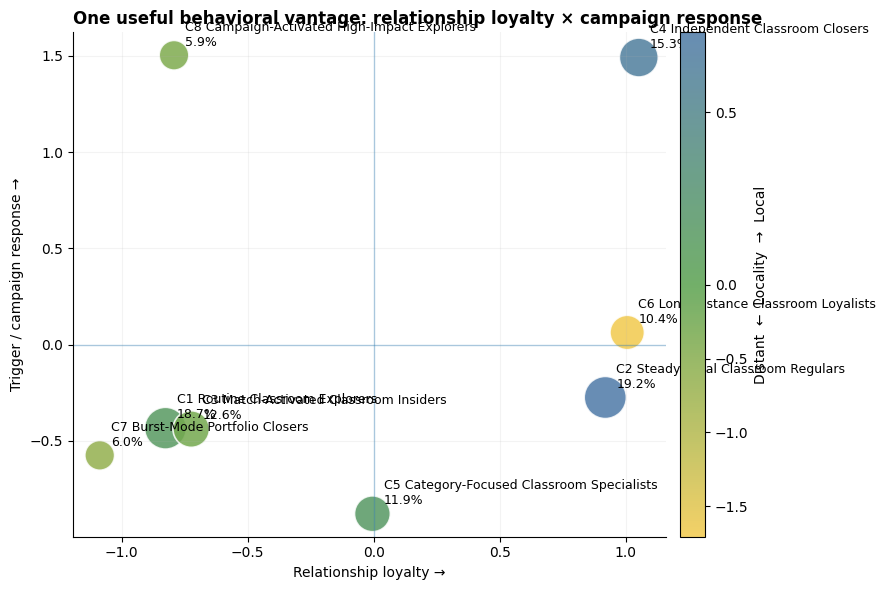

In [26]:
# =============================================================================
# STRATEGIC POSITIONING MAP
# Relationship loyalty x campaign response; color = locality; size = prevalence
# =============================================================================

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# Assigned donors describe behavior; all repeat donors size the audience.
plot = (
    UNIT_PROFILE_LONG
    .pivot(index="cluster", columns="unit", values="score")
    [["relationship_loyalty", "trigger", "jtbd_local_stewardship"]]
    .join(
        BUSINESS_DONORS["cluster"]
        .value_counts(normalize=True)
        .rename("donor_share")
    )
    .sort_index()
)

# Yellow = distant, green = neutral, blue = local.
locality_cmap = LinearSegmentedColormap.from_list(
    "locality",
    ["#F2C94C", "#59A14F", "#4E79A7"],
)
locality_norm = TwoSlopeNorm(
    vmin=plot["jtbd_local_stewardship"].min(),
    vcenter=0,
    vmax=plot["jtbd_local_stewardship"].max(),
)

fig, ax = plt.subplots(figsize=(9, 6))

points = ax.scatter(
    plot["relationship_loyalty"],
    plot["trigger"],
    s=250 + plot["donor_share"] * 3500,
    c=plot["jtbd_local_stewardship"],
    cmap=locality_cmap,
    norm=locality_norm,
    alpha=0.85,
    edgecolor="white",
    linewidth=1.2,
)

for cluster, row in plot.iterrows():
    ax.annotate(
        f"C{cluster} {CLUSTER_LABELS[cluster]}\n{row['donor_share']:.1%}",
        (row["relationship_loyalty"], row["trigger"]),
        xytext=(8, 7),
        textcoords="offset points",
        fontsize=9,
    )

ax.axhline(0, linewidth=1, alpha=0.35)
ax.axvline(0, linewidth=1, alpha=0.35)
ax.grid(alpha=0.15)

ax.set_xlabel("Relationship loyalty →")
ax.set_ylabel("Trigger / campaign response →")
ax.set_title(
    "One useful behavioral vantage: relationship loyalty × campaign response",
    loc="left",
    fontweight="bold",
)

cbar = fig.colorbar(points, ax=ax, pad=0.02)
cbar.set_label("Distant  ←  Locality  →  Local")

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [27]:
# 10. HTML helpers
# -----------------------------------------------------------------------------

def _fmt(v, fmt):
    if pd.isna(v):
        return "-"
    if fmt == "percent":
        return f"{v:.0%}"
    if fmt == "dollar":
        return f"${v:,.0f}"
    if fmt == "days":
        return f"{v:,.0f} days"
    if fmt == "miles":
        return f"{v:,.0f} mi"
    if fmt == "ratio":
        return f"{v:.2f}x"
    return f"{v:,.1f}"


def _idx_badge(v):
    if pd.isna(v):
        return "<span style='color:#888'>n/a</span>"
    if v >= EXEC_INDEX_OVER:
        bg, tag = "#dbeafe", "OVER"
    elif v <= EXEC_INDEX_UNDER:
        bg, tag = "#fef3c7", "UNDER"
    else:
        bg, tag = "#f3f4f6", ""
    return (
        f"<span style='display:inline-block;padding:2px 6px;border-radius:4px;background:{bg};font-weight:700'>"
        f"{v:.2f}x{' ' + tag if tag else ''}</span>"
    )


def _title(text, sub=None):
    html = f"<div style='font-size:22px;font-weight:750;margin:24px 0 4px 0'>{escape(text)}</div>"
    if sub:
        html += f"<div style='font-size:13px;color:#666;margin-bottom:10px'>{escape(sub)}</div>"
    display(HTML(html))


def _metric_matrix(layer):
    d = EXEC_PROFILE_LONG.loc[EXEC_PROFILE_LONG["layer"].eq(layer)].copy()
    if d.empty:
        return "<div style='color:#777'>No available metrics in this layer.</div>"

    metric_order = list(dict.fromkeys(d["metric"].tolist()))
    clusters = sorted(d["cluster"].unique())
    rows = []
    for metric in metric_order:
        m = d.loc[d["metric"].eq(metric)]
        r0 = m.iloc[0]
        cells = [
            f"<td style='padding:6px 8px;font-weight:650'>{escape(metric)}"
            + (f"<div style='font-size:10px;color:#777;font-weight:400'>{escape(r0['note'])}</div>" if r0["note"] else "")
            + "</td>",
            f"<td style='padding:6px 8px;text-align:right;color:#555'><div>{_fmt(r0['overall_value'], r0['format'])}</div>" + (f"<div style='font-size:9px;color:#888'>{r0['overall_coverage']:.0%} measured</div>" if r0['overall_coverage'] < .95 else "") + "</td>",
        ]
        for c in clusters:
            rr = m.loc[m["cluster"].eq(c)].iloc[0]
            cells.append(
                "<td style='padding:6px 8px;text-align:right;white-space:nowrap'>"
                f"<div style='font-weight:650'>{_fmt(rr['cluster_value'], rr['format'])}</div>"
                f"<div style='margin-top:2px'>{_idx_badge(rr['index_vs_overall'])}</div>"
                + (f"<div style='font-size:9px;color:#888'>{rr['cluster_coverage']:.0%} measured</div>" if rr['cluster_coverage'] < .95 else "")
                + "</td>"
            )
        rows.append("<tr style='border-bottom:1px solid #eee'>" + "".join(cells) + "</tr>")

    heads = "".join(
        f"<th style='padding:6px 8px;text-align:right'>{c}<div style='font-size:10px;font-weight:400'>{escape(CLUSTER_LABELS.get(c, ''))}</div></th>"
        for c in clusters
    )
    return (
        "<div style='overflow-x:auto'><table style='border-collapse:collapse;width:100%;font-size:12px'>"
        "<thead><tr style='background:#f8fafc;border-bottom:1px solid #ccc'>"
        "<th style='padding:6px 8px;text-align:left'>Metric</th>"
        "<th style='padding:6px 8px;text-align:right'>Overall</th>"
        + heads + "</tr></thead><tbody>" + "".join(rows) + "</tbody></table></div>"
    )


def _job_matrix_html():
    if EXEC_JOB_INDEX_LONG.empty:
        return "<div style='color:#777'>Run the JTBD cell first.</div>"
    top_col = f"top_{globals().get('JTBD_TOP_N', 2)}_share"
    jobs = EXEC_JOB_INDEX_LONG.groupby("Job")["overall_top_n_share"].first().sort_values(ascending=False).index.tolist()
    clusters = sorted(EXEC_JOB_INDEX_LONG["cluster"].unique())
    rows = []
    for job in jobs:
        sub = EXEC_JOB_INDEX_LONG.loc[EXEC_JOB_INDEX_LONG["Job"].eq(job)]
        overall = sub["overall_top_n_share"].dropna().iloc[0]
        cells = [
            f"<td style='padding:6px 8px;font-weight:650'>{escape(JTBD_DISPLAY_NAMES.get(job, job))}</td>",
            f"<td style='padding:6px 8px;text-align:right'>{overall:.0%}</td>",
        ]
        for c in clusters:
            r = sub.loc[sub["cluster"].eq(c)].iloc[0]
            cells.append(
                "<td style='padding:6px 8px;text-align:right;white-space:nowrap'>"
                f"<div style='font-weight:650'>{r[top_col]:.0%}</div>"
                f"<div>{_idx_badge(r['index_vs_overall'])}</div>"
                "</td>"
            )
        rows.append("<tr style='border-bottom:1px solid #eee'>" + "".join(cells) + "</tr>")

    heads = "".join(
        f"<th style='padding:6px 8px;text-align:right'>C{c}<div style='font-size:10px;font-weight:400'>{escape(CLUSTER_LABELS.get(c, ''))}</div></th>"
        for c in clusters
    )
    return (
        "<div style='overflow-x:auto'><table style='border-collapse:collapse;width:100%;font-size:12px'>"
        "<thead><tr style='background:#f8fafc;border-bottom:1px solid #ccc'>"
        "<th style='padding:6px 8px;text-align:left'>Behavioral Job signal</th>"
        "<th style='padding:6px 8px;text-align:right'>Overall Top-3</th>"
        + heads + "</tr></thead><tbody>" + "".join(rows) + "</tbody></table></div>"
    )


def _revenue_html():
    if EXEC_REVENUE_CONCENTRATION.empty:
        return "<div style='color:#777'>No revenue fields available.</div>"
    rows = []
    for measure, sub in EXEC_REVENUE_CONCENTRATION.groupby("revenue_measure", sort=False):
        for r in sub.itertuples(index=False):
            rows.append(
                "<tr style='border-bottom:1px solid #eee'>"
                f"<td style='padding:6px 8px;font-weight:650'>{escape(measure)}</td>"
                f"<td style='padding:6px 8px'>C{r.cluster} {escape(r.cluster_label)}</td>"
                f"<td style='padding:6px 8px;text-align:right'>{r.donor_share:.1%}</td>"
                f"<td style='padding:6px 8px;text-align:right'>${r.revenue_dollars:,.0f}</td>"
                f"<td style='padding:6px 8px;text-align:right'>{r.revenue_share:.1%}</td>"
                f"<td style='padding:6px 8px;text-align:right'>{_idx_badge(r.revenue_index_vs_donor_share)}</td>"
                "</tr>"
            )
    return (
        "<div style='overflow-x:auto'><table style='border-collapse:collapse;width:100%;font-size:12px'>"
        "<thead><tr style='background:#f8fafc;border-bottom:1px solid #ccc'>"
        "<th style='padding:6px 8px;text-align:left'>Revenue measure</th>"
        "<th style='padding:6px 8px;text-align:left'>Cluster</th>"
        "<th style='padding:6px 8px;text-align:right'>Donor share</th>"
        "<th style='padding:6px 8px;text-align:right'>Dollars</th>"
        "<th style='padding:6px 8px;text-align:right'>Revenue share</th>"
        "<th style='padding:6px 8px;text-align:right'>Revenue index</th>"
        "</tr></thead><tbody>" + "".join(rows) + "</tbody></table></div>"
    )



def _distribution_html():
    if EXEC_DISTRIBUTIONS.empty:
        return "<div style='color:#777'>No robust distribution fields available.</div>"
    rows = []
    for metric, sub in EXEC_DISTRIBUTIONS.groupby("metric", sort=False):
        for _, r in sub.sort_values("cluster").iterrows():
            fmt = r["format"]
            rows.append(
                "<tr style='border-bottom:1px solid #eee'>"
                f"<td style='padding:5px 7px;font-weight:650'>{escape(metric)}</td>"
                f"<td style='padding:5px 7px'>C{int(r['cluster'])} {escape(r['cluster_label'])}</td>"
                f"<td style='padding:5px 7px;text-align:right'>{_fmt(r['p25'], fmt)}</td>"
                f"<td style='padding:5px 7px;text-align:right;font-weight:650'>{_fmt(r['p50'], fmt)}</td>"
                f"<td style='padding:5px 7px;text-align:right'>{_fmt(r['p75'], fmt)}</td>"
                "</tr>"
            )
    return (
        "<div style='margin-top:12px;font-weight:700'>Distribution context (P25 / median / P75)</div>"
        "<div style='overflow-x:auto'><table style='border-collapse:collapse;width:100%;font-size:11px;margin-top:5px'>"
        "<tr style='background:#f8fafc'><th style='text-align:left;padding:5px 7px'>Metric</th>"
        "<th style='text-align:left;padding:5px 7px'>Cluster</th><th style='text-align:right;padding:5px 7px'>P25</th>"
        "<th style='text-align:right;padding:5px 7px'>Median</th><th style='text-align:right;padding:5px 7px'>P75</th></tr>"
        + "".join(rows) + "</table></div></div>"
    )

def _category_cards_html():
    if EXEC_CATEGORY_INDEX_LONG.empty:
        return "<div style='color:#777'>No category-level fields met the display thresholds.</div>"
    cards = []
    for c in sorted(EXEC_CATEGORY_INDEX_LONG["cluster"].unique()):
        sub = EXEC_CATEGORY_INDEX_LONG.loc[EXEC_CATEGORY_INDEX_LONG["cluster"].eq(c)].copy()
        over = sub.sort_values("index_vs_overall", ascending=False).head(EXEC_TOP_CATEGORY_N)
        under = sub.sort_values("index_vs_overall", ascending=True).head(EXEC_BOTTOM_CATEGORY_N)
        show = pd.concat([over, under]).drop_duplicates("category")
        rows = []
        for r in show.itertuples(index=False):
            rows.append(
                "<tr>"
                f"<td style='padding:4px 6px'>{escape(r.category)}</td>"
                f"<td style='padding:4px 6px;text-align:right'>{r.cluster_share:.0%}</td>"
                f"<td style='padding:4px 6px;text-align:right'>{r.overall_share:.0%}</td>"
                f"<td style='padding:4px 6px;text-align:right'>{_idx_badge(r.index_vs_overall)}</td>"
                "</tr>"
            )
        cards.append(
            "<div style='border:1px solid #ddd;border-radius:7px;padding:10px 12px;margin:6px;min-width:320px;flex:1'>"
            f"<div style='font-size:15px;font-weight:700'>C{c} {escape(CLUSTER_LABELS.get(c, ''))}</div>"
            "<table style='width:100%;font-size:11px;border-collapse:collapse;margin-top:5px'>"
            "<tr style='background:#f8fafc'><th style='text-align:left;padding:4px 6px'>Category</th>"
            "<th style='text-align:right;padding:4px 6px'>Cluster</th><th style='text-align:right;padding:4px 6px'>Overall</th>"
            "<th style='text-align:right;padding:4px 6px'>Index</th></tr>"
            + "".join(rows) + "</table></div>"
        )
    return "<div style='display:flex;flex-wrap:wrap'>" + "".join(cards) + "</div>"


def _job_pair_cards_html():
    if EXEC_JOB_PAIR_INDEX_LONG.empty:
        return "<div style='color:#777'>Job-pair output unavailable; run the JTBD ranking cell first.</div>"
    cards = []
    for c in sorted(EXEC_JOB_PAIR_INDEX_LONG["cluster"].unique()):
        sub = EXEC_JOB_PAIR_INDEX_LONG.loc[EXEC_JOB_PAIR_INDEX_LONG["cluster"].eq(c)].copy()
        sub = sub.sort_values(["index_vs_overall", "cluster_share"], ascending=[False, False]).head(EXEC_TOP_JOB_PAIR_N)
        rows = []
        for _, r in sub.iterrows():
            rows.append(
                "<tr>"
                f"<td style='padding:4px 6px'>{escape(str(r['Job pair']))}</td>"
                f"<td style='padding:4px 6px;text-align:right'>{r['cluster_share']:.0%}</td>"
                f"<td style='padding:4px 6px;text-align:right'>{r['overall_share']:.0%}</td>"
                f"<td style='padding:4px 6px;text-align:right'>{_idx_badge(r['index_vs_overall'])}</td>"
                "</tr>"
            )
        cards.append(
            "<div style='border:1px solid #ddd;border-radius:7px;padding:10px 12px;margin:6px;min-width:360px;flex:1'>"
            f"<div style='font-size:15px;font-weight:700'>C{c} {escape(CLUSTER_LABELS.get(c, ''))}</div>"
            "<table style='width:100%;font-size:11px;border-collapse:collapse;margin-top:5px'>"
            "<tr style='background:#f8fafc'><th style='text-align:left;padding:4px 6px'>Over-indexed Job pair</th>"
            "<th style='text-align:right;padding:4px 6px'>Cluster</th><th style='text-align:right;padding:4px 6px'>Overall</th>"
            "<th style='text-align:right;padding:4px 6px'>Index</th></tr>"
            + "".join(rows) + "</table></div>"
        )
    return "<div style='display:flex;flex-wrap:wrap'>" + "".join(cards) + "</div>"

def _availability_html():
    rows = []
    for r in EXEC_AVAILABILITY_AUDIT.itertuples(index=False):
        status_bg = "#dcfce7" if r.status == "AVAILABLE" else "#fef3c7"
        cov = "-" if pd.isna(r.coverage) else f"{r.coverage:.0%}"
        rows.append(
            "<tr style='border-bottom:1px solid #eee'>"
            f"<td style='padding:5px 7px'>{escape(r.layer)}</td>"
            f"<td style='padding:5px 7px;font-weight:650'>{escape(r.needed)}</td>"
            f"<td style='padding:5px 7px'><span style='background:{status_bg};padding:2px 5px;border-radius:4px;font-weight:700'>{escape(r.status)}</span></td>"
            f"<td style='padding:5px 7px;font-family:ui-monospace,monospace;font-size:10px'>{escape(str(r.field_or_object))}</td>"
            f"<td style='padding:5px 7px;text-align:right'>{cov}</td>"
            f"<td style='padding:5px 7px;color:#555'>{escape(r.note)}</td>"
            "</tr>"
        )
    return (
        "<div style='overflow-x:auto'><table style='border-collapse:collapse;width:100%;font-size:11px'>"
        "<thead><tr style='background:#f8fafc'><th style='text-align:left;padding:5px 7px'>Layer</th>"
        "<th style='text-align:left;padding:5px 7px'>Need</th><th style='text-align:left;padding:5px 7px'>Status</th>"
        "<th style='text-align:left;padding:5px 7px'>Field / object</th><th style='text-align:right;padding:5px 7px'>Coverage</th>"
        "<th style='text-align:left;padding:5px 7px'>Interpretation</th></tr></thead><tbody>"
        + "".join(rows) + "</tbody></table></div>"
    )

# -----------------------------------------------------------------------------
# 11. Render the executive analysis in a readable sequence
# -----------------------------------------------------------------------------

_display_weight = globals().get("UNIT_WEIGHTS", {}).get("jtbd_local_stewardship", 1.0)
_title(
    "Executive-readout analytical layers",
    f"Selected K={SELECTED_K} | profile base={len(EXEC_BASE):,} assigned donors | prevalence/business base={len(EXEC_BUSINESS_BASE):,} repeat donors. Profile cells use assigned donors; revenue concentration uses all scored repeat donors."
)

_title("A. What the current data can answer", "Missing items are surfaced rather than inferred.")
display(HTML(_availability_html()))

_title("B. Economic value", "Revenue concentration answers whether a cluster carries more or less revenue than its population size would suggest.")
display(HTML(_metric_matrix("Economic value")))
display(HTML("<div style='height:10px'></div>" + _revenue_html()))
display(HTML(_distribution_html()))

_title("C. Lifecycle + monthly relationship", "These are current/lifetime descriptors; true future retention still requires a later observation window.")
display(HTML(_metric_matrix("Lifecycle + retention")))

_title("D. Digital product intensity", "Site coverage and journey observability matter; read the raw values together with coverage, not as pure motivation.")
display(HTML(_metric_matrix("Digital product intensity")))

_title("E. Optional tip economics", "Platform support is profiled after clustering so it can be economically important without defining persona identity.")
display(HTML(_metric_matrix("Optional tip economics")))

_title("F. Choice + need affinity", "Broad merchandising/recommendation signals first; detailed categories follow below.")
display(HTML(_metric_matrix("Choice + need affinity")))

_title("G. Category affinities", f"Shows categories with >= {EXEC_CATEGORY_MIN_OVERALL_SHARE:.0%} overall average gift-share baseline; rare other/unknown buckets excluded.")
display(HTML(_category_cards_html()))

_title("H. Jobs across the portfolio", "Each cell is cluster Top-3 prevalence plus its index vs the overall donor population. This is behavioral evidence consistent with a Job, not stated motivation.")
display(HTML(_job_matrix_html()))

if not EXEC_JOB_COVERAGE.empty:
    _rows = []
    for _, r in EXEC_JOB_COVERAGE.iterrows():
        _rows.append(
            "<tr style='border-bottom:1px solid #eee'>"
            f"<td style='padding:4px 6px'>C{int(r['cluster'])} {escape(r['cluster_label'])}</td>"
            f"<td style='padding:4px 6px;text-align:right'>{int(r['ranking_eligible_n']):,}</td>"
            f"<td style='padding:4px 6px;text-align:right;font-weight:650'>{r['ranking_eligible_share']:.0%}</td>"
            "</tr>"
        )
    display(HTML(
        "<div style='margin-top:10px;font-weight:700'>Job-ranking coverage</div>"
        "<div style='font-size:11px;color:#666;margin-bottom:4px'>Top-3 comparisons use donors with all rankable Jobs measured; large coverage differences by cluster would weaken direct comparisons.</div>"
        "<table style='border-collapse:collapse;font-size:11px;min-width:520px'>"
        "<tr style='background:#f8fafc'><th style='text-align:left;padding:4px 6px'>Cluster</th>"
        "<th style='text-align:right;padding:4px 6px'>Eligible donors</th><th style='text-align:right;padding:4px 6px'>Eligible share</th></tr>"
        + "".join(_rows) + "</table>"
    ))

if not EXEC_JOB_PORTFOLIO.empty:
    _jp = EXEC_JOB_PORTFOLIO.copy()
    _rows = []
    for r in _jp.itertuples(index=False):
        _rows.append(
            "<tr style='border-bottom:1px solid #eee'>"
            f"<td style='padding:5px 7px;font-weight:650'>{escape(JTBD_DISPLAY_NAMES.get(r.Job, r.Job))}</td>"
            f"<td style='padding:5px 7px;text-align:right'>{r.overall_top2_share:.0%}</td>"
            f"<td style='padding:5px 7px'>{escape(r.highest_cluster)}</td>"
            f"<td style='padding:5px 7px;text-align:right'>{_idx_badge(r.highest_index)}</td>"
            f"<td style='padding:5px 7px'>{escape(r.lowest_cluster)}</td>"
            f"<td style='padding:5px 7px;text-align:right'>{_idx_badge(r.lowest_index)}</td>"
            "</tr>"
        )
    display(HTML(
        "<div style='margin-top:12px;font-weight:700'>Which Jobs actually separate the portfolio?</div>"
        "<table style='border-collapse:collapse;width:100%;font-size:11px;margin-top:5px'>"
        "<tr style='background:#f8fafc'><th style='text-align:left;padding:5px 7px'>Job</th>"
        "<th style='text-align:right;padding:5px 7px'>Overall Top-3</th><th style='text-align:left;padding:5px 7px'>Highest cluster</th>"
        "<th style='text-align:right;padding:5px 7px'>High index</th><th style='text-align:left;padding:5px 7px'>Lowest cluster</th>"
        "<th style='text-align:right;padding:5px 7px'>Low index</th></tr>" + "".join(_rows) + "</table>"
    ))

if not EXEC_EVIDENCE_ONLY_JOB_INDEX.empty:
    _rows = []
    for r in EXEC_EVIDENCE_ONLY_JOB_INDEX.sort_values(["Job", "cluster"]).itertuples(index=False):
        _rows.append(
            "<tr style='border-bottom:1px solid #eee'>"
            f"<td style='padding:5px 7px;font-weight:650'>{escape(JTBD_DISPLAY_NAMES.get(r.Job, r.Job))}</td>"
            f"<td style='padding:5px 7px'>C{r.cluster} {escape(r.cluster_label)}</td>"
            f"<td style='padding:5px 7px;text-align:right'>{_idx_badge(r.index_vs_overall)}</td>"
            f"<td style='padding:5px 7px;text-align:right'>{r.measured_share:.0%}</td>"
            "</tr>"
        )
    display(HTML(
        "<div style='margin-top:14px;font-weight:700'>Evidence-only Jobs</div>"
        "<div style='font-size:11px;color:#666;margin-bottom:5px'>These do not receive Top-3 slots; the index compares mean raw behavioral evidence with overall.</div>"
        "<table style='border-collapse:collapse;width:100%;font-size:11px'>"
        "<tr style='background:#f8fafc'><th style='text-align:left;padding:5px 7px'>Job</th><th style='text-align:left;padding:5px 7px'>Cluster</th>"
        "<th style='text-align:right;padding:5px 7px'>Evidence index</th><th style='text-align:right;padding:5px 7px'>Measured</th></tr>"
        + "".join(_rows) + "</table>"
    ))

_title("I. Job combinations", "Top over-indexed Top-3 Job pairs by cluster; useful for deciding which Jobs might be sequenced or combined rather than treated independently.")
display(HTML(_job_pair_cards_html()))

_title("J. Core behavioral fingerprint in raw terms", "Same clustering ingredients, but reported as raw values and indexes instead of +/- SD unit scores.")
display(HTML(_metric_matrix("Core behavior")))

_title("K. Audience context", "Useful context for activation and treatment design; these variables did not define the cluster geometry.")
display(HTML(_metric_matrix("Audience context")))

# -----------------------------------------------------------------------------
# 12. One compact cluster-by-cluster readout for later DOCX synthesis
# -----------------------------------------------------------------------------

_title("L. Extended cluster cards", "Top over/under-indexes from each analytical layer, plus strongest Job tendencies.")

_layers_for_cards = [
    "Economic value", "Lifecycle + retention", "Digital product intensity",
    "Optional tip economics", "Choice + need affinity"
]

for cluster in sorted(EXEC_BASE["cluster"].unique()):
    profile_n = int(EXEC_BASE["cluster"].eq(cluster).sum())
    prevalence_n = int(CLUSTER_PREVALENCE.loc[int(cluster), "donors"])
    prevalence_share = float(CLUSTER_PREVALENCE.loc[int(cluster), "share"])
    card_parts = [
        f"<div style='border:1px solid #d1d5db;border-radius:9px;padding:14px 16px;margin:12px 0 20px;background:white'>",
        f"<div style='font-size:20px;font-weight:750'>C{cluster} {escape(CLUSTER_LABELS.get(int(cluster), ''))}</div>",
        f"<div style='font-size:12px;color:#666;margin-bottom:9px'>{prevalence_n:,} repeat donors | {prevalence_share:.1%} prevalence | {profile_n:,} assigned donors profiled</div>",
    ]

    for layer in _layers_for_cards:
        d = EXEC_PROFILE_LONG.loc[
            EXEC_PROFILE_LONG["cluster"].eq(cluster) & EXEC_PROFILE_LONG["layer"].eq(layer)
        ].copy()
        d = d.dropna(subset=["index_vs_overall"])
        if d.empty:
            continue
        d["distance_from_1"] = (d["index_vs_overall"] - 1).abs()
        d = d.sort_values("distance_from_1", ascending=False).head(4)
        card_parts.append(f"<div style='font-size:13px;font-weight:700;margin-top:9px'>{escape(layer)}</div>")
        card_parts.append("<table style='width:100%;font-size:11px;border-collapse:collapse'>")
        for _, r in d.iterrows():
            card_parts.append(
                "<tr style='border-bottom:1px solid #f0f0f0'>"
                f"<td style='padding:4px 6px'>{escape(r['metric'])}</td>"
                f"<td style='padding:4px 6px;text-align:right;font-weight:650'>{_fmt(r['cluster_value'], r['format'])}</td>"
                f"<td style='padding:4px 6px;text-align:right;color:#666'>overall {_fmt(r['overall_value'], r['format'])}</td>"
                f"<td style='padding:4px 6px;text-align:right'>{_idx_badge(r['index_vs_overall'])}</td>"
                "</tr>"
            )
        card_parts.append("</table>")

    if not EXEC_JOB_INDEX_LONG.empty:
        top_col = f"top_{globals().get('JTBD_TOP_N', 2)}_share"
        jd = EXEC_JOB_INDEX_LONG.loc[EXEC_JOB_INDEX_LONG["cluster"].eq(cluster)].copy()
        jd = jd.sort_values(["index_vs_overall", top_col], ascending=[False, False]).head(4)
        card_parts.append("<div style='font-size:13px;font-weight:700;margin-top:9px'>Strongest Job tendencies</div>")
        card_parts.append("<table style='width:100%;font-size:11px;border-collapse:collapse'>")
        for _, r in jd.iterrows():
            card_parts.append(
                "<tr style='border-bottom:1px solid #f0f0f0'>"
                f"<td style='padding:4px 6px'>{escape(JTBD_DISPLAY_NAMES.get(r['Job'], r['Job']))}</td>"
                f"<td style='padding:4px 6px;text-align:right'>{r[top_col]:.0%} Top-3</td>"
                f"<td style='padding:4px 6px;text-align:right'>{_idx_badge(r['index_vs_overall'])}</td>"
                "</tr>"
            )
        card_parts.append("</table>")

    card_parts.append("</div>")
    display(HTML("".join(card_parts)))

# -----------------------------------------------------------------------------
# 13. Objects preserved for the follow-up report
# -----------------------------------------------------------------------------

EXEC_MODEL_SPEC = pd.DataFrame([
    {
        "unit": unit,
        "unit_weight": float(globals().get("UNIT_WEIGHTS", {}).get(unit, 1.0)),
        "feature": feature,
        "direction": "+" if direction > 0 else "-",
    }
    for unit, spec in UNITS_NOW.items()
    for feature, direction in spec.items()
])

EXEC_ALL_OBJECTS = {
    "profile_base": EXEC_BASE,
    "business_base": EXEC_BUSINESS_BASE,
    "model_spec": EXEC_MODEL_SPEC,
    "availability_audit": EXEC_AVAILABILITY_AUDIT,
    "profile_long": EXEC_PROFILE_LONG,
    "revenue_concentration": EXEC_REVENUE_CONCENTRATION,
    "distributions": EXEC_DISTRIBUTIONS,
    "category_index_long": EXEC_CATEGORY_INDEX_LONG,
    "job_index_long": EXEC_JOB_INDEX_LONG,
    "job_portfolio": EXEC_JOB_PORTFOLIO,
    "job_coverage": EXEC_JOB_COVERAGE,
    "evidence_only_job_index": EXEC_EVIDENCE_ONLY_JOB_INDEX,
    "job_pair_index_long": EXEC_JOB_PAIR_INDEX_LONG,
}

print(
    "Created: EXEC_BASE, EXEC_MODEL_SPEC, EXEC_AVAILABILITY_AUDIT, "
    "EXEC_PROFILE_LONG, EXEC_REVENUE_CONCENTRATION, EXEC_DISTRIBUTIONS, "
    "EXEC_CATEGORY_INDEX_LONG, EXEC_JOB_INDEX_LONG, EXEC_JOB_PORTFOLIO, EXEC_JOB_COVERAGE, "
    "EXEC_EVIDENCE_ONLY_JOB_INDEX, EXEC_JOB_PAIR_INDEX_LONG, EXEC_ALL_OBJECTS"
)


Layer,Need,Status,Field / object,Coverage,Interpretation
Economic value,Observed lifetime revenue,AVAILABLE,lifetime_amount,100%,Available lifetime project-gift revenue; this is not predictive LTV.
Economic value,Predictive LTV,MISSING / FOLLOW-ON,-,-,Requires a true LTV/predicted future-value field or separate model.
Economic value,Current-window project revenue,AVAILABLE,gift_amount_24m,100%,Current notebook window is 24 months.
Economic value,Current-window all-giving revenue,AVAILABLE,grand_amount_24m,100%,Preferred if project + monthly dollars are available.
Lifecycle + retention,Current lifecycle state,AVAILABLE,is_continuing_donor_24m,100%,New/reactivated/continuing are current-window state descriptors.
Lifecycle + retention,Future retention / next-gift outcome,MISSING / FOLLOW-ON,-,-,Needs a subsequent observation window; should remain post-fit.
Digital product intensity,Site-active days,AVAILABLE,days_with_site_activity_24m,97%,Available if site source is observed.
Digital product intensity,True-session grain,AVAILABLE,site_unit_is_session,100%,"If 0, visit counts are donor-day rather than true sessions."
Digital product intensity,Project-page activity,AVAILABLE,project_page_visits_day_total_24m,97%,Available in current site feature family if loaded.
Digital product intensity,Unique projects viewed per session,MISSING / FOLLOW-ON,-,-,Not present in the current dictionary unless a newer feature build added it.


Metric,Overall,1Routine Classroom Explorers,2Steady Local Classroom Regulars,3Match-Activated Classroom Insiders,4Independent Classroom Closers,5Category-Focused Classroom Specialists,6Long-Distance Classroom Loyalists,7Burst-Mode Portfolio Closers,8Campaign-Activated High-Impact Explorers
24m project revenue per donor,$485,$3780.78x UNDER,$3650.75x UNDER,"$1,2932.67x OVER",$4030.83x,$4540.94x,$3540.73x UNDER,"$1,0712.21x OVER",$7921.63x OVER
Previous equal-length-window project revenue per donorPrior window matches the configured current-window length,$37577% measured,$3000.80x UNDER79% measured,$2500.67x UNDER80% measured,"$1,0632.83x OVER76% measured",$3600.96x83% measured,$3120.83x62% measured,$2500.67x UNDER81% measured,"$1,0212.72x OVER65% measured",$8412.24x OVER80% measured
24m all-giving revenue per donorProject + monthly if available,$490,$3820.78x UNDER,$3690.75x UNDER,"$1,3362.73x OVER",$4030.82x,$4560.93x,$3550.73x UNDER,"$1,0772.20x OVER",$7991.63x OVER
"Lifetime project revenue per donorObserved lifetime revenue, not predictive LTV","$1,220",$9900.81x,$8590.70x UNDER,"$3,3562.75x OVER","$1,1440.94x",$9280.76x UNDER,$8570.70x UNDER,"$3,1352.57x OVER","$2,5912.12x OVER"
Lifetime project gifts,21.0,22.01.05x,17.00.81x,32.01.52x OVER,20.00.95x,19.00.90x,14.00.67x UNDER,30.01.43x OVER,31.01.48x OVER
Median project gift,$50,$501.00x,$501.00x,$901.80x OVER,$501.00x,$200.40x UNDER,$501.00x,$661.32x OVER,$791.57x OVER
Major-gift donor share,0%,0%0.00x UNDER,0%0.00x UNDER,0%1.70x OVER,0%0.00x UNDER,0%0.00x UNDER,0%0.00x UNDER,0%4.94x OVER,0%7.36x OVER


Revenue measure,Cluster,Donor share,Dollars,Revenue share,Revenue index
24m project revenue,C1 Routine Classroom Explorers,18.7%,"$8,189,111",7.4%,0.39x UNDER
24m project revenue,C2 Steady Local Classroom Regulars,19.2%,"$8,044,453",7.3%,0.38x UNDER
24m project revenue,C3 Match-Activated Classroom Insiders,12.6%,"$22,804,337",20.6%,1.63x OVER
24m project revenue,C4 Independent Classroom Closers,15.3%,"$8,453,904",7.6%,0.50x UNDER
24m project revenue,C5 Category-Focused Classroom Specialists,11.9%,"$9,403,073",8.5%,0.72x UNDER
24m project revenue,C6 Long-Distance Classroom Loyalists,10.4%,"$4,382,597",4.0%,0.38x UNDER
24m project revenue,C7 Burst-Mode Portfolio Closers,6.0%,"$36,171,125",32.7%,5.47x OVER
24m project revenue,C8 Campaign-Activated High-Impact Explorers,5.9%,"$13,267,905",12.0%,2.03x OVER
24m all-giving revenue,C1 Routine Classroom Explorers,18.7%,"$8,670,715",7.7%,0.41x UNDER
24m all-giving revenue,C2 Steady Local Classroom Regulars,19.2%,"$8,210,541",7.3%,0.38x UNDER


Metric,Cluster,P25,Median,P75
24m project revenue per donor,C1 Routine Classroom Explorers,$215,$378,$743
24m project revenue per donor,C2 Steady Local Classroom Regulars,$200,$365,$695
24m project revenue per donor,C3 Match-Activated Classroom Insiders,$628,"$1,293","$2,768"
24m project revenue per donor,C4 Independent Classroom Closers,$222,$403,$819
24m project revenue per donor,C5 Category-Focused Classroom Specialists,$242,$454,$910
24m project revenue per donor,C6 Long-Distance Classroom Loyalists,$200,$354,$677
24m project revenue per donor,C7 Burst-Mode Portfolio Closers,$433,"$1,071","$3,595"
24m project revenue per donor,C8 Campaign-Activated High-Impact Explorers,$355,$792,"$2,158"
Lifetime project revenue per donor,C1 Routine Classroom Explorers,$486,$990,"$2,363"
Lifetime project revenue per donor,C2 Steady Local Classroom Regulars,$450,$859,"$1,875"


Metric,Overall,1Routine Classroom Explorers,2Steady Local Classroom Regulars,3Match-Activated Classroom Insiders,4Independent Classroom Closers,5Category-Focused Classroom Specialists,6Long-Distance Classroom Loyalists,7Burst-Mode Portfolio Closers,8Campaign-Activated High-Impact Explorers
Giving tenure,"2,188 days","2,374 days1.08x","1,947 days0.89x","2,504 days1.14x","2,182 days1.00x","1,523 days0.70x UNDER","2,174 days0.99x","2,334 days1.07x","2,706 days1.24x OVER"
Days since last project giftLower = more recent,118 days,78 days0.66x UNDER,112 days0.95x,75 days0.64x UNDER,119 days1.01x,180 days1.53x OVER,118 days1.00x,215 days1.82x OVER,172 days1.46x OVER
Active giving months,4.0,5.01.25x OVER,5.01.25x OVER,6.01.50x OVER,4.01.00x,3.00.75x UNDER,4.01.00x,2.00.50x UNDER,4.01.00x
New-donor share,16%,15%0.92x,14%0.88x,18%1.07x,11%0.69x UNDER,28%1.71x OVER,12%0.71x UNDER,22%1.37x OVER,13%0.79x UNDER
Reactivated-donor share,7%,6%0.83x,5%0.76x UNDER,7%0.95x,6%0.84x,10%1.41x OVER,7%1.04x,13%1.79x OVER,7%0.98x
Continuing-donor share,77%,79%1.03x,80%1.05x,76%0.99x,83%1.08x,62%0.81x,81%1.06x,65%0.85x,80%1.05x
Current monthly-donor share,3%,6%1.95x OVER,2%0.62x UNDER,6%2.01x OVER,0%0.06x UNDER,2%0.68x UNDER,2%0.81x,2%0.79x UNDER,1%0.49x UNDER
Monthly active months,0.0,0.0n/a,0.0n/a,0.0n/a,0.0n/a,0.0n/a,0.0n/a,0.0n/a,0.0n/a
Longest monthly streak,22.06% measured,26.01.18x9% measured,15.00.68x UNDER4% measured,45.02.05x OVER9% measured,7.00.32x UNDER2% measured,12.50.57x UNDER4% measured,15.00.68x UNDER5% measured,21.00.95x5% measured,30.51.39x OVER4% measured
Share of giving from monthly,1%,2%1.96x OVER,1%0.77x UNDER,2%1.83x OVER,0%0.05x UNDER,1%0.59x UNDER,1%1.04x,1%0.51x UNDER,1%0.50x UNDER


...

Major-gift donor share,0%,overall 0%,0.00x UNDER
Median project gift,$20,overall $50,0.40x UNDER
Lifetime project revenue per donor,$928,"overall $1,220",0.76x UNDER
Previous equal-length-window project revenue per donor,$312,overall $375,0.83x
New-donor share,28%,overall 16%,1.71x OVER
Days since last project gift,180 days,overall 118 days,1.53x OVER
Longest monthly streak,12.5,overall 22.0,0.57x UNDER
Share of giving from monthly,1%,overall 1%,0.59x UNDER
Project-page visits,5.0,overall 12.0,0.42x UNDER
Search visits,2.7,overall 5.5,0.48x UNDER
Site-active days,8.0,overall 16.0,0.50x UNDER


Major-gift donor share,0%,overall 0%,0.00x UNDER
Previous equal-length-window project revenue per donor,$250,overall $375,0.67x UNDER
Lifetime project gifts,14.0,overall 21.0,0.67x UNDER
Lifetime project revenue per donor,$857,"overall $1,220",0.70x UNDER
Longest monthly streak,15.0,overall 22.0,0.68x UNDER
New-donor share,12%,overall 16%,0.71x UNDER
Current monthly-donor share,2%,overall 3%,0.81x
Continuing-donor share,81%,overall 77%,1.06x
Search visit share,8%,overall 13%,0.61x UNDER
Gifts preceded by search,11%,overall 17%,0.63x UNDER
Search visits,4.0,overall 5.5,0.73x UNDER


Major-gift donor share,0%,overall 0%,4.94x OVER
Previous equal-length-window project revenue per donor,"$1,021",overall $375,2.72x OVER
Lifetime project revenue per donor,"$3,135","overall $1,220",2.57x OVER
24m project revenue per donor,"$1,071",overall $485,2.21x OVER
Days since last project gift,215 days,overall 118 days,1.82x OVER
Reactivated-donor share,13%,overall 7%,1.79x OVER
Median monthly payment,$40,overall $25,1.60x OVER
Active giving months,2.0,overall 4.0,0.50x UNDER
Search visits,11.1,overall 5.5,2.00x OVER
Search visit share,24%,overall 13%,1.86x OVER
Gifts preceded by search,29%,overall 17%,1.68x OVER


Major-gift donor share,0%,overall 0%,7.36x OVER
Previous equal-length-window project revenue per donor,$841,overall $375,2.24x OVER
Lifetime project revenue per donor,"$2,591","overall $1,220",2.12x OVER
24m project revenue per donor,$792,overall $485,1.63x OVER
Median monthly payment,$50,overall $25,2.00x OVER
Current monthly-donor share,1%,overall 3%,0.49x UNDER
Share of giving from monthly,1%,overall 1%,0.50x UNDER
Days since last project gift,172 days,overall 118 days,1.46x OVER
Search visits,7.9,overall 5.5,1.44x OVER
Gifts preceded by search,23%,overall 17%,1.33x OVER
Search visit share,16%,overall 13%,1.23x OVER


Created: EXEC_BASE, EXEC_MODEL_SPEC, EXEC_AVAILABILITY_AUDIT, EXEC_PROFILE_LONG, EXEC_REVENUE_CONCENTRATION, EXEC_DISTRIBUTIONS, EXEC_CATEGORY_INDEX_LONG, EXEC_JOB_INDEX_LONG, EXEC_JOB_PORTFOLIO, EXEC_JOB_COVERAGE, EXEC_EVIDENCE_ONLY_JOB_INDEX, EXEC_JOB_PAIR_INDEX_LONG, EXEC_ALL_OBJECTS


## 16 — Business opportunity cuts

These are **aggregate sizing/context** analyses, so they use all scored 2+ repeat donors and their nearest cluster. They do not change persona definitions and they do not imply tentative donors are safe for persona-level targeting.


In [28]:
# $10K+ donors + DAF activity by cluster
x = BUSINESS_DONORS.copy()
revenue_field = first_available(x, "grand_amount_24m", "grand_amount_12m", "gift_amount_24m", "gift_amount_12m")
daf_field = first_available(x, "share_gifts_daf_24m", "share_gifts_daf_12m")
if revenue_field is None or daf_field is None:
    raise KeyError("High-value/DAF analysis requires a current-window revenue field and DAF share field.")

revenue = pd.to_numeric(x[revenue_field], errors="coerce")
daf_share = pd.to_numeric(x[daf_field], errors="coerce")
x["gave_10k_plus_24m"] = revenue >= LARGE_DONOR_THRESHOLD
x["any_daf_24m"] = daf_share > 0
x["gave_10k_plus_and_daf_24m"] = x["gave_10k_plus_24m"] & x["any_daf_24m"]

overall_rates = {
    "10k": x["gave_10k_plus_24m"].mean(),
    "daf": x["any_daf_24m"].mean(),
    "both": x["gave_10k_plus_and_daf_24m"].mean(),
}
rows = []
for cluster, group in x.groupby("cluster"):
    n = len(group)
    p10 = group["gave_10k_plus_24m"].mean()
    pdaf = group["any_daf_24m"].mean()
    pboth = group["gave_10k_plus_and_daf_24m"].mean()
    rows.append({
        "Cluster": int(cluster), "Cluster name": CLUSTER_LABELS[int(cluster)], "Donors": n,
        "$10K+ donors": int(group["gave_10k_plus_24m"].sum()), "$10K+ share": p10,
        "$10K+ index": p10 / overall_rates["10k"] if overall_rates["10k"] > 0 else np.nan,
        "Any DAF donors": int(group["any_daf_24m"].sum()), "Any DAF share": pdaf,
        "DAF index": pdaf / overall_rates["daf"] if overall_rates["daf"] > 0 else np.nan,
        "$10K+ & DAF": int(group["gave_10k_plus_and_daf_24m"].sum()), "Both share": pboth,
        "Both index": pboth / overall_rates["both"] if overall_rates["both"] > 0 else np.nan,
    })
HIGH_VALUE_DAF_BY_CLUSTER = pd.DataFrame(rows).sort_values("Cluster")
HIGH_VALUE_DAF_OVERALL = pd.DataFrame([{
    "Cluster": "OVERALL", "Cluster name": "Overall", "Donors": len(x),
    "$10K+ donors": int(x["gave_10k_plus_24m"].sum()), "$10K+ share": overall_rates["10k"], "$10K+ index": 1.0,
    "Any DAF donors": int(x["any_daf_24m"].sum()), "Any DAF share": overall_rates["daf"], "DAF index": 1.0,
    "$10K+ & DAF": int(x["gave_10k_plus_and_daf_24m"].sum()), "Both share": overall_rates["both"], "Both index": 1.0,
}])
HIGH_VALUE_DAF_DISPLAY = pd.concat([HIGH_VALUE_DAF_BY_CLUSTER, HIGH_VALUE_DAF_OVERALL], ignore_index=True)

display(HTML(
    f"<div style='border:1px solid #d1d5db;border-radius:8px;padding:10px 12px;margin:8px 0;background:#f8fafc'>"
    f"<b>Fields used:</b> $10K threshold = <code>{revenue_field}</code>; DAF activity = <code>{daf_field}</code>. "
    "DAF means any observed DAF project gift in the current window.</div>"
))
display(
    HIGH_VALUE_DAF_DISPLAY.style.format({
        "Donors": "{:,.0f}", "$10K+ donors": "{:,.0f}", "$10K+ share": "{:.1%}", "$10K+ index": "{:.2f}x",
        "Any DAF donors": "{:,.0f}", "Any DAF share": "{:.1%}", "DAF index": "{:.2f}x",
        "$10K+ & DAF": "{:,.0f}", "Both share": "{:.1%}", "Both index": "{:.2f}x",
    }).hide(axis="index").set_caption("$10K+ giving and DAF activity — all scored repeat donors")
)


Cluster,Cluster name,Donors,$10K+ donors,$10K+ share,$10K+ index,Any DAF donors,Any DAF share,DAF index,$10K+ & DAF,Both share,Both index
1,Routine Classroom Explorers,"12,785",33,0.3%,0.12x,122,1.0%,0.65x,12,0.1%,0.18x
2,Steady Local Classroom Regulars,"13,110",36,0.3%,0.13x,45,0.3%,0.23x,6,0.0%,0.09x
3,Match-Activated Classroom Insiders,"8,609",397,4.6%,2.22x,284,3.3%,2.23x,99,1.1%,2.26x
4,Independent Classroom Closers,"10,430",79,0.8%,0.36x,13,0.1%,0.08x,3,0.0%,0.06x
5,Category-Focused Classroom Specialists,"8,096",105,1.3%,0.62x,172,2.1%,1.44x,27,0.3%,0.65x
6,Long-Distance Classroom Loyalists,"7,118",23,0.3%,0.16x,32,0.4%,0.30x,3,0.0%,0.08x
7,Burst-Mode Portfolio Closers,"4,075",489,12.0%,5.77x,207,5.1%,3.44x,117,2.9%,5.63x
8,Campaign-Activated High-Impact Explorers,"4,027",258,6.4%,3.08x,134,3.3%,2.25x,81,2.0%,3.94x
OVERALL,Overall,"68,250","1,420",2.1%,1.00x,"1,009",1.5%,1.00x,348,0.5%,1.00x


In [29]:
# =============================================================================
# OPTIONAL-DONATION ECONOMICS
#
# IMPORTANT:
# avg_optional_donation_rate_* is a gift-count-weighted mean of gift-level
# rates. It must NOT be multiplied by donor-level revenue to estimate dollars.
#
# Dollar economics are produced only when the feature build contains an actual
# donor-level total of optional-donation dollars for the same window.
#
# If no vetted dollar field exists:
#   - behavioral optional-rate profiling remains valid elsewhere;
#   - dollar opportunity / gap outputs are intentionally unavailable;
#   - the notebook continues running without inventing a dollar estimate.
# =============================================================================

x = BUSINESS_DONORS.copy()

# -----------------------------------------------------------------------------
# 1. Resolve fields
# -----------------------------------------------------------------------------

optional_rate_field = first_available(
    x,
    "avg_optional_donation_rate_24m",
    "avg_optional_donation_rate_12m",
)

large_donor_revenue_field = first_available(
    x,
    "grand_amount_24m",
    "grand_amount_12m",
    "gift_amount_24m",
    "gift_amount_12m",
)

direct_green_field = first_available(
    x,
    "green_revenue_24m",
    "green_revenue_12m",
    "gift_amount_green_24m",
    "gift_amount_green_12m",
    "green_amount_24m",
    "green_amount_12m",
)

if large_donor_revenue_field is None:
    raise KeyError(
        "Optional-donation economics needs a current-window revenue field "
        "for the $10K+ donor flag."
    )


# -----------------------------------------------------------------------------
# 2. Resolve / derive Green project-gift dollars
# -----------------------------------------------------------------------------

if direct_green_field is not None:
    x["_green_revenue"] = pd.to_numeric(
        x[direct_green_field],
        errors="coerce",
    )
    green_revenue_source = direct_green_field

else:
    project_revenue_field = first_available(
        x,
        "gift_amount_24m",
        "gift_amount_12m",
    )

    green_share_field = first_available(
        x,
        "share_amount_green_optin_24m",
        "share_amount_green_optin_12m",
        "share_amount_green_24m",
        "share_amount_green_12m",
    )

    if project_revenue_field is None or green_share_field is None:
        raise KeyError(
            "Need either direct Green revenue or "
            "project revenue × Green-dollar share."
        )

    x["_green_revenue"] = (
        pd.to_numeric(x[project_revenue_field], errors="coerce")
        * pd.to_numeric(x[green_share_field], errors="coerce")
    )

    green_revenue_source = (
        f"{project_revenue_field} × {green_share_field}"
    )


# -----------------------------------------------------------------------------
# 3. Keep the donor-average rate only as a behavioral diagnostic
#
# This rate is NOT used to calculate dollars.
# -----------------------------------------------------------------------------

if optional_rate_field is not None:
    rate = pd.to_numeric(
        x[optional_rate_field],
        errors="coerce",
    )

    if not rate.dropna().empty:
        x["_avg_optional_rate"] = (
            rate / 100.0
            if rate.dropna().quantile(0.95) > 1
            else rate
        )

        bad_rate = (
            x["_avg_optional_rate"].dropna().lt(0)
            | x["_avg_optional_rate"].dropna().gt(1)
        )

        if bad_rate.any():
            raise ValueError(
                "Optional-donation rates fall outside 0–100% "
                "after normalization."
            )
    else:
        x["_avg_optional_rate"] = np.nan
else:
    x["_avg_optional_rate"] = np.nan


# -----------------------------------------------------------------------------
# 4. Resolve ACTUAL optional-donation dollars
#
# Only explicitly trusted total-dollar fields go here.
# Do not automatically use an average/median/share field merely because its
# name contains "optional" and "amount".
#
# Add the exact upstream field name here when known.
# -----------------------------------------------------------------------------

OPTIONAL_DOLLAR_FIELD_CANDIDATES = [
    "optional_donation_amount_24m",
    "optional_donation_dollars_24m",
    "optional_dollars_24m",
    "total_optional_donation_amount_24m",
    "sum_optional_donation_amount_24m",

    # Legacy-window fallbacks only if that is the actual source schema.
    "optional_donation_amount_12m",
    "optional_donation_dollars_12m",
    "optional_dollars_12m",
    "total_optional_donation_amount_12m",
    "sum_optional_donation_amount_12m",
]

optional_dollar_field = first_available(
    x,
    *OPTIONAL_DOLLAR_FIELD_CANDIDATES,
)

# Diagnostic only: surface fields worth inspecting rather than silently
# assuming that an unfamiliar field has total-dollar semantics.
optional_dollar_like_fields = sorted(
    c
    for c in x.columns
    if (
        "optional" in c.lower()
        and (
            "amount" in c.lower()
            or "dollar" in c.lower()
        )
        and c != optional_dollar_field
    )
)


# -----------------------------------------------------------------------------
# 5. Large-donor context
# -----------------------------------------------------------------------------

x["_large_donor_10k"] = (
    pd.to_numeric(
        x[large_donor_revenue_field],
        errors="coerce",
    )
    >= LARGE_DONOR_THRESHOLD
)

x["_donor_group"] = np.where(
    x["_large_donor_10k"],
    "$10K+ donors",
    "All other donors",
)


# -----------------------------------------------------------------------------
# 6. No actual optional-dollar field -> do NOT estimate dollar economics
# -----------------------------------------------------------------------------

if optional_dollar_field is None:

    OPTIONAL_PROFIT_GAP_AVAILABLE = False

    # Keep these objects defined so downstream notebook execution does not
    # fail merely because the upstream build lacks the required dollar field.
    OPTIONAL_PROFIT_GAP_DONOR_LEVEL = pd.DataFrame()
    OPTIONAL_PROFIT_GAP_BY_CLUSTER = pd.DataFrame()
    OPTIONAL_PROFIT_GAP_DEEP_DIVE = pd.DataFrame()
    OPTIONAL_PROFIT_GAP_EXEC = pd.DataFrame()

    display(
        HTML(
            f"""
            <div style="
                border:1px solid #d1d5db;
                border-radius:8px;
                padding:12px 14px;
                margin:8px 0 16px;
                background:#f8fafc;
            ">
                <div style="font-size:16px;font-weight:750;margin-bottom:5px">
                    Optional-donation dollar analysis unavailable
                </div>

                The current donor-level data do not contain a vetted total
                optional-donation-dollar field.<br><br>

                <b>Green-revenue source:</b>
                <code>{green_revenue_source}</code><br>

                <b>Behavioral rate field:</b>
                <code>{optional_rate_field or "not available"}</code><br>

                <b>Dollar-like fields found for review:</b>
                <code>{
                    ", ".join(optional_dollar_like_fields)
                    if optional_dollar_like_fields
                    else "none"
                }</code><br><br>

                Add a donor-level sum of actual optional-donation dollars
                upstream before putting dollar opportunity or gap figures
                into an executive readout.
            </div>
            """
        )
    )

else:

    OPTIONAL_PROFIT_GAP_AVAILABLE = True

    # -------------------------------------------------------------------------
    # 7. Exact donor-level dollar economics
    # -------------------------------------------------------------------------

    x["_actual_optional_dollars"] = pd.to_numeric(
        x[optional_dollar_field],
        errors="coerce",
    )

    if (x["_actual_optional_dollars"].dropna() < 0).any():
        raise ValueError(
            f"{optional_dollar_field} contains negative values. "
            "Confirm upstream semantics before using optional-dollar economics."
        )

    x["_optional_dollars_at_target"] = (
        x["_green_revenue"] * TARGET_OPTIONAL_RATE
    )

    # Donor-level effective-rate gap:
    # actual observed optional dollars compared with the dollars that would
    # correspond to the configured target on that donor's Green revenue.
    #
    # This is NOT a gift-by-gift shortfall calculation. If the business wants
    # max(target - actual, 0) evaluated separately on each gift, aggregate that
    # gift-level shortfall upstream instead.
    x["_optional_dollar_gap_to_target"] = np.maximum(
        x["_optional_dollars_at_target"]
        - x["_actual_optional_dollars"],
        0.0,
    )

    x["_profit_calc_usable"] = (
        x["_green_revenue"].notna()
        & x["_actual_optional_dollars"].notna()
    )

    # Effective dollar-weighted rate is now legitimate because its numerator
    # is actual dollars, not total revenue × an unweighted average rate.
    x["_effective_optional_rate"] = np.divide(
        x["_actual_optional_dollars"],
        x["_green_revenue"],
        out=np.full(len(x), np.nan, dtype=float),
        where=x["_green_revenue"].gt(0),
    )


    # -------------------------------------------------------------------------
    # 8. Aggregate helper
    # -------------------------------------------------------------------------

    def summarize_optional_gap(group):
        usable = group.loc[group["_profit_calc_usable"]]

        green_revenue = usable["_green_revenue"].sum()
        actual_optional = usable["_actual_optional_dollars"].sum()
        target_optional = usable["_optional_dollars_at_target"].sum()
        gap = usable["_optional_dollar_gap_to_target"].sum()

        return pd.Series({
            "Donors": len(group),
            "Usable donors": len(usable),
            "Coverage": (
                len(usable) / len(group)
                if len(group)
                else np.nan
            ),
            "Green revenue": green_revenue,
            "Actual optional $": actual_optional,
            f"Optional $ at {TARGET_OPTIONAL_RATE:.0%}": target_optional,
            "Optional $ / Green revenue": (
                actual_optional / green_revenue
                if green_revenue > 0
                else np.nan
            ),
            "Gap $ to target": gap,
            "Gap / Green revenue": (
                gap / green_revenue
                if green_revenue > 0
                else np.nan
            ),
        })


    # -------------------------------------------------------------------------
    # 9. Cluster summary
    # -------------------------------------------------------------------------

    cluster_summary = (
        x.groupby("cluster", observed=True)
        .apply(
            summarize_optional_gap,
            include_groups=False,
        )
        .reset_index()
    )

    cluster_summary["Cluster name"] = (
        cluster_summary["cluster"].map(CLUSTER_LABELS)
    )

    total_gap = cluster_summary["Gap $ to target"].sum()

    cluster_summary["Share of total gap $"] = np.where(
        total_gap > 0,
        cluster_summary["Gap $ to target"] / total_gap,
        np.nan,
    )


    # -------------------------------------------------------------------------
    # 10. $10K+ donor deep dive
    # -------------------------------------------------------------------------

    deep_dive = (
        x.groupby(
            ["cluster", "_donor_group"],
            observed=True,
        )
        .apply(
            summarize_optional_gap,
            include_groups=False,
        )
        .reset_index()
        .rename(
            columns={"_donor_group": "Donor group"}
        )
    )

    deep_dive["Cluster name"] = (
        deep_dive["cluster"].map(CLUSTER_LABELS)
    )

    cluster_gap = (
        deep_dive.groupby("cluster")["Gap $ to target"]
        .sum()
    )

    deep_dive["Share of cluster gap $"] = deep_dive.apply(
        lambda row: (
            row["Gap $ to target"]
            / cluster_gap.loc[row["cluster"]]
            if cluster_gap.loc[row["cluster"]] > 0
            else np.nan
        ),
        axis=1,
    )


    # -------------------------------------------------------------------------
    # 11. Executive wide table
    # -------------------------------------------------------------------------

    gap_wide = (
        deep_dive
        .pivot(
            index=["cluster", "Cluster name"],
            columns="Donor group",
            values="Gap $ to target",
        )
        .reset_index()
    )

    for group in [
        "$10K+ donors",
        "All other donors",
    ]:
        if group not in gap_wide:
            gap_wide[group] = 0.0

    gap_wide = gap_wide.rename(
        columns={
            "$10K+ donors":
                "Gap $ — $10K+ donors",

            "All other donors":
                "Gap $ — all others",
        }
    )

    gap_wide["Total gap $"] = (
        gap_wide["Gap $ — $10K+ donors"]
        + gap_wide["Gap $ — all others"]
    )

    gap_wide["% of gap from $10K+ donors"] = np.where(
        gap_wide["Total gap $"] > 0,
        gap_wide["Gap $ — $10K+ donors"]
        / gap_wide["Total gap $"],
        np.nan,
    )

    gap_wide = gap_wide.merge(
        cluster_summary[
            [
                "cluster",
                "Green revenue",
                "Actual optional $",
                "Optional $ / Green revenue",
                "Share of total gap $",
            ]
        ],
        on="cluster",
        how="left",
    )


    # -------------------------------------------------------------------------
    # 12. Save analytical objects
    # -------------------------------------------------------------------------

    OPTIONAL_PROFIT_GAP_DONOR_LEVEL = x[
        [
            "cluster",
            "_green_revenue",
            "_avg_optional_rate",
            "_actual_optional_dollars",
            "_optional_dollars_at_target",
            "_optional_dollar_gap_to_target",
            "_effective_optional_rate",
            "_large_donor_10k",
            "_profit_calc_usable",
        ]
    ].copy()

    OPTIONAL_PROFIT_GAP_BY_CLUSTER = (
        cluster_summary.copy()
    )

    OPTIONAL_PROFIT_GAP_DEEP_DIVE = (
        deep_dive.copy()
    )

    OPTIONAL_PROFIT_GAP_EXEC = (
        gap_wide.copy()
    )


    # -------------------------------------------------------------------------
    # 13. Display
    # -------------------------------------------------------------------------

    display(
        gap_wide[
            [
                "cluster",
                "Cluster name",
                "Green revenue",
                "Actual optional $",
                "Optional $ / Green revenue",
                "Total gap $",
                "Share of total gap $",
                "Gap $ — $10K+ donors",
                "Gap $ — all others",
                "% of gap from $10K+ donors",
            ]
        ]
        .style
        .format({
            "Green revenue": "${:,.0f}",
            "Actual optional $": "${:,.0f}",
            "Optional $ / Green revenue": "{:.1%}",
            "Total gap $": "${:,.0f}",
            "Share of total gap $": "{:.1%}",
            "Gap $ — $10K+ donors": "${:,.0f}",
            "Gap $ — all others": "${:,.0f}",
            "% of gap from $10K+ donors": "{:.1%}",
        })
        .hide(axis="index")
        .set_caption(
            f"Observed optional-donation dollars and gap to "
            f"{TARGET_OPTIONAL_RATE:.0%} — all scored repeat donors"
        )
    )

    overall_green = float(
        x.loc[
            x["_profit_calc_usable"],
            "_green_revenue",
        ].sum()
    )

    overall_actual_optional = float(
        x.loc[
            x["_profit_calc_usable"],
            "_actual_optional_dollars",
        ].sum()
    )

    overall_target_optional = float(
        x.loc[
            x["_profit_calc_usable"],
            "_optional_dollars_at_target",
        ].sum()
    )

    overall_total_gap = float(
        x.loc[
            x["_profit_calc_usable"],
            "_optional_dollar_gap_to_target",
        ].sum()
    )

    overall_large_gap = float(
        x.loc[
            x["_large_donor_10k"]
            & x["_profit_calc_usable"],
            "_optional_dollar_gap_to_target",
        ].sum()
    )

    display(
        HTML(
            f"""
            <div style="display:flex;gap:12px;flex-wrap:wrap;margin:8px 0 16px">

                <div style="border:1px solid #ddd;border-radius:8px;padding:10px 14px">
                    <div style="font-size:11px;color:#666">
                        ACTUAL OPTIONAL $
                    </div>
                    <div style="font-size:22px;font-weight:750">
                        ${overall_actual_optional:,.0f}
                    </div>
                </div>

                <div style="border:1px solid #ddd;border-radius:8px;padding:10px 14px">
                    <div style="font-size:11px;color:#666">
                        OPTIONAL $ AT {TARGET_OPTIONAL_RATE:.0%}
                    </div>
                    <div style="font-size:22px;font-weight:750">
                        ${overall_target_optional:,.0f}
                    </div>
                </div>

                <div style="border:1px solid #ddd;border-radius:8px;padding:10px 14px">
                    <div style="font-size:11px;color:#666">
                        GAP TO TARGET
                    </div>
                    <div style="font-size:22px;font-weight:750">
                        ${overall_total_gap:,.0f}
                    </div>
                </div>

                <div style="border:1px solid #ddd;border-radius:8px;padding:10px 14px">
                    <div style="font-size:11px;color:#666">
                        GAP FROM $10K+ DONORS
                    </div>
                    <div style="font-size:22px;font-weight:750">
                        ${overall_large_gap:,.0f}
                    </div>
                </div>

            </div>
            """
        )
    )

    display(
        deep_dive[
            [
                "cluster",
                "Cluster name",
                "Donor group",
                "Donors",
                "Usable donors",
                "Coverage",
                "Green revenue",
                "Actual optional $",
                "Optional $ / Green revenue",
                "Gap $ to target",
                "Share of cluster gap $",
            ]
        ]
        .style
        .format({
            "Donors": "{:,.0f}",
            "Usable donors": "{:,.0f}",
            "Coverage": "{:.1%}",
            "Green revenue": "${:,.0f}",
            "Actual optional $": "${:,.0f}",
            "Optional $ / Green revenue": "{:.1%}",
            "Gap $ to target": "${:,.0f}",
            "Share of cluster gap $": "{:.1%}",
        })
        .hide(axis="index")
        .set_caption(
            "$10K+ donor optional-dollar gap within each cluster"
        )
    )

    print(
        f"Green revenue source: {green_revenue_source} | "
        f"actual optional-dollar field: {optional_dollar_field} | "
        f"behavioral average-rate field: {optional_rate_field}"
    )

## 17 — Full cross-base validation

The earlier QA cell checks cluster shares and behavioral fingerprints before any downstream analysis. This final validation adds the strongest JTBD differences and revenue concentration so the profile-base decision remains auditable.


In [30]:
# Re-score JTBD Top-N prevalence within each base using the already-defined Job specs.
# This is diagnostic only; the canonical JTBD outputs above remain assigned-profile based.
def jtbd_index_for_base(base):
    raw, z, audit = score_jtbd_jobs(base, JTBD_JOB_SPECS)
    rankable = [
        job for job, spec in JTBD_JOB_SPECS.items()
        if spec.get("rankable", True) and z[job].notna().mean() >= JTBD_MIN_JOB_COVERAGE and z[job].notna().sum() > 1
    ]
    if len(rankable) < JTBD_TOP_N:
        return pd.DataFrame()
    eligible = z[rankable].notna().all(axis=1)
    ranks = z[rankable].rank(axis=1, method="first", ascending=False)
    flags = ranks.le(JTBD_TOP_N).where(eligible, False).astype(bool)
    overall = flags.loc[eligible].mean(axis=0)
    rows = []
    for cluster in sorted(base["cluster"].unique()):
        ids = base.index[base["cluster"].eq(cluster)]
        eligible_ids = ids.intersection(eligible.index[eligible])
        if not len(eligible_ids):
            continue
        cluster_share = flags.loc[eligible_ids].mean(axis=0)
        for job in rankable:
            rows.append({
                "cluster": int(cluster), "cluster_label": CLUSTER_LABELS[int(cluster)], "Job": job,
                "top_n_share": float(cluster_share[job]), "overall_top_n_share": float(overall[job]),
                "index_vs_overall": float(cluster_share[job] / overall[job]) if overall[job] > 0 else np.nan,
            })
    return pd.DataFrame(rows)

job_frames = []
for base_name, base in PROFILE_BASES.items():
    tmp = jtbd_index_for_base(base)
    if len(tmp):
        tmp["profile_base"] = base_name
        job_frames.append(tmp)
PROFILE_BASE_JOB_INDEX_COMPARISON = pd.concat(job_frames, ignore_index=True) if job_frames else pd.DataFrame()
KEY_JOB_INDEX_COMPARISON = pd.DataFrame()
if len(PROFILE_BASE_JOB_INDEX_COMPARISON):
    fit_jobs = PROFILE_BASE_JOB_INDEX_COMPARISON.loc[
        PROFILE_BASE_JOB_INDEX_COMPARISON["profile_base"].eq("fit_only_4plus")
    ].copy()
    strength = fit_jobs.assign(distance_from_1=(fit_jobs["index_vs_overall"] - 1).abs()).groupby("Job")["distance_from_1"].max().sort_values(ascending=False)
    key_jobs = strength.head(8).index.tolist()
    KEY_JOB_INDEX_COMPARISON = PROFILE_BASE_JOB_INDEX_COMPARISON.loc[
        PROFILE_BASE_JOB_INDEX_COMPARISON["Job"].isin(key_jobs)
    ].pivot(index=["cluster", "cluster_label", "Job"], columns="profile_base", values="index_vs_overall").reset_index()
    KEY_JOB_INDEX_COMPARISON["proposed_minus_fit"] = KEY_JOB_INDEX_COMPARISON["proposed_assigned"] - KEY_JOB_INDEX_COMPARISON["fit_only_4plus"]
    KEY_JOB_INDEX_COMPARISON["all2plus_minus_fit"] = KEY_JOB_INDEX_COMPARISON["all_2plus"] - KEY_JOB_INDEX_COMPARISON["fit_only_4plus"]

# Revenue comparison is diagnostic only; canonical business sizing remains all-repeat.
PROFILE_BASE_REVENUE_COMPARISON = pd.DataFrame()
revenue_field = F.get("recent_project_revenue") if "F" in globals() else first_available(BUSINESS_DONORS, "gift_amount_24m", "gift_amount_12m")
if revenue_field:
    rows = []
    for base_name, base in PROFILE_BASES.items():
        revenue = pd.to_numeric(base[revenue_field], errors="coerce").fillna(0)
        total = float(revenue.sum())
        for cluster, group in base.groupby("cluster"):
            donor_share = len(group) / len(base)
            cluster_revenue = float(revenue.loc[group.index].sum())
            revenue_share = cluster_revenue / total if total > 0 else np.nan
            rows.append({
                "profile_base": base_name, "cluster": int(cluster), "cluster_label": CLUSTER_LABELS[int(cluster)],
                "donor_share": donor_share, "revenue_dollars": cluster_revenue, "revenue_share": revenue_share,
                "revenue_index_vs_donor_share": revenue_share / donor_share if donor_share > 0 and pd.notna(revenue_share) else np.nan,
            })
    PROFILE_BASE_REVENUE_COMPARISON = pd.DataFrame(rows)

if len(KEY_JOB_INDEX_COMPARISON):
    _job_compare_display = KEY_JOB_INDEX_COMPARISON.copy()
    _job_compare_display["Job"] = _job_compare_display["Job"].map(
        lambda job: JTBD_DISPLAY_NAMES.get(job, job)
    )
    display(_job_compare_display.style.format({
        "fit_only_4plus": "{:.2f}x", "proposed_assigned": "{:.2f}x", "all_2plus": "{:.2f}x",
        "proposed_minus_fit": "{:+.2f}", "all2plus_minus_fit": "{:+.2f}",
    }).hide(axis="index").set_caption("Key JTBD indexes across population bases"))
if len(PROFILE_BASE_REVENUE_COMPARISON):
    display(PROFILE_BASE_REVENUE_COMPARISON.style.format({
        "donor_share": "{:.1%}", "revenue_dollars": "${:,.0f}", "revenue_share": "{:.1%}",
        "revenue_index_vs_donor_share": "{:.2f}x",
    }).hide(axis="index").set_caption("24m project-revenue concentration across population bases — diagnostic only"))


cluster,cluster_label,Job,all_2plus,fit_only_4plus,proposed_assigned,proposed_minus_fit,all2plus_minus_fit
1,Routine Classroom Explorers,Make my contribution count,0.65x,0.62x,0.64x,+0.02,+0.03
1,Routine Classroom Explorers,Feel confident about where I give,0.61x,0.62x,0.60x,-0.02,-0.01
1,Routine Classroom Explorers,Stretch my gift further,0.80x,0.81x,0.80x,-0.00,-0.01
1,Routine Classroom Explorers,Help classrooms close to home,1.36x,1.35x,1.36x,+0.01,+0.01
1,Routine Classroom Explorers,Keep showing up for a teacher I care about,0.21x,0.27x,0.23x,-0.04,-0.06
1,Routine Classroom Explorers,Make giving part of my life,1.83x,1.79x,1.82x,+0.03,+0.04
1,Routine Classroom Explorers,Step in before time runs out,1.71x,1.73x,1.72x,-0.00,-0.01
1,Routine Classroom Explorers,Direct support where need is greatest,1.01x,1.03x,1.00x,-0.03,-0.02
2,Steady Local Classroom Regulars,Make my contribution count,0.33x,0.28x,0.30x,+0.02,+0.06
2,Steady Local Classroom Regulars,Feel confident about where I give,1.57x,1.65x,1.61x,-0.05,-0.09


profile_base,cluster,cluster_label,donor_share,revenue_dollars,revenue_share,revenue_index_vs_donor_share
fit_only_4plus,1,Routine Classroom Explorers,19.2%,"$6,735,127",7.2%,0.37x
fit_only_4plus,2,Steady Local Classroom Regulars,18.1%,"$6,173,274",6.6%,0.36x
fit_only_4plus,3,Match-Activated Classroom Insiders,14.6%,"$20,045,790",21.3%,1.46x
fit_only_4plus,4,Independent Classroom Closers,14.3%,"$6,789,289",7.2%,0.50x
fit_only_4plus,5,Category-Focused Classroom Specialists,11.7%,"$7,737,691",8.2%,0.70x
fit_only_4plus,6,Long-Distance Classroom Loyalists,8.3%,"$3,067,256",3.3%,0.39x
fit_only_4plus,7,Burst-Mode Portfolio Closers,7.2%,"$31,816,935",33.8%,4.67x
fit_only_4plus,8,Campaign-Activated High-Impact Explorers,6.6%,"$11,806,275",12.5%,1.91x
proposed_assigned,1,Routine Classroom Explorers,18.8%,"$7,578,924",7.3%,0.39x
proposed_assigned,2,Steady Local Classroom Regulars,18.8%,"$7,257,759",7.0%,0.37x


## 18 — Optional model experiments

Experiments now apply the **same unit-weighting function as the production fit**. The prior helper accidentally compared weighted production geometry with unweighted experiment geometry once unit weights were introduced.


In [31]:
def run_experiment(optional_units, k=SELECTED_K):
    units = active_units(optional_units)
    required = flatten_unit_features(units)
    missing = [f for f in required if f not in DONORS.columns]
    if missing:
        raise ValueError(f"Experiment requires unavailable fields: {missing}")

    unweighted, prep = fit_unit_preprocessor(DONORS, units)
    weighted = apply_unit_weights(unweighted)
    model = KMeans(n_clusters=k, n_init=N_INIT, random_state=RANDOM_STATE)
    labels = canonicalize_labels(model.fit_predict(weighted.to_numpy()))
    assignments = pd.DataFrame({"cluster": labels}, index=weighted.index)
    return {
        "optional_units": list(optional_units), "units": units, "Z": weighted,
        "Z_unweighted": unweighted, "prep": prep, "model": model, "assignments": assignments,
    }


def compare_to_selected(optional_units, k=SELECTED_K):
    alt = run_experiment(optional_units, k=k)
    common = ASSIGNMENTS.index.intersection(alt["assignments"].index)
    return pd.DataFrame([{
        "experiment": "core + " + " + ".join(optional_units),
        "K": k, "units": len(alt["units"]),
        "ARI_vs_selected": adjusted_rand_score(
            ASSIGNMENTS.loc[common, "cluster"], alt["assignments"].loc[common, "cluster"]
        ),
        "same_donors_n": len(common),
    }])

# Backwards-compatible name from the earlier notebook.
compare_to_core = compare_to_selected

print("Optional experiment helpers ready. Available optional units:")
print(sorted(OPTIONAL_UNIT_LIBRARY))


Optional experiment helpers ready. Available optional units:
['campaign_responsiveness', 'choice_breadth', 'funding_depth', 'jtbd_active_participation', 'jtbd_decision_deliberation', 'jtbd_giving_leverage', 'jtbd_local_stewardship', 'jtbd_recognition_avoidance', 'jtbd_sustained_monthly', 'jtbd_tax_efficiency', 'jtbd_values_equity', 'platform_support', 'seasonality', 'site_engagement', 'trigger']


## 19 — Export contract

`PERSONA_DB_ASSIGNMENTS` is the clean database-facing table. PERSONA_DB_ASSIGNMENTS is the clean database-facing table. Persona-eligible donors retain their cluster and transparent status arithmetic; insufficient-repeat-evidence donors are retained with no persona assignment.


In [32]:
# Uncomment and choose an export directory when needed.
# EXPORT_DIR = DATA_DIR.parent / "Clustering Runs - Refactored"
# EXPORT_DIR.mkdir(parents=True, exist_ok=True)
# PERSONA_DB_ASSIGNMENTS.reset_index().to_csv(EXPORT_DIR / "persona_assignments.csv", index=False)
# CLUSTER_PREVALENCE.reset_index().to_csv(EXPORT_DIR / "cluster_prevalence_persona_eligible.csv", index=False)
# INSUFFICIENT_REPEAT_EVIDENCE_DONORS.reset_index().to_csv(EXPORT_DIR / "insufficient_repeat_evidence.csv", index=False)
# FEATURE_PROFILE_LONG.to_csv(EXPORT_DIR / "persona_feature_profiles_assigned.csv", index=False)
# UNIT_PROFILE_LONG.to_csv(EXPORT_DIR / "persona_unit_profiles_assigned.csv", index=False)
# ZIP_DEMOGRAPHIC_PROFILE_LONG.to_csv(EXPORT_DIR / "persona_zip_demographics_assigned.csv", index=False)
# ZIP_DEMOGRAPHIC_COVERAGE.to_csv(EXPORT_DIR / "persona_zip_demographic_coverage.csv", index=False)
# JTBD_CLUSTER_SUMMARY.to_csv(EXPORT_DIR / "persona_jtbd_profiles_assigned.csv", index=False)
# K_DIAGNOSTICS.to_csv(EXPORT_DIR / "k_diagnostics.csv", index=False)

print("Database-ready assignment columns:")
print(PERSONA_DB_ASSIGNMENTS.columns.tolist())


Database-ready assignment columns:
['cluster', 'cluster_name', 'gift_count', 'assignment_source', 'assignment_distance', 'second_distance', 'assignment_margin', 'assignment_margin_ratio', 'required_margin_ratio', 'max_assignment_distance', 'passes_margin_rule', 'passes_distance_rule', 'persona_status', 'persona_rule', 'score_fit_feature_coverage']


## 20 — End-of-run invariants

These checks are intentionally redundant with earlier guards. They make a full **Run All** fail loudly if population semantics or core artifacts drift during future edits.


In [33]:
assert ASSIGNMENTS.index.equals(DONORS.index)
assert Z.index.equals(DONORS.index)

# ---------------------------------------------------------------------------
# Population contract
# ---------------------------------------------------------------------------

assert set(
    BUSINESS_DONORS.index
).isdisjoint(
    INSUFFICIENT_REPEAT_EVIDENCE_DONORS.index
)

assert len(PERSONA_DB_ASSIGNMENTS) == (
    len(BUSINESS_DONORS)
    + len(INSUFFICIENT_REPEAT_EVIDENCE_DONORS)
)

assert set(PERSONA_DB_ASSIGNMENTS.index) == (
    set(BUSINESS_DONORS.index)
    | set(INSUFFICIENT_REPEAT_EVIDENCE_DONORS.index)
)


# ---------------------------------------------------------------------------
# Persona-status contract
# ---------------------------------------------------------------------------

assert PERSONA_DB_ASSIGNMENTS[
    "persona_status"
].isin({
    "assigned",
    "tentative",
    "insufficient_repeat_evidence",
}).all()

persona_eligible_db = (
    PERSONA_DB_ASSIGNMENTS[
        "persona_status"
    ].isin({
        "assigned",
        "tentative",
    })
)

insufficient_db_mask = (
    PERSONA_DB_ASSIGNMENTS[
        "persona_status"
    ].eq(
        "insufficient_repeat_evidence"
    )
)

# Every persona-eligible donor must have a valid cluster.
assert PERSONA_DB_ASSIGNMENTS.loc[
    persona_eligible_db,
    "cluster",
].between(
    1,
    SELECTED_K,
).all()

# Donors held outside persona scoring must have no cluster.
assert PERSONA_DB_ASSIGNMENTS.loc[
    insufficient_db_mask,
    "cluster",
].isna().all()

assert PERSONA_DB_ASSIGNMENTS.loc[
    insufficient_db_mask,
    "assignment_distance",
].isna().all()


# ---------------------------------------------------------------------------
# ZIP demographic context contract
# ---------------------------------------------------------------------------

assert set(ZIP_DEMOGRAPHIC_FIELDS).isdisjoint(set(FIT_FIELDS_NOW))
assert set(ZIP_DEMOGRAPHIC_SPECS).isdisjoint(set(all_jtbd_features()))
assert set(ZIP_DEMOGRAPHIC_PROFILE_LONG.get("feature", pd.Series(dtype="object"))).issubset(
    set(ZIP_DEMOGRAPHIC_SPECS)
)

# ---------------------------------------------------------------------------
# Downstream analytical bases
# ---------------------------------------------------------------------------

assert PERSONA_PROFILE_BASE.index.equals(
    PERSONA_PROFILE_BASE.index.unique()
)

assert set(
    PERSONA_PROFILE_BASE.index
).issubset(
    set(BUSINESS_DONORS.index)
)

assert set(JTBD_BASE.index) == set(
    PERSONA_PROFILE_BASE.index
)

assert set(EXEC_BASE.index) == set(
    PERSONA_PROFILE_BASE.index
)

assert set(EXEC_BUSINESS_BASE.index) == set(
    BUSINESS_DONORS.index
)

print(
    "Run complete: fit, repeat-evidence gate, scoring, persona status, "
    "profiling, ZIP demographics, JTBD, executive layers, and business sizing passed invariants."
)

Run complete: fit, repeat-evidence gate, scoring, persona status, profiling, ZIP demographics, JTBD, executive layers, and business sizing passed invariants.


Population,Donors,Use,Share of feature table
Feature-table donors,"97,049",Source universe,100.0%
Repeat-donor contract universe,"69,223",Persona eligible plus insufficient repeat evidence,71.3%
4+ payments: fit population,"43,266",Defines geometry,44.6%
2-3 payments: frozen-centroid scored,"24,984",Cannot change fit,25.7%
Persona eligible,"68,250",Assigned plus tentative,70.3%
Assigned,"57,386",Profile and persona activation,59.1%
Tentative,"10,864",Sizing only; no persona targeting,11.2%
Insufficient repeat evidence,973,Not centroid-scored,1.0%


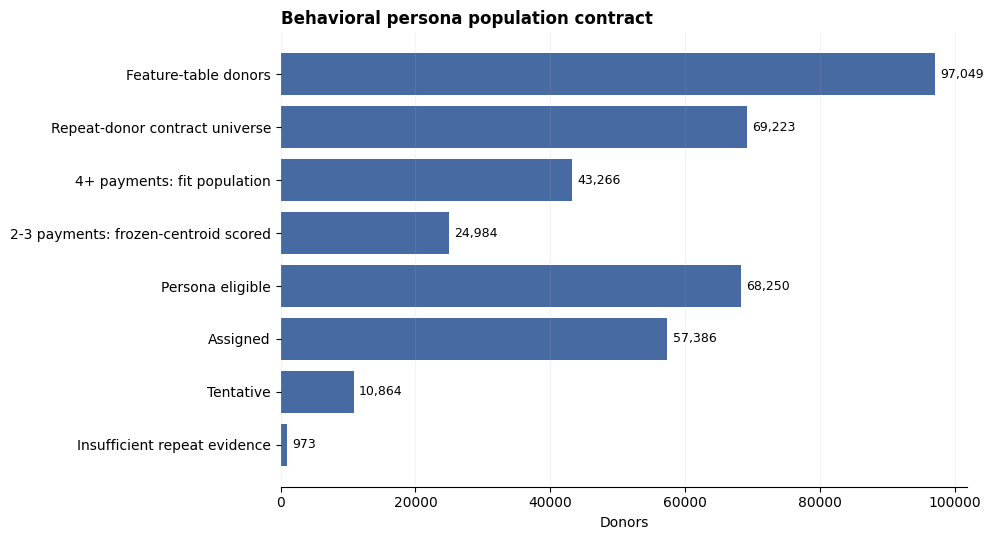

**Database-language caveat:** throughout the feature build, a `gift` is a payment row in the DonorProjectRecords export. A single checkout can create multiple project-payment rows. Multiple same-day payments therefore do not, by themselves, prove repeated giving occasions. The conservative same-day gate can also withhold a donor who genuinely made separate gifts on the same day; timestamps, checkout IDs, or another occasion key would resolve that edge case.

Feature,Missing before fit imputation,Measured coverage,Dimension
top_category_share_count_24m,0.1%,99.9%,choice_breadth
median_gift_to_project_cost_ratio_24m,7.0%,93.0%,giving_approach
modal_amount_share_24m,0.0%,100.0%,giving_approach
share_gifts_closed_project_24m,0.0%,100.0%,giving_approach
share_gifts_first_money_in_24m,0.0%,100.0%,giving_approach
share_gifts_round_amount_24m,0.0%,100.0%,giving_approach
entropy_gift_month_norm_24m,0.0%,100.0%,giving_rhythm
gifts_per_active_month_24m,0.0%,100.0%,giving_rhythm
share_gifts_within_15mi_24m,16.1%,83.9%,jtbd_local_stewardship
share_gifts_to_historically_underrepresented_race_schools_24m,0.0%,100.0%,jtbd_values_equity


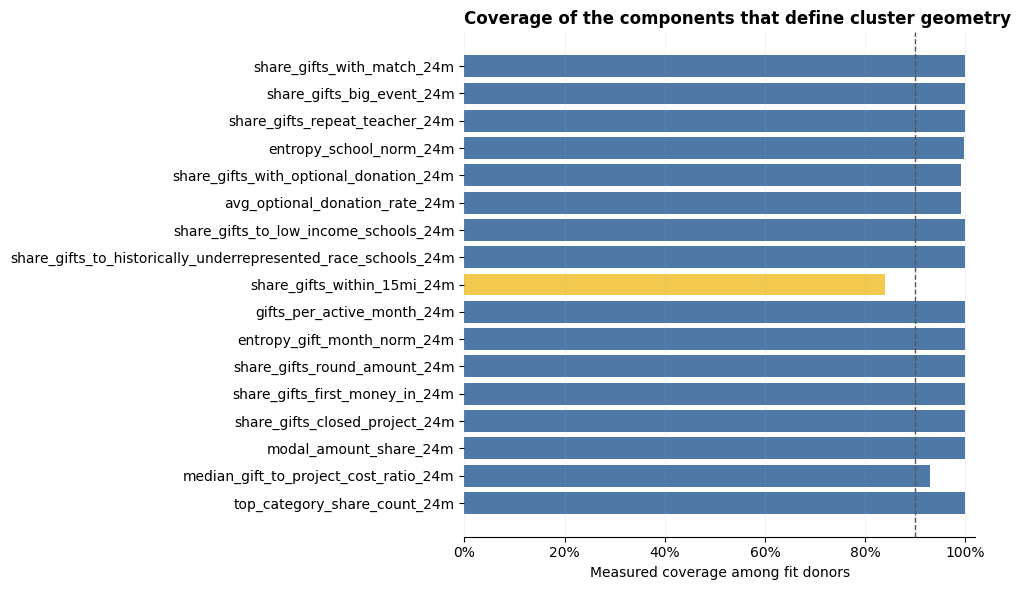

K,silhouette,stability_ARI_mean,stability_ARI_p10,smallest_cluster,largest_cluster,inertia_per_donor,silhouette_n
5,0.145,0.978,0.968,16.7%,23.7%,3.155,"5,000"
6,0.144,0.973,0.960,8.2%,22.3%,2.991,"5,000"
7,0.149,0.979,0.971,8.0%,20.6%,2.842,"5,000"
8,0.144,0.960,0.941,6.6%,19.2%,2.727,"5,000"
9,0.141,0.904,0.712,6.1%,18.4%,2.635,"5,000"
10,0.145,0.955,0.943,5.3%,18.2%,2.546,"5,000"
11,0.139,0.887,0.696,4.0%,14.5%,2.475,"5,000"
12,0.132,0.751,0.642,4.2%,13.5%,2.415,"5,000"


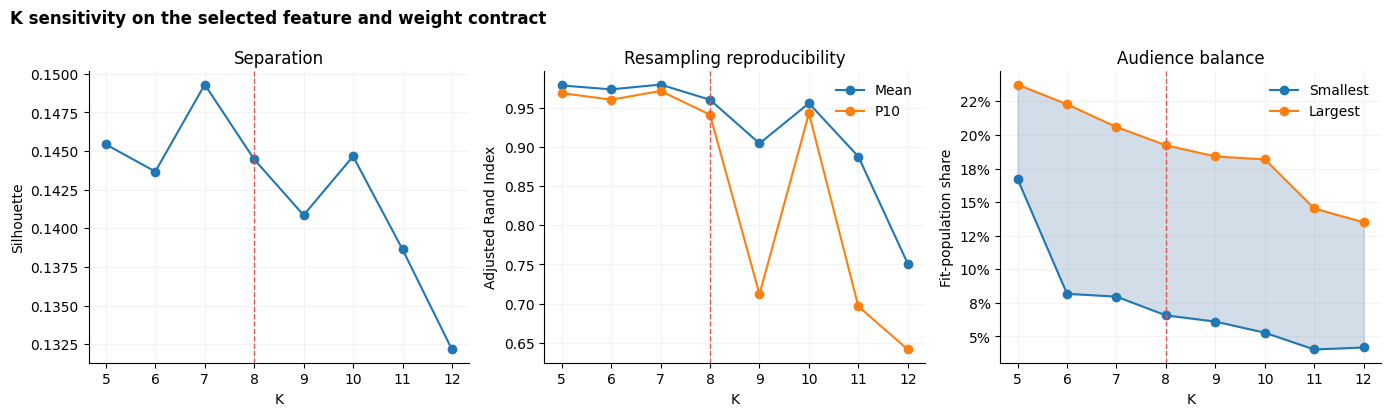

cluster,Cluster,agreement_mean,agreement_p10,jaccard_mean,jaccard_p10,centroid_shift_mean,centroid_shift_p90,Most common competing cluster
1,C1 Routine Classroom Explorers,99.4%,99.0%,98.6%,98.0%,0.02,0.02,C2 Steady Local Classroom Regulars
2,C2 Steady Local Classroom Regulars,98.7%,97.7%,97.7%,96.4%,0.03,0.04,C4 Independent Classroom Closers
3,C3 Match-Activated Classroom Insiders,98.9%,98.5%,97.6%,96.5%,0.03,0.04,C8 Campaign-Activated High-Impact Explorers
4,C4 Independent Classroom Closers,99.0%,97.9%,97.9%,96.4%,0.03,0.04,C2 Steady Local Classroom Regulars
5,C5 Category-Focused Classroom Specialists,98.6%,97.3%,97.6%,95.7%,0.03,0.06,C7 Burst-Mode Portfolio Closers
6,C6 Long-Distance Classroom Loyalists,99.7%,99.4%,99.2%,98.9%,0.02,0.03,C1 Routine Classroom Explorers
7,C7 Burst-Mode Portfolio Closers,98.2%,96.5%,96.9%,93.8%,0.04,0.08,C3 Match-Activated Classroom Insiders
8,C8 Campaign-Activated High-Impact Explorers,98.3%,96.6%,96.5%,94.4%,0.05,0.09,C3 Match-Activated Classroom Insiders


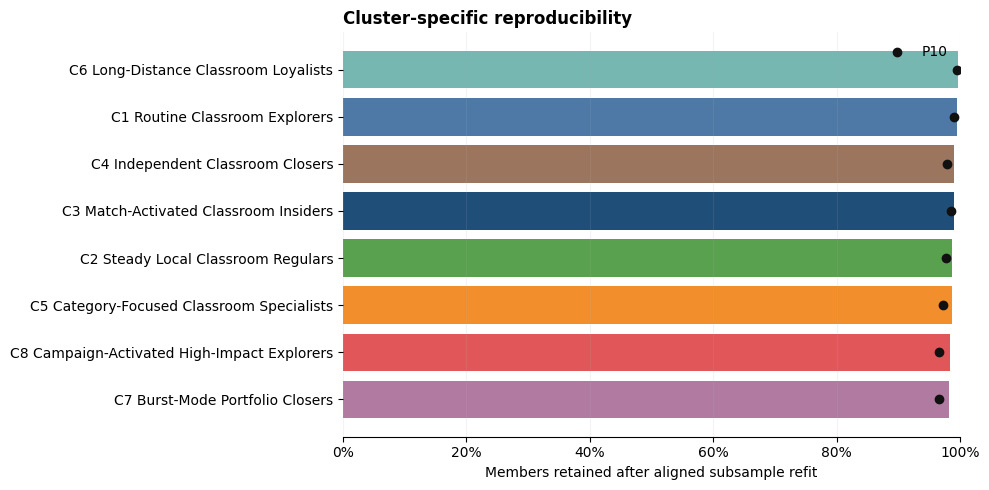

/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out,

Cluster,gift_group,assigned,tentative,Total,Assigned share
C1 Routine Classroom Explorers,2 payments,968,"1,577","2,545",38.0%
C1 Routine Classroom Explorers,3 payments,"1,487",432,"1,919",77.5%
C1 Routine Classroom Explorers,4+ payments,"8,321",0,"8,321",100.0%
C2 Steady Local Classroom Regulars,2 payments,"1,107","1,659","2,766",40.0%
C2 Steady Local Classroom Regulars,3 payments,"1,849",662,"2,511",73.6%
C2 Steady Local Classroom Regulars,4+ payments,"7,833",0,"7,833",100.0%
C3 Match-Activated Classroom Insiders,2 payments,354,821,"1,175",30.1%
C3 Match-Activated Classroom Insiders,3 payments,846,285,"1,131",74.8%
C3 Match-Activated Classroom Insiders,4+ payments,"6,303",0,"6,303",100.0%
C4 Independent Classroom Closers,2 payments,738,"1,729","2,467",29.9%


cluster,Cluster,gift_group,donors,margin_ratio_p10,margin_ratio_median,margin_above_requirement_median,distance_to_limit_median
1,C1 Routine Classroom Explorers,2 payments,"2,545",0.039,0.180,+0.044,1.00x
1,C1 Routine Classroom Explorers,3 payments,"1,919",0.044,0.228,+0.175,0.79x
1,C1 Routine Classroom Explorers,4+ payments,"8,321",0.053,0.278,+nan,nanx
2,C2 Steady Local Classroom Regulars,2 payments,"2,766",0.031,0.184,+0.066,1.04x
2,C2 Steady Local Classroom Regulars,3 payments,"2,511",0.043,0.207,+0.160,0.80x
2,C2 Steady Local Classroom Regulars,4+ payments,"7,833",0.047,0.232,+nan,nanx
3,C3 Match-Activated Classroom Insiders,2 payments,"1,175",0.022,0.153,+0.042,1.05x
3,C3 Match-Activated Classroom Insiders,3 payments,"1,131",0.036,0.199,+0.153,0.77x
3,C3 Match-Activated Classroom Insiders,4+ payments,"6,303",0.046,0.233,+nan,nanx
4,C4 Independent Classroom Closers,2 payments,"2,467",0.030,0.141,+0.024,1.02x


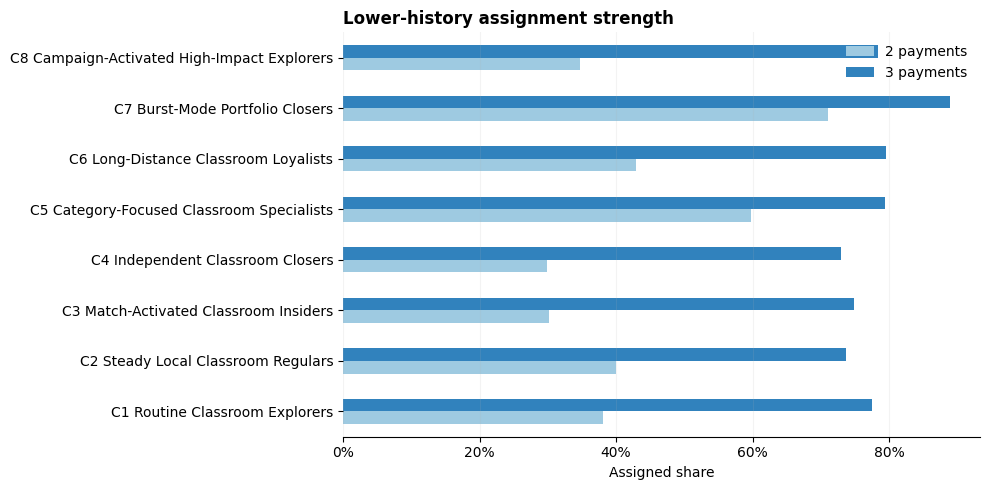

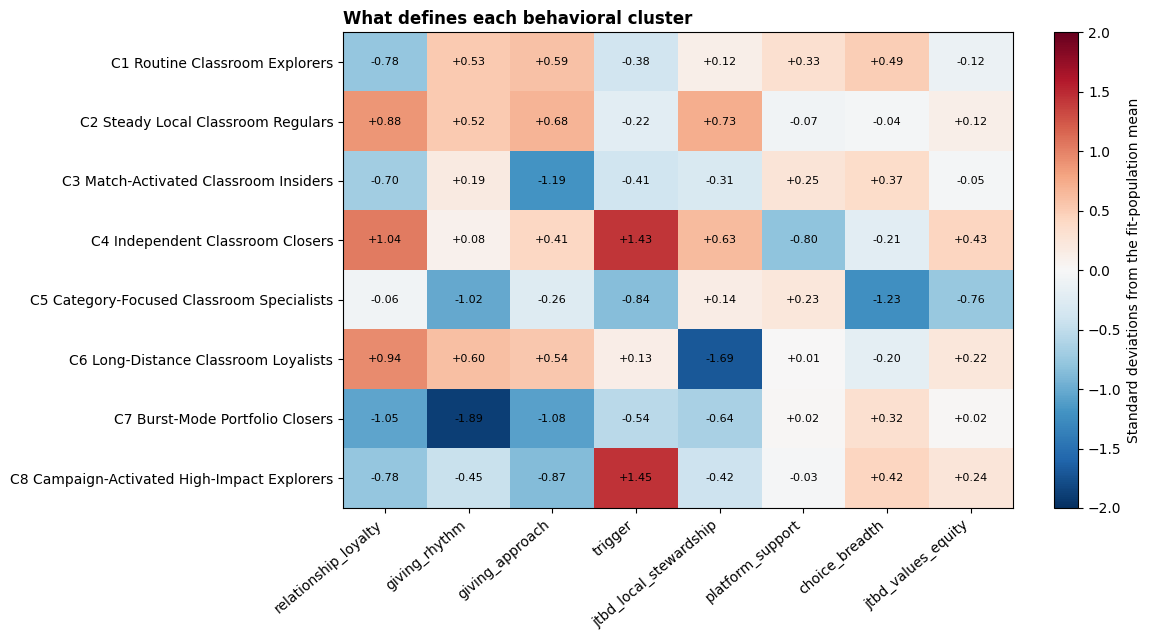

Cluster,Nearest cluster,Centroid distance
C1 Routine Classroom Explorers,C2 Steady Local Classroom Regulars,1.78
C2 Steady Local Classroom Regulars,C6 Long-Distance Classroom Loyalists,1.76
C3 Match-Activated Classroom Insiders,C1 Routine Classroom Explorers,1.84
C4 Independent Classroom Closers,C2 Steady Local Classroom Regulars,1.78
C5 Category-Focused Classroom Specialists,C7 Burst-Mode Portfolio Closers,2.04
C6 Long-Distance Classroom Loyalists,C2 Steady Local Classroom Regulars,1.76
C7 Burst-Mode Portfolio Closers,C5 Category-Focused Classroom Specialists,2.04
C8 Campaign-Activated High-Impact Explorers,C3 Match-Activated Classroom Insiders,2.00


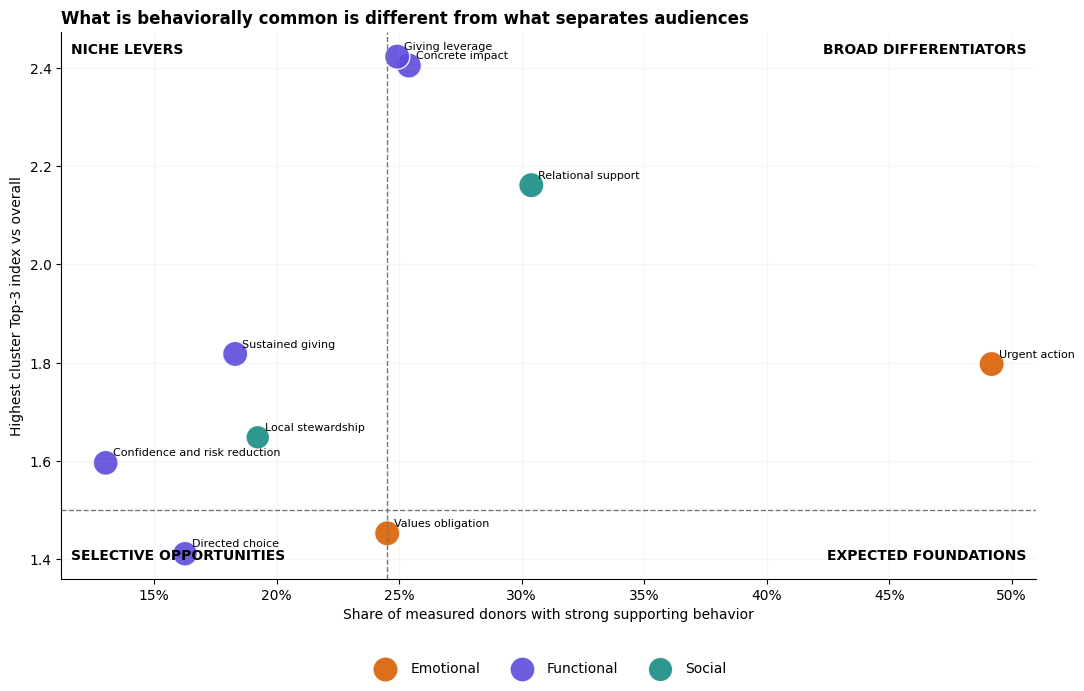

Behavioral Job,Dimension,Measured coverage %,Strong signal among measured %,overall_top_n_share,highest_cluster_index,portfolio_index_spread
Giving leverage,Functional,100.0%,24.9%,31.2%,2.42x,2.20
Concrete impact,Functional,100.0%,25.4%,36.0%,2.40x,2.13
Relational support,Social,99.8%,30.4%,35.2%,2.16x,2.02
Sustained giving,Functional,100.0%,18.3%,36.6%,1.82x,1.48
Urgent action,Emotional,99.9%,49.2%,33.2%,1.80x,1.54
Local stewardship,Social,83.4%,19.2%,35.6%,1.65x,1.65
Confidence and risk reduction,Functional,97.0%,13.0%,29.1%,1.60x,1.25
Values obligation,Emotional,100.0%,24.5%,30.1%,1.45x,0.96
Directed choice,Functional,95.0%,16.3%,33.1%,1.41x,0.68


Job A,Job B,Observed donors,Observed pair share,Expected pair share,Pair lift,Excess share
Directed choice,Confidence and risk reduction,"5,541",12.2%,9.6%,1.26x,+2.5%
Concrete impact,Urgent action,"6,599",14.5%,12.0%,1.21x,+2.5%
Confidence and risk reduction,Relational support,"5,219",11.5%,10.2%,1.12x,+1.2%
Giving leverage,Values obligation,"4,642",10.2%,9.4%,1.09x,+0.8%
Sustained giving,Urgent action,"5,857",12.9%,12.1%,1.06x,+0.7%
Directed choice,Relational support,"4,944",10.9%,11.6%,0.93x,-0.8%
Concrete impact,Sustained giving,"5,451",12.0%,13.2%,0.91x,-1.2%
Local stewardship,Urgent action,"4,696",10.3%,11.8%,0.87x,-1.5%
Giving leverage,Relational support,"4,260",9.4%,11.0%,0.85x,-1.6%
Confidence and risk reduction,Local stewardship,"4,000",8.8%,10.4%,0.85x,-1.6%


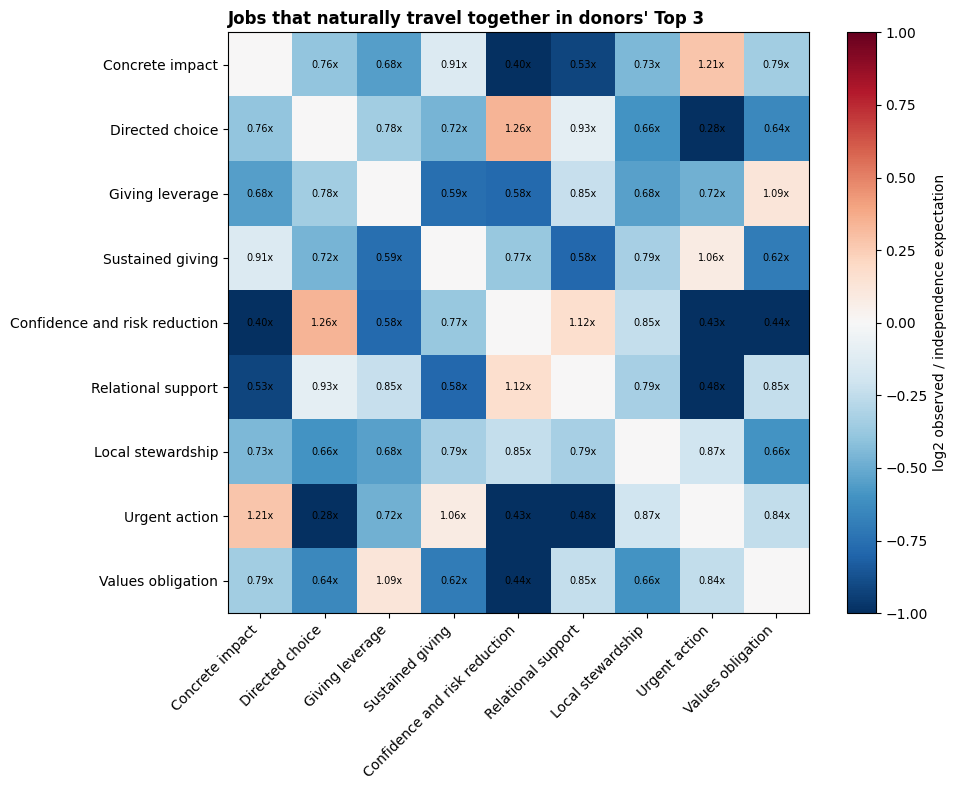

cluster,Cluster,Attribute,Cluster share,Overall share,Index,Coverage
1,C1 Routine Classroom Explorers,Teacher account,6.5%,21.3%,0.31x,100.0%
1,C1 Routine Classroom Explorers,Teacher-referred,47.4%,49.6%,0.96x,100.0%
1,C1 Routine Classroom Explorers,Current monthly donor,5.5%,2.8%,1.95x,100.0%
1,C1 Routine Classroom Explorers,Marketing subscribed,80.3%,75.0%,1.07x,100.0%
1,C1 Routine Classroom Explorers,Major-gift donor,0.0%,0.0%,0.00x,100.0%
1,C1 Routine Classroom Explorers,New donor,15.0%,16.3%,0.92x,100.0%
1,C1 Routine Classroom Explorers,Reactivated donor,5.9%,7.0%,0.83x,100.0%
1,C1 Routine Classroom Explorers,Continuing donor,79.2%,76.6%,1.03x,100.0%
2,C2 Steady Local Classroom Regulars,Teacher account,36.7%,21.3%,1.72x,100.0%
2,C2 Steady Local Classroom Regulars,Teacher-referred,61.3%,49.6%,1.24x,100.0%


/opt/miniconda3/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)


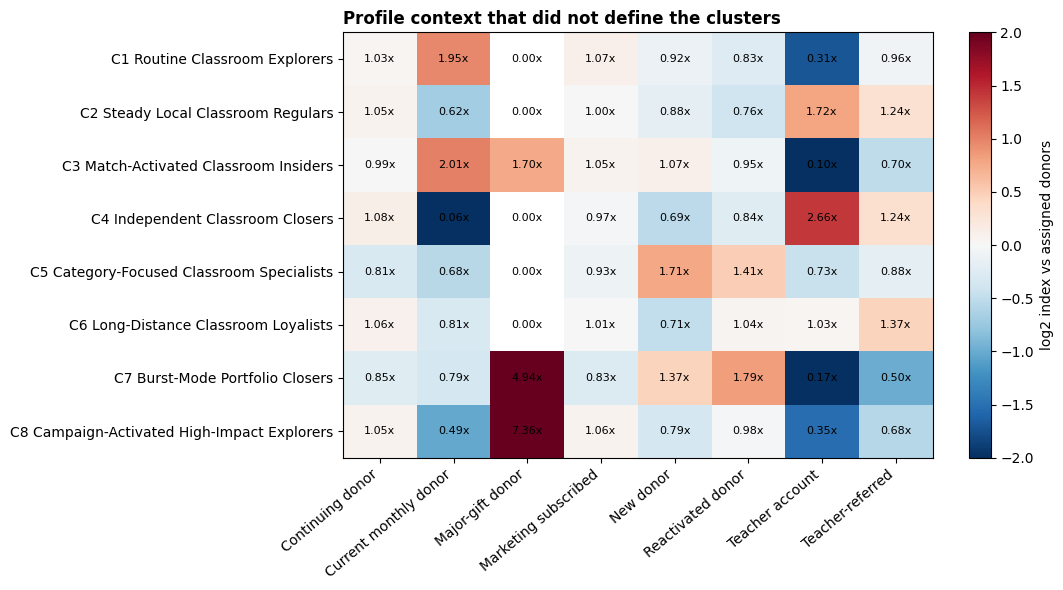

cluster,Cluster,Assigned donors,Teacher donors,Teacher share,Teachers with self-giving data,Mean self-gift share among teachers,Median self-gift share among teachers,Never self,Mixed self + other,Only self,Missing self-giving data
1,C1 Routine Classroom Explorers,"10,776",700,6.5%,700,12.1%,0.0%,59.1%,40.9%,0.0%,0.0%
2,C2 Steady Local Classroom Regulars,"10,789","3,960",36.7%,"3,960",70.7%,81.8%,10.2%,65.3%,24.5%,0.0%
3,C3 Match-Activated Classroom Insiders,"7,503",157,2.1%,157,21.6%,0.0%,53.5%,43.9%,2.5%,0.0%
4,C4 Independent Classroom Closers,"8,218","4,649",56.6%,"4,649",82.3%,92.0%,4.4%,55.3%,40.3%,0.0%
5,C5 Category-Focused Classroom Specialists,"7,089","1,106",15.6%,"1,106",69.0%,85.7%,14.6%,48.7%,36.7%,0.0%
6,C6 Long-Distance Classroom Loyalists,"5,670","1,243",21.9%,"1,243",71.1%,84.6%,13.0%,59.0%,28.1%,0.0%
7,C7 Burst-Mode Portfolio Closers,"3,874",142,3.7%,142,14.5%,6.0%,47.2%,51.4%,1.4%,0.0%
8,C8 Campaign-Activated High-Impact Explorers,"3,467",258,7.4%,258,27.3%,24.4%,24.4%,74.0%,1.6%,0.0%


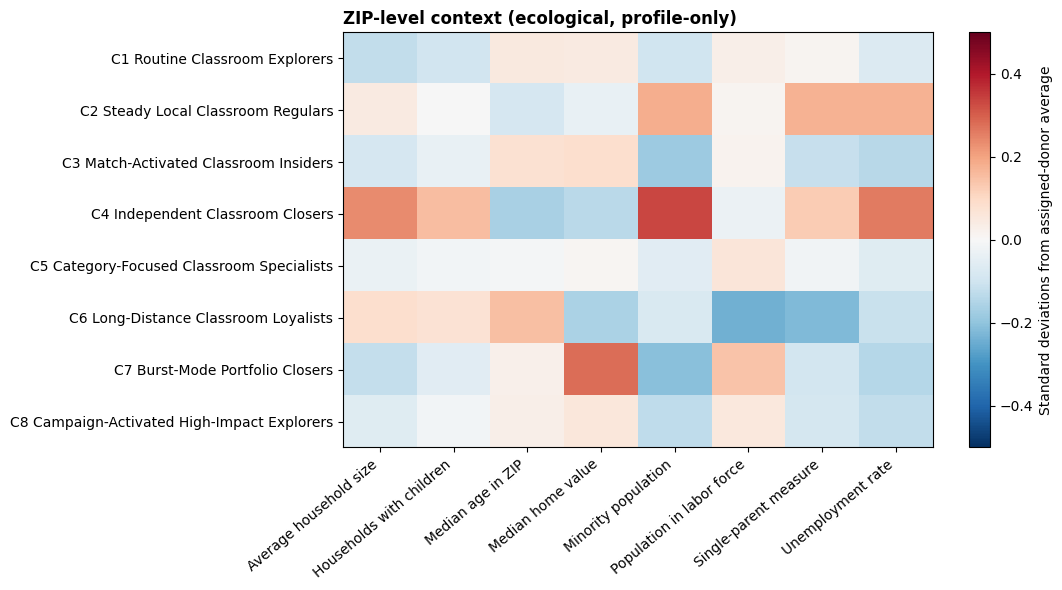

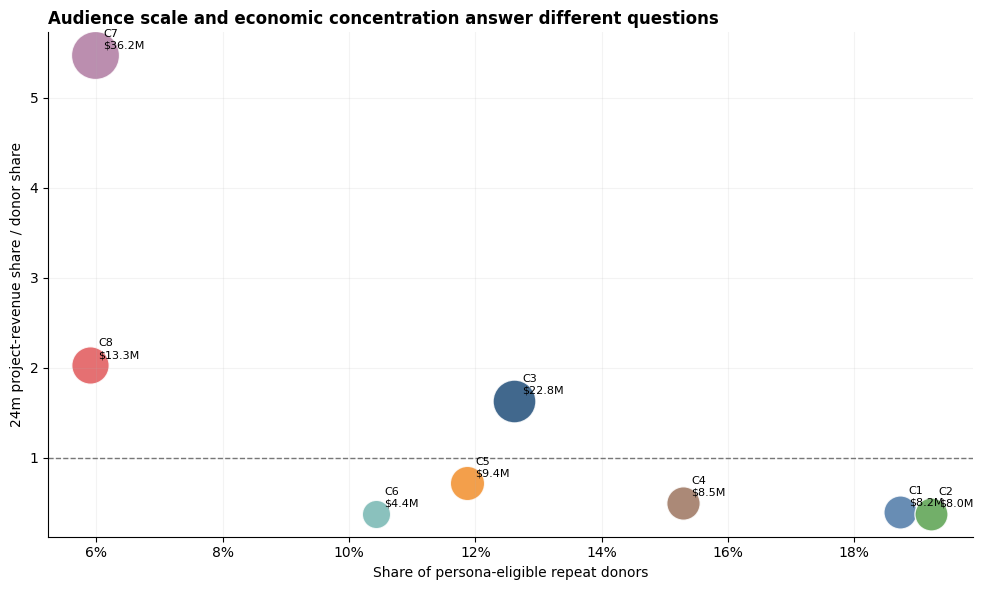

Cluster,donor_share,revenue_dollars,revenue_share,revenue_index_vs_donor_share
C1 Routine Classroom Explorers,18.7%,"$8,189,111",7.4%,0.39x
C2 Steady Local Classroom Regulars,19.2%,"$8,044,453",7.3%,0.38x
C3 Match-Activated Classroom Insiders,12.6%,"$22,804,337",20.6%,1.63x
C4 Independent Classroom Closers,15.3%,"$8,453,904",7.6%,0.50x
C5 Category-Focused Classroom Specialists,11.9%,"$9,403,073",8.5%,0.72x
C6 Long-Distance Classroom Loyalists,10.4%,"$4,382,597",4.0%,0.38x
C7 Burst-Mode Portfolio Closers,6.0%,"$36,171,125",32.7%,5.47x
C8 Campaign-Activated High-Impact Explorers,5.9%,"$13,267,905",12.0%,2.03x


Population,cluster,Cluster,Donors,Rate coverage,Mean donor-average optional rate,Median donor-average optional rate,Mean share of payments with optional donation,Always opted out,Optional donation on every observed payment,Detected rate scale
Assigned profile base,1,C1 Routine Classroom Explorers,"10,776",99.4%,13.58%,15.00%,93.5%,1.5%,84.1%,stored as percentage points; divided by 100 for display
Assigned profile base,2,C2 Steady Local Classroom Regulars,"10,789",99.7%,11.88%,15.00%,81.6%,5.2%,64.5%,stored as percentage points; divided by 100 for display
Assigned profile base,3,C3 Match-Activated Classroom Insiders,"7,503",99.9%,13.17%,15.00%,91.5%,2.5%,81.0%,stored as percentage points; divided by 100 for display
Assigned profile base,4,C4 Independent Classroom Closers,"8,218",100.0%,8.55%,10.00%,59.2%,17.3%,41.2%,stored as percentage points; divided by 100 for display
Assigned profile base,5,C5 Category-Focused Classroom Specialists,"7,089",90.5%,12.95%,15.00%,89.1%,4.2%,72.9%,stored as percentage points; divided by 100 for display
Assigned profile base,6,C6 Long-Distance Classroom Loyalists,"5,670",99.7%,12.38%,15.00%,84.8%,4.5%,71.2%,stored as percentage points; divided by 100 for display
Assigned profile base,7,C7 Burst-Mode Portfolio Closers,"3,874",99.5%,12.08%,15.00%,85.4%,5.8%,75.5%,stored as percentage points; divided by 100 for display
Assigned profile base,8,C8 Campaign-Activated High-Impact Explorers,"3,467",99.9%,11.94%,15.00%,84.3%,5.6%,73.1%,stored as percentage points; divided by 100 for display
All persona-eligible repeat donors,1,C1 Routine Classroom Explorers,"12,785",99.0%,13.43%,15.00%,92.4%,2.5%,83.4%,stored as percentage points; divided by 100 for display
All persona-eligible repeat donors,2,C2 Steady Local Classroom Regulars,"13,110",99.5%,11.83%,15.00%,81.2%,6.7%,65.6%,stored as percentage points; divided by 100 for display


Optional-dollar-like fields available for semantic review: none


### Calculated optional-donation dollars

These are **not directly observed donor-level receipts**. They reproduce the available database convention: round each donor's Green revenue × average optional-donation rate to a whole dollar, then aggregate. Green revenue is reconstructed as `gift_amount_24m` × `share_amount_green_optin_24m`; the rate is stored as percentage points; divided by 100 for display. If the production database instead calculates and rounds at payment or checkout grain, small reconciliation differences are expected.

Cluster,donors,donors_with_calculation,green_revenue,calculated_optional_dollars,calculated_dollar_share,calculated_rate_on_green_revenue,calculated_dollars_per_donor
C1 Routine Classroom Explorers,"12,785","12,663","$5,945,495","$778,133",8.6%,13.09%,$60.86
C2 Steady Local Classroom Regulars,"13,110","13,050","$5,550,217","$644,685",7.1%,11.62%,$49.18
C3 Match-Activated Classroom Insiders,"8,609","8,599","$18,647,860","$2,350,434",26.0%,12.60%,$273.02
C4 Independent Classroom Closers,"10,430","10,425","$5,773,514","$406,484",4.5%,7.04%,$38.97
C5 Category-Focused Classroom Specialists,"8,096","7,383","$6,753,600","$810,885",9.0%,12.01%,$100.16
C6 Long-Distance Classroom Loyalists,"7,118","7,084","$3,371,798","$399,177",4.4%,11.84%,$56.08
C7 Burst-Mode Portfolio Closers,"4,075","4,053","$26,757,974","$2,654,730",29.4%,9.92%,$651.47
C8 Campaign-Activated High-Impact Explorers,"4,027","4,023","$10,316,048","$998,556",11.0%,9.68%,$247.97


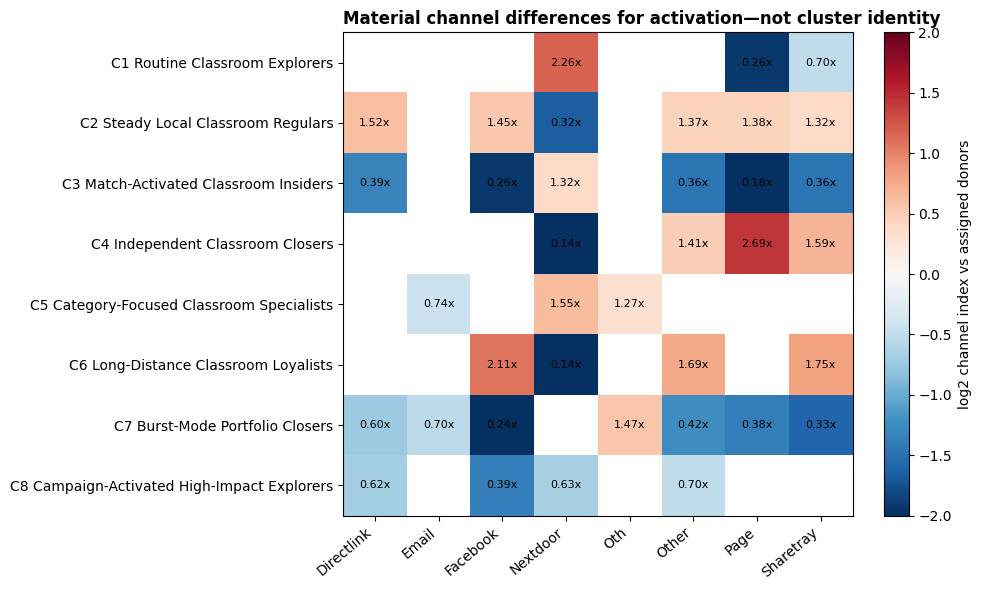

cluster,Cluster,Assigned donors,Marketing subscribed,Marketing subscribed share,Gift in last 180 days,Gift in last 180 days share,Gift in last 365 days,Gift in last 365 days share,Observed email opener,Observed email opener share,Observed email clicker,Observed email clicker share
1,C1 Routine Classroom Explorers,"10,776","8,654",80.3%,"7,121",66.1%,"9,641",89.5%,"10,690",99.2%,"10,409",96.6%
2,C2 Steady Local Classroom Regulars,"10,789","8,070",74.8%,"7,038",65.2%,"9,561",88.6%,"10,716",99.3%,"10,473",97.1%
3,C3 Match-Activated Classroom Insiders,"7,503","5,922",78.9%,"5,168",68.9%,"6,758",90.1%,"7,470",99.6%,"7,330",97.7%
4,C4 Independent Classroom Closers,"8,218","5,982",72.8%,"4,578",55.7%,"6,862",83.5%,"8,177",99.5%,"7,981",97.1%
5,C5 Category-Focused Classroom Specialists,"7,089","4,949",69.8%,"3,548",50.0%,"5,499",77.6%,"6,978",98.4%,"6,566",92.6%
6,C6 Long-Distance Classroom Loyalists,"5,670","4,285",75.6%,"3,524",62.2%,"4,892",86.3%,"5,639",99.5%,"5,472",96.5%
7,C7 Burst-Mode Portfolio Closers,"3,874","2,408",62.2%,"1,783",46.0%,"2,982",77.0%,"3,805",98.2%,"3,536",91.3%
8,C8 Campaign-Activated High-Impact Explorers,"3,467","2,742",79.1%,"1,759",50.7%,"2,851",82.2%,"3,438",99.2%,"3,357",96.8%


cluster,Cluster,Recommended posture,Why,Eligible donors,Eligible share,Assigned donors,24m revenue index,Marketing subscribed share
1,C1 Routine Classroom Explorers,HOLD AS BAU / CONTROL,"Large, stable baseline with less need for an immediately unique treatment.","12,785",18.7%,"10,776",0.39x,80.3%
2,C2 Steady Local Classroom Regulars,TEST NOW,Large audience with a concrete local-and-relationship treatment hypothesis.,"13,110",19.2%,"10,789",0.38x,74.8%
3,C3 Match-Activated Classroom Insiders,TEST NOW,Match activation layered onto strong classroom relationships is distinctive and directly testable.,"8,609",12.6%,"7,503",1.63x,78.9%
4,C4 Independent Classroom Closers,TEST NOW,A clear independent close-the-gap treatment can be tested without relying on campaign timing.,"10,430",15.3%,"8,218",0.50x,72.8%
5,C5 Category-Focused Classroom Specialists,TEST NOW,Category concentration and Classroom Essentials affinity support a focused discovery and merchandising test.,"8,096",11.9%,"7,089",0.72x,69.8%
6,C6 Long-Distance Classroom Loyalists,LEARN FIRST,"Long-distance relationship loyalty is coherent, but its origin and best treatment need deeper learning.","7,118",10.4%,"5,670",0.38x,75.6%
7,C7 Burst-Mode Portfolio Closers,PROTECT AND LEARN,Exceptional value concentration and burst-mode portfolio giving warrant controlled learning before scale.,"4,075",6.0%,"3,874",5.47x,62.2%
8,C8 Campaign-Activated High-Impact Explorers,PROTECT AND LEARN,Campaign-responsive high-impact giving is valuable and should be tested without disrupting proven event behavior.,"4,027",5.9%,"3,467",2.03x,79.1%


cluster,Cluster,Current fit share,Prior fit share,Share change,Centroid correlation,Centroid distance
1,C1 Routine Classroom Explorers,19.2%,20.0%,-0.8%,1.00,0.05
2,C2 Steady Local Classroom Regulars,18.1%,18.0%,+0.1%,0.99,0.15
3,C3 Match-Activated Classroom Insiders,14.6%,13.8%,+0.8%,1.00,0.13
4,C4 Independent Classroom Closers,14.3%,15.0%,-0.7%,0.99,0.27
5,C5 Category-Focused Classroom Specialists,11.7%,9.7%,+2.0%,0.89,0.59
6,C6 Long-Distance Classroom Loyalists,8.3%,9.0%,-0.7%,1.00,0.12
7,C7 Burst-Mode Portfolio Closers,7.2%,6.7%,+0.5%,1.00,0.18
8,C8 Campaign-Activated High-Impact Explorers,6.6%,7.8%,-1.2%,1.00,0.15


,Metric,Value
0,Prior fit donors,46545.000000
1,Current fit donors,43266.000000
2,Shared fit donors,31455.000000
3,Shared-donor ARI,0.495548
4,Shared-donor exact aligned agreement,0.734541


**Interpretation:** the centroid comparison tests whether the same behavioral structures appear in the 2025-09-01 and 2026-09-01 windows. Shared-donor movement is a mixture of real donor behavior change and model/window change; it should not be reported as model error.

In [34]:
"""
Report-support cells for Behavioral_Clustering_20260831_Channel_Profile v08(6).

Usage
-----
Open this file in an editor that recognizes ``# %%`` cells, or copy individual
cells into the executed v08 notebook after its existing analytical cells.

The cells deliberately use the current v08 objects instead of reopening the
current feature file.  The final cross-window cell is the exception: it asks
for a prior feature-snapshot path because temporal validation requires another
window.

All business-facing labels below are fresh report labels.  They do not use the
hard-coded aliases in the notebook as analytical evidence.
"""


# %% [markdown]
# 0. Shared setup and report labels

# %%
from __future__ import annotations

from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score


REPORT_CLUSTER_LABELS = {
    1: "Routine Classroom Explorers",
    2: "Steady Local Classroom Regulars",
    3: "Independent Classroom Closers",
    4: "Match-Activated Classroom Insiders",
    5: "Category-Focused Classroom Specialists",
    6: "Long-Distance Classroom Loyalists",
    7: "Burst-Mode Portfolio Closers",
    8: "Campaign-Activated High-Impact Explorers",
}


def report_cluster_label(cluster) -> str:
    cluster = int(cluster)
    return f"C{cluster} {REPORT_CLUSTER_LABELS.get(cluster, f'Cluster {cluster}')}"


def require_objects(*names: str) -> None:
    missing = [name for name in names if name not in globals()]
    if missing:
        raise RuntimeError(
            "Run the existing v08 notebook through its analytical sections first. "
            f"Missing objects: {missing}"
        )


def canonical_id(index_like) -> pd.Index:
    """Normalize numeric/string donor IDs for safe cross-file matching."""
    s = pd.Index(index_like).astype("string").str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    return pd.Index(s, name="donor_id")


REPORT_COLORS = {
    1: "#4E79A7",
    2: "#59A14F",
    3: "#1F4E79",
    4: "#9C755F",
    5: "#F28E2B",
    6: "#76B7B2",
    7: "#B07AA1",
    8: "#E15759",
}


# %% [markdown]
# 1. Population contract and funnel
#
# This is not a conventional narrowing funnel: the 4+ fit population and the
# 2-3-payment scored population combine to form the persona-eligible audience.
# The chart therefore reports each contract population explicitly.

# %%
require_objects(
    "FEATURES",
    "DONORS",
    "SCORED_REPEAT_DONORS",
    "BUSINESS_DONORS",
    "PERSONA_PROFILE_BASE",
    "PERSONA_ASSIGNMENTS",
    "INSUFFICIENT_REPEAT_EVIDENCE_DONORS",
)

_status = PERSONA_ASSIGNMENTS["persona_status"].astype("string")
_funnel_rows = [
    ("Feature-table donors", len(FEATURES), "Source universe"),
    (
        "Repeat-donor contract universe",
        len(BUSINESS_DONORS) + len(INSUFFICIENT_REPEAT_EVIDENCE_DONORS),
        "Persona eligible plus insufficient repeat evidence",
    ),
    ("4+ payments: fit population", len(DONORS), "Defines geometry"),
    ("2-3 payments: frozen-centroid scored", len(SCORED_REPEAT_DONORS), "Cannot change fit"),
    ("Persona eligible", len(BUSINESS_DONORS), "Assigned plus tentative"),
    ("Assigned", int(_status.eq("assigned").sum()), "Profile and persona activation"),
    ("Tentative", int(_status.eq("tentative").sum()), "Sizing only; no persona targeting"),
    (
        "Insufficient repeat evidence",
        len(INSUFFICIENT_REPEAT_EVIDENCE_DONORS),
        "Not centroid-scored",
    ),
]

REPORT_POPULATION_FUNNEL = pd.DataFrame(
    _funnel_rows, columns=["Population", "Donors", "Use"]
)
REPORT_POPULATION_FUNNEL["Share of feature table"] = (
    REPORT_POPULATION_FUNNEL["Donors"] / len(FEATURES)
)

display(
    REPORT_POPULATION_FUNNEL.style.format(
        {"Donors": "{:,.0f}", "Share of feature table": "{:.1%}"}
    ).hide(axis="index")
)

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_funnel = REPORT_POPULATION_FUNNEL.iloc[::-1]
bars = ax.barh(
    plot_funnel["Population"],
    plot_funnel["Donors"],
    color="#2F5597",
    alpha=0.88,
)
for bar, value in zip(bars, plot_funnel["Donors"]):
    ax.text(
        bar.get_width() + len(FEATURES) * 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value):,}",
        va="center",
        fontsize=9,
    )
ax.set_title("Behavioral persona population contract", loc="left", fontweight="bold")
ax.set_xlabel("Donors")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.15)
plt.tight_layout()
plt.show()

display(
    Markdown(
        "**Database-language caveat:** throughout the feature build, a `gift` is a "
        "payment row in the DonorProjectRecords export. A single checkout can create "
        "multiple project-payment rows. Multiple same-day payments therefore do not, "
        "by themselves, prove repeated giving occasions. The conservative same-day "
        "gate can also withhold a donor who genuinely made separate gifts on the same "
        "day; timestamps, checkout IDs, or another occasion key would resolve that edge case."
    )
)


# %% [markdown]
# 2. Active-feature coverage for a concise report exhibit

# %%
require_objects("PREP", "UNITS_NOW")

_feature_to_unit = {
    field: unit for unit, spec in UNITS_NOW.items() for field in spec
}
REPORT_FIT_FEATURE_COVERAGE = pd.DataFrame(
    {
        "Feature": list(PREP["fields"]),
        "Missing before fit imputation": [
            float(PREP["missing_before"][field]) for field in PREP["fields"]
        ],
    }
)
REPORT_FIT_FEATURE_COVERAGE["Measured coverage"] = (
    1 - REPORT_FIT_FEATURE_COVERAGE["Missing before fit imputation"]
)
REPORT_FIT_FEATURE_COVERAGE["Dimension"] = REPORT_FIT_FEATURE_COVERAGE[
    "Feature"
].map(_feature_to_unit)
REPORT_FIT_FEATURE_COVERAGE = REPORT_FIT_FEATURE_COVERAGE.sort_values(
    ["Dimension", "Measured coverage", "Feature"]
).reset_index(drop=True)

display(
    REPORT_FIT_FEATURE_COVERAGE.style.format(
        {
            "Missing before fit imputation": "{:.1%}",
            "Measured coverage": "{:.1%}",
        }
    ).hide(axis="index")
)

fig, ax = plt.subplots(figsize=(10, max(6, 0.32 * len(REPORT_FIT_FEATURE_COVERAGE))))
colors = np.where(
    REPORT_FIT_FEATURE_COVERAGE["Measured coverage"] >= 0.90,
    "#4E79A7",
    np.where(
        REPORT_FIT_FEATURE_COVERAGE["Measured coverage"] >= 0.75,
        "#F2C94C",
        "#E15759",
    ),
)
ax.barh(
    REPORT_FIT_FEATURE_COVERAGE["Feature"],
    REPORT_FIT_FEATURE_COVERAGE["Measured coverage"],
    color=colors,
)
ax.axvline(0.90, color="#555", linestyle="--", linewidth=1)
ax.set_xlim(0, 1.02)
ax.set_xlabel("Measured coverage among fit donors")
ax.set_title("Coverage of the components that define cluster geometry", loc="left", fontweight="bold")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.15)
plt.tight_layout()
plt.show()


# %% [markdown]
# 3. K-range diagnostics using the exact v08 weighted geometry
#
# This can take several minutes because each K includes repeated subsample fits.

# %%
require_objects("Z", "k_diagnostics")

REPORT_K_VALUES = list(range(5, 13))
REPORT_K_DIAGNOSTICS = k_diagnostics(Z, k_values=REPORT_K_VALUES)
display(
    REPORT_K_DIAGNOSTICS.style.format(
        {
            "silhouette": "{:.3f}",
            "stability_ARI_mean": "{:.3f}",
            "stability_ARI_p10": "{:.3f}",
            "smallest_cluster": "{:.1%}",
            "largest_cluster": "{:.1%}",
            "inertia_per_donor": "{:.3f}",
            "silhouette_n": "{:,.0f}",
        }
    ).hide(axis="index")
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
axes[0].plot(REPORT_K_DIAGNOSTICS["K"], REPORT_K_DIAGNOSTICS["silhouette"], marker="o")
axes[0].set_title("Separation")
axes[0].set_ylabel("Silhouette")

axes[1].plot(
    REPORT_K_DIAGNOSTICS["K"],
    REPORT_K_DIAGNOSTICS["stability_ARI_mean"],
    marker="o",
    label="Mean",
)
axes[1].plot(
    REPORT_K_DIAGNOSTICS["K"],
    REPORT_K_DIAGNOSTICS["stability_ARI_p10"],
    marker="o",
    label="P10",
)
axes[1].set_title("Resampling reproducibility")
axes[1].set_ylabel("Adjusted Rand Index")
axes[1].legend(frameon=False)

axes[2].fill_between(
    REPORT_K_DIAGNOSTICS["K"],
    REPORT_K_DIAGNOSTICS["smallest_cluster"],
    REPORT_K_DIAGNOSTICS["largest_cluster"],
    alpha=0.25,
    color="#4E79A7",
)
axes[2].plot(
    REPORT_K_DIAGNOSTICS["K"],
    REPORT_K_DIAGNOSTICS["smallest_cluster"],
    marker="o",
    label="Smallest",
)
axes[2].plot(
    REPORT_K_DIAGNOSTICS["K"],
    REPORT_K_DIAGNOSTICS["largest_cluster"],
    marker="o",
    label="Largest",
)
axes[2].set_title("Audience balance")
axes[2].set_ylabel("Fit-population share")
axes[2].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[2].legend(frameon=False)

for ax in axes:
    ax.axvline(SELECTED_K, color="#E15759", linestyle="--", linewidth=1)
    ax.set_xlabel("K")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.15)

fig.suptitle("K sensitivity on the selected feature and weight contract", x=0.01, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()


# %% [markdown]
# 4. Cluster-specific resampling stability
#
# Overall ARI can conceal a weak cluster. This cell aligns every subsample fit
# back to the selected solution and reports agreement, Jaccard overlap, centroid
# movement, and the most common destination when donors move.

# %%
require_objects("Z", "ASSIGNMENTS", "SELECTED_K", "N_INIT", "RANDOM_STATE")

REPORT_CLUSTER_STABILITY_RUNS = 25
REPORT_CLUSTER_STABILITY_SAMPLE_FRAC = 0.80

_X = Z.to_numpy()
_ref = ASSIGNMENTS.loc[Z.index, "cluster"].astype(int).to_numpy()
_clusters = np.arange(1, SELECTED_K + 1)
_full_centroids = pd.DataFrame(_X).assign(cluster=_ref).groupby("cluster").mean()
_rng = np.random.default_rng(RANDOM_STATE + 88_000)
_stability_rows = []
_competitor_counts = {c: pd.Series(0, index=_clusters, dtype=int) for c in _clusters}

for run in range(REPORT_CLUSTER_STABILITY_RUNS):
    sample_n = max(SELECTED_K + 1, int(len(_X) * REPORT_CLUSTER_STABILITY_SAMPLE_FRAC))
    sample_idx = _rng.choice(len(_X), size=sample_n, replace=False)
    alt_model = KMeans(
        n_clusters=SELECTED_K,
        n_init=N_INIT,
        random_state=RANDOM_STATE + 88_000 + run,
    ).fit(_X[sample_idx])
    alt_raw = alt_model.predict(_X)

    contingency = pd.crosstab(
        pd.Categorical(_ref, categories=_clusters),
        pd.Categorical(alt_raw, categories=np.arange(SELECTED_K)),
        dropna=False,
    ).to_numpy()
    ref_rows, alt_cols = linear_sum_assignment(-contingency)
    raw_to_ref = {
        int(alt_col): int(_clusters[ref_row])
        for ref_row, alt_col in zip(ref_rows, alt_cols)
    }
    aligned = np.array([raw_to_ref[int(raw)] for raw in alt_raw], dtype=int)

    for cluster in _clusters:
        ref_mask = _ref == cluster
        alt_mask = aligned == cluster
        intersection = int(np.sum(ref_mask & alt_mask))
        union = int(np.sum(ref_mask | alt_mask))
        agreement = float(np.mean(aligned[ref_mask] == cluster))
        jaccard = intersection / union if union else np.nan
        raw_center = next(raw for raw, mapped in raw_to_ref.items() if mapped == cluster)
        centroid_shift = float(
            np.linalg.norm(
                alt_model.cluster_centers_[raw_center]
                - _full_centroids.loc[cluster].to_numpy()
            )
        )
        moved_to = pd.Series(aligned[ref_mask & (aligned != cluster)]).value_counts()
        if len(moved_to):
            _competitor_counts[cluster] = _competitor_counts[cluster].add(
                moved_to.reindex(_clusters, fill_value=0), fill_value=0
            ).astype(int)
        _stability_rows.append(
            {
                "run": run + 1,
                "cluster": cluster,
                "agreement": agreement,
                "jaccard": jaccard,
                "centroid_shift": centroid_shift,
            }
        )

REPORT_CLUSTER_STABILITY_LONG = pd.DataFrame(_stability_rows)
REPORT_CLUSTER_STABILITY = (
    REPORT_CLUSTER_STABILITY_LONG.groupby("cluster")
    .agg(
        agreement_mean=("agreement", "mean"),
        agreement_p10=("agreement", lambda s: s.quantile(0.10)),
        jaccard_mean=("jaccard", "mean"),
        jaccard_p10=("jaccard", lambda s: s.quantile(0.10)),
        centroid_shift_mean=("centroid_shift", "mean"),
        centroid_shift_p90=("centroid_shift", lambda s: s.quantile(0.90)),
    )
    .reset_index()
)

REPORT_CLUSTER_STABILITY["Most common competing cluster"] = REPORT_CLUSTER_STABILITY[
    "cluster"
].map(
    lambda cluster: (
        report_cluster_label(
            _competitor_counts[int(cluster)]
            .drop(index=int(cluster), errors="ignore")
            .idxmax()
        )
        if _competitor_counts[int(cluster)]
        .drop(index=int(cluster), errors="ignore")
        .sum()
        > 0
        else "None"
    )
)
REPORT_CLUSTER_STABILITY.insert(
    1,
    "Cluster",
    REPORT_CLUSTER_STABILITY["cluster"].map(report_cluster_label),
)

display(
    REPORT_CLUSTER_STABILITY.style.format(
        {
            "agreement_mean": "{:.1%}",
            "agreement_p10": "{:.1%}",
            "jaccard_mean": "{:.1%}",
            "jaccard_p10": "{:.1%}",
            "centroid_shift_mean": "{:.2f}",
            "centroid_shift_p90": "{:.2f}",
        }
    ).hide(axis="index")
)

fig, ax = plt.subplots(figsize=(10, 5))
plot_stability = REPORT_CLUSTER_STABILITY.sort_values("agreement_mean")
ax.barh(
    plot_stability["Cluster"],
    plot_stability["agreement_mean"],
    color=[REPORT_COLORS[int(c)] for c in plot_stability["cluster"]],
)
ax.scatter(
    plot_stability["agreement_p10"],
    plot_stability["Cluster"],
    color="#111",
    label="P10",
    zorder=3,
)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.set_xlabel("Members retained after aligned subsample refit")
ax.set_title("Cluster-specific reproducibility", loc="left", fontweight="bold")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.15)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


# %% [markdown]
# 5. Assignment quality by gift/payment history and cluster

# %%
require_objects("PERSONA_ASSIGNMENTS")

_a = PERSONA_ASSIGNMENTS.copy()
_a["gift_group"] = np.select(
    [
        pd.to_numeric(_a["gift_count"], errors="coerce").eq(2),
        pd.to_numeric(_a["gift_count"], errors="coerce").eq(3),
        pd.to_numeric(_a["gift_count"], errors="coerce").ge(4),
    ],
    ["2 payments", "3 payments", "4+ payments"],
    default="Other",
)

REPORT_ASSIGNMENT_QUALITY = (
    _a.groupby(["cluster", "gift_group", "persona_status"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ["assigned", "tentative"]:
    if col not in REPORT_ASSIGNMENT_QUALITY:
        REPORT_ASSIGNMENT_QUALITY[col] = 0
REPORT_ASSIGNMENT_QUALITY["Total"] = REPORT_ASSIGNMENT_QUALITY[
    ["assigned", "tentative"]
].sum(axis=1)
REPORT_ASSIGNMENT_QUALITY["Assigned share"] = np.divide(
    REPORT_ASSIGNMENT_QUALITY["assigned"],
    REPORT_ASSIGNMENT_QUALITY["Total"],
    out=np.full(len(REPORT_ASSIGNMENT_QUALITY), np.nan),
    where=REPORT_ASSIGNMENT_QUALITY["Total"].gt(0),
)
REPORT_ASSIGNMENT_QUALITY["Cluster"] = REPORT_ASSIGNMENT_QUALITY["cluster"].map(
    report_cluster_label
)

_geometry_rows = []
for (cluster, gift_group), group in _a.groupby(["cluster", "gift_group"], observed=True):
    margin = pd.to_numeric(group.get("assignment_margin_ratio"), errors="coerce")
    required = pd.to_numeric(group.get("required_margin_ratio"), errors="coerce")
    distance = pd.to_numeric(group.get("assignment_distance"), errors="coerce")
    max_distance = pd.to_numeric(group.get("max_assignment_distance"), errors="coerce")
    distance_ratio = distance / max_distance
    _geometry_rows.append(
        {
            "cluster": int(cluster),
            "Cluster": report_cluster_label(cluster),
            "gift_group": gift_group,
            "donors": len(group),
            "margin_ratio_p10": margin.quantile(0.10),
            "margin_ratio_median": margin.median(),
            "margin_above_requirement_median": (margin - required).median(),
            "distance_to_limit_median": distance_ratio.replace([np.inf, -np.inf], np.nan).median(),
        }
    )
REPORT_ASSIGNMENT_GEOMETRY = pd.DataFrame(_geometry_rows)

display(
    REPORT_ASSIGNMENT_QUALITY[
        ["Cluster", "gift_group", "assigned", "tentative", "Total", "Assigned share"]
    ].style.format(
        {
            "assigned": "{:,.0f}",
            "tentative": "{:,.0f}",
            "Total": "{:,.0f}",
            "Assigned share": "{:.1%}",
        }
    ).hide(axis="index")
)
display(
    REPORT_ASSIGNMENT_GEOMETRY.style.format(
        {
            "donors": "{:,.0f}",
            "margin_ratio_p10": "{:.3f}",
            "margin_ratio_median": "{:.3f}",
            "margin_above_requirement_median": "{:+.3f}",
            "distance_to_limit_median": "{:.2f}x",
        }
    ).hide(axis="index")
)

_plot_assignment = REPORT_ASSIGNMENT_QUALITY.loc[
    REPORT_ASSIGNMENT_QUALITY["gift_group"].isin(["2 payments", "3 payments"])
].pivot(index="Cluster", columns="gift_group", values="Assigned share")
_plot_assignment = _plot_assignment.reindex(
    [report_cluster_label(c) for c in sorted(_a["cluster"].dropna().unique())]
)
ax = _plot_assignment.plot(kind="barh", figsize=(10, 5), color=["#9ECAE1", "#3182BD"])
ax.set_xlabel("Assigned share")
ax.set_ylabel("")
ax.set_title("Lower-history assignment strength", loc="left", fontweight="bold")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.15)
ax.legend(title="", frameon=False)
plt.tight_layout()
plt.show()


# %% [markdown]
# 6. Defining fingerprints and nearest cluster boundaries

# %%
require_objects("Z", "Z_UNWEIGHTED", "ASSIGNMENTS")

_fit_labels = ASSIGNMENTS.loc[Z.index, "cluster"].astype(int)
REPORT_UNIT_FINGERPRINTS = Z_UNWEIGHTED.join(_fit_labels.rename("cluster")).groupby(
    "cluster"
).mean()
REPORT_UNIT_FINGERPRINTS.index = REPORT_UNIT_FINGERPRINTS.index.map(
    report_cluster_label
)

fig, ax = plt.subplots(figsize=(12, 6.5))
im = ax.imshow(REPORT_UNIT_FINGERPRINTS.to_numpy(), cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(REPORT_UNIT_FINGERPRINTS.shape[1]))
ax.set_xticklabels(REPORT_UNIT_FINGERPRINTS.columns, rotation=40, ha="right")
ax.set_yticks(range(REPORT_UNIT_FINGERPRINTS.shape[0]))
ax.set_yticklabels(REPORT_UNIT_FINGERPRINTS.index)
for i in range(REPORT_UNIT_FINGERPRINTS.shape[0]):
    for j in range(REPORT_UNIT_FINGERPRINTS.shape[1]):
        value = REPORT_UNIT_FINGERPRINTS.iloc[i, j]
        ax.text(j, i, f"{value:+.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Standard deviations from the fit-population mean")
ax.set_title("What defines each behavioral cluster", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

_weighted_centroids = Z.join(_fit_labels.rename("cluster")).groupby("cluster").mean()
_distance_matrix = pd.DataFrame(
    cdist(_weighted_centroids.to_numpy(), _weighted_centroids.to_numpy()),
    index=_weighted_centroids.index,
    columns=_weighted_centroids.index,
)
_distance_for_min = _distance_matrix.copy()
np.fill_diagonal(_distance_for_min.values, np.inf)

REPORT_NEAREST_CLUSTER = pd.DataFrame(
    {
        "cluster": _weighted_centroids.index.astype(int),
        "Nearest cluster": _distance_for_min.idxmin(axis=1).astype(int),
        "Centroid distance": _distance_for_min.min(axis=1),
    }
)
REPORT_NEAREST_CLUSTER["Cluster"] = REPORT_NEAREST_CLUSTER["cluster"].map(
    report_cluster_label
)
REPORT_NEAREST_CLUSTER["Nearest cluster"] = REPORT_NEAREST_CLUSTER[
    "Nearest cluster"
].map(report_cluster_label)
REPORT_NEAREST_CLUSTER = REPORT_NEAREST_CLUSTER[
    ["Cluster", "Nearest cluster", "Centroid distance"]
]
display(
    REPORT_NEAREST_CLUSTER.style.format({"Centroid distance": "{:.2f}"}).hide(
        axis="index"
    )
)


# %% [markdown]
# 7. Behavioral Jobs: broad evidence versus portfolio differentiation
#
# This recreates the strategic idea behind “what matters broadly is different
# from what becomes personally decisive,” but with claims the behavioral data
# can actually support.  The x-axis is how common strong supporting behavior is
# among measured donors.  The y-axis is how strongly a Job rises above average
# in its highest-indexing cluster.

# %%
require_objects(
    "CONSTRUCT_COVERAGE_AND_PREVALENCE",
    "JTBD_CLUSTER_SUMMARY",
    "JTBD_TOP_N",
)

_job_prevalence = CONSTRUCT_COVERAGE_AND_PREVALENCE.loc[
    CONSTRUCT_COVERAGE_AND_PREVALENCE["Group"].eq("Current behavioral Job")
].copy()
_job_differentiation = (
    JTBD_CLUSTER_SUMMARY.groupby("Job", observed=True)
    .agg(
        highest_cluster_index=("index_vs_overall", "max"),
        lowest_cluster_index=("index_vs_overall", "min"),
        portfolio_index_spread=("index_vs_overall", lambda s: s.max() - s.min()),
        overall_top_n_share=("overall_top_n_share", "first"),
    )
    .reset_index()
)

REPORT_JOB_FOUNDATION_VS_LEVER = _job_prevalence.merge(
    _job_differentiation,
    left_on="Construct",
    right_on="Job",
    how="inner",
)
REPORT_JOB_FOUNDATION_VS_LEVER["Behavioral Job"] = REPORT_JOB_FOUNDATION_VS_LEVER[
    "Job"
].astype(str)

_job_dimension = {
    "Concrete impact": "Functional",
    "Directed choice": "Functional",
    "Giving leverage": "Functional",
    "Sustained giving": "Functional",
    "Confidence and risk reduction": "Functional",
    "Relational support": "Social",
    "Local stewardship": "Social",
    "Urgent action": "Emotional",
    "Values obligation": "Emotional",
}
REPORT_JOB_FOUNDATION_VS_LEVER["Dimension"] = REPORT_JOB_FOUNDATION_VS_LEVER[
    "Job"
].map(_job_dimension).fillna("Other")

_x = REPORT_JOB_FOUNDATION_VS_LEVER["Strong signal among measured %"]
_y = REPORT_JOB_FOUNDATION_VS_LEVER["highest_cluster_index"]
_x_cut = float(_x.median())
_y_cut = 1.50
_dimension_colors = {
    "Functional": "#5B4BDB",
    "Social": "#168C84",
    "Emotional": "#D95F02",
    "Other": "#777777",
}

fig, ax = plt.subplots(figsize=(11, 7))
for dimension, group in REPORT_JOB_FOUNDATION_VS_LEVER.groupby("Dimension"):
    ax.scatter(
        group["Strong signal among measured %"],
        group["highest_cluster_index"],
        s=90 + 240 * group["Measured coverage %"],
        color=_dimension_colors[dimension],
        label=dimension,
        alpha=0.9,
        edgecolor="white",
        linewidth=1,
    )
    for _, row in group.iterrows():
        ax.annotate(
            row["Behavioral Job"],
            (row["Strong signal among measured %"], row["highest_cluster_index"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )

ax.axvline(_x_cut, color="#777", linestyle="--", linewidth=1)
ax.axhline(_y_cut, color="#777", linestyle="--", linewidth=1)
ax.text(0.01, 0.98, "NICHE LEVERS", transform=ax.transAxes, va="top", fontweight="bold")
ax.text(0.99, 0.98, "BROAD DIFFERENTIATORS", transform=ax.transAxes, va="top", ha="right", fontweight="bold")
ax.text(0.01, 0.03, "SELECTIVE OPPORTUNITIES", transform=ax.transAxes, va="bottom", fontweight="bold")
ax.text(0.99, 0.03, "EXPECTED FOUNDATIONS", transform=ax.transAxes, va="bottom", ha="right", fontweight="bold")
ax.set_xlabel("Share of measured donors with strong supporting behavior")
ax.set_ylabel(f"Highest cluster Top-{JTBD_TOP_N} index vs overall")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.set_title("What is behaviorally common is different from what separates audiences", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.12)
ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.20), ncol=3)
plt.tight_layout()
plt.show()

display(
    REPORT_JOB_FOUNDATION_VS_LEVER[
        [
            "Behavioral Job",
            "Dimension",
            "Measured coverage %",
            "Strong signal among measured %",
            "overall_top_n_share",
            "highest_cluster_index",
            "portfolio_index_spread",
        ]
    ].sort_values("highest_cluster_index", ascending=False).style.format(
        {
            "Measured coverage %": "{:.1%}",
            "Strong signal among measured %": "{:.1%}",
            "overall_top_n_share": "{:.1%}",
            "highest_cluster_index": "{:.2f}x",
            "portfolio_index_spread": "{:.2f}",
        }
    ).hide(axis="index")
)


# %% [markdown]
# 8. Which Jobs naturally travel together across the full portfolio
#
# Cluster labels are deliberately ignored.  Observed pair prevalence is divided
# by the prevalence expected if the two Top-N flags were independent.  Because
# every eligible donor has a fixed number of Top-N slots, interpret positive
# lift as useful association and avoid over-reading negative lift.

# %%
require_objects(
    "JTBD_TOPN_FLAGS",
    "JTBD_RANKING_ELIGIBLE",
    "JTBD_TOP_N",
)

_flags = JTBD_TOPN_FLAGS.loc[JTBD_RANKING_ELIGIBLE].astype(bool)
_pair_rows = []
for job_a, job_b in combinations(_flags.columns, 2):
    p_a = float(_flags[job_a].mean())
    p_b = float(_flags[job_b].mean())
    observed_n = int((_flags[job_a] & _flags[job_b]).sum())
    observed_share = observed_n / len(_flags)
    expected_share = p_a * p_b
    lift = observed_share / expected_share if expected_share > 0 else np.nan
    _pair_rows.append(
        {
            "Job A": job_a,
            "Job B": job_b,
            "Observed donors": observed_n,
            "Observed pair share": observed_share,
            "Expected pair share": expected_share,
            "Pair lift": lift,
            "Excess share": observed_share - expected_share,
        }
    )

REPORT_JOB_PAIRS_PORTFOLIO = pd.DataFrame(_pair_rows)
REPORT_JOB_PAIRS_PORTFOLIO = REPORT_JOB_PAIRS_PORTFOLIO.sort_values(
    ["Pair lift", "Observed donors"], ascending=[False, False]
).reset_index(drop=True)

display(
    REPORT_JOB_PAIRS_PORTFOLIO.head(15)[
        [
            "Job A",
            "Job B",
            "Observed donors",
            "Observed pair share",
            "Expected pair share",
            "Pair lift",
            "Excess share",
        ]
    ].style.format(
        {
            "Observed donors": "{:,.0f}",
            "Observed pair share": "{:.1%}",
            "Expected pair share": "{:.1%}",
            "Pair lift": "{:.2f}x",
            "Excess share": "{:+.1%}",
        }
    ).hide(axis="index")
)

_jobs = list(_flags.columns)
_job_display = [str(job) for job in _jobs]
_lift_matrix = pd.DataFrame(np.nan, index=_jobs, columns=_jobs)
np.fill_diagonal(_lift_matrix.values, 1.0)
for row in REPORT_JOB_PAIRS_PORTFOLIO.itertuples(index=False):
    _lift_matrix.loc[row[0], row[1]] = row[5]
    _lift_matrix.loc[row[1], row[0]] = row[5]

fig, ax = plt.subplots(figsize=(10, 8))
_log_lift = np.log2(_lift_matrix.astype(float))
im = ax.imshow(_log_lift, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")
ax.set_xticks(range(len(_jobs)))
ax.set_xticklabels(_job_display, rotation=45, ha="right")
ax.set_yticks(range(len(_jobs)))
ax.set_yticklabels(_job_display)
for i in range(len(_jobs)):
    for j in range(len(_jobs)):
        if i == j or pd.isna(_lift_matrix.iloc[i, j]):
            continue
        ax.text(j, i, f"{_lift_matrix.iloc[i, j]:.2f}x", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, label="log2 observed / independence expectation")
ax.set_title(
    f"Jobs that naturally travel together in donors' Top {JTBD_TOP_N}",
    loc="left",
    fontweight="bold",
)
plt.tight_layout()
plt.show()


# %% [markdown]
# 9. Identity/context profile and teacher self-giving validation

# %%
require_objects("PERSONA_PROFILE_BASE")

_profile = PERSONA_PROFILE_BASE.copy()
_context_fields = {
    "is_teacher": "Teacher account",
    "is_teacher_referred": "Teacher-referred",
    "is_monthly_donor_current": "Current monthly donor",
    "is_marketing_subscribed": "Marketing subscribed",
    "is_major_gift_donor": "Major-gift donor",
    "is_new_donor_24m": "New donor",
    "is_reactivated_24m": "Reactivated donor",
    "is_continuing_donor_24m": "Continuing donor",
}
_context_fields = {
    field: label for field, label in _context_fields.items() if field in _profile.columns
}

_context_rows = []
for cluster, group in _profile.groupby("cluster"):
    for field, label in _context_fields.items():
        values = pd.to_numeric(group[field], errors="coerce")
        overall = pd.to_numeric(_profile[field], errors="coerce")
        _context_rows.append(
            {
                "cluster": int(cluster),
                "Cluster": report_cluster_label(cluster),
                "Attribute": label,
                "Cluster share": values.mean(),
                "Overall share": overall.mean(),
                "Index": values.mean() / overall.mean() if overall.mean() > 0 else np.nan,
                "Coverage": values.notna().mean(),
            }
        )
REPORT_IDENTITY_CONTEXT = pd.DataFrame(_context_rows)
display(
    REPORT_IDENTITY_CONTEXT.style.format(
        {
            "Cluster share": "{:.1%}",
            "Overall share": "{:.1%}",
            "Index": "{:.2f}x",
            "Coverage": "{:.1%}",
        }
    ).hide(axis="index")
)

_context_matrix = REPORT_IDENTITY_CONTEXT.pivot(
    index="Cluster", columns="Attribute", values="Index"
).reindex([report_cluster_label(c) for c in sorted(_profile["cluster"].unique())])
fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(np.log2(_context_matrix), cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(_context_matrix.shape[1]))
ax.set_xticklabels(_context_matrix.columns, rotation=40, ha="right")
ax.set_yticks(range(_context_matrix.shape[0]))
ax.set_yticklabels(_context_matrix.index)
for i in range(_context_matrix.shape[0]):
    for j in range(_context_matrix.shape[1]):
        value = _context_matrix.iloc[i, j]
        ax.text(j, i, "-" if pd.isna(value) else f"{value:.2f}x", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="log2 index vs assigned donors")
ax.set_title("Profile context that did not define the clusters", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

if {"is_teacher", "share_gifts_to_self_24m"}.issubset(_profile.columns):
    _teachers = _profile.loc[
        pd.to_numeric(_profile["is_teacher"], errors="coerce").eq(1)
    ].copy()
    _teachers["self_share"] = pd.to_numeric(
        _teachers["share_gifts_to_self_24m"], errors="coerce"
    )
    _teachers["Self-giving pattern"] = np.select(
        [
            _teachers["self_share"].eq(0),
            _teachers["self_share"].gt(0) & _teachers["self_share"].lt(1),
            _teachers["self_share"].eq(1),
        ],
        ["Never self", "Mixed self + other", "Only self"],
        default="Missing",
    )

    _self_rows = []
    for cluster, all_group in _profile.groupby("cluster"):
        teacher_group = _teachers.loc[_teachers["cluster"].eq(cluster)]
        patterns = teacher_group["Self-giving pattern"].value_counts(normalize=True)
        _self_rows.append(
            {
                "cluster": int(cluster),
                "Cluster": report_cluster_label(cluster),
                "Assigned donors": len(all_group),
                "Teacher donors": len(teacher_group),
                "Teacher share": len(teacher_group) / len(all_group),
                "Teachers with self-giving data": int(teacher_group["self_share"].notna().sum()),
                "Mean self-gift share among teachers": teacher_group["self_share"].mean(),
                "Median self-gift share among teachers": teacher_group["self_share"].median(),
                "Never self": patterns.get("Never self", 0.0),
                "Mixed self + other": patterns.get("Mixed self + other", 0.0),
                "Only self": patterns.get("Only self", 0.0),
                "Missing self-giving data": patterns.get("Missing", 0.0),
            }
        )
    REPORT_TEACHER_SELF_GIVING = pd.DataFrame(_self_rows)
    display(
        REPORT_TEACHER_SELF_GIVING.style.format(
            {
                "Assigned donors": "{:,.0f}",
                "Teacher donors": "{:,.0f}",
                "Teacher share": "{:.1%}",
                "Teachers with self-giving data": "{:,.0f}",
                "Mean self-gift share among teachers": "{:.1%}",
                "Median self-gift share among teachers": "{:.1%}",
                "Never self": "{:.1%}",
                "Mixed self + other": "{:.1%}",
                "Only self": "{:.1%}",
                "Missing self-giving data": "{:.1%}",
            }
        ).hide(axis="index")
    )
else:
    print("Teacher/self-giving fields are unavailable in PERSONA_PROFILE_BASE.")

if "ZIP_DEMOGRAPHIC_PROFILE_LONG" in globals() and len(ZIP_DEMOGRAPHIC_PROFILE_LONG):
    _zip = ZIP_DEMOGRAPHIC_PROFILE_LONG.loc[
        ZIP_DEMOGRAPHIC_PROFILE_LONG["overall_coverage"].ge(0.50)
    ].copy()
    REPORT_ZIP_CONTEXT_HEATMAP = _zip.pivot(
        index="cluster", columns="feature_label", values="effect_z"
    )
    REPORT_ZIP_CONTEXT_HEATMAP.index = REPORT_ZIP_CONTEXT_HEATMAP.index.map(
        report_cluster_label
    )
    fig, ax = plt.subplots(figsize=(11, 6))
    im = ax.imshow(REPORT_ZIP_CONTEXT_HEATMAP, cmap="RdBu_r", vmin=-0.5, vmax=0.5, aspect="auto")
    ax.set_xticks(range(REPORT_ZIP_CONTEXT_HEATMAP.shape[1]))
    ax.set_xticklabels(REPORT_ZIP_CONTEXT_HEATMAP.columns, rotation=40, ha="right")
    ax.set_yticks(range(REPORT_ZIP_CONTEXT_HEATMAP.shape[0]))
    ax.set_yticklabels(REPORT_ZIP_CONTEXT_HEATMAP.index)
    fig.colorbar(im, ax=ax, label="Standard deviations from assigned-donor average")
    ax.set_title("ZIP-level context (ecological, profile-only)", loc="left", fontweight="bold")
    plt.tight_layout()
    plt.show()


# %% [markdown]
# 10. Audience size versus economic concentration

# %%
require_objects("EXEC_REVENUE_CONCENTRATION")

_revenue_required = {
    "revenue_measure",
    "cluster",
    "donor_share",
    "revenue_dollars",
    "revenue_share",
    "revenue_index_vs_donor_share",
}
_revenue_missing = _revenue_required - set(EXEC_REVENUE_CONCENTRATION.columns)
if _revenue_missing:
    raise KeyError(
        "EXEC_REVENUE_CONCENTRATION is missing expected columns: "
        f"{sorted(_revenue_missing)}. Available columns: "
        f"{EXEC_REVENUE_CONCENTRATION.columns.tolist()}"
    )

_target_revenue_measure = "24m project revenue"
_available_revenue_measures = (
    EXEC_REVENUE_CONCENTRATION["revenue_measure"].dropna().unique().tolist()
)
if _target_revenue_measure not in _available_revenue_measures:
    raise KeyError(
        f"Could not find {_target_revenue_measure!r}. Available measures: "
        f"{_available_revenue_measures}"
    )

REPORT_VALUE_MAP = EXEC_REVENUE_CONCENTRATION.loc[
    EXEC_REVENUE_CONCENTRATION["revenue_measure"].eq(_target_revenue_measure)
].copy().sort_values("cluster")
REPORT_VALUE_MAP["Cluster"] = REPORT_VALUE_MAP["cluster"].map(report_cluster_label)

fig, ax = plt.subplots(figsize=(10, 6))
_size_scale = 1200 / np.sqrt(max(REPORT_VALUE_MAP["revenue_dollars"].max(), 1))
for row in REPORT_VALUE_MAP.itertuples(index=False):
    cluster = int(row.cluster)
    ax.scatter(
        row.donor_share,
        row.revenue_index_vs_donor_share,
        s=max(80, np.sqrt(row.revenue_dollars) * _size_scale),
        color=REPORT_COLORS[cluster],
        alpha=0.85,
        edgecolor="white",
        linewidth=1,
    )
    ax.annotate(
        f"C{cluster}\n${row.revenue_dollars/1_000_000:.1f}M",
        (row.donor_share, row.revenue_index_vs_donor_share),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=8,
    )
ax.axhline(1, color="#777", linestyle="--", linewidth=1)
ax.set_xlabel("Share of persona-eligible repeat donors")
ax.set_ylabel("24m project-revenue share / donor share")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.set_title("Audience scale and economic concentration answer different questions", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

display(
    REPORT_VALUE_MAP[
        [
            "Cluster",
            "donor_share",
            "revenue_dollars",
            "revenue_share",
            "revenue_index_vs_donor_share",
        ]
    ].style.format(
        {
            "donor_share": "{:.1%}",
            "revenue_dollars": "${:,.0f}",
            "revenue_share": "{:.1%}",
            "revenue_index_vs_donor_share": "{:.2f}x",
        }
    ).hide(axis="index")
)


# %% [markdown]
# 11. Optional-donation audit and calculated-dollar estimate
#
# The source field stores percentage points (for example, 15 means 15%), while
# several v08 display formatters treated it as a 0-1 fraction. This cell detects
# the stored scale and displays it correctly. DonorsChoose's available dollar
# metric is reconstructed as rounded Green revenue x optional-donation rate; it
# is labeled calculated rather than directly observed donor-level receipts.

# %%
require_objects("PERSONA_PROFILE_BASE", "BUSINESS_DONORS")

OPTIONAL_RATE_FIELD = "avg_optional_donation_rate_24m"
OPTIONAL_GIFT_SHARE_FIELD = "share_gifts_with_optional_donation_24m"
OPTIONAL_GREEN_REVENUE_CANDIDATES = [
    "green_revenue_24m",
    "gift_amount_green_24m",
    "green_amount_24m",
]
OPTIONAL_PROJECT_REVENUE_FIELD = "gift_amount_24m"
OPTIONAL_GREEN_SHARE_FIELD = "share_amount_green_optin_24m"


def optional_rate_as_fraction(series: pd.Series) -> tuple[pd.Series, str]:
    raw = pd.to_numeric(series, errors="coerce")
    q95 = raw.quantile(0.95)
    if pd.isna(q95):
        return raw, "unobserved"
    if q95 <= 1.5:
        return raw, "stored as fraction"
    if q95 <= 100:
        return raw / 100.0, "stored as percentage points; divided by 100 for display"
    raise ValueError(
        f"{OPTIONAL_RATE_FIELD} has implausible scale (P95={q95:.2f}). "
        "Inspect the raw source before reporting."
    )


def optional_behavior_table(base: pd.DataFrame, base_name: str) -> pd.DataFrame:
    if OPTIONAL_RATE_FIELD not in base or OPTIONAL_GIFT_SHARE_FIELD not in base:
        return pd.DataFrame()
    x = base[["cluster", OPTIONAL_RATE_FIELD, OPTIONAL_GIFT_SHARE_FIELD]].copy()
    x["rate_fraction"], scale_note = optional_rate_as_fraction(x[OPTIONAL_RATE_FIELD])
    x["gift_share"] = pd.to_numeric(x[OPTIONAL_GIFT_SHARE_FIELD], errors="coerce")
    rows = []
    for cluster, group in x.groupby("cluster"):
        rows.append(
            {
                "Population": base_name,
                "cluster": int(cluster),
                "Cluster": report_cluster_label(cluster),
                "Donors": len(group),
                "Rate coverage": group["rate_fraction"].notna().mean(),
                "Mean donor-average optional rate": group["rate_fraction"].mean(),
                "Median donor-average optional rate": group["rate_fraction"].median(),
                "Mean share of payments with optional donation": group["gift_share"].mean(),
                "Always opted out": group["gift_share"].eq(0).mean(),
                "Optional donation on every observed payment": group["gift_share"].eq(1).mean(),
                "Detected rate scale": scale_note,
            }
        )
    return pd.DataFrame(rows)


REPORT_OPTIONAL_BEHAVIOR = pd.concat(
    [
        optional_behavior_table(PERSONA_PROFILE_BASE, "Assigned profile base"),
        optional_behavior_table(BUSINESS_DONORS, "All persona-eligible repeat donors"),
    ],
    ignore_index=True,
)
display(
    REPORT_OPTIONAL_BEHAVIOR.style.format(
        {
            "Donors": "{:,.0f}",
            "Rate coverage": "{:.1%}",
            "Mean donor-average optional rate": "{:.2%}",
            "Median donor-average optional rate": "{:.2%}",
            "Mean share of payments with optional donation": "{:.1%}",
            "Always opted out": "{:.1%}",
            "Optional donation on every observed payment": "{:.1%}",
        }
    ).hide(axis="index")
)

_optional_candidates = sorted(
    col
    for col in BUSINESS_DONORS.columns
    if "optional" in col.lower()
    and any(token in col.lower() for token in ["amount", "dollar", "revenue", "sum"])
    and col not in {OPTIONAL_RATE_FIELD, OPTIONAL_GIFT_SHARE_FIELD}
)
print("Optional-dollar-like fields available for semantic review:", _optional_candidates or "none")

_direct_green_revenue_field = next(
    (field for field in OPTIONAL_GREEN_REVENUE_CANDIDATES if field in BUSINESS_DONORS),
    None,
)

_optional_calc = BUSINESS_DONORS[["cluster", OPTIONAL_RATE_FIELD]].copy()
_optional_calc["rate_fraction"], _optional_rate_scale_note = optional_rate_as_fraction(
    _optional_calc[OPTIONAL_RATE_FIELD]
)

if _direct_green_revenue_field:
    _optional_calc["green_revenue"] = pd.to_numeric(
        BUSINESS_DONORS[_direct_green_revenue_field], errors="coerce"
    )
    _green_revenue_note = f"direct field `{_direct_green_revenue_field}`"
elif {
    OPTIONAL_PROJECT_REVENUE_FIELD,
    OPTIONAL_GREEN_SHARE_FIELD,
}.issubset(BUSINESS_DONORS.columns):
    _optional_calc["green_revenue"] = (
        pd.to_numeric(
            BUSINESS_DONORS[OPTIONAL_PROJECT_REVENUE_FIELD], errors="coerce"
        )
        * pd.to_numeric(
            BUSINESS_DONORS[OPTIONAL_GREEN_SHARE_FIELD], errors="coerce"
        )
    )
    _green_revenue_note = (
        f"reconstructed as `{OPTIONAL_PROJECT_REVENUE_FIELD}` × "
        f"`{OPTIONAL_GREEN_SHARE_FIELD}`"
    )
else:
    _optional_calc["green_revenue"] = np.nan
    _green_revenue_note = "unavailable"

_optional_calc["unrounded_calculated_optional_dollars"] = (
    _optional_calc["green_revenue"] * _optional_calc["rate_fraction"]
)
# All amounts are nonnegative. floor(x + .5) mirrors ordinary whole-dollar
# half-up rounding and avoids NumPy/Pandas bankers rounding at exact .5 values.
_optional_calc["calculated_optional_dollars"] = np.floor(
    _optional_calc["unrounded_calculated_optional_dollars"] + 0.5
)

if _optional_calc["green_revenue"].notna().any():
    REPORT_OPTIONAL_CALCULATED_DOLLARS = (
        _optional_calc.groupby("cluster")
        .agg(
            donors=("rate_fraction", "size"),
            donors_with_calculation=("calculated_optional_dollars", "count"),
            green_revenue=("green_revenue", "sum"),
            calculated_optional_dollars=("calculated_optional_dollars", "sum"),
        )
        .reset_index()
        .sort_values("cluster")
    )
    REPORT_OPTIONAL_CALCULATED_DOLLARS["calculated_dollar_share"] = (
        REPORT_OPTIONAL_CALCULATED_DOLLARS["calculated_optional_dollars"]
        / REPORT_OPTIONAL_CALCULATED_DOLLARS["calculated_optional_dollars"].sum()
    )
    REPORT_OPTIONAL_CALCULATED_DOLLARS["calculated_rate_on_green_revenue"] = (
        REPORT_OPTIONAL_CALCULATED_DOLLARS["calculated_optional_dollars"]
        / REPORT_OPTIONAL_CALCULATED_DOLLARS["green_revenue"]
    )
    REPORT_OPTIONAL_CALCULATED_DOLLARS["calculated_dollars_per_donor"] = (
        REPORT_OPTIONAL_CALCULATED_DOLLARS["calculated_optional_dollars"]
        / REPORT_OPTIONAL_CALCULATED_DOLLARS["donors"]
    )
    REPORT_OPTIONAL_CALCULATED_DOLLARS["Cluster"] = (
        REPORT_OPTIONAL_CALCULATED_DOLLARS["cluster"].map(report_cluster_label)
    )
    display(
        Markdown(
            "### Calculated optional-donation dollars\n\n"
            "These are **not directly observed donor-level receipts**. They reproduce "
            "the available database convention: round each donor's Green revenue × "
            "average optional-donation rate to a whole dollar, then aggregate. "
            f"Green revenue is {_green_revenue_note}; the rate is {_optional_rate_scale_note}. "
            "If the production database instead calculates and rounds at payment or checkout "
            "grain, small reconciliation differences are expected."
        )
    )
    display(
        REPORT_OPTIONAL_CALCULATED_DOLLARS[
            [
                "Cluster",
                "donors",
                "donors_with_calculation",
                "green_revenue",
                "calculated_optional_dollars",
                "calculated_dollar_share",
                "calculated_rate_on_green_revenue",
                "calculated_dollars_per_donor",
            ]
        ].style.format(
            {
                "donors": "{:,.0f}",
                "donors_with_calculation": "{:,.0f}",
                "green_revenue": "${:,.0f}",
                "calculated_optional_dollars": "${:,.0f}",
                "calculated_dollar_share": "{:.1%}",
                "calculated_rate_on_green_revenue": "{:.2%}",
                "calculated_dollars_per_donor": "${:,.2f}",
            }
        ).hide(axis="index")
    )
else:
    REPORT_OPTIONAL_CALCULATED_DOLLARS = pd.DataFrame()
    display(
        Markdown(
            "### Calculated optional-donation dollars unavailable\n\n"
            "The behavioral rate and participation metrics are available, but the current "
            "feature table has neither a direct Green-revenue field nor both fields needed "
            f"to reconstruct it: `{OPTIONAL_PROJECT_REVENUE_FIELD}` and "
            f"`{OPTIONAL_GREEN_SHARE_FIELD}`."
        )
    )


# %% [markdown]
# 12. Channel context and realistically addressable assigned audiences

# %%
require_objects("PERSONA_PROFILE_BASE")

if "CHANNEL_MIX_PROFILE_LONG" in globals() and len(CHANNEL_MIX_PROFILE_LONG):
    _channel = CHANNEL_MIX_PROFILE_LONG.copy()
    _channel = _channel.loc[
        _channel["overall_gift_share"].ge(0.01)
        & (
            _channel["index_vs_overall"].le(0.75)
            | _channel["index_vs_overall"].ge(1.25)
        )
    ]
    REPORT_CHANNEL_STANDOUTS = _channel.copy()
    _channel_matrix = _channel.pivot(
        index="cluster", columns="channel", values="index_vs_overall"
    ).reindex(sorted(PERSONA_PROFILE_BASE["cluster"].unique()))
    _channel_matrix.index = _channel_matrix.index.map(report_cluster_label)
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(np.log2(_channel_matrix), cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
    ax.set_xticks(range(_channel_matrix.shape[1]))
    ax.set_xticklabels(_channel_matrix.columns, rotation=40, ha="right")
    ax.set_yticks(range(_channel_matrix.shape[0]))
    ax.set_yticklabels(_channel_matrix.index)
    for i in range(_channel_matrix.shape[0]):
        for j in range(_channel_matrix.shape[1]):
            value = _channel_matrix.iloc[i, j]
            ax.text(j, i, "" if pd.isna(value) else f"{value:.2f}x", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, label="log2 channel index vs assigned donors")
    ax.set_title("Material channel differences for activation—not cluster identity", loc="left", fontweight="bold")
    plt.tight_layout()
    plt.show()

_base = PERSONA_PROFILE_BASE.copy()
_reach_rows = []
for cluster, group in _base.groupby("cluster"):
    row = {
        "cluster": int(cluster),
        "Cluster": report_cluster_label(cluster),
        "Assigned donors": len(group),
    }
    if "is_marketing_subscribed" in group:
        subscribed = pd.to_numeric(group["is_marketing_subscribed"], errors="coerce").eq(1)
        row["Marketing subscribed"] = int(subscribed.sum())
        row["Marketing subscribed share"] = float(subscribed.mean())
    if "days_since_last_gift" in group:
        recency = pd.to_numeric(group["days_since_last_gift"], errors="coerce")
        row["Gift in last 180 days"] = int(recency.le(180).sum())
        row["Gift in last 180 days share"] = float(recency.le(180).mean())
        row["Gift in last 365 days"] = int(recency.le(365).sum())
        row["Gift in last 365 days share"] = float(recency.le(365).mean())
    if "email_open_rate_24m" in group:
        open_rate = pd.to_numeric(group["email_open_rate_24m"], errors="coerce")
        row["Observed email opener"] = int(open_rate.gt(0).sum())
        row["Observed email opener share"] = float(open_rate.gt(0).mean())
    if "email_click_rate_24m" in group:
        click_rate = pd.to_numeric(group["email_click_rate_24m"], errors="coerce")
        row["Observed email clicker"] = int(click_rate.gt(0).sum())
        row["Observed email clicker share"] = float(click_rate.gt(0).mean())
    _reach_rows.append(row)

REPORT_ACTIVATION_ADDRESSABILITY = pd.DataFrame(_reach_rows)
_formatters = {
    col: ("{:.1%}" if "share" in col.lower() else "{:,.0f}")
    for col in REPORT_ACTIVATION_ADDRESSABILITY.columns
    if col not in {"cluster", "Cluster"}
}
display(
    REPORT_ACTIVATION_ADDRESSABILITY.style.format(_formatters).hide(axis="index")
)


# %% [markdown]
# 13. Transparent activation-priority table
#
# The recommendation column is judgment, not a model output. The quantitative
# columns make that judgment auditable and easy for the business to revise.

# %%
require_objects("CLUSTER_PREVALENCE", "PERSONA_PROFILE_BASE")

_priority_recommendation = {
    1: ("HOLD AS BAU / CONTROL", "Large, stable baseline with less need for an immediately unique treatment."),
    2: ("TEST NOW", "Large audience with a concrete local-and-relationship treatment hypothesis."),
    3: ("TEST NOW", "Match activation layered onto strong classroom relationships is distinctive and directly testable."),
    4: ("TEST NOW", "A clear independent close-the-gap treatment can be tested without relying on campaign timing."),
    5: ("TEST NOW", "Category concentration and Classroom Essentials affinity support a focused discovery and merchandising test."),
    6: ("LEARN FIRST", "Long-distance relationship loyalty is coherent, but its origin and best treatment need deeper learning."),
    7: ("PROTECT AND LEARN", "Exceptional value concentration and burst-mode portfolio giving warrant controlled learning before scale."),
    8: ("PROTECT AND LEARN", "Campaign-responsive high-impact giving is valuable and should be tested without disrupting proven event behavior."),
}

_priority_rows = []
for cluster in sorted(PERSONA_PROFILE_BASE["cluster"].unique()):
    eligible_n = int(CLUSTER_PREVALENCE.loc[int(cluster), "donors"])
    eligible_share = float(CLUSTER_PREVALENCE.loc[int(cluster), "share"])
    assigned_n = int(PERSONA_PROFILE_BASE["cluster"].eq(cluster).sum())
    recommendation, rationale = _priority_recommendation[int(cluster)]
    row = {
        "cluster": int(cluster),
        "Cluster": report_cluster_label(cluster),
        "Recommended posture": recommendation,
        "Why": rationale,
        "Eligible donors": eligible_n,
        "Eligible share": eligible_share,
        "Assigned donors": assigned_n,
    }
    if "REPORT_VALUE_MAP" in globals():
        hit = REPORT_VALUE_MAP.loc[REPORT_VALUE_MAP["cluster"].eq(int(cluster))]
        if len(hit):
            row["24m revenue index"] = float(hit["revenue_index_vs_donor_share"].iloc[0])
    if "REPORT_ACTIVATION_ADDRESSABILITY" in globals():
        hit = REPORT_ACTIVATION_ADDRESSABILITY.loc[
            REPORT_ACTIVATION_ADDRESSABILITY["cluster"].eq(int(cluster))
        ]
        if len(hit) and "Marketing subscribed share" in hit:
            row["Marketing subscribed share"] = float(hit["Marketing subscribed share"].iloc[0])
    _priority_rows.append(row)

REPORT_ACTIVATION_PRIORITY = pd.DataFrame(_priority_rows)
display(
    REPORT_ACTIVATION_PRIORITY.style.format(
        {
            "Eligible donors": "{:,.0f}",
            "Eligible share": "{:.1%}",
            "Assigned donors": "{:,.0f}",
            "24m revenue index": "{:.2f}x",
            "Marketing subscribed share": "{:.1%}",
        }
    ).hide(axis="index")
)


# %% [markdown]
# 14. Cross-window structural validation (appendix)
#
# Configure a prior feature snapshot built with the same definitions. This cell
# refits the same v08 specification in the prior window, aligns its clusters to
# the current centroids, and reports structural similarity. Membership change
# among shared donors can reflect genuine behavioral change as well as model
# movement, so it should never be labeled pure instability.

# %%
PRIOR_FEATURES_PATH = Path(
    "/Users/matt.fritz/Desktop/Behavioral Personas/Constructed Data/"
    "clustering_features_20250901_w24m.csv"
)
PRIOR_WINDOW_LABEL = "2025-09-01"
CURRENT_WINDOW_LABEL = "2026-09-01"

require_objects(
    "UNITS_NOW",
    "FIT_FIELDS_NOW",
    "MIN_GIFTS_FIELD",
    "MIN_GIFTS",
    "SELECTED_K",
    "N_INIT",
    "RANDOM_STATE",
    "fit_unit_preprocessor",
    "apply_unit_weights",
    "Z",
    "ASSIGNMENTS",
)

if not PRIOR_FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"Set PRIOR_FEATURES_PATH to an existing comparable feature snapshot: {PRIOR_FEATURES_PATH}"
    )

_prior_header = pd.read_csv(PRIOR_FEATURES_PATH, nrows=0).columns.tolist()
_needed_prior = {
    "donor_id",
    "cluster_eligible",
    MIN_GIFTS_FIELD,
    "is_teacher",
    *FIT_FIELDS_NOW,
    *globals().get("REPEAT_EVIDENCE_FIELDS", []),
}
_prior_usecols = [col for col in _prior_header if col in _needed_prior]
_missing_fit_fields = [col for col in FIT_FIELDS_NOW if col not in _prior_usecols]
if _missing_fit_fields:
    raise KeyError(
        "The prior snapshot is not definition-compatible with v08. "
        f"Missing active fields: {_missing_fit_fields}"
    )

_prior_features = pd.read_csv(PRIOR_FEATURES_PATH, usecols=_prior_usecols, low_memory=False)
_prior_count = pd.to_numeric(_prior_features[MIN_GIFTS_FIELD], errors="coerce")
_prior_fit_mask = (
    pd.to_numeric(_prior_features["cluster_eligible"], errors="coerce").eq(1)
    & _prior_count.ge(MIN_GIFTS)
)
if globals().get("EXCLUDE_TEACHERS", False) and "is_teacher" in _prior_features:
    _prior_fit_mask &= ~pd.to_numeric(
        _prior_features["is_teacher"], errors="coerce"
    ).eq(1)
if "insufficient_repeat_evidence_mask" in globals():
    try:
        _prior_fit_mask &= ~insufficient_repeat_evidence_mask(_prior_features)
    except Exception as exc:
        print(
            "Prior repeat-evidence gate could not be reproduced exactly; "
            f"continuing without it. Reason: {exc}"
        )

_prior_donors = _prior_features.loc[_prior_fit_mask].copy().set_index("donor_id")
_prior_z_unweighted, _prior_prep = fit_unit_preprocessor(_prior_donors, UNITS_NOW)
_prior_z = apply_unit_weights(_prior_z_unweighted)
_prior_model = KMeans(
    n_clusters=SELECTED_K,
    n_init=N_INIT,
    random_state=RANDOM_STATE,
).fit(_prior_z.to_numpy())
_prior_raw = _prior_model.labels_

_current_labels = ASSIGNMENTS.loc[Z.index, "cluster"].astype(int)
_current_centroids = Z.join(_current_labels.rename("cluster")).groupby("cluster").mean()
_prior_centroids_raw = pd.DataFrame(
    _prior_model.cluster_centers_, columns=Z.columns, index=np.arange(SELECTED_K)
)
_centroid_cost = cdist(_current_centroids.to_numpy(), _prior_centroids_raw.to_numpy())
_current_rows, _prior_cols = linear_sum_assignment(_centroid_cost)
_prior_to_current = {
    int(prior_col): int(_current_centroids.index[current_row])
    for current_row, prior_col in zip(_current_rows, _prior_cols)
}
_prior_aligned = pd.Series(
    [_prior_to_current[int(raw)] for raw in _prior_raw],
    index=_prior_z.index,
    name="prior_cluster_aligned",
)

_cross_rows = []
for prior_raw, current_cluster in sorted(_prior_to_current.items(), key=lambda item: item[1]):
    current_vec = _current_centroids.loc[current_cluster]
    prior_vec = _prior_centroids_raw.loc[prior_raw]
    current_share = float(_current_labels.eq(current_cluster).mean())
    prior_share = float(_prior_aligned.eq(current_cluster).mean())
    _cross_rows.append(
        {
            "cluster": current_cluster,
            "Cluster": report_cluster_label(current_cluster),
            "Current fit share": current_share,
            "Prior fit share": prior_share,
            "Share change": current_share - prior_share,
            "Centroid correlation": float(current_vec.corr(prior_vec)),
            "Centroid distance": float(np.linalg.norm(current_vec - prior_vec)),
        }
    )
REPORT_CROSS_WINDOW_STRUCTURE = pd.DataFrame(_cross_rows)

_current_for_match = _current_labels.copy()
_current_for_match.index = canonical_id(_current_for_match.index)
_prior_for_match = _prior_aligned.copy()
_prior_for_match.index = canonical_id(_prior_for_match.index)
_shared_ids = _current_for_match.index.intersection(_prior_for_match.index)
REPORT_CROSS_WINDOW_SHARED_DONORS = pd.DataFrame(
    {
        "Metric": [
            "Prior fit donors",
            "Current fit donors",
            "Shared fit donors",
            "Shared-donor ARI",
            "Shared-donor exact aligned agreement",
        ],
        "Value": [
            len(_prior_donors),
            len(Z),
            len(_shared_ids),
            adjusted_rand_score(
                _current_for_match.loc[_shared_ids], _prior_for_match.loc[_shared_ids]
            ) if len(_shared_ids) else np.nan,
            float(
                (_current_for_match.loc[_shared_ids] == _prior_for_match.loc[_shared_ids]).mean()
            ) if len(_shared_ids) else np.nan,
        ],
    }
)

display(
    REPORT_CROSS_WINDOW_STRUCTURE.style.format(
        {
            "Current fit share": "{:.1%}",
            "Prior fit share": "{:.1%}",
            "Share change": "{:+.1%}",
            "Centroid correlation": "{:.2f}",
            "Centroid distance": "{:.2f}",
        }
    ).hide(axis="index")
)
display(REPORT_CROSS_WINDOW_SHARED_DONORS)
display(
    Markdown(
        f"**Interpretation:** the centroid comparison tests whether the same behavioral "
        f"structures appear in the {PRIOR_WINDOW_LABEL} and {CURRENT_WINDOW_LABEL} "
        "windows. Shared-donor movement is a mixture of real donor behavior change and "
        "model/window change; it should not be reported as model error."
    )
)

In [35]:
# =============================================================================
# JTBD SENSITIVITY:
# Common-complete-case Top 3 vs. Top 3 among each donor's available Jobs
#
# Purpose:
# Test whether unequal Job measurement coverage materially changes the
# cluster-level Job stories.
#
# Does NOT change cluster geometry or Job score construction.
# =============================================================================

import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# ---------------------------------------------------------------------
# 1. Required existing notebook objects
# ---------------------------------------------------------------------

required = [
    "JTBD_BASE",
    "JTBD_JOB_SCORES_Z",
    "RANKABLE_JOBS",
    "JTBD_TOP_N",
    "JTBD_RANKING_ELIGIBLE",
    "JTBD_TOPN_FLAGS",
    "JTBD_CLUSTER_SUMMARY",
    "JTBD_DISPLAY_NAMES",
    "CLUSTER_LABELS",
    "JTBD_STANDOUT_MIN_INDEX",
    "JTBD_STANDOUT_MIN_EVIDENCE_Z",
]

missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError(
        "Run the existing JTBD scoring cells first. Missing objects: "
        + ", ".join(missing)
    )

# ---------------------------------------------------------------------
# 2. Alternative method:
# rank each donor only across the rankable Jobs actually measured for them
#
# Require at least JTBD_TOP_N measured Jobs so every included donor still
# contributes exactly three slots.
# ---------------------------------------------------------------------

_available_scores = JTBD_JOB_SCORES_Z[RANKABLE_JOBS].copy()
_available_job_n = _available_scores.notna().sum(axis=1)

JTBD_AVAILABLE_RANKING_ELIGIBLE = _available_job_n.ge(JTBD_TOP_N)

JTBD_AVAILABLE_RANKS = _available_scores.rank(
    axis=1,
    method="first",
    ascending=False,
    na_option="bottom",
)

JTBD_AVAILABLE_TOPN_FLAGS = (
    JTBD_AVAILABLE_RANKS.le(JTBD_TOP_N)
    & _available_scores.notna()
    & JTBD_AVAILABLE_RANKING_ELIGIBLE.to_numpy()[:, None]
)

# QA: every alternative-method eligible donor must contribute exactly Top N.
_slot_counts = JTBD_AVAILABLE_TOPN_FLAGS.loc[
    JTBD_AVAILABLE_RANKING_ELIGIBLE
].sum(axis=1)

if not _slot_counts.eq(JTBD_TOP_N).all():
    raise RuntimeError(
        "Available-Job method failed QA: not every eligible donor has "
        f"exactly {JTBD_TOP_N} Top-Job slots."
    )

# ---------------------------------------------------------------------
# 3. Summarize the available-Job method by cluster
# ---------------------------------------------------------------------

_available_overall = JTBD_AVAILABLE_TOPN_FLAGS.loc[
    JTBD_AVAILABLE_RANKING_ELIGIBLE
].mean(axis=0)

_available_rows = []

for cluster in sorted(JTBD_BASE["cluster"].dropna().unique()):
    cluster_mask = JTBD_BASE["cluster"].eq(cluster)
    eligible_mask = cluster_mask & JTBD_AVAILABLE_RANKING_ELIGIBLE

    cluster_n = int(cluster_mask.sum())
    eligible_n = int(eligible_mask.sum())

    for job in RANKABLE_JOBS:
        if eligible_n:
            top_share = float(
                JTBD_AVAILABLE_TOPN_FLAGS.loc[eligible_mask, job].mean()
            )
            evidence_z = float(
                JTBD_JOB_SCORES_Z.loc[eligible_mask, job].mean()
            )
        else:
            top_share = np.nan
            evidence_z = np.nan

        overall_share = float(_available_overall[job])

        index_vs_overall = (
            top_share / overall_share
            if pd.notna(top_share) and overall_share > 0
            else np.nan
        )

        _available_rows.append({
            "cluster": int(cluster),
            "Job": job,
            "cluster_n": cluster_n,
            "ranking_eligible_n": eligible_n,
            "ranking_eligible_share": (
                eligible_n / cluster_n if cluster_n else np.nan
            ),
            f"top_{JTBD_TOP_N}_share": top_share,
            "overall_top_n_share": overall_share,
            "index_vs_overall": index_vs_overall,
            "mean_behavioral_evidence_z": evidence_z,
            "standout": bool(
                pd.notna(index_vs_overall)
                and pd.notna(evidence_z)
                and index_vs_overall >= JTBD_STANDOUT_MIN_INDEX
                and evidence_z >= JTBD_STANDOUT_MIN_EVIDENCE_Z
            ),
        })

JTBD_AVAILABLE_CLUSTER_SUMMARY = pd.DataFrame(_available_rows)

# ---------------------------------------------------------------------
# 4. Compare coverage
# ---------------------------------------------------------------------

_common_coverage = (
    JTBD_CLUSTER_SUMMARY[
        [
            "cluster",
            "cluster_n",
            "ranking_eligible_n",
            "ranking_eligible_share",
        ]
    ]
    .drop_duplicates("cluster")
    .rename(columns={
        "ranking_eligible_n": "common_complete_n",
        "ranking_eligible_share": "common_complete_share",
    })
)

_available_coverage = (
    JTBD_AVAILABLE_CLUSTER_SUMMARY[
        [
            "cluster",
            "ranking_eligible_n",
            "ranking_eligible_share",
        ]
    ]
    .drop_duplicates("cluster")
    .rename(columns={
        "ranking_eligible_n": "available_jobs_n",
        "ranking_eligible_share": "available_jobs_share",
    })
)

JTBD_SENSITIVITY_COVERAGE = (
    _common_coverage
    .merge(_available_coverage, on="cluster", how="left")
)

JTBD_SENSITIVITY_COVERAGE["additional_donors"] = (
    JTBD_SENSITIVITY_COVERAGE["available_jobs_n"]
    - JTBD_SENSITIVITY_COVERAGE["common_complete_n"]
)

JTBD_SENSITIVITY_COVERAGE["coverage_gain_pp"] = (
    JTBD_SENSITIVITY_COVERAGE["available_jobs_share"]
    - JTBD_SENSITIVITY_COVERAGE["common_complete_share"]
)

JTBD_SENSITIVITY_COVERAGE.insert(
    1,
    "Cluster",
    JTBD_SENSITIVITY_COVERAGE["cluster"].map(
        lambda c: f"C{int(c)} {CLUSTER_LABELS[int(c)]}"
    ),
)

# ---------------------------------------------------------------------
# 5. Compare every cluster x Job result
# ---------------------------------------------------------------------

_top_col = f"top_{JTBD_TOP_N}_share"

_common = JTBD_CLUSTER_SUMMARY[
    [
        "cluster",
        "Job",
        _top_col,
        "index_vs_overall",
        "mean_behavioral_evidence_z",
        "standout",
    ]
].copy()

_common = _common.rename(columns={
    _top_col: "common_top3_share",
    "index_vs_overall": "common_index",
    "mean_behavioral_evidence_z": "common_evidence_z",
    "standout": "common_standout",
})

_alt = JTBD_AVAILABLE_CLUSTER_SUMMARY[
    [
        "cluster",
        "Job",
        _top_col,
        "index_vs_overall",
        "mean_behavioral_evidence_z",
        "standout",
    ]
].copy()

_alt = _alt.rename(columns={
    _top_col: "available_top3_share",
    "index_vs_overall": "available_index",
    "mean_behavioral_evidence_z": "available_evidence_z",
    "standout": "available_standout",
})

JTBD_SENSITIVITY_LONG = _common.merge(
    _alt,
    on=["cluster", "Job"],
    how="outer",
)

JTBD_SENSITIVITY_LONG["top3_share_change_pp"] = (
    JTBD_SENSITIVITY_LONG["available_top3_share"]
    - JTBD_SENSITIVITY_LONG["common_top3_share"]
)

JTBD_SENSITIVITY_LONG["index_change"] = (
    JTBD_SENSITIVITY_LONG["available_index"]
    - JTBD_SENSITIVITY_LONG["common_index"]
)

JTBD_SENSITIVITY_LONG["standout_changed"] = (
    JTBD_SENSITIVITY_LONG["common_standout"]
    != JTBD_SENSITIVITY_LONG["available_standout"]
)

JTBD_SENSITIVITY_LONG["Cluster"] = (
    JTBD_SENSITIVITY_LONG["cluster"].map(
        lambda c: f"C{int(c)} {CLUSTER_LABELS[int(c)]}"
    )
)

JTBD_SENSITIVITY_LONG["Behavioral Job"] = (
    JTBD_SENSITIVITY_LONG["Job"].map(
        lambda j: JTBD_DISPLAY_NAMES.get(j, j)
    )
)

# ---------------------------------------------------------------------
# 6. Exactly three leading Jobs per cluster under each method
#
# Sort primarily on within-cluster Top-3 prevalence, then index,
# then behavioral evidence as tie-breakers.
# ---------------------------------------------------------------------

def leading_three(summary_df, method_name):
    rows = []

    for cluster in sorted(summary_df["cluster"].unique()):
        s = summary_df.loc[
            summary_df["cluster"].eq(cluster)
        ].copy()

        s = s.sort_values(
            [
                f"top_{JTBD_TOP_N}_share",
                "index_vs_overall",
                "mean_behavioral_evidence_z",
            ],
            ascending=False,
        ).head(3)

        for rank, (_, r) in enumerate(s.iterrows(), start=1):
            rows.append({
                "cluster": int(cluster),
                "Cluster": f"C{int(cluster)} {CLUSTER_LABELS[int(cluster)]}",
                "method": method_name,
                "rank": rank,
                "Job": r["Job"],
                "Behavioral Job": JTBD_DISPLAY_NAMES.get(r["Job"], r["Job"]),
                "top3_share": r[f"top_{JTBD_TOP_N}_share"],
                "index_vs_overall": r["index_vs_overall"],
                "evidence_z": r["mean_behavioral_evidence_z"],
                "status": "Distinctive" if bool(r["standout"]) else "Directional",
            })

    return pd.DataFrame(rows)


JTBD_COMMON_LEADING3 = leading_three(
    JTBD_CLUSTER_SUMMARY,
    "Common complete case",
)

JTBD_AVAILABLE_LEADING3 = leading_three(
    JTBD_AVAILABLE_CLUSTER_SUMMARY,
    "Available Jobs",
)

JTBD_SENSITIVITY_LEADING3 = pd.concat(
    [JTBD_COMMON_LEADING3, JTBD_AVAILABLE_LEADING3],
    ignore_index=True,
)

# Side-by-side story comparison
_common_story = (
    JTBD_COMMON_LEADING3
    .sort_values(["cluster", "rank"])
    .groupby(["cluster", "Cluster"])["Behavioral Job"]
    .apply(lambda x: " | ".join(x))
    .rename("Common complete-case Top 3")
    .reset_index()
)

_alt_story = (
    JTBD_AVAILABLE_LEADING3
    .sort_values(["cluster", "rank"])
    .groupby(["cluster", "Cluster"])["Behavioral Job"]
    .apply(lambda x: " | ".join(x))
    .rename("Available-Jobs Top 3")
    .reset_index()
)

JTBD_SENSITIVITY_STORY = _common_story.merge(
    _alt_story,
    on=["cluster", "Cluster"],
    how="outer",
)

JTBD_SENSITIVITY_STORY["Same three Jobs"] = JTBD_SENSITIVITY_STORY.apply(
    lambda r:
        set(r["Common complete-case Top 3"].split(" | "))
        == set(r["Available-Jobs Top 3"].split(" | ")),
    axis=1,
)

JTBD_SENSITIVITY_STORY["Exact same order"] = (
    JTBD_SENSITIVITY_STORY["Common complete-case Top 3"]
    == JTBD_SENSITIVITY_STORY["Available-Jobs Top 3"]
)

# ---------------------------------------------------------------------
# 7. Donor-level agreement among donors eligible under BOTH methods
# ---------------------------------------------------------------------

_both = JTBD_RANKING_ELIGIBLE & JTBD_AVAILABLE_RANKING_ELIGIBLE

_common_sets = JTBD_TOPN_FLAGS.loc[_both].apply(
    lambda r: frozenset(r.index[r.values]),
    axis=1,
)

_available_sets = JTBD_AVAILABLE_TOPN_FLAGS.loc[_both].apply(
    lambda r: frozenset(r.index[r.values]),
    axis=1,
)

JTBD_SENSITIVITY_DONOR_AGREEMENT = pd.DataFrame({
    "cluster": JTBD_BASE.loc[_both, "cluster"].astype(int),
    "same_top3_set": [
        a == b for a, b in zip(_common_sets, _available_sets)
    ],
    "jobs_in_common": [
        len(a.intersection(b))
        for a, b in zip(_common_sets, _available_sets)
    ],
})

JTBD_SENSITIVITY_DONOR_AGREEMENT_SUMMARY = (
    JTBD_SENSITIVITY_DONOR_AGREEMENT
    .groupby("cluster")
    .agg(
        donors=("same_top3_set", "size"),
        exact_same_top3=("same_top3_set", "mean"),
        mean_jobs_in_common=("jobs_in_common", "mean"),
    )
    .reset_index()
)

JTBD_SENSITIVITY_DONOR_AGREEMENT_SUMMARY["Cluster"] = (
    JTBD_SENSITIVITY_DONOR_AGREEMENT_SUMMARY["cluster"].map(
        lambda c: f"C{int(c)} {CLUSTER_LABELS[int(c)]}"
    )
)

# ---------------------------------------------------------------------
# 8. Compact diagnostics / output
# ---------------------------------------------------------------------

overall_common_n = int(JTBD_RANKING_ELIGIBLE.sum())
overall_available_n = int(JTBD_AVAILABLE_RANKING_ELIGIBLE.sum())
overall_n = len(JTBD_BASE)

story_same_n = int(JTBD_SENSITIVITY_STORY["Same three Jobs"].sum())
order_same_n = int(JTBD_SENSITIVITY_STORY["Exact same order"].sum())

max_share_change = JTBD_SENSITIVITY_LONG["top3_share_change_pp"].abs().max()
max_index_change = JTBD_SENSITIVITY_LONG["index_change"].abs().max()
standout_changes = int(JTBD_SENSITIVITY_LONG["standout_changed"].sum())

display(Markdown(
    f"""
### Jobs coverage sensitivity

**Common complete-case method:** {overall_common_n:,} / {overall_n:,}
assigned-profile donors ({overall_common_n / overall_n:.1%})

**Available-Jobs method:** {overall_available_n:,} / {overall_n:,}
assigned-profile donors ({overall_available_n / overall_n:.1%})

**Cluster stories retaining the same three leading Jobs:** {story_same_n} / 8  
**Cluster stories retaining the exact same ordering:** {order_same_n} / 8  

**Largest absolute Top-3 prevalence change:** {max_share_change:.1%}  
**Largest absolute index change:** {max_index_change:.2f}x  
**Number of cluster × Job standout classifications that change:** {standout_changes}
"""
))

display(
    JTBD_SENSITIVITY_COVERAGE[
        [
            "Cluster",
            "cluster_n",
            "common_complete_n",
            "common_complete_share",
            "available_jobs_n",
            "available_jobs_share",
            "additional_donors",
            "coverage_gain_pp",
        ]
    ]
    .style.format({
        "cluster_n": "{:,.0f}",
        "common_complete_n": "{:,.0f}",
        "common_complete_share": "{:.1%}",
        "available_jobs_n": "{:,.0f}",
        "available_jobs_share": "{:.1%}",
        "additional_donors": "{:+,.0f}",
        "coverage_gain_pp": "{:+.1%}",
    })
    .hide(axis="index")
    .set_caption("Ranking coverage by cluster")
)

display(
    JTBD_SENSITIVITY_STORY[
        [
            "Cluster",
            "Common complete-case Top 3",
            "Available-Jobs Top 3",
            "Same three Jobs",
            "Exact same order",
        ]
    ]
    .style.hide(axis="index")
    .set_caption("Do the substantive cluster Job stories change?")
)

display(
    JTBD_SENSITIVITY_DONOR_AGREEMENT_SUMMARY[
        ["Cluster", "donors", "exact_same_top3", "mean_jobs_in_common"]
    ]
    .style.format({
        "donors": "{:,.0f}",
        "exact_same_top3": "{:.1%}",
        "mean_jobs_in_common": "{:.2f}",
    })
    .hide(axis="index")
    .set_caption("Donor-level agreement among common-method-eligible donors")
)

display(
    JTBD_SENSITIVITY_LONG.loc[
        JTBD_SENSITIVITY_LONG["standout_changed"]
        | JTBD_SENSITIVITY_LONG["top3_share_change_pp"].abs().ge(0.05)
        | JTBD_SENSITIVITY_LONG["index_change"].abs().ge(0.20),
        [
            "Cluster",
            "Behavioral Job",
            "common_top3_share",
            "available_top3_share",
            "top3_share_change_pp",
            "common_index",
            "available_index",
            "index_change",
            "common_standout",
            "available_standout",
        ],
    ]
    .sort_values(
        ["cluster", "top3_share_change_pp"],
        key=lambda s: s.abs() if s.name == "top3_share_change_pp" else s,
        ascending=[True, False],
    )
    .style.format({
        "common_top3_share": "{:.1%}",
        "available_top3_share": "{:.1%}",
        "top3_share_change_pp": "{:+.1%}",
        "common_index": "{:.2f}x",
        "available_index": "{:.2f}x",
        "index_change": "{:+.2f}x",
    })
    .hide(axis="index")
    .set_caption("Material sensitivity differences")
)

# ---------------------------------------------------------------------
# 9. Export the tables so they can be shared back for the evidence ledger
# ---------------------------------------------------------------------

output_path = "jtbd_jobs_coverage_sensitivity.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    JTBD_SENSITIVITY_COVERAGE.to_excel(
        writer, sheet_name="Coverage", index=False
    )
    JTBD_SENSITIVITY_STORY.to_excel(
        writer, sheet_name="Cluster Stories", index=False
    )
    JTBD_SENSITIVITY_LEADING3.to_excel(
        writer, sheet_name="Leading 3 Detail", index=False
    )
    JTBD_SENSITIVITY_LONG.to_excel(
        writer, sheet_name="All Cluster Jobs", index=False
    )
    JTBD_SENSITIVITY_DONOR_AGREEMENT_SUMMARY.to_excel(
        writer, sheet_name="Donor Agreement", index=False
    )

print(f"\nSaved sensitivity export: {output_path}")


### Jobs coverage sensitivity

**Common complete-case method:** 45,543 / 57,386
assigned-profile donors (79.4%)

**Available-Jobs method:** 57,386 / 57,386
assigned-profile donors (100.0%)

**Cluster stories retaining the same three leading Jobs:** 7 / 8  
**Cluster stories retaining the exact same ordering:** 5 / 8  

**Largest absolute Top-3 prevalence change:** 12.7%  
**Largest absolute index change:** 0.11x  
**Number of cluster × Job standout classifications that change:** 0


Cluster,cluster_n,common_complete_n,common_complete_share,available_jobs_n,available_jobs_share,additional_donors,coverage_gain_pp
C1 Routine Classroom Explorers,"10,776","8,462",78.5%,"10,776",100.0%,"+2,314",+21.5%
C2 Steady Local Classroom Regulars,"10,789","8,215",76.1%,"10,789",100.0%,"+2,574",+23.9%
C3 Match-Activated Classroom Insiders,"7,503","6,099",81.3%,"7,503",100.0%,"+1,404",+18.7%
C4 Independent Classroom Closers,"8,218","6,588",80.2%,"8,218",100.0%,"+1,630",+19.8%
C5 Category-Focused Classroom Specialists,"7,089","5,026",70.9%,"7,089",100.0%,"+2,063",+29.1%
C6 Long-Distance Classroom Loyalists,"5,670","5,464",96.4%,"5,670",100.0%,+206,+3.6%
C7 Burst-Mode Portfolio Closers,"3,874","2,917",75.3%,"3,874",100.0%,+957,+24.7%
C8 Campaign-Activated High-Impact Explorers,"3,467","2,772",80.0%,"3,467",100.0%,+695,+20.0%


Cluster,Common complete-case Top 3,Available-Jobs Top 3,Same three Jobs,Exact same order
C1 Routine Classroom Explorers,Make giving part of my life | Step in before time runs out | Help classrooms close to home,Make giving part of my life | Step in before time runs out | Help classrooms close to home,True,True
C2 Steady Local Classroom Regulars,Help classrooms close to home | Keep showing up for a teacher I care about | Feel confident about where I give,Keep showing up for a teacher I care about | Feel confident about where I give | Help classrooms close to home,True,False
C3 Match-Activated Classroom Insiders,Make my contribution count | Make giving part of my life | Step in before time runs out,Make my contribution count | Step in before time runs out | Make giving part of my life,True,False
C4 Independent Classroom Closers,Stretch my gift further | Keep showing up for a teacher I care about | Choose exactly where my gift goes,Stretch my gift further | Keep showing up for a teacher I care about | Choose exactly where my gift goes,True,True
C5 Category-Focused Classroom Specialists,Help classrooms close to home | Make my contribution count | Keep showing up for a teacher I care about,Keep showing up for a teacher I care about | Make my contribution count | Choose exactly where my gift goes,False,False
C6 Long-Distance Classroom Loyalists,Keep showing up for a teacher I care about | Feel confident about where I give | Direct support where need is greatest,Keep showing up for a teacher I care about | Feel confident about where I give | Direct support where need is greatest,True,True
C7 Burst-Mode Portfolio Closers,Make my contribution count | Step in before time runs out | Direct support where need is greatest,Make my contribution count | Step in before time runs out | Direct support where need is greatest,True,True
C8 Campaign-Activated High-Impact Explorers,Stretch my gift further | Make my contribution count | Step in before time runs out,Stretch my gift further | Make my contribution count | Step in before time runs out,True,True


Cluster,donors,exact_same_top3,mean_jobs_in_common
C1 Routine Classroom Explorers,"8,462",100.0%,3.00
C2 Steady Local Classroom Regulars,"8,215",100.0%,3.00
C3 Match-Activated Classroom Insiders,"6,099",100.0%,3.00
C4 Independent Classroom Closers,"6,588",100.0%,3.00
C5 Category-Focused Classroom Specialists,"5,026",100.0%,3.00
C6 Long-Distance Classroom Loyalists,"5,464",100.0%,3.00
C7 Burst-Mode Portfolio Closers,"2,917",100.0%,3.00
C8 Campaign-Activated High-Impact Explorers,"2,772",100.0%,3.00


KeyError: 'cluster'